# NB10 - PW_CinePartition native image-spectrogram exploration

## Purpose

This notebook explores Mindray TE7 native `PW_CinePartition0.bin` files with a focused question:

Can we recover image-like, video-like, or spectrogram-like Doppler data from the native PW binary?

This notebook starts from the NB06 observation that `PW_CinePartition0.bin` appears to use fixed-size pages:

- `PAGE_SIZE_BYTES = 1296`
- `PAGE_RATE_HZ = 500`

NB06 found a beat-scale state-like signal from pair-range fields, but broad validation was weak. NB10 does **not** repeat pair-range beat validation as the main path.

The priority here is to search for native image/spectrogram-like structure that NB06 did not recover.

## Scope

### In scope

- Inventory PW page structure only enough to orient image/spectrogram search.
- Map byte variability within each 1296-byte page.
- Separate stable header/control-like bytes from dynamic candidate payload bytes.
- Search for contiguous or repeated byte regions that could form image-like or spectrogram-like arrays.
- Compare only plausible native candidates against AVI Doppler ROI later.

### Out of scope

- No clinical interpretation.
- No native PSV, EDV, RI, PI, VTI, SV, CO, or BP.
- No claim of a native velocity envelope unless independently validated.
- No pair-range beat validation as the main experiment.
- No claim that timing correlation alone proves decoded native Doppler data.

## Interpretation boundary

All outputs in this notebook are exploratory unless explicitly validated by structural, visual, and timing evidence.

Use careful labels:

- candidate
- experimental
- image-like
- spectrogram-like
- metadata-like
- control-like
- not validated

Do not use terms like decoded, confirmed, ground truth, clinical, or native velocity measurement unless the evidence supports them.

## Imports and Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from scipy.signal import find_peaks

PAGE_RATE_HZ = 500
PAGE_SIZE_BYTES = 1296
MAX_PAGES_PER_FILE = 20000
DYNAMIC_HEADER_BYTES = 144
RECORD_WIDTH_BYTES = 8

##  PW page byte-variability map

### What this tests

Do byte offsets inside each 1296-byte PW page separate into stable header/control-like bytes and dynamic candidate payload bytes?


### Interpretation boundary

This experiment does not decode PW data. It only maps variation by byte offset.

A dynamic byte region is only a candidate region. It is not yet an image, spectrogram, velocity envelope, or clinical signal.

In [2]:
def find_pw_cine_files(root="."):
    """Find PW_CinePartition0.bin files under the project tree."""
    root = Path(root)
    files = sorted(root.rglob("PW_CinePartition0.bin"))
    return files


def sample_pw_pages(path, page_size=PAGE_SIZE_BYTES, max_pages=MAX_PAGES_PER_FILE):
    """
    Read complete fixed-size PW pages from a native binary file.

    Uses an evenly spaced sample if the file has more than max_pages pages.
    """
    path = Path(path)
    file_size = path.stat().st_size
    n_pages = file_size // page_size
    remainder = file_size % page_size

    if n_pages == 0:
        raise ValueError(f"No complete {page_size}-byte pages found in {path}")

    raw = np.memmap(path, dtype=np.uint8, mode="r", shape=(n_pages, page_size))

    if n_pages > max_pages:
        indices = np.linspace(0, n_pages - 1, max_pages).round().astype(np.int64)
        pages = np.asarray(raw[indices])
    else:
        indices = np.arange(n_pages, dtype=np.int64)
        pages = np.asarray(raw)

    return pages, {
        "path": str(path),
        "file_size": file_size,
        "n_pages": n_pages,
        "remainder_bytes": remainder,
        "sampled_pages": len(indices),
        "first_sample_page": int(indices[0]),
        "last_sample_page": int(indices[-1]),
    }


def byte_entropy_uint8(column):
    """Compute entropy in bits for one uint8 byte-offset column."""
    counts = np.bincount(column, minlength=256)
    probabilities = counts[counts > 0] / column.size
    return float(-(probabilities * np.log2(probabilities)).sum())


def summarize_byte_variability(pages):
    """
    Summarize variation at each byte offset across sampled pages.

    Rows are byte offsets 0..1295.
    """
    n_pages, page_size = pages.shape

    n_unique = np.array([np.unique(pages[:, i]).size for i in range(page_size)])
    std = pages.astype(np.float32).std(axis=0)
    mean = pages.astype(np.float32).mean(axis=0)
    min_value = pages.min(axis=0)
    max_value = pages.max(axis=0)

    if n_pages > 1:
        change_fraction = (pages[1:] != pages[:-1]).mean(axis=0)
    else:
        change_fraction = np.zeros(page_size, dtype=np.float32)

    entropy_bits = np.array([byte_entropy_uint8(pages[:, i]) for i in range(page_size)])

    summary = pd.DataFrame({
        "byte_offset": np.arange(page_size),
        "mean": mean,
        "std": std,
        "min": min_value,
        "max": max_value,
        "n_unique": n_unique,
        "change_fraction": change_fraction,
        "entropy_bits": entropy_bits,
    })

    summary["variation_class"] = pd.cut(
        summary["n_unique"],
        bins=[-1, 1, 4, 16, 64, 256],
        labels=["constant", "very_low", "low", "moderate", "high"],
    )

    return summary


def contiguous_runs(mask):
    """Return contiguous true runs as start/end byte offsets, inclusive."""
    mask = np.asarray(mask, dtype=bool)
    runs = []
    start = None

    for i, value in enumerate(mask):
        if value and start is None:
            start = i
        elif not value and start is not None:
            runs.append((start, i - 1, i - start))
            start = None

    if start is not None:
        runs.append((start, len(mask) - 1, len(mask) - start))

    return pd.DataFrame(runs, columns=["start_offset", "end_offset", "length"])


def inspect_one_pw_file(path):
    """Run the byte-variability inspection for one PW_CinePartition0.bin file."""
    pages, info = sample_pw_pages(path)
    summary = summarize_byte_variability(pages)

    dynamic_mask = (
        (summary["n_unique"] >= 16)
        & (summary["entropy_bits"] >= 2.0)
        & (summary["change_fraction"] >= 0.05)
    )
    dynamic_runs = contiguous_runs(dynamic_mask.to_numpy())

    print("File info")
    display(pd.DataFrame([info]))

    print("Variation class counts")
    display(
        summary["variation_class"]
        .value_counts()
        .rename_axis("variation_class")
        .reset_index(name="byte_count")
    )

    print("Top 30 most dynamic byte offsets")
    display(
        summary.sort_values(
            ["entropy_bits", "n_unique", "change_fraction", "std"],
            ascending=False,
        ).head(30)
    )

    print("Contiguous candidate dynamic runs")
    display(dynamic_runs.sort_values("length", ascending=False).head(30))

    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

    axes[0].plot(summary["byte_offset"], summary["n_unique"], linewidth=1)
    axes[0].set_ylabel("unique values")
    axes[0].set_title("PW page byte-offset variability across time")

    axes[1].plot(summary["byte_offset"], summary["entropy_bits"], linewidth=1)
    axes[1].set_ylabel("entropy bits")

    axes[2].plot(summary["byte_offset"], summary["change_fraction"], linewidth=1)
    axes[2].set_ylabel("change fraction")

    axes[3].plot(summary["byte_offset"], summary["std"], linewidth=1)
    axes[3].set_ylabel("std")
    axes[3].set_xlabel("byte offset within 1296-byte page")

    plt.tight_layout()
    plt.show()

    preview_pages = pages
    if pages.shape[0] > 1200:
        preview_indices = np.linspace(0, pages.shape[0] - 1, 1200).round().astype(int)
        preview_pages = pages[preview_indices]

    plt.figure(figsize=(14, 6))
    plt.imshow(preview_pages, aspect="auto", interpolation="nearest", cmap="gray")
    plt.colorbar(label="uint8 value")
    plt.title("Sampled PW pages as byte-offset image: x=byte offset, y=time/page")
    plt.xlabel("byte offset within page")
    plt.ylabel("sampled page index")
    plt.tight_layout()
    plt.show()

    return summary, dynamic_runs

Found 10 PW_CinePartition0.bin files
0: ultrasound_recordings\batch_2026_06_13_native\202606130411060002SMP\native\PW_CinePartition0.bin
1: ultrasound_recordings\batch_2026_06_13_native\202606130413540003SMP\native\PW_CinePartition0.bin
2: ultrasound_recordings\batch_2026_06_13_native\202606130417060004SMP\native\PW_CinePartition0.bin
3: ultrasound_recordings\batch_2026_06_13_native\202606130420260005SMP\native\PW_CinePartition0.bin
4: ultrasound_recordings\batch_2026_06_13_native\202606130422440006SMP\native\PW_CinePartition0.bin
5: ultrasound_recordings\batch_2026_06_13_native\202606130426500007SMP\native\PW_CinePartition0.bin
6: ultrasound_recordings\batch_2026_06_13_native\202606130430380008SMP\native\PW_CinePartition0.bin
7: ultrasound_recordings\batch_2026_06_13_native\202606130433280009SMP\native\PW_CinePartition0.bin
8: ultrasound_recordings\batch_2026_06_13_native\202606130434130010SMP\native\PW_CinePartition0.bin
9: ultrasound_recordings\batch_2026_06_13_native\20260613043748

,path,file_size,n_pages,remainder_bytes,sampled_pages,first_sample_page,last_sample_page
0,ultrasound_recordings\batch_2026_06_13_native\...,38381040,29615,0,20000,0,29614


Variation class counts


,variation_class,byte_count
0,constant,1162
1,moderate,81
2,high,35
3,very_low,17
4,low,1


Top 30 most dynamic byte offsets


,byte_offset,mean,std,min,max,n_unique,change_fraction,entropy_bits,variation_class
109,109,125.704597,72.920113,0,255,256,0.989899,7.975216,high
29,29,124.293854,73.736153,0,255,256,0.990900,7.974336,high
77,77,125.855400,73.446373,0,255,256,0.991000,7.973549,high
125,125,124.750053,73.367416,0,255,256,0.991350,7.973059,high
45,45,126.014801,73.468155,0,255,256,0.990600,7.972828,high
61,61,126.305550,73.807640,0,255,256,0.990650,7.972651,high
93,93,125.417747,73.273102,0,255,256,0.991350,7.972461,high
101,101,124.188751,72.724022,0,255,256,0.977249,7.966785,high
85,85,124.759651,72.819077,0,255,256,0.976899,7.966274,high
69,69,124.476448,72.906639,0,255,256,0.977549,7.966203,high


Contiguous candidate dynamic runs


,start_offset,end_offset,length
1,16,22,7
2,24,30,7
10,88,94,7
3,32,38,7
4,40,46,7
5,48,54,7
6,56,62,7
7,64,70,7
8,72,78,7
9,80,86,7


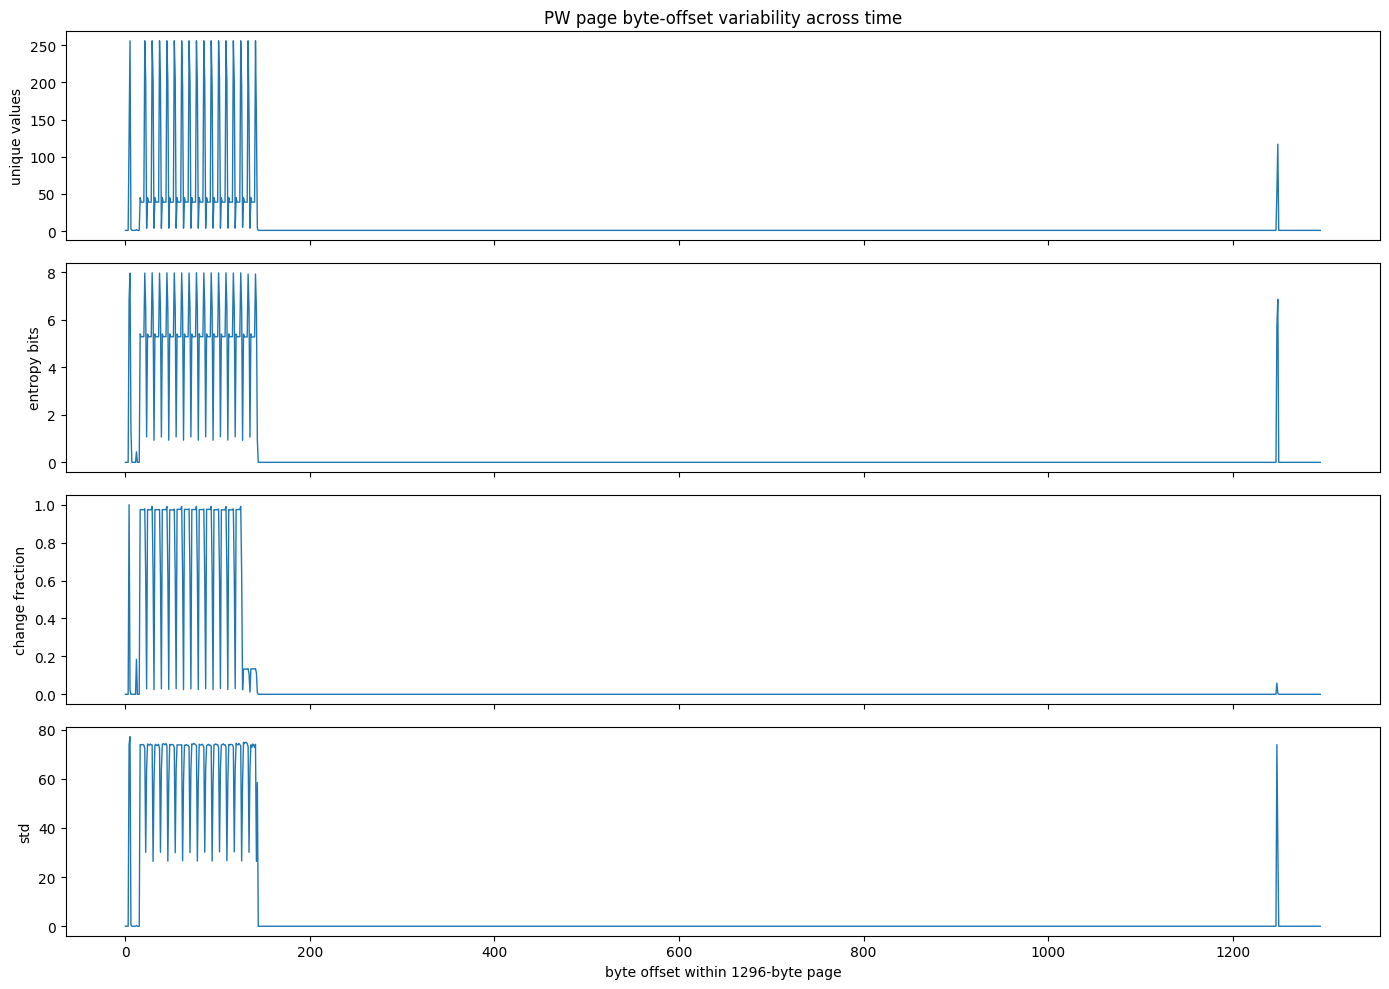

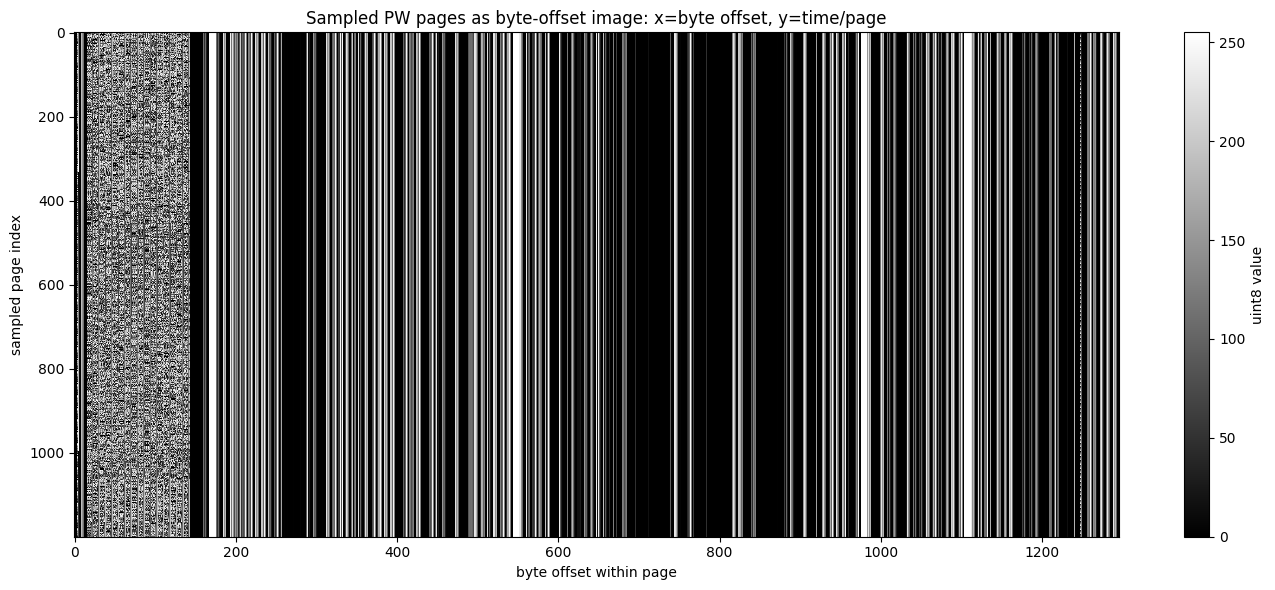

In [3]:
pw_files = find_pw_cine_files(".")
print(f"Found {len(pw_files)} PW_CinePartition0.bin files")
for i, path in enumerate(pw_files):
    print(f"{i}: {path}")

if not pw_files:
    raise FileNotFoundError("No PW_CinePartition0.bin files found under the current directory.")

# Start with the first file only. We will inspect other recordings after interpreting this one.
summary0, dynamic_runs0 = inspect_one_pw_file(pw_files[0])

###  PW page byte-variability map interpretation

Result classification: useful positive result for structure mapping; useful negative result for an obvious full-page dynamic image payload.

For the first `PW_CinePartition0.bin` file, the page size assumption is internally consistent:

- file size: `38,381,040` bytes
- complete pages: `29,615`
- remainder bytes: `0`

Most byte offsets are constant across sampled pages:

- `1162 / 1296` byte offsets are constant
- only `35` byte offsets are high-variation
- dynamic offsets are concentrated mainly in the first ~143 bytes
- one isolated dynamic offset appears near `1248`

The strongest dynamic pattern is not a broad payload region. Instead, it appears as repeated short runs of about 7 bytes, spaced regularly in the early part of the page. This is more consistent with repeated control/header/state fields than with a full image-like raster buffer.

The sampled page image supports the same interpretation: the early byte region changes strongly over time, while most later byte columns are stable vertical bands. Stable vertical bands may still encode constants, lookup-like fields, padding, or fixed configuration, but they do not look like a time-varying spectrogram payload in this first test.

Working hypothesis after Experiment 01:

- bytes around `0..142` contain dynamic page-level control/state records,
- most bytes after that are stable or near-stable for this recording,
- there is no obvious full-page time-varying image/spectrogram buffer visible from simple byte-offset variability.


## PW dynamic header-field layout

This section inspects the dynamic byte region at the beginning of each `PW_CinePartition0.bin` page.

The previous variability map showed that most byte offsets in each 1296-byte page are stable across time, while the first ~144 bytes contain repeated dynamic runs. This section checks whether those early dynamic bytes follow a regular field layout.

The specific question is whether the first `144` bytes behave like `18` repeated `8-byte` records.

This matters because a repeated field layout is more consistent with page-level control data, counters, state values, or compact machine fields than with a raster image or spectrogram payload.

Interpretation boundary:

This section does not decode native Doppler data. It only tests whether the early dynamic page region has a structured record layout. A structured field pattern is not evidence of a native velocity envelope, spectrogram, or clinical measurement.

In [4]:
def summarize_record_byte_layout(pages, header_bytes=DYNAMIC_HEADER_BYTES, record_width=RECORD_WIDTH_BYTES):
    """
    This function summarizes byte variability after reshaping the early page region
    into fixed-width candidate records.
    """
    if header_bytes % record_width != 0:
        raise ValueError("header_bytes must divide evenly by record_width")

    early = pages[:, :header_bytes]
    n_records = header_bytes // record_width
    records = early.reshape(early.shape[0], n_records, record_width)

    rows = []
    for record_index in range(n_records):
        for byte_in_record in range(record_width):
            values = records[:, record_index, byte_in_record]
            if len(values) > 1:
                change_fraction = float((values[1:] != values[:-1]).mean())
            else:
                change_fraction = 0.0

            rows.append({
                "record_index": record_index,
                "record_start_offset": record_index * record_width,
                "byte_in_record": byte_in_record,
                "byte_offset": record_index * record_width + byte_in_record,
                "mean": float(values.mean()),
                "std": float(values.std()),
                "min": int(values.min()),
                "max": int(values.max()),
                "n_unique": int(np.unique(values).size),
                "change_fraction": change_fraction,
                "entropy_bits": byte_entropy_uint8(values),
            })

    return pd.DataFrame(rows)


def inspect_dynamic_header_layout(path):
    """This function inspects repeated byte-field structure in the early PW page region."""
    pages, info = sample_pw_pages(path)
    layout = summarize_record_byte_layout(pages)

    entropy_matrix = layout.pivot(
        index="record_index",
        columns="byte_in_record",
        values="entropy_bits",
    )

    unique_matrix = layout.pivot(
        index="record_index",
        columns="byte_in_record",
        values="n_unique",
    )

    change_matrix = layout.pivot(
        index="record_index",
        columns="byte_in_record",
        values="change_fraction",
    )

    print("File info")
    display(pd.DataFrame([info]))

    print("Entropy by candidate 8-byte record")
    display(entropy_matrix.round(3))

    print("Unique values by candidate 8-byte record")
    display(unique_matrix.astype(int))

    print("Change fraction by candidate 8-byte record")
    display(change_matrix.round(3))

    print("Most dynamic fields in the first 144 bytes")
    display(
        layout.sort_values(
            ["entropy_bits", "n_unique", "change_fraction", "std"],
            ascending=False,
        ).head(40)
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)

    im0 = axes[0].imshow(entropy_matrix, aspect="auto", interpolation="nearest", cmap="viridis")
    axes[0].set_title("Entropy bits")
    axes[0].set_xlabel("byte within 8-byte record")
    axes[0].set_ylabel("candidate record index")
    plt.colorbar(im0, ax=axes[0], fraction=0.046)

    im1 = axes[1].imshow(unique_matrix, aspect="auto", interpolation="nearest", cmap="magma")
    axes[1].set_title("Unique values")
    axes[1].set_xlabel("byte within 8-byte record")
    plt.colorbar(im1, ax=axes[1], fraction=0.046)

    im2 = axes[2].imshow(change_matrix, aspect="auto", interpolation="nearest", cmap="plasma")
    axes[2].set_title("Change fraction")
    axes[2].set_xlabel("byte within 8-byte record")
    plt.colorbar(im2, ax=axes[2], fraction=0.046)

    plt.tight_layout()
    plt.show()

    early_preview = pages[: min(1200, pages.shape[0]), :DYNAMIC_HEADER_BYTES]

    plt.figure(figsize=(14, 5))
    plt.imshow(early_preview, aspect="auto", interpolation="nearest", cmap="gray")
    plt.title("Early PW page region only: first 144 bytes across time")
    plt.xlabel("byte offset within page")
    plt.ylabel("sampled page index")
    plt.tight_layout()
    plt.show()

    return layout


File info


,path,file_size,n_pages,remainder_bytes,sampled_pages,first_sample_page,last_sample_page
0,ultrasound_recordings\batch_2026_06_13_native\...,38381040,29615,0,20000,0,29614


Entropy by candidate 8-byte record


byte_in_record,0,1,2,3,4,5,6,7
record_index,,,,,,,,
0,-0.000,-0.000,-0.000,-0.000,6.830,7.961,1.420,-0.000
1,-0.000,-0.000,-0.000,-0.000,0.444,-0.000,-0.000,-0.000
2,5.404,5.284,5.284,5.284,5.284,7.963,6.471,1.068
3,5.399,5.284,5.284,5.284,5.284,7.974,6.474,0.929
4,5.405,5.284,5.284,5.284,5.284,7.962,6.471,1.066
5,5.402,5.284,5.284,5.284,5.284,7.973,6.474,0.931
6,5.403,5.284,5.284,5.284,5.284,7.966,6.470,1.067
7,5.400,5.284,5.284,5.284,5.284,7.973,6.473,0.933
8,5.402,5.284,5.284,5.284,5.284,7.966,6.472,1.068


Unique values by candidate 8-byte record


byte_in_record,0,1,2,3,4,5,6,7
record_index,,,,,,,,
0,1,1,1,1,128,256,3,1
1,1,1,1,1,2,1,1,1
2,45,39,39,39,39,256,203,4
3,45,39,39,39,39,256,203,4
4,45,39,39,39,39,256,200,4
5,45,39,39,39,39,256,202,4
6,45,39,39,39,39,256,204,4
7,45,39,39,39,39,256,195,4
8,45,39,39,39,39,256,203,4


Change fraction by candidate 8-byte record


byte_in_record,0,1,2,3,4,5,6,7
record_index,,,,,,,,
0,0.000,0.000,0.000,0.000,1.000,0.023,0.000,0.000
1,0.000,0.000,0.000,0.000,0.184,0.000,0.000,0.000
2,0.974,0.974,0.974,0.974,0.974,0.978,0.626,0.029
3,0.974,0.973,0.973,0.973,0.973,0.991,0.642,0.025
4,0.974,0.974,0.974,0.974,0.974,0.976,0.627,0.029
5,0.975,0.974,0.974,0.974,0.974,0.991,0.640,0.025
6,0.973,0.973,0.973,0.973,0.973,0.977,0.623,0.029
7,0.976,0.976,0.976,0.976,0.976,0.991,0.641,0.025
8,0.976,0.975,0.975,0.975,0.975,0.978,0.626,0.029


Most dynamic fields in the first 144 bytes


,record_index,record_start_offset,byte_in_record,byte_offset,mean,std,min,max,n_unique,change_fraction,entropy_bits
109,13,104,5,109,125.70460,72.920163,0,255,256,0.989899,7.975216
29,3,24,5,29,124.29385,73.736237,0,255,256,0.990900,7.974336
77,9,72,5,77,125.85540,73.446335,0,255,256,0.991000,7.973549
125,15,120,5,125,124.75005,73.366402,0,255,256,0.991350,7.973059
45,5,40,5,45,126.01480,73.468433,0,255,256,0.990600,7.972828
61,7,56,5,61,126.30555,73.807598,0,255,256,0.990650,7.972651
93,11,88,5,93,125.41775,73.272958,0,255,256,0.991350,7.972461
101,12,96,5,101,124.18875,72.723946,0,255,256,0.977249,7.966785
85,10,80,5,85,124.75965,72.818996,0,255,256,0.976899,7.966274
69,8,64,5,69,124.47645,72.906405,0,255,256,0.977549,7.966203


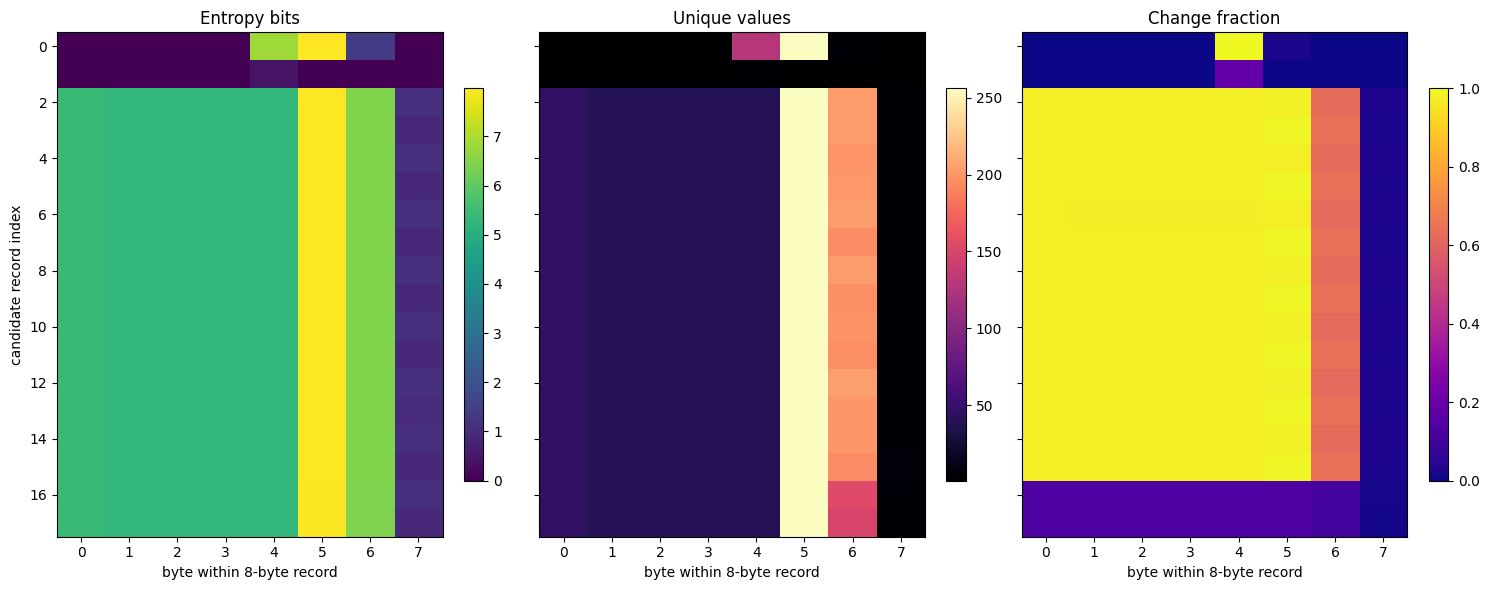

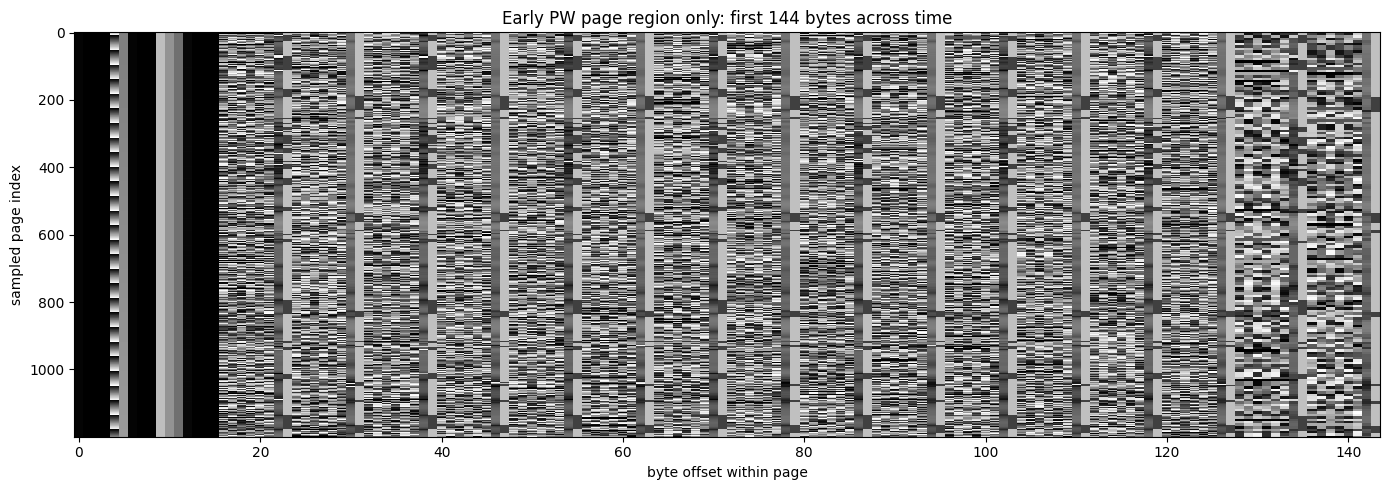

In [5]:
pw_files = find_pw_cine_files(".")
if not pw_files:
    raise FileNotFoundError("No PW_CinePartition0.bin files found under the current directory.")

dynamic_header_layout0 = inspect_dynamic_header_layout(pw_files[0])

### PW dynamic header-field layout interpretation

Result classification: useful positive result.

The early dynamic region has a strong repeated 8-byte layout.

Records `2..15` show a highly consistent pattern:

- bytes `0..4` vary together with moderate entropy around `5.28..5.40` bits,
- byte `5` has full uint8 range with entropy near `7.96..7.98` bits,
- byte `6` has high but lower entropy around `6.47` bits,
- byte `7` has low entropy and only a few unique values.

Records `16..17` preserve the same field pattern but change much more slowly. Records `0..1` look like special header/control records rather than members of the main repeated block.

This supports the working hypothesis that the first `144` bytes contain repeated structured control/state records, probably arranged as 18 candidate 8-byte records.

This does not support treating the early region as a raster image or spectrogram payload. The regular field layout is more consistent with native page metadata, counters, state variables, or compact per-channel/per-gate control values.

Next working hypothesis:

- offsets `16..127` contain 14 fast-changing repeated 8-byte records,
- offsets `128..143` contain 2 slower-changing repeated 8-byte records,
- each 8-byte record should be inspected as possible multi-byte numeric fields before any image-like reshape is attempted.

## PW early records as numeric fields

This section tests whether the repeated 8-byte records behave like packed numeric fields.

The previous section showed that the first `144` bytes are not random variation across arbitrary offsets. They follow a repeated 8-byte layout. This section interprets those bytes as little-endian unsigned and signed integer candidates to check for counters, ramps, state fields, or paired values.

Interpretation boundary:

Numeric structure does not imply Doppler velocity, image data, or clinical meaning. This section only checks whether the dynamic header-like records contain coherent machine-readable fields.

,record_index,record_start_offset,field,min,max,n_unique,mean,std,change_fraction,median_abs_step
4,0,0,i16_01,4,4,1,4.00000,0.000000,0.000000,0.0
5,0,0,i16_23,0,0,1,0.00000,0.000000,0.000000,0.0
6,0,0,i16_45,-32766,32767,17794,-2810.40960,17677.703716,1.000000,5.0
7,0,0,i16_67,4,6,3,4.89250,0.659730,0.000100,0.0
0,0,0,u16_01,4,4,1,4.00000,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...
143,17,136,i16_67,-16445,16528,257,-6572.05195,14964.190571,0.112756,0.0
136,17,136,u16_01,0,63855,45,31685.92325,18624.516541,0.133957,0.0
137,17,136,u16_23,0,63855,39,31209.77620,18899.819989,0.133757,0.0
138,17,136,u16_45,0,65483,1371,31988.36020,18950.565479,0.136307,0.0


,record_index,record_start_offset,field,min,max,n_unique,mean,std,change_fraction,median_abs_step
2,0,0,u16_45,2,65534,17794,33447.38240,19744.052608,1.00000,5.0
6,0,0,i16_45,-32766,32767,17794,-2810.40960,17677.703716,1.00000,5.0
86,10,80,i16_45,-32768,32741,3426,205.28900,19260.318914,0.99570,15754.0
82,10,80,u16_45,0,65509,3426,32062.33860,18642.230865,0.99570,15649.0
70,8,64,i16_45,-32768,32754,3425,471.19425,19254.364752,0.99605,15911.0
66,8,64,u16_45,0,65522,3425,31990.73345,18664.557996,0.99605,15859.0
54,6,48,i16_45,-32768,32754,3419,447.70905,19330.689876,0.99540,15963.0
50,6,48,u16_45,0,65522,3419,32157.30265,18577.666020,0.99540,15754.0
38,4,32,i16_45,-32768,32754,3414,343.12730,19419.226328,0.99575,16042.0
34,4,32,u16_45,0,65509,3414,32092.04250,18492.953185,0.99575,15859.0


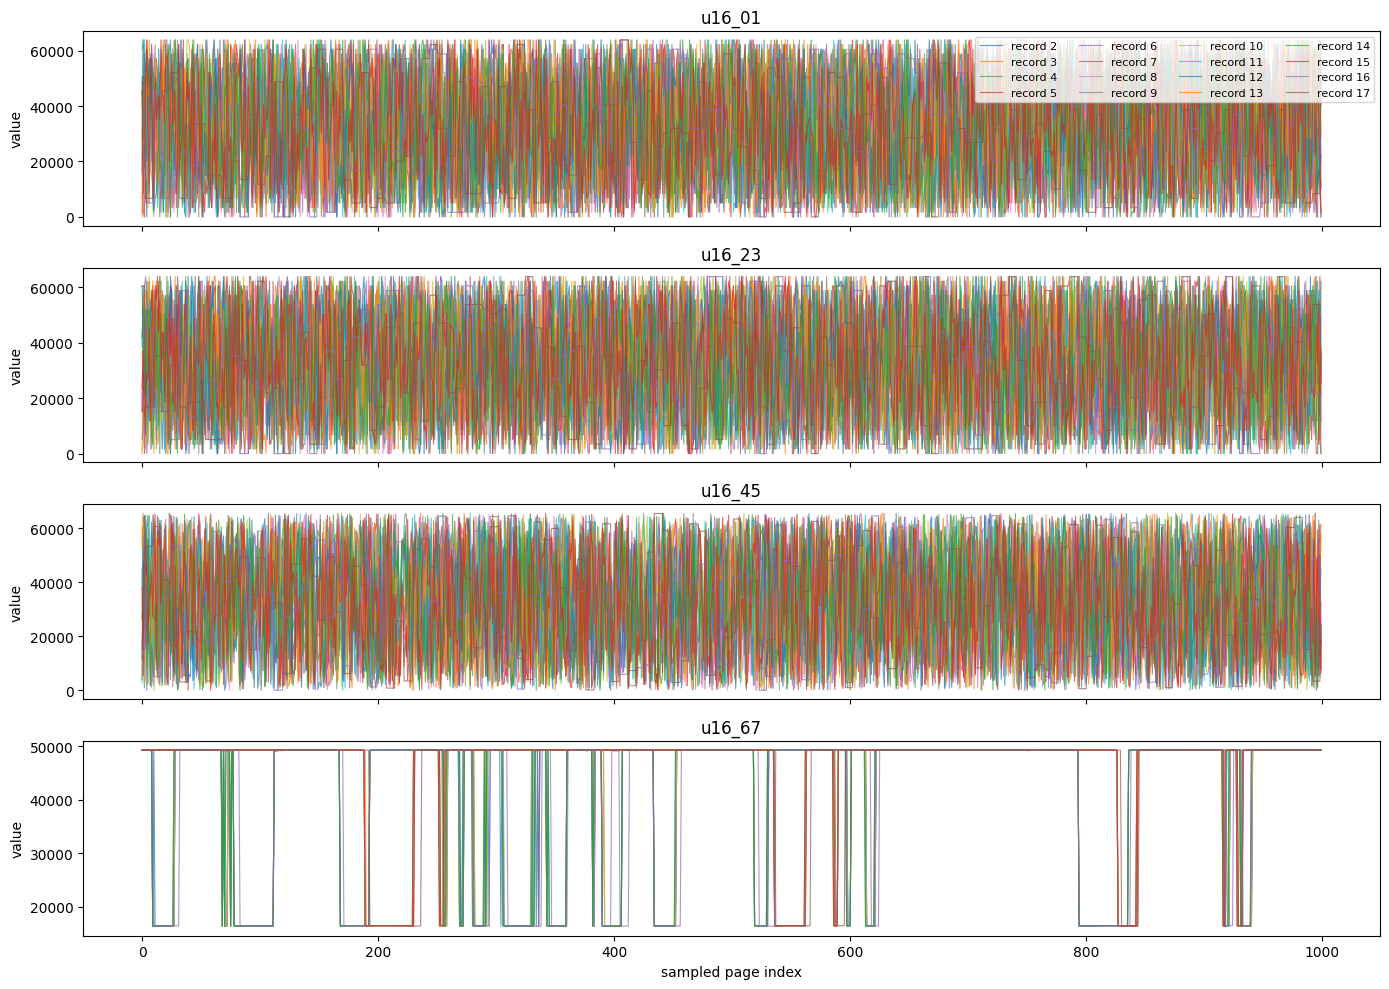

In [6]:
pages0, info0 = sample_pw_pages(pw_files[0])

early = pages0[:, :144]
records = early.reshape(early.shape[0], 18, 8)

rows = []

for record_index in range(records.shape[1]):
    block = records[:, record_index, :]

    u16_01 = block[:, 0].astype(np.uint16) | (block[:, 1].astype(np.uint16) << 8)
    u16_23 = block[:, 2].astype(np.uint16) | (block[:, 3].astype(np.uint16) << 8)
    u16_45 = block[:, 4].astype(np.uint16) | (block[:, 5].astype(np.uint16) << 8)
    u16_67 = block[:, 6].astype(np.uint16) | (block[:, 7].astype(np.uint16) << 8)

    i16_01 = u16_01.view(np.int16)
    i16_23 = u16_23.view(np.int16)
    i16_45 = u16_45.view(np.int16)
    i16_67 = u16_67.view(np.int16)

    candidate_fields = {
        "u16_01": u16_01,
        "u16_23": u16_23,
        "u16_45": u16_45,
        "u16_67": u16_67,
        "i16_01": i16_01,
        "i16_23": i16_23,
        "i16_45": i16_45,
        "i16_67": i16_67,
    }

    for field_name, values in candidate_fields.items():
        values_float = values.astype(np.float64)

        if len(values) > 1:
            diffs = np.diff(values_float)
            median_abs_step = float(np.median(np.abs(diffs)))
            change_fraction = float((values[1:] != values[:-1]).mean())
        else:
            median_abs_step = 0.0
            change_fraction = 0.0

        rows.append({
            "record_index": record_index,
            "record_start_offset": record_index * 8,
            "field": field_name,
            "min": int(values.min()),
            "max": int(values.max()),
            "n_unique": int(pd.Series(values).nunique()),
            "mean": float(values_float.mean()),
            "std": float(values_float.std()),
            "change_fraction": change_fraction,
            "median_abs_step": median_abs_step,
        })

numeric_field_summary0 = pd.DataFrame(rows)

display(
    numeric_field_summary0.sort_values(
        ["record_index", "field"],
        ascending=True,
    )
)

display(
    numeric_field_summary0.sort_values(
        ["n_unique", "change_fraction", "std"],
        ascending=False,
    ).head(30)
)

fields_to_plot = ["u16_01", "u16_23", "u16_45", "u16_67"]

fig, axes = plt.subplots(len(fields_to_plot), 1, figsize=(14, 10), sharex=True)

for ax, field_name in zip(axes, fields_to_plot):
    for record_index in range(2, 18):
        block = records[:, record_index, :]

        if field_name == "u16_01":
            values = block[:, 0].astype(np.uint16) | (block[:, 1].astype(np.uint16) << 8)
        elif field_name == "u16_23":
            values = block[:, 2].astype(np.uint16) | (block[:, 3].astype(np.uint16) << 8)
        elif field_name == "u16_45":
            values = block[:, 4].astype(np.uint16) | (block[:, 5].astype(np.uint16) << 8)
        elif field_name == "u16_67":
            values = block[:, 6].astype(np.uint16) | (block[:, 7].astype(np.uint16) << 8)

        ax.plot(values[:1000], linewidth=0.8, alpha=0.7, label=f"record {record_index}")

    ax.set_title(field_name)
    ax.set_ylabel("value")

axes[-1].set_xlabel("sampled page index")
axes[0].legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.show()

### PW dynamic header-field layout interpretation

Result classification: useful positive result.

The first `144` bytes show a strong repeated `8-byte` structure.

Most records from `2..15` have a similar field pattern. The candidate `u16_45` / `i16_45` field changes almost every sampled page and spans nearly the full 16-bit range. Several other fields also vary broadly, but the plotted traces look noise-like or wrapped rather than like clean monotonic counters.

The `u16_67` field behaves differently. It changes less often and appears more state-like, with long flat segments and abrupt transitions.

This supports the interpretation that the early page region is structured native control/state data. It does not support treating this region as an image-like or spectrogram-like payload.

Working hypothesis:

- offsets `0..143` are header/control/state-like,
- records `2..15` are the main fast-changing repeated fields,
- records `16..17` are slower-changing related fields,
- this region should not be used as image/spectrogram data without stronger evidence.

## PW byte-variability pattern across recordings

This section checks whether the byte-variability pattern from the first `PW_CinePartition0.bin` file is consistent across all native recordings.

The previous section showed that the first recording has dynamic bytes concentrated mainly in the first `144` bytes, with most later byte offsets remaining stable. This section tests whether that pattern is batch-wide or whether another recording contains a different dynamic payload region.

Interpretation boundary:

This section does not decode image-like or spectrogram-like data. It only checks whether candidate dynamic byte regions are consistent across recordings and whether any recording has a broader time-varying payload outside the early header/control-like region.

In [7]:
batch_rows = []
batch_dynamic_runs = []

for file_index, path in enumerate(pw_files):
    pages, info = sample_pw_pages(path)
    summary = summarize_byte_variability(pages)

    dynamic_mask = (
        (summary["n_unique"] >= 16)
        & (summary["entropy_bits"] >= 2.0)
        & (summary["change_fraction"] >= 0.05)
    )

    dynamic_runs = contiguous_runs(dynamic_mask.to_numpy())
    dynamic_runs["file_index"] = file_index
    dynamic_runs["recording"] = path.parent.parent.name
    batch_dynamic_runs.append(dynamic_runs)

    early_dynamic_count = int(dynamic_mask.iloc[:144].sum())
    post_144_dynamic_count = int(dynamic_mask.iloc[144:].sum())

    strongest_post_144 = (
        summary.iloc[144:]
        .sort_values(["entropy_bits", "n_unique", "change_fraction"], ascending=False)
        .head(5)
    )

    top_post_144_offsets = ", ".join(str(int(x)) for x in strongest_post_144["byte_offset"].tolist())

    batch_rows.append({
        "file_index": file_index,
        "recording": path.parent.parent.name,
        "file_size": info["file_size"],
        "n_pages": info["n_pages"],
        "remainder_bytes": info["remainder_bytes"],
        "constant_offsets": int((summary["n_unique"] == 1).sum()),
        "dynamic_offsets_total": int(dynamic_mask.sum()),
        "dynamic_offsets_0_143": early_dynamic_count,
        "dynamic_offsets_144_1295": post_144_dynamic_count,
        "top_post_144_offsets": top_post_144_offsets,
        "max_post_144_entropy": float(summary.iloc[144:]["entropy_bits"].max()),
    })

batch_variability_summary = pd.DataFrame(batch_rows)
batch_dynamic_runs = pd.concat(batch_dynamic_runs, ignore_index=True)

display(batch_variability_summary)

print("Longest dynamic runs across recordings")
display(
    batch_dynamic_runs
    .sort_values(["length", "file_index"], ascending=[False, True])
    .head(40)
)

print("Dynamic runs outside first 144 bytes")
display(
    batch_dynamic_runs[batch_dynamic_runs["start_offset"] >= 144]
    .sort_values(["file_index", "start_offset"])
)

,file_index,recording,file_size,n_pages,remainder_bytes,constant_offsets,dynamic_offsets_total,dynamic_offsets_0_143,dynamic_offsets_144_1295,top_post_144_offsets,max_post_144_entropy
0,0,202606130411060002SMP,38381040,29615,0,1162,114,113,1,"1249, 1248, 144, 145, 146",6.859715
1,1,202606130413540003SMP,30444336,23491,0,1162,113,113,0,"1249, 1248, 144, 145, 146",6.522088
2,2,202606130417060004SMP,27516672,21232,0,1156,113,113,0,"1249, 1248, 1168, 1169, 1170",6.379207
3,3,202606130420260005SMP,29502144,22764,0,1162,113,113,0,"1249, 1248, 144, 145, 146",6.482203
4,4,202606130422440006SMP,33211296,25626,0,1162,114,113,1,"1249, 1248, 144, 145, 146",6.650171
5,5,202606130426500007SMP,23776416,18346,0,1162,113,113,0,"1249, 1248, 144, 145, 146",6.168221
6,6,202606130430380008SMP,28753056,22186,0,1156,113,113,0,"1249, 1248, 1168, 1169, 1170",6.447771
7,7,202606130433280009SMP,20557152,15862,0,1162,113,113,0,"1249, 1248, 144, 145, 146",5.952915
8,8,202606130434130010SMP,21923136,16916,0,1162,113,113,0,"1249, 1248, 144, 145, 146",6.054405
9,9,202606130437480012SMP,29176848,22513,0,1156,113,113,0,"1249, 1248, 1168, 1169, 1170",6.467494


Longest dynamic runs across recordings


,start_offset,end_offset,length,file_index,recording
1,16,22,7,0,202606130411060002SMP
2,24,30,7,0,202606130411060002SMP
3,32,38,7,0,202606130411060002SMP
4,40,46,7,0,202606130411060002SMP
5,48,54,7,0,202606130411060002SMP
6,56,62,7,0,202606130411060002SMP
7,64,70,7,0,202606130411060002SMP
8,72,78,7,0,202606130411060002SMP
9,80,86,7,0,202606130411060002SMP
10,88,94,7,0,202606130411060002SMP


Dynamic runs outside first 144 bytes


,start_offset,end_offset,length,file_index,recording
17,1248,1248,1,0,202606130411060002SMP
86,1248,1248,1,4,202606130422440006SMP


## PW stable post-header region across recordings

This section checks whether the mostly stable bytes after offset `144` are identical across recordings or contain recording-specific structure.

The previous section showed that bytes after `144` rarely vary over time within each recording. This section compares those offsets across recordings using one representative page per file.

This matters because a region that is stable over time but different across recordings may contain configuration, metadata, lookup-like data, or acquisition settings. A region that is stable both within and across recordings is more likely padding or fixed constants.

Interpretation boundary:

This section does not search for a time-varying spectrogram payload. It tests whether the post-header region contains recording-level structure that may help explain the PW page format.

,byte_offset,n_unique_across_recordings,min,max,values_hex
1121,1265,10,125,252,7D E8 E6 FC EC D6 EF D8 F1 F9
520,664,9,2,63,2C 28 15 02 33 27 0E 3F 02 13
1104,1248,9,0,236,EC 14 EC D2 D7 32 E2 00 23 B9
897,1041,8,116,193,74 B1 C1 BC BD B9 BD BC B2 B7
1105,1249,7,2,30,17 06 03 08 02 05 1E 05 03 03
...,...,...,...,...,...
78,222,2,0,205,00 00 00 00 00 00 00 00 00 CD
79,223,2,0,53,00 00 00 00 00 00 00 00 00 35
80,224,2,1,48,30 30 30 30 30 30 30 30 30 01
81,225,2,0,227,E3 E3 E3 E3 E3 E3 E3 E3 E3 00


Counts of cross-recording uniqueness after byte 144


,n_unique_across_recordings,byte_count
0,1,937
1,2,207
2,4,1
3,5,1
4,7,2
5,8,1
6,9,2
7,10,1


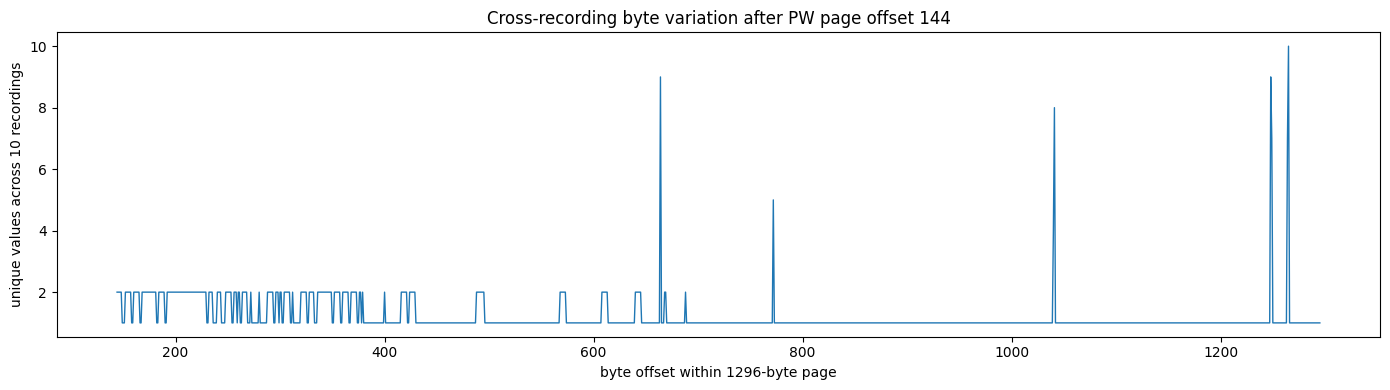

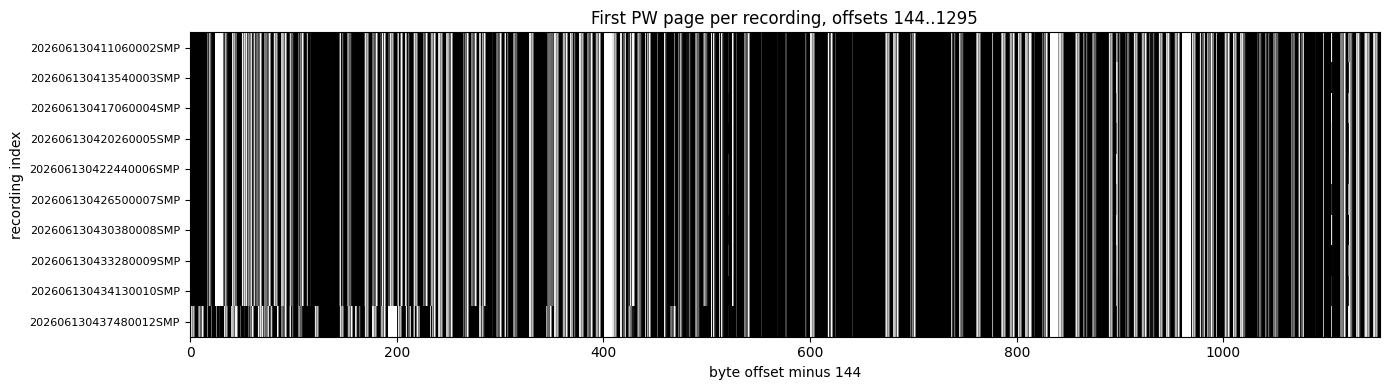

In [8]:
representative_rows = []
recording_names = []

for path in pw_files:
    pages, info = sample_pw_pages(path)
    recording_names.append(path.parent.parent.name)
    representative_rows.append(pages[0])

representative_pages = np.vstack(representative_rows)

post_header = representative_pages[:, 144:]

rows = []

for offset in range(144, PAGE_SIZE_BYTES):
    values = representative_pages[:, offset]
    rows.append({
        "byte_offset": offset,
        "n_unique_across_recordings": int(pd.Series(values).nunique()),
        "min": int(values.min()),
        "max": int(values.max()),
        "values_hex": " ".join(f"{int(v):02X}" for v in values),
    })

post_header_across_recordings = pd.DataFrame(rows)

display(
    post_header_across_recordings
    .sort_values(["n_unique_across_recordings", "byte_offset"], ascending=[False, True])
    .head(80)
)

print("Counts of cross-recording uniqueness after byte 144")
display(
    post_header_across_recordings["n_unique_across_recordings"]
    .value_counts()
    .sort_index()
    .rename_axis("n_unique_across_recordings")
    .reset_index(name="byte_count")
)

plt.figure(figsize=(14, 4))
plt.plot(
    post_header_across_recordings["byte_offset"],
    post_header_across_recordings["n_unique_across_recordings"],
    linewidth=1,
)
plt.title("Cross-recording byte variation after PW page offset 144")
plt.xlabel("byte offset within 1296-byte page")
plt.ylabel("unique values across 10 recordings")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plt.imshow(
    representative_pages[:, 144:],
    aspect="auto",
    interpolation="nearest",
    cmap="gray",
)
plt.title("First PW page per recording, offsets 144..1295")
plt.xlabel("byte offset minus 144")
plt.ylabel("recording index")
plt.yticks(range(len(recording_names)), recording_names, fontsize=8)
plt.tight_layout()
plt.show()

## PW post-header recording-specific bytes

This section checks which recordings differ from the majority value in the mostly stable post-header region.

The previous section showed that most bytes after offset `144` are identical across recordings, while some offsets differ across the batch. This section tests whether those differences are spread across many recordings or mostly caused by one exception recording.

This matters because exception-driven differences are more consistent with layout/configuration differences than with a hidden image-like or spectrogram-like payload.


Recording-level difference counts after byte 144


,recording_index,recording,different_from_majority_byte_count
9,9,202606130437480012SMP,214
1,1,202606130413540003SMP,8
4,4,202606130422440006SMP,8
6,6,202606130430380008SMP,7
5,5,202606130426500007SMP,7
3,3,202606130420260005SMP,6
7,7,202606130433280009SMP,5
0,0,202606130411060002SMP,4
2,2,202606130417060004SMP,4
8,8,202606130434130010SMP,4


Most recording-specific offsets after byte 144


,byte_offset,recording_index,recording,value,value_hex,majority_value,majority_value_hex,majority_count,n_unique_across_recordings
258,1265,1,202606130413540003SMP,232,E8,125,7D,1,10
259,1265,2,202606130417060004SMP,230,E6,125,7D,1,10
260,1265,3,202606130420260005SMP,252,FC,125,7D,1,10
261,1265,4,202606130422440006SMP,236,EC,125,7D,1,10
262,1265,5,202606130426500007SMP,214,D6,125,7D,1,10
...,...,...,...,...,...,...,...,...,...
15,164,9,202606130437480012SMP,99,63,28,1C,9,2
16,165,9,202606130437480012SMP,0,00,2,02,9,2
17,168,9,202606130437480012SMP,0,00,254,FE,9,2
18,169,9,202606130437480012SMP,128,80,255,FF,9,2


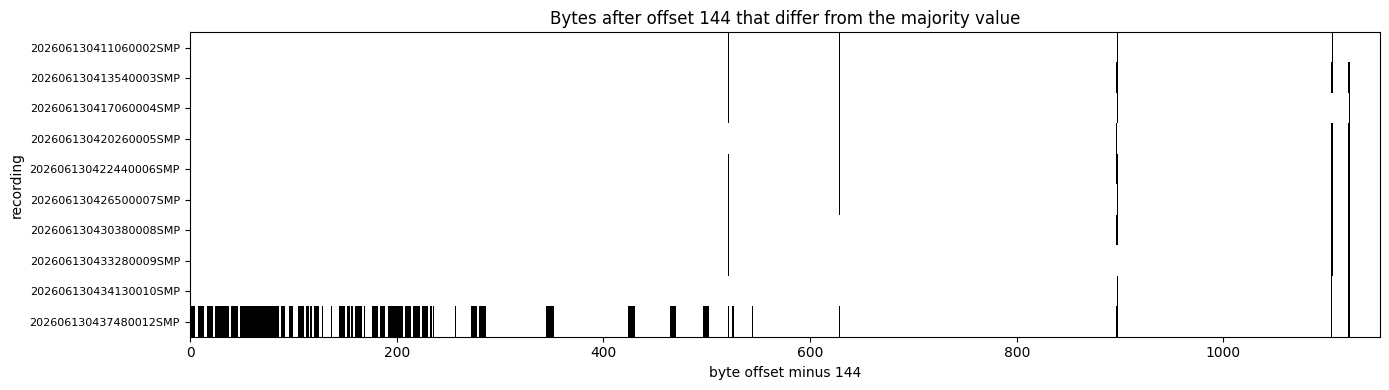

In [9]:
post_header_offsets = np.arange(144, PAGE_SIZE_BYTES)

difference_rows = []

for offset in post_header_offsets:
    values = representative_pages[:, offset]
    counts = pd.Series(values).value_counts()

    majority_value = int(counts.index[0])
    majority_count = int(counts.iloc[0])

    for recording_index, value in enumerate(values):
        if int(value) != majority_value:
            difference_rows.append({
                "byte_offset": int(offset),
                "recording_index": recording_index,
                "recording": recording_names[recording_index],
                "value": int(value),
                "value_hex": f"{int(value):02X}",
                "majority_value": majority_value,
                "majority_value_hex": f"{majority_value:02X}",
                "majority_count": majority_count,
                "n_unique_across_recordings": int(pd.Series(values).nunique()),
            })

post_header_differences = pd.DataFrame(difference_rows)

print("Recording-level difference counts after byte 144")
display(
    post_header_differences
    .groupby(["recording_index", "recording"], as_index=False)
    .size()
    .rename(columns={"size": "different_from_majority_byte_count"})
    .sort_values("different_from_majority_byte_count", ascending=False)
)

print("Most recording-specific offsets after byte 144")
display(
    post_header_differences
    .sort_values(["n_unique_across_recordings", "byte_offset", "recording_index"], ascending=[False, True, True])
    .head(80)
)

difference_matrix = np.zeros((len(recording_names), len(post_header_offsets)), dtype=np.uint8)

for row in post_header_differences.itertuples(index=False):
    x = int(row.byte_offset) - 144
    y = int(row.recording_index)
    difference_matrix[y, x] = 1

plt.figure(figsize=(14, 4))
plt.imshow(difference_matrix, aspect="auto", interpolation="nearest", cmap="gray_r")
plt.title("Bytes after offset 144 that differ from the majority value")
plt.xlabel("byte offset minus 144")
plt.ylabel("recording")
plt.yticks(range(len(recording_names)), recording_names, fontsize=8)
plt.tight_layout()
plt.show()

## PW isolated post-header dynamic byte

This section inspects the only post-header byte offset that showed time variation in some recordings.

The batch variability check found that almost all dynamic bytes are inside offsets `0..143`. Only offset `1248` appeared as a dynamic post-header byte in two recordings. This section checks whether that isolated byte behaves like a meaningful time signal, a rare state flag, or a low-value artifact.

This matters because a single dynamic byte outside the header-like region is not enough to suggest image-like or spectrogram-like payload data, but it should be inspected before the post-header region is classified as mostly stable.


,file_index,recording,byte_offset,min,max,n_unique,mean,std,change_fraction,most_common_values
0,0,202606130411060002SMP,1248,0,251,53,125.262100,73.852775,0.058953,"{55: 406, 236: 405, 5: 405, 30: 405, 80: 405, ..."
1,0,202606130411060002SMP,1249,23,139,117,81.225350,33.396468,0.005800,"{35: 187, 45: 187, 60: 187, 70: 187, 95: 187, ..."
2,0,202606130411060002SMP,1265,125,125,1,125.000000,0.000000,0.000000,{125: 20000}
3,1,202606130413540003SMP,1248,0,251,53,125.327750,73.715452,0.046752,"{45: 405, 95: 405, 145: 405, 195: 405, 246: 40..."
4,1,202606130413540003SMP,1249,6,97,92,51.420400,26.489388,0.004550,"{10: 235, 15: 235, 20: 235, 25: 235, 30: 235, ..."
5,1,202606130413540003SMP,1265,232,232,1,232.000000,0.000000,0.000000,{232: 20000}
6,2,202606130417060004SMP,1248,0,251,53,125.324150,73.817857,0.042252,"{205: 416, 200: 412, 5: 401, 130: 401, 180: 40..."
7,2,202606130417060004SMP,1249,3,86,84,44.852050,23.942407,0.004150,"{5: 260, 10: 260, 15: 260, 20: 260, 25: 260, 3..."
8,2,202606130417060004SMP,1265,230,230,1,230.000000,0.000000,0.000000,{230: 20000}
9,3,202606130420260005SMP,1248,0,251,52,125.400450,73.835521,0.045302,"{210: 411, 205: 411, 220: 410, 200: 405, 30: 3..."


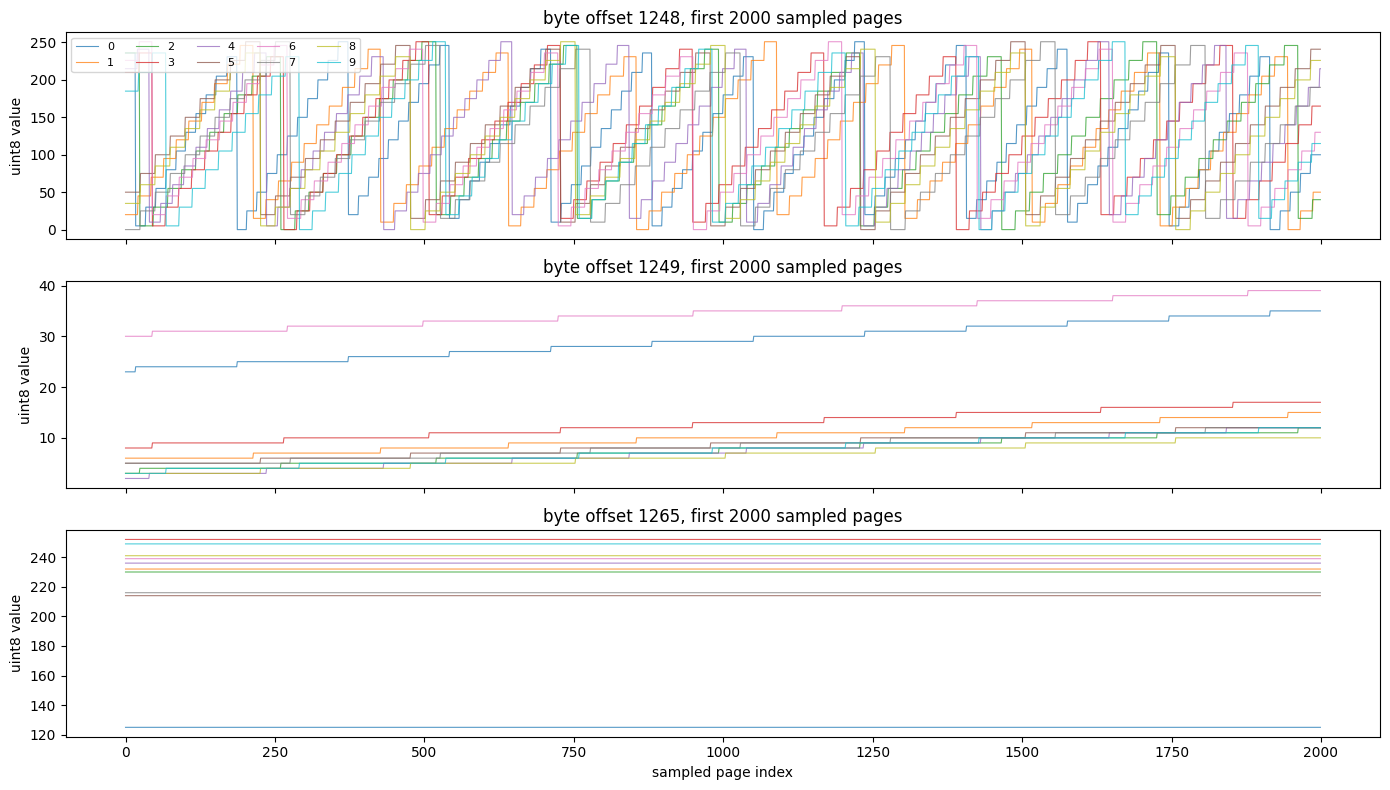

In [10]:
offsets_to_check = [1248, 1249, 1265]

rows = []

for file_index, path in enumerate(pw_files):
    pages, info = sample_pw_pages(path)

    for offset in offsets_to_check:
        values = pages[:, offset]

        if len(values) > 1:
            change_fraction = float((values[1:] != values[:-1]).mean())
        else:
            change_fraction = 0.0

        rows.append({
            "file_index": file_index,
            "recording": path.parent.parent.name,
            "byte_offset": offset,
            "min": int(values.min()),
            "max": int(values.max()),
            "n_unique": int(pd.Series(values).nunique()),
            "mean": float(values.mean()),
            "std": float(values.std()),
            "change_fraction": change_fraction,
            "most_common_values": pd.Series(values).value_counts().head(8).to_dict(),
        })

isolated_post_header_summary = pd.DataFrame(rows)
display(isolated_post_header_summary)

fig, axes = plt.subplots(len(offsets_to_check), 1, figsize=(14, 8), sharex=True)

for ax, offset in zip(axes, offsets_to_check):
    for file_index, path in enumerate(pw_files):
        pages, info = sample_pw_pages(path)
        values = pages[:, offset]

        ax.plot(
            values[:2000],
            linewidth=0.8,
            alpha=0.75,
            label=f"{file_index}"
        )

    ax.set_title(f"byte offset {offset}, first 2000 sampled pages")
    ax.set_ylabel("uint8 value")

axes[-1].set_xlabel("sampled page index")
axes[0].legend(ncol=5, fontsize=8)
plt.tight_layout()
plt.show()

## PW post-header counter candidate

This section tests whether byte offsets `1248` and `1249` behave like a paired little-endian counter.

The previous section showed that offset `1248` has a repeating ramp-like pattern, while offset `1249` changes more slowly in a staircase pattern. This section combines them as a `uint16` candidate:

`counter_candidate = byte_1248 + 256 * byte_1249`

This matters because a counter-like field can explain isolated post-header variation without implying image-like or spectrogram-like payload data.


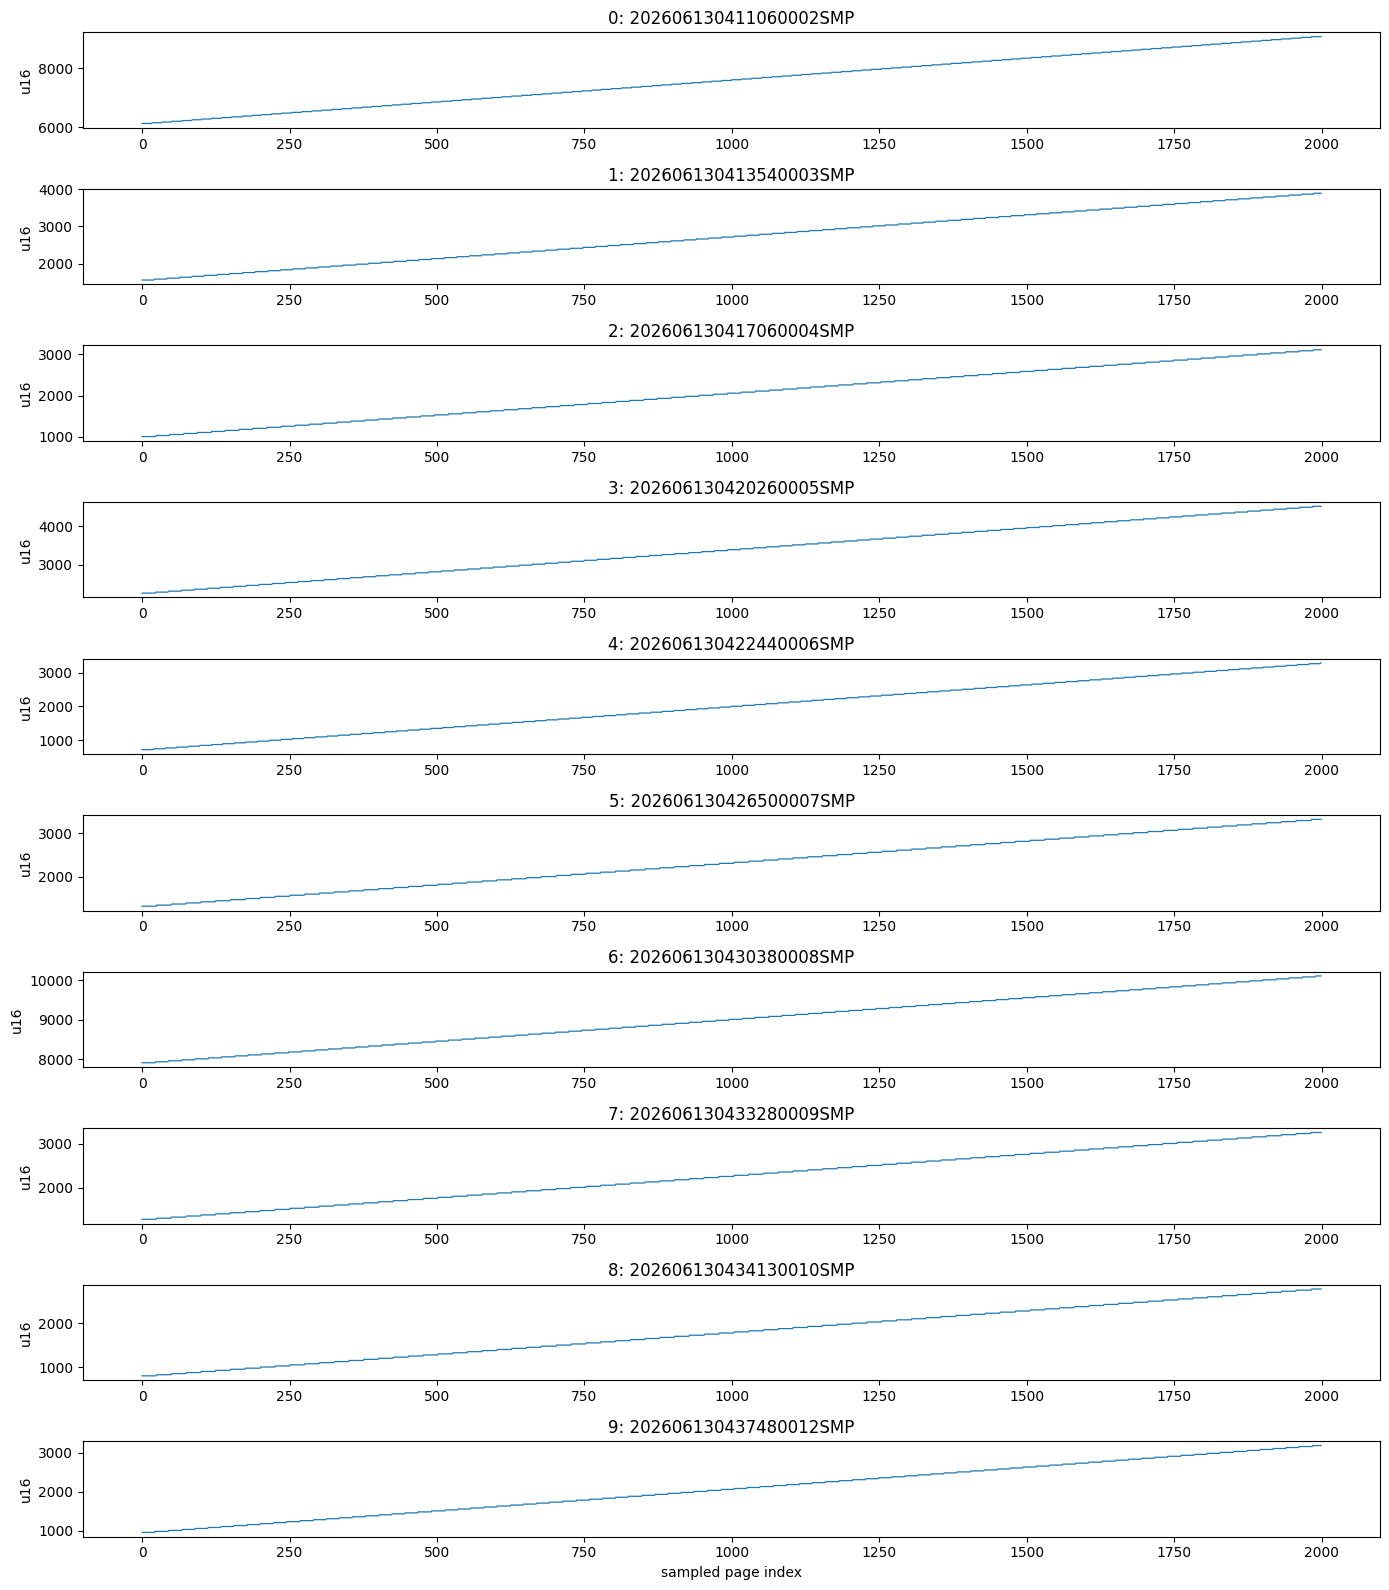

,file_index,recording,n_pages_sampled,min,max,n_unique,change_fraction,median_positive_step,n_negative_steps,min_negative_step,max_negative_step
0,0,202606130411060002SMP,20000,6124,35714,1180,0.058953,25.0,0,0,0
1,1,202606130413540003SMP,20000,1556,25022,936,0.046752,25.0,0,0,0
2,2,202606130417060004SMP,20000,1004,22211,846,0.042252,25.0,0,0,0
3,3,202606130420260005SMP,20000,2258,24997,907,0.045302,25.0,0,0,0
4,4,202606130422440006SMP,20000,727,26327,1021,0.051003,25.0,0,0,0
5,5,202606130426500007SMP,18346,1330,19651,731,0.039793,25.0,0,0,0
6,6,202606130430380008SMP,20000,7906,30067,884,0.044152,25.0,0,0,0
7,7,202606130433280009SMP,15862,1280,17116,632,0.039783,25.0,0,0,0
8,8,202606130434130010SMP,16916,803,17694,674,0.039787,25.0,0,0,0
9,9,202606130437480012SMP,20000,953,23441,897,0.044802,25.0,0,0,0


In [11]:
counter_rows = []

fig, axes = plt.subplots(len(pw_files), 1, figsize=(14, 16), sharex=False)

for file_index, path in enumerate(pw_files):
    pages, info = sample_pw_pages(path)

    byte_1248 = pages[:, 1248].astype(np.uint16)
    byte_1249 = pages[:, 1249].astype(np.uint16)
    counter_candidate = byte_1248 + (byte_1249 << 8)

    diffs = np.diff(counter_candidate.astype(np.int64))
    positive_diffs = diffs[diffs > 0]
    negative_diffs = diffs[diffs < 0]

    counter_rows.append({
        "file_index": file_index,
        "recording": path.parent.parent.name,
        "n_pages_sampled": len(counter_candidate),
        "min": int(counter_candidate.min()),
        "max": int(counter_candidate.max()),
        "n_unique": int(pd.Series(counter_candidate).nunique()),
        "change_fraction": float((counter_candidate[1:] != counter_candidate[:-1]).mean()),
        "median_positive_step": float(np.median(positive_diffs)) if len(positive_diffs) else np.nan,
        "n_negative_steps": int(len(negative_diffs)),
        "min_negative_step": int(negative_diffs.min()) if len(negative_diffs) else 0,
        "max_negative_step": int(negative_diffs.max()) if len(negative_diffs) else 0,
    })

    ax = axes[file_index]
    ax.plot(counter_candidate[:2000], linewidth=0.9)
    ax.set_title(f"{file_index}: {path.parent.parent.name}")
    ax.set_ylabel("u16")

axes[-1].set_xlabel("sampled page index")
plt.tight_layout()
plt.show()

post_header_counter_summary = pd.DataFrame(counter_rows)
display(post_header_counter_summary)

## PW post-header counter cadence

This section measures how often the `1248..1249` counter candidate changes in consecutive native pages.

The previous section showed that bytes `1248` and `1249` form a monotonic `uint16` counter-like field. This section reads consecutive pages from each file and measures the page intervals between counter changes.

This matters because the cadence may indicate whether the counter is tied to page rate, display frame timing, sweep-column timing, or another internal timing index.
 

,file_index,recording,n_pages,n_counter_changes,median_pages_between_changes,min_pages_between_changes,max_pages_between_changes,most_common_page_intervals,median_positive_counter_step,most_common_positive_steps,n_negative_steps
0,0,202606130411060002SMP,29615,1179,25.0,25,26,"{25: 1064, 26: 115}",25.0,"{25: 1064, 26: 115}",0
1,1,202606130413540003SMP,23491,935,25.0,25,26,"{25: 844, 26: 91}",25.0,"{25: 844, 26: 91}",0
2,2,202606130417060004SMP,21232,845,25.0,25,26,"{25: 763, 26: 82}",25.0,"{25: 763, 26: 82}",0
3,3,202606130420260005SMP,22764,906,25.0,25,26,"{25: 817, 26: 89}",25.0,"{25: 817, 26: 89}",0
4,4,202606130422440006SMP,25626,1020,25.0,25,26,"{25: 920, 26: 100}",25.0,"{25: 920, 26: 100}",0
5,5,202606130426500007SMP,18346,730,25.0,25,26,"{25: 659, 26: 71}",25.0,"{25: 659, 26: 71}",0
6,6,202606130430380008SMP,22186,883,25.0,25,26,"{25: 797, 26: 86}",25.0,"{25: 797, 26: 86}",0
7,7,202606130433280009SMP,15862,631,25.0,25,26,"{25: 570, 26: 61}",25.0,"{25: 570, 26: 61}",0
8,8,202606130434130010SMP,16916,673,25.0,25,26,"{25: 607, 26: 66}",25.0,"{25: 607, 26: 66}",0
9,9,202606130437480012SMP,22513,896,25.0,25,26,"{25: 808, 26: 88}",25.0,"{25: 808, 26: 88}",0


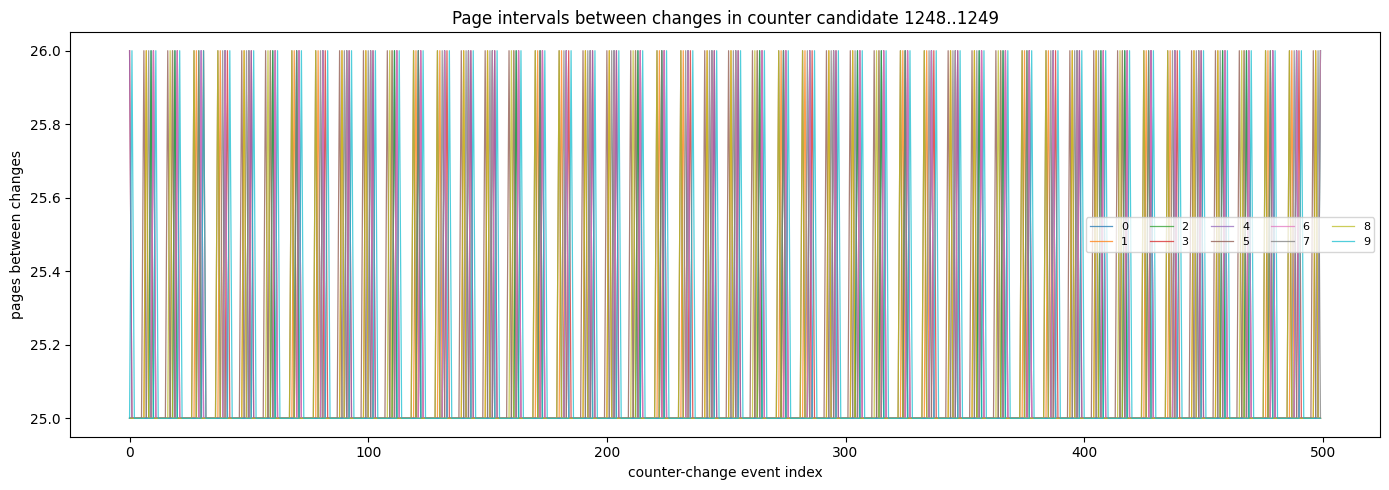

In [12]:
counter_cadence_rows = []

for file_index, path in enumerate(pw_files):
    file_size = path.stat().st_size
    n_pages = file_size // PAGE_SIZE_BYTES

    pages = np.memmap(path, dtype=np.uint8, mode="r", shape=(n_pages, PAGE_SIZE_BYTES))

    byte_1248 = pages[:, 1248].astype(np.uint16)
    byte_1249 = pages[:, 1249].astype(np.uint16)
    counter = byte_1248 + (byte_1249 << 8)

    change_indices = np.flatnonzero(counter[1:] != counter[:-1]) + 1
    intervals = np.diff(np.r_[0, change_indices])

    counter_diffs = np.diff(counter.astype(np.int64))
    positive_steps = counter_diffs[counter_diffs > 0]
    negative_steps = counter_diffs[counter_diffs < 0]

    interval_counts = pd.Series(intervals).value_counts().head(8).to_dict()
    positive_step_counts = pd.Series(positive_steps).value_counts().head(8).to_dict()

    counter_cadence_rows.append({
        "file_index": file_index,
        "recording": path.parent.parent.name,
        "n_pages": int(n_pages),
        "n_counter_changes": int(len(change_indices)),
        "median_pages_between_changes": float(np.median(intervals)) if len(intervals) else np.nan,
        "min_pages_between_changes": int(intervals.min()) if len(intervals) else 0,
        "max_pages_between_changes": int(intervals.max()) if len(intervals) else 0,
        "most_common_page_intervals": interval_counts,
        "median_positive_counter_step": float(np.median(positive_steps)) if len(positive_steps) else np.nan,
        "most_common_positive_steps": positive_step_counts,
        "n_negative_steps": int(len(negative_steps)),
    })

counter_cadence_summary = pd.DataFrame(counter_cadence_rows)
display(counter_cadence_summary)

plt.figure(figsize=(14, 5))

for file_index, path in enumerate(pw_files):
    file_size = path.stat().st_size
    n_pages = file_size // PAGE_SIZE_BYTES

    pages = np.memmap(path, dtype=np.uint8, mode="r", shape=(n_pages, PAGE_SIZE_BYTES))

    counter = (
        pages[:, 1248].astype(np.uint16)
        + (pages[:, 1249].astype(np.uint16) << 8)
    )

    change_indices = np.flatnonzero(counter[1:] != counter[:-1]) + 1
    intervals = np.diff(np.r_[0, change_indices])

    plt.plot(
        intervals[:500],
        linewidth=0.9,
        alpha=0.75,
        label=str(file_index),
    )

plt.title("Page intervals between changes in counter candidate 1248..1249")
plt.xlabel("counter-change event index")
plt.ylabel("pages between changes")
plt.legend(ncol=5, fontsize=8)
plt.tight_layout()
plt.show()

## PW 20 Hz page-group structure

This section tests whether `PW_CinePartition0.bin` has a higher-level 20 Hz grouping pattern.

The previous section showed that bytes `1248..1249` form a counter-like field that changes every `25` or `26` native pages. With the NB06 working page rate of `500 Hz`, this is consistent with a `20 Hz` update rhythm.

This section groups pages by counter value and checks whether byte fields are stable within each group or change continuously inside the group.

This matters because a 20 Hz grouping could represent display/update timing, frame-level timing, or another internal acquisition rhythm. If image-like or spectrogram-like content exists, it may be organized at this slower update rate rather than directly as every 500 Hz page.


,group_index,start_page,end_page_exclusive,group_length_pages,counter_value,variable_offsets_within_group,variable_offsets_0_143,variable_offsets_144_1295
0,0,0,25,25,6124,122,122,0
1,1,25,50,25,6149,122,122,0
2,2,50,75,25,6174,114,114,0
3,3,75,100,25,6199,115,115,0
4,4,100,125,25,6224,122,122,0
5,5,125,150,25,6249,115,115,0
6,6,150,175,25,6274,122,122,0
7,7,175,200,25,6299,115,115,0
8,8,200,225,25,6324,115,115,0
9,9,225,251,26,6349,121,121,0


Group length counts


,group_length_pages,group_count
0,25,1065
1,26,115


Within-group variable offset summary


,variable_offsets_within_group,variable_offsets_0_143,variable_offsets_144_1295
count,1180.000000,1180.000000,1180.0
mean,115.727119,115.727119,0.0
std,6.774079,6.774079,0.0
min,97.000000,97.000000,0.0
25%,114.000000,114.000000,0.0
50%,115.000000,115.000000,0.0
75%,122.000000,122.000000,0.0
max,131.000000,131.000000,0.0


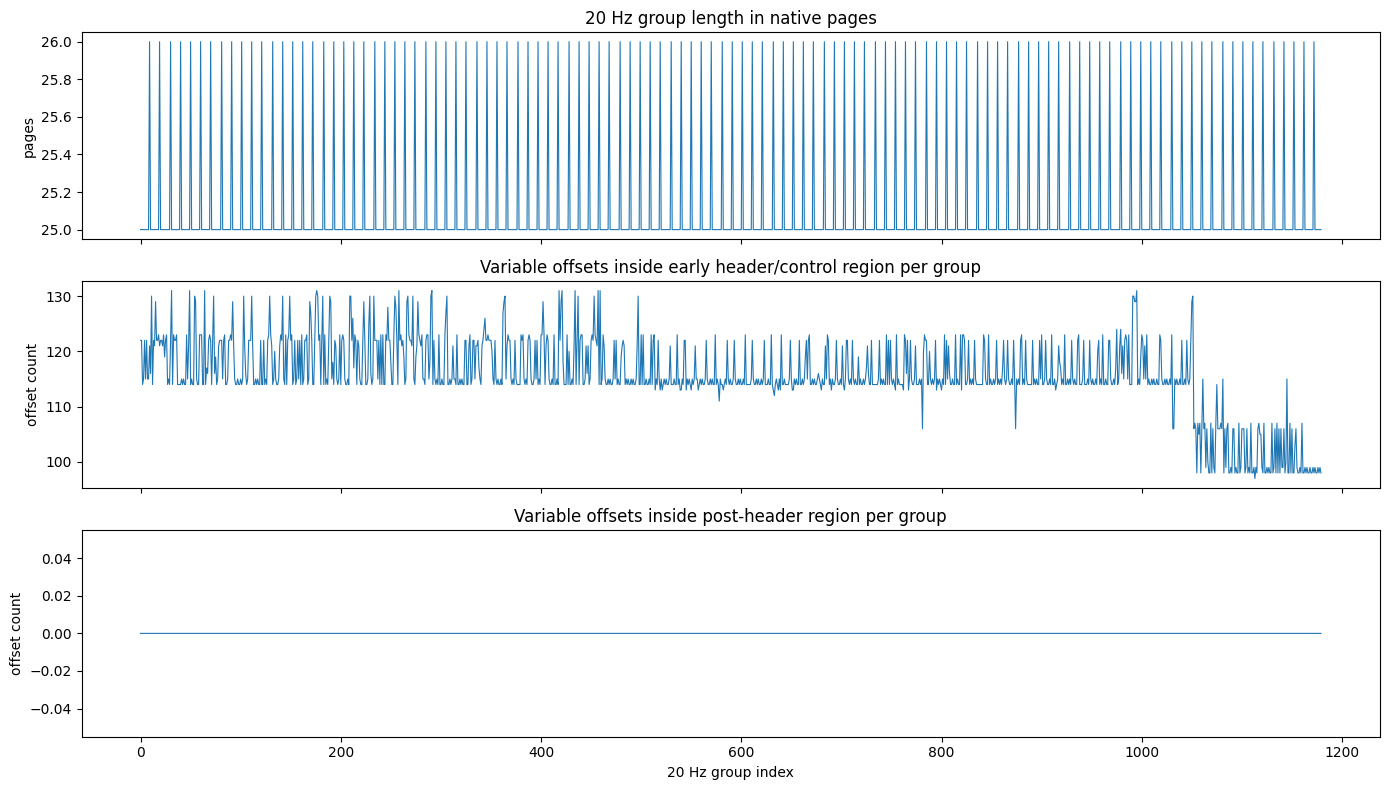

In [13]:
path = pw_files[0]
file_size = path.stat().st_size
n_pages = file_size // PAGE_SIZE_BYTES

pages = np.memmap(path, dtype=np.uint8, mode="r", shape=(n_pages, PAGE_SIZE_BYTES))

counter = (
    pages[:, 1248].astype(np.uint16)
    + (pages[:, 1249].astype(np.uint16) << 8)
)

group_start_indices = np.r_[0, np.flatnonzero(counter[1:] != counter[:-1]) + 1]
group_end_indices = np.r_[group_start_indices[1:], n_pages]
group_lengths = group_end_indices - group_start_indices

group_rows = []

for group_index, (start, end) in enumerate(zip(group_start_indices, group_end_indices)):
    group_pages = pages[start:end]

    n_variable_offsets_within_group = int((group_pages.max(axis=0) != group_pages.min(axis=0)).sum())

    early_variable_offsets = int(
        (group_pages[:, :144].max(axis=0) != group_pages[:, :144].min(axis=0)).sum()
    )

    post_header_variable_offsets = int(
        (group_pages[:, 144:].max(axis=0) != group_pages[:, 144:].min(axis=0)).sum()
    )

    group_rows.append({
        "group_index": group_index,
        "start_page": int(start),
        "end_page_exclusive": int(end),
        "group_length_pages": int(end - start),
        "counter_value": int(counter[start]),
        "variable_offsets_within_group": n_variable_offsets_within_group,
        "variable_offsets_0_143": early_variable_offsets,
        "variable_offsets_144_1295": post_header_variable_offsets,
    })

page_group_summary0 = pd.DataFrame(group_rows)

display(page_group_summary0.head(30))

print("Group length counts")
display(
    page_group_summary0["group_length_pages"]
    .value_counts()
    .sort_index()
    .rename_axis("group_length_pages")
    .reset_index(name="group_count")
)

print("Within-group variable offset summary")
display(
    page_group_summary0[
        [
            "variable_offsets_within_group",
            "variable_offsets_0_143",
            "variable_offsets_144_1295",
        ]
    ].describe()
)

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(page_group_summary0["group_length_pages"], linewidth=0.8)
axes[0].set_title("20 Hz group length in native pages")
axes[0].set_ylabel("pages")

axes[1].plot(page_group_summary0["variable_offsets_0_143"], linewidth=0.8)
axes[1].set_title("Variable offsets inside early header/control region per group")
axes[1].set_ylabel("offset count")

axes[2].plot(page_group_summary0["variable_offsets_144_1295"], linewidth=0.8)
axes[2].set_title("Variable offsets inside post-header region per group")
axes[2].set_ylabel("offset count")
axes[2].set_xlabel("20 Hz group index")

plt.tight_layout()
plt.show()

## PW post-header stability excluding counter fields

This section tests whether the post-header region contains any time-varying bytes after excluding the known counter-like fields at offsets `1248..1249`.

The previous section showed that bytes after `144` are stable within each 20 Hz counter group. This section checks stability across the full recording and across all recordings.

This matters because a native image-like or spectrogram-like payload should usually contain broader time-varying data. If the post-header region is stable after removing the counter fields, it is unlikely to contain a time-varying image/spectrogram buffer.


In [14]:

excluded_offsets = {1248, 1249}
post_header_offsets = [offset for offset in range(144, PAGE_SIZE_BYTES) if offset not in excluded_offsets]

stability_rows = []

for file_index, path in enumerate(pw_files):
    pages, info = sample_pw_pages(path)

    post_header = pages[:, post_header_offsets]
    n_unique_by_offset = np.array([
        pd.Series(post_header[:, i]).nunique()
        for i in range(post_header.shape[1])
    ])

    variable_mask = n_unique_by_offset > 1
    variable_offsets = np.array(post_header_offsets)[variable_mask]

    stability_rows.append({
        "file_index": file_index,
        "recording": path.parent.parent.name,
        "sampled_pages": info["sampled_pages"],
        "checked_offsets": len(post_header_offsets),
        "variable_offsets_excluding_1248_1249": int(variable_mask.sum()),
        "max_unique_values": int(n_unique_by_offset.max()),
        "first_variable_offsets": ", ".join(str(int(x)) for x in variable_offsets[:20]),
    })

post_header_stability_summary = pd.DataFrame(stability_rows)
display(post_header_stability_summary)

,file_index,recording,sampled_pages,checked_offsets,variable_offsets_excluding_1248_1249,max_unique_values,first_variable_offsets
0,0,202606130411060002SMP,20000,1150,0,1,
1,1,202606130413540003SMP,20000,1150,0,1,
2,2,202606130417060004SMP,20000,1150,6,2,"1168, 1169, 1170, 1171, 1172, 1173"
3,3,202606130420260005SMP,20000,1150,0,1,
4,4,202606130422440006SMP,20000,1150,0,1,
5,5,202606130426500007SMP,18346,1150,0,1,
6,6,202606130430380008SMP,20000,1150,6,2,"1168, 1169, 1170, 1171, 1172, 1173"
7,7,202606130433280009SMP,15862,1150,0,1,
8,8,202606130434130010SMP,16916,1150,0,1,
9,9,202606130437480012SMP,20000,1150,6,2,"1168, 1169, 1170, 1171, 1172, 1173"


## PW rare post-header two-state block

This section inspects the rare post-header byte variation at offsets `1168..1173`.

The previous section showed that most recordings have no post-header time variation after excluding the counter-like bytes `1248..1249`. Three recordings have a small two-state block at offsets `1168..1173`.

This matters because exception bytes should be explained before the post-header region is treated as stable. A six-byte two-state block is more consistent with a flag/status field than with image-like or spectrogram-like payload data, but it should be checked directly.


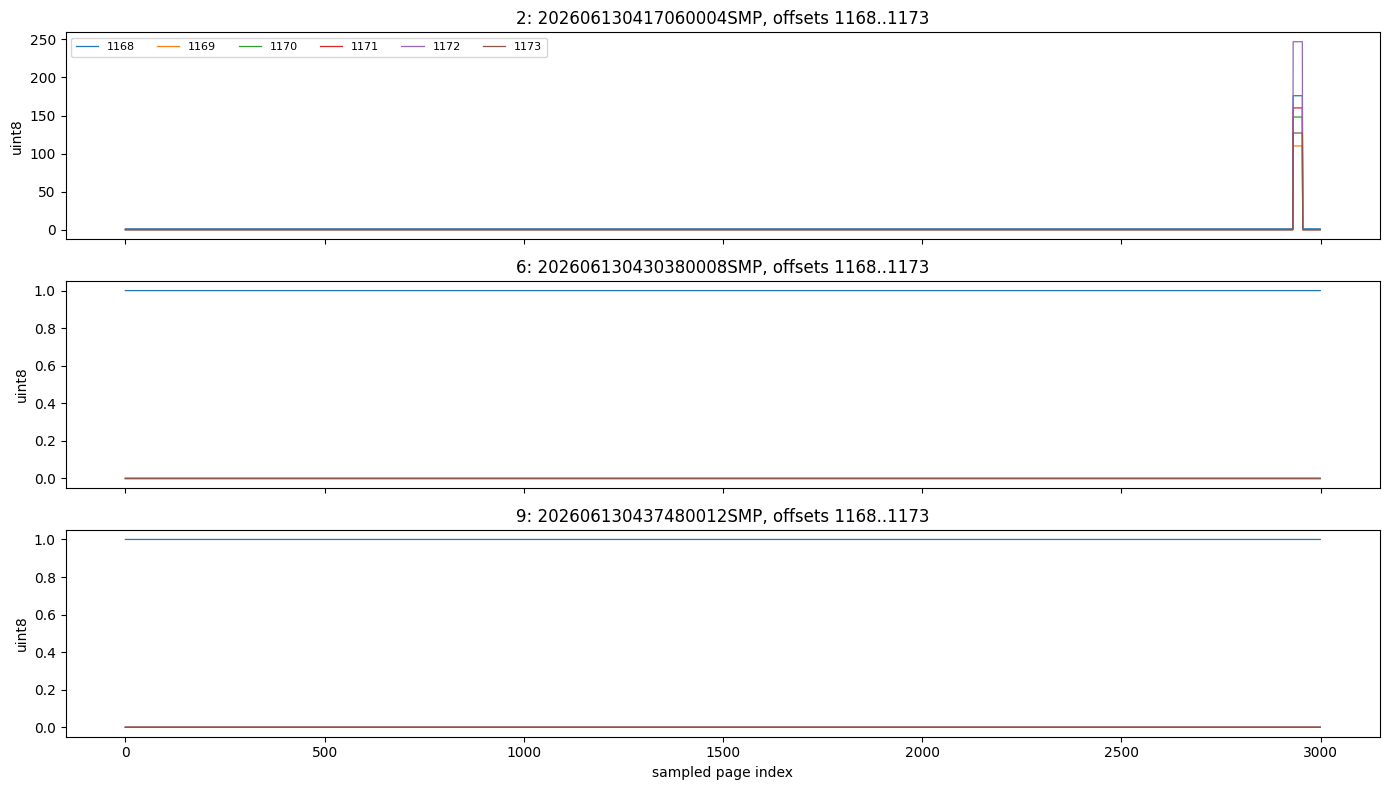

,file_index,recording,byte_offset,min,max,n_unique,value_counts
0,2,202606130417060004SMP,1168,1,176,2,"{1: 19976, 176: 24}"
1,2,202606130417060004SMP,1169,0,110,2,"{0: 19976, 110: 24}"
2,2,202606130417060004SMP,1170,0,148,2,"{0: 19976, 148: 24}"
3,2,202606130417060004SMP,1171,0,160,2,"{0: 19976, 160: 24}"
4,2,202606130417060004SMP,1172,0,247,2,"{0: 19976, 247: 24}"
5,2,202606130417060004SMP,1173,0,127,2,"{0: 19976, 127: 24}"
6,6,202606130430380008SMP,1168,1,176,2,"{1: 19978, 176: 22}"
7,6,202606130430380008SMP,1169,0,110,2,"{0: 19978, 110: 22}"
8,6,202606130430380008SMP,1170,0,148,2,"{0: 19978, 148: 22}"
9,6,202606130430380008SMP,1171,0,160,2,"{0: 19978, 160: 22}"


In [15]:
rare_offsets = list(range(1168, 1174))
affected_file_indices = [2, 6, 9]

rare_rows = []

fig, axes = plt.subplots(len(affected_file_indices), 1, figsize=(14, 8), sharex=True)

for ax, file_index in zip(axes, affected_file_indices):
    path = pw_files[file_index]
    pages, info = sample_pw_pages(path)

    block = pages[:, rare_offsets]

    for offset_index, offset in enumerate(rare_offsets):
        values = block[:, offset_index]

        rare_rows.append({
            "file_index": file_index,
            "recording": path.parent.parent.name,
            "byte_offset": offset,
            "min": int(values.min()),
            "max": int(values.max()),
            "n_unique": int(pd.Series(values).nunique()),
            "value_counts": pd.Series(values).value_counts().to_dict(),
        })

        ax.plot(values[:3000], linewidth=0.9, label=str(offset))

    ax.set_title(f"{file_index}: {path.parent.parent.name}, offsets 1168..1173")
    ax.set_ylabel("uint8")

axes[-1].set_xlabel("sampled page index")
axes[0].legend(ncol=6, fontsize=8)
plt.tight_layout()
plt.show()

rare_post_header_block_summary = pd.DataFrame(rare_rows)
display(rare_post_header_block_summary)

## PW rare post-header block event location

This section locates the rare two-state block at offsets `1168..1173` in full page coordinates.

The previous section showed that three recordings contain a rare switch from the normal byte pattern to a second six-byte pattern. This section checks whether the rare pattern appears as one contiguous event, several events, or scattered isolated pages.

This matters because a short contiguous event is more consistent with a transient status/config/state condition than with image-like or spectrogram-like payload data.


In [16]:
rare_offsets = list(range(1168, 1174))
affected_file_indices = [2, 6, 9]

event_rows = []
event_byte_rows = []

for file_index in affected_file_indices:
    path = pw_files[file_index]
    n_pages = path.stat().st_size // PAGE_SIZE_BYTES
    pages = np.memmap(path, dtype=np.uint8, mode="r", shape=(n_pages, PAGE_SIZE_BYTES))

    block = np.asarray(pages[:, rare_offsets])
    rare_mask = block[:, 0] == 176

    rare_indices = np.flatnonzero(rare_mask)

    if len(rare_indices) > 0:
        split_points = np.flatnonzero(np.diff(rare_indices) > 1) + 1
        event_groups = np.split(rare_indices, split_points)
    else:
        event_groups = []

    for event_index, indices in enumerate(event_groups):
        start_page = int(indices[0])
        end_page = int(indices[-1])
        event_rows.append({
            "file_index": file_index,
            "recording": path.parent.parent.name,
            "event_index": event_index,
            "start_page": start_page,
            "end_page": end_page,
            "length_pages": int(end_page - start_page + 1),
            "start_time_s_at_500hz": start_page / 500,
            "end_time_s_at_500hz": end_page / 500,
        })

    for page_index in rare_indices[:20]:
        values = pages[page_index, 1160:1184]
        event_byte_rows.append({
            "file_index": file_index,
            "recording": path.parent.parent.name,
            "page_index": int(page_index),
            "bytes_1160_1183_hex": " ".join(f"{int(v):02X}" for v in values),
        })

rare_block_events = pd.DataFrame(event_rows)
rare_block_context_bytes = pd.DataFrame(event_byte_rows)

print("Rare block events")
display(rare_block_events)

print("First rare-event context bytes")
display(rare_block_context_bytes)

Rare block events


,file_index,recording,event_index,start_page,end_page,length_pages,start_time_s_at_500hz,end_time_s_at_500hz
0,2,202606130417060004SMP,0,3112,3136,25,6.224,6.272
1,6,202606130430380008SMP,0,16840,16864,25,33.680,33.728
2,9,202606130437480012SMP,0,19627,19651,25,39.254,39.302


First rare-event context bytes


,file_index,recording,page_index,bytes_1160_1183_hex
0,2,202606130417060004SMP,3112,D0 B4 E9 65 1C 02 00 00 B0 6E 94 A0 F7 7F 00 0...
1,2,202606130417060004SMP,3113,D0 B4 E9 65 1C 02 00 00 B0 6E 94 A0 F7 7F 00 0...
2,2,202606130417060004SMP,3114,D0 B4 E9 65 1C 02 00 00 B0 6E 94 A0 F7 7F 00 0...
3,2,202606130417060004SMP,3115,D0 B4 E9 65 1C 02 00 00 B0 6E 94 A0 F7 7F 00 0...
4,2,202606130417060004SMP,3116,D0 B4 E9 65 1C 02 00 00 B0 6E 94 A0 F7 7F 00 0...
5,2,202606130417060004SMP,3117,D0 B4 E9 65 1C 02 00 00 B0 6E 94 A0 F7 7F 00 0...
6,2,202606130417060004SMP,3118,D0 B4 E9 65 1C 02 00 00 B0 6E 94 A0 F7 7F 00 0...
7,2,202606130417060004SMP,3119,D0 B4 E9 65 1C 02 00 00 B0 6E 94 A0 F7 7F 00 0...
8,2,202606130417060004SMP,3120,D0 B4 E9 65 1C 02 00 00 B0 6E 94 A0 F7 7F 00 0...
9,2,202606130417060004SMP,3121,D0 B4 E9 65 1C 02 00 00 B0 6E 94 A0 F7 7F 00 0...


### PW rare post-header block event interpretation

Result classification: useful positive result.

The rare post-header block at offsets `1168..1173` appears as one contiguous event in each affected recording.

Each event lasts exactly `25` native pages:

- `202606130417060004SMP`: pages `3112..3136`
- `202606130430380008SMP`: pages `16840..16864`
- `202606130437480012SMP`: pages `19627..19651`

At the working page rate of `500 Hz`, each event lasts approximately `0.05 s`, which matches one 20 Hz counter group.

The rare byte pattern is stable during the event and appears together across all six offsets. This is more consistent with a short status/config/state condition than with image-like or spectrogram-like payload data.

This closes the small post-header exception for the current NB10 search.

Working interpretation:

- offsets `0..143` contain dynamic page-level control/state records,
- offsets `1168..1173` contain a rare one-group state/config-like event in three recordings,
- offsets `1248..1249` contain a 20 Hz counter-like field,
- offset `1265` is recording-specific and constant within each recording,
- the remaining post-header region is stable under the current 1296-byte page interpretation.

This does not support a time-varying image/video/spectrogram-like payload inside `PW_CinePartition0.bin`.

## PW dynamic records from NB06 parser

This section returns to the NB06 interpretation of `PW_CinePartition0.bin`.

NB06 found that the strongest PW-related dynamic structure is not a broad raster payload, but a compact repeated record block at offsets `16..143`.

This section reuses that idea and inspects the 16 dynamic 8-byte records as the main candidate spectrogram-related state block.

The goal is to test whether the record fields behave like phase bins, sweep positions, spectral bins, or other structured PW rendering/acquisition state.


,record_index,code_n_unique,code_min_hex,code_max_hex,value_finite_fraction,value_min,value_max,value_mean,value_std,value_n_unique_rounded_6
0,0,45,0x00000000,0xF96F96F9,1.0,-4.611603,4.628555,0.046023,3.566428,18358
1,1,45,0x00000000,0xF96F96F9,1.0,-4.788107,4.542149,-1.450180,3.228045,18275
2,2,45,0x00000000,0xF96F96F9,1.0,-4.784433,4.625485,0.045611,3.566642,18306
3,3,45,0x00000000,0xF96F96F9,1.0,-4.611334,4.667790,-1.448638,3.228371,18247
4,4,45,0x00000000,0xF96F96F9,1.0,-4.609322,4.868809,0.047449,3.566871,18410
5,5,45,0x00000000,0xF96F96F9,1.0,-4.612229,4.781741,-1.448901,3.228378,18197
6,6,45,0x00000000,0xF96F96F9,1.0,-4.595934,4.717939,0.047524,3.566613,18362
7,7,45,0x00000000,0xF96F96F9,1.0,-4.981574,4.516038,-1.451095,3.227375,18285
8,8,45,0x00000000,0xF96F96F9,1.0,-4.951531,4.628239,0.044161,3.566438,18382
9,9,45,0x00000000,0xF96F96F9,1.0,-4.612596,4.504272,-1.451318,3.227342,18261


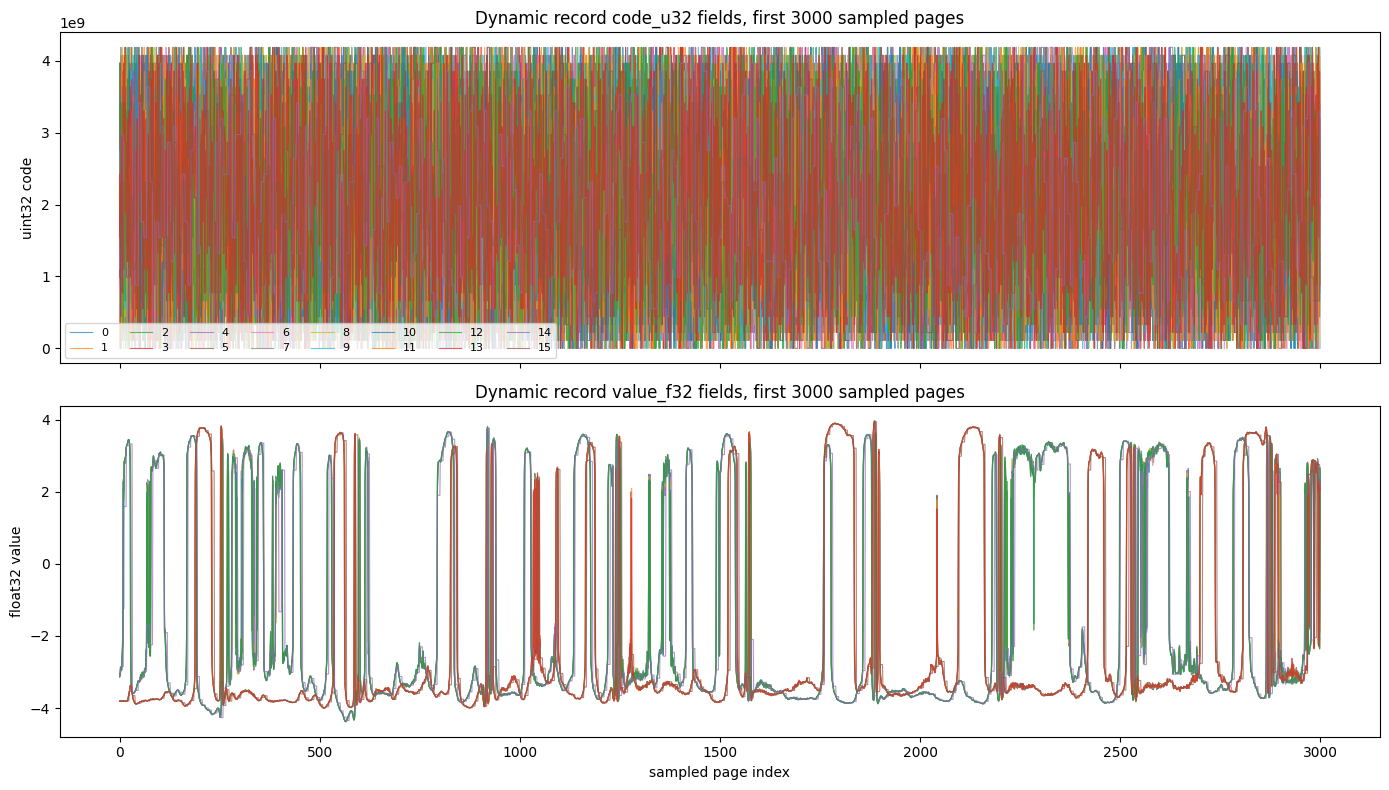

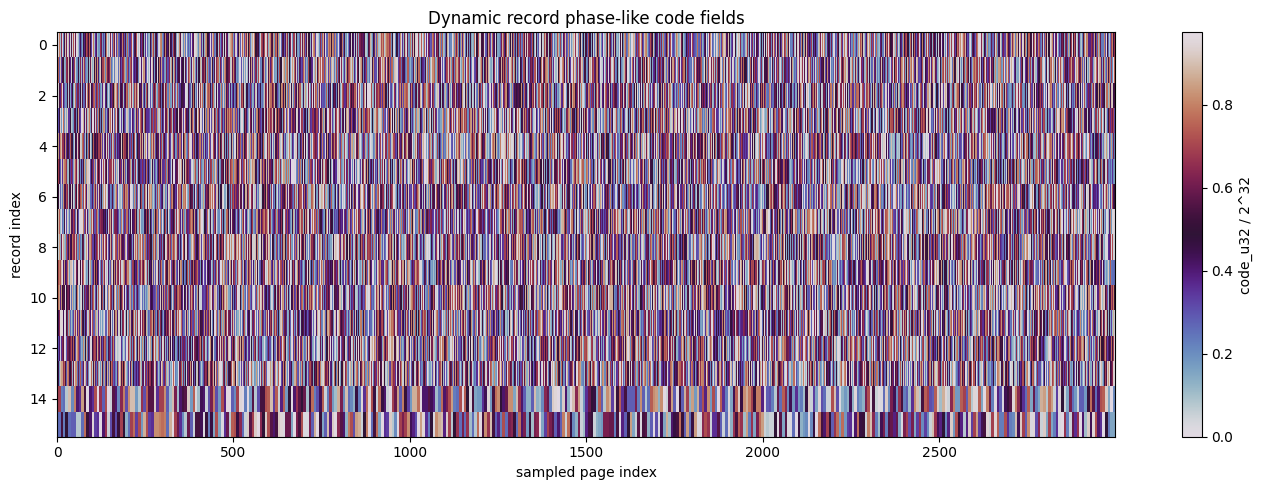

In [17]:
pages0, info0 = sample_pw_pages(pw_files[0])

dynamic_block = pages0[:, 16:144]
records = dynamic_block.reshape(dynamic_block.shape[0], 16, 8)

field_rows = []

for record_index in range(records.shape[1]):
    record = records[:, record_index, :]

    code_u32 = (
        record[:, 0].astype(np.uint32)
        | (record[:, 1].astype(np.uint32) << 8)
        | (record[:, 2].astype(np.uint32) << 16)
        | (record[:, 3].astype(np.uint32) << 24)
    )

    value_f32 = record[:, 4:8].copy().view("<f4").reshape(-1)

    finite_mask = np.isfinite(value_f32)

    field_rows.append({
        "record_index": record_index,
        "code_n_unique": int(pd.Series(code_u32).nunique()),
        "code_min_hex": f"0x{int(code_u32.min()):08X}",
        "code_max_hex": f"0x{int(code_u32.max()):08X}",
        "value_finite_fraction": float(finite_mask.mean()),
        "value_min": float(np.nanmin(value_f32[finite_mask])) if finite_mask.any() else np.nan,
        "value_max": float(np.nanmax(value_f32[finite_mask])) if finite_mask.any() else np.nan,
        "value_mean": float(np.nanmean(value_f32[finite_mask])) if finite_mask.any() else np.nan,
        "value_std": float(np.nanstd(value_f32[finite_mask])) if finite_mask.any() else np.nan,
        "value_n_unique_rounded_6": int(pd.Series(np.round(value_f32[finite_mask], 6)).nunique()) if finite_mask.any() else 0,
    })

dynamic_record_field_summary0 = pd.DataFrame(field_rows)
display(dynamic_record_field_summary0)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for record_index in range(16):
    record = records[:, record_index, :]

    code_u32 = (
        record[:, 0].astype(np.uint32)
        | (record[:, 1].astype(np.uint32) << 8)
        | (record[:, 2].astype(np.uint32) << 16)
        | (record[:, 3].astype(np.uint32) << 24)
    )

    value_f32 = record[:, 4:8].copy().view("<f4").reshape(-1)

    axes[0].plot(code_u32[:3000], linewidth=0.8, alpha=0.7, label=str(record_index))
    axes[1].plot(value_f32[:3000], linewidth=0.8, alpha=0.7, label=str(record_index))

axes[0].set_title("Dynamic record code_u32 fields, first 3000 sampled pages")
axes[0].set_ylabel("uint32 code")

axes[1].set_title("Dynamic record value_f32 fields, first 3000 sampled pages")
axes[1].set_ylabel("float32 value")
axes[1].set_xlabel("sampled page index")

axes[0].legend(ncol=8, fontsize=8)
plt.tight_layout()
plt.show()

phase_rows = []

for record_index in range(16):
    record = records[:, record_index, :]

    code_u32 = (
        record[:, 0].astype(np.uint32)
        | (record[:, 1].astype(np.uint32) << 8)
        | (record[:, 2].astype(np.uint32) << 16)
        | (record[:, 3].astype(np.uint32) << 24)
    )

    phase_0_1 = code_u32.astype(np.float64) / (2 ** 32)

    phase_rows.append(pd.DataFrame({
        "page_sample_index": np.arange(len(phase_0_1)),
        "record_index": record_index,
        "phase_0_1": phase_0_1,
    }))

phase_long0 = pd.concat(phase_rows, ignore_index=True)

phase_matrix = (
    phase_long0[phase_long0["page_sample_index"] < 3000]
    .pivot(index="page_sample_index", columns="record_index", values="phase_0_1")
)

plt.figure(figsize=(14, 5))
plt.imshow(
    phase_matrix.T,
    aspect="auto",
    interpolation="nearest",
    cmap="twilight",
)
plt.colorbar(label="code_u32 / 2^32")
plt.title("Dynamic record phase-like code fields")
plt.xlabel("sampled page index")
plt.ylabel("record index")
plt.tight_layout()
plt.show()

## PW dynamic record codebook

This section inspects the 45 discrete `code_u32` values found in each dynamic PW record.

The previous section showed that every dynamic record has exactly 45 unique code values and that all records share the same code range. This section checks whether those code values form a shared ordered codebook and whether they behave like phase/bin states.

This matters because a shared 45-state codebook could represent phase bins, sweep positions, processing states, or compact spectral-rendering state. It is not enough by itself to prove a decoded spectrogram.


,code_u32,code_hex,phase_0_1,records_present,total_count,mean_value_across_records,std_value_across_records
0,0,0x00000000,0.000000,16,8300,-0.656857,0.808498
1,110127366,0x06906906,0.025641,16,8074,-0.786415,0.710092
2,220254733,0x0D20D20D,0.051282,16,8460,-0.741726,0.817096
3,330382099,0x13B13B13,0.076923,16,5399,-0.569672,0.989763
4,330382100,0x13B13B14,0.076923,16,2856,-0.764312,0.581542
5,440509466,0x1A41A41A,0.102564,16,8139,-0.569420,0.830671
6,550636833,0x20D20D21,0.128205,16,8335,-0.626445,0.778621
7,660764199,0x27627627,0.153846,16,8390,-0.695104,0.779442
8,770891566,0x2DF2DF2E,0.179487,16,8223,-0.786511,0.815370
9,881018932,0x34834834,0.205128,16,8257,-0.684638,0.763461


Records present per code


,records_present,code_count
0,16,45


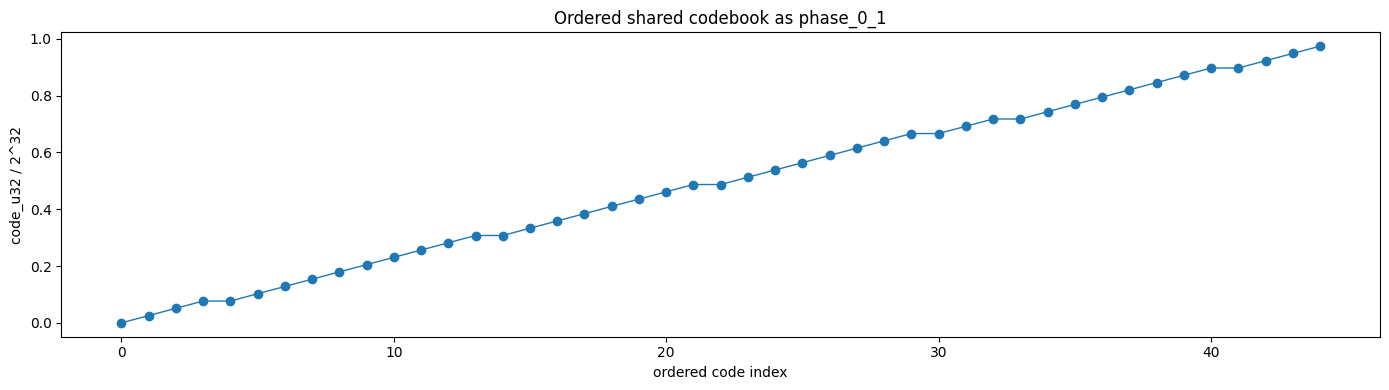

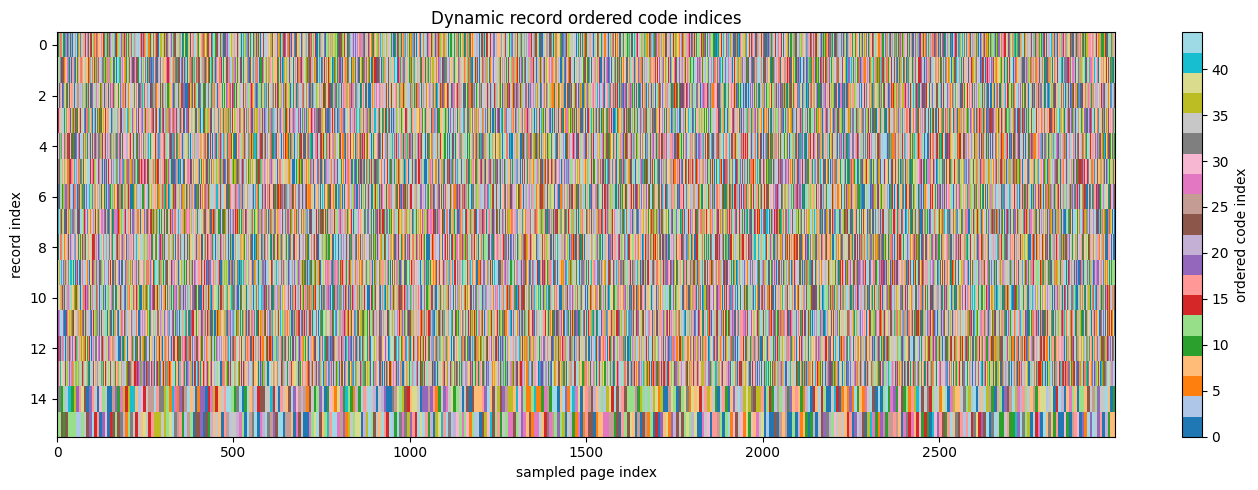

In [18]:
code_rows = []

for record_index in range(16):
    record = records[:, record_index, :]

    code_u32 = (
        record[:, 0].astype(np.uint32)
        | (record[:, 1].astype(np.uint32) << 8)
        | (record[:, 2].astype(np.uint32) << 16)
        | (record[:, 3].astype(np.uint32) << 24)
    )

    value_f32 = record[:, 4:8].copy().view("<f4").reshape(-1)

    counts = pd.Series(code_u32).value_counts().sort_index()

    for code_value, count in counts.items():
        mask = code_u32 == code_value
        code_rows.append({
            "record_index": record_index,
            "code_u32": int(code_value),
            "code_hex": f"0x{int(code_value):08X}",
            "phase_0_1": float(int(code_value) / (2 ** 32)),
            "count": int(count),
            "value_mean": float(value_f32[mask].mean()),
            "value_std": float(value_f32[mask].std()),
            "value_min": float(value_f32[mask].min()),
            "value_max": float(value_f32[mask].max()),
        })

dynamic_codebook0 = pd.DataFrame(code_rows)

shared_code_counts = (
    dynamic_codebook0
    .groupby(["code_u32", "code_hex", "phase_0_1"], as_index=False)
    .agg(
        records_present=("record_index", "nunique"),
        total_count=("count", "sum"),
        mean_value_across_records=("value_mean", "mean"),
        std_value_across_records=("value_mean", "std"),
    )
    .sort_values("code_u32")
)

display(shared_code_counts)

print("Records present per code")
display(
    shared_code_counts["records_present"]
    .value_counts()
    .sort_index()
    .rename_axis("records_present")
    .reset_index(name="code_count")
)

plt.figure(figsize=(14, 4))
plt.plot(shared_code_counts["phase_0_1"], marker="o", linewidth=1)
plt.title("Ordered shared codebook as phase_0_1")
plt.xlabel("ordered code index")
plt.ylabel("code_u32 / 2^32")
plt.tight_layout()
plt.show()

code_index_map = {
    code: index
    for index, code in enumerate(shared_code_counts["code_u32"].tolist())
}

code_index_matrix = np.zeros((16, min(3000, records.shape[0])), dtype=np.int16)

for record_index in range(16):
    record = records[:, record_index, :]

    code_u32 = (
        record[:, 0].astype(np.uint32)
        | (record[:, 1].astype(np.uint32) << 8)
        | (record[:, 2].astype(np.uint32) << 16)
        | (record[:, 3].astype(np.uint32) << 24)
    )

    code_index_matrix[record_index, :] = [
        code_index_map[int(code)] for code in code_u32[:code_index_matrix.shape[1]]
    ]

plt.figure(figsize=(14, 5))
plt.imshow(
    code_index_matrix,
    aspect="auto",
    interpolation="nearest",
    cmap="tab20",
)
plt.colorbar(label="ordered code index")
plt.title("Dynamic record ordered code indices")
plt.xlabel("sampled page index")
plt.ylabel("record index")
plt.tight_layout()
plt.show()

## PW dynamic value by phase-code state

This section tests how the `value_f32` field depends on the shared phase-code state.

The previous section showed that all 16 dynamic records share a structured 45-state fixed-point-like codebook. This section groups `value_f32` by record index and ordered code index.

This matters because a spectrogram-related state block might show stable value patterns by phase/bin and record position. If values are mostly state-like transitions with no stable phase profile, that weakens the spectrogram-reconstruction path.



,record_index,code_u32,code_index,count,value_mean,value_std,value_min,value_max
0,0,0,0,515,0.238012,3.567678,-4.248047,4.620117
1,0,110127366,1,501,0.096778,3.548457,-4.330128,4.250782
2,0,220254733,2,512,0.020673,3.542722,-4.414163,4.334329
3,0,330382099,3,302,0.305907,3.515761,-4.187894,4.276517
4,0,330382100,4,194,-0.281130,3.596556,-4.102933,4.115140
...,...,...,...,...,...,...,...,...
75,1,2863311531,30,54,-1.604290,3.274859,-4.024983,4.031819
76,1,2973438897,31,464,-1.381478,3.232542,-4.454965,4.164926
77,1,3083566263,32,43,-1.547026,3.254850,-3.996306,3.990203
78,1,3083566264,33,473,-1.444613,3.229627,-4.594786,4.157164


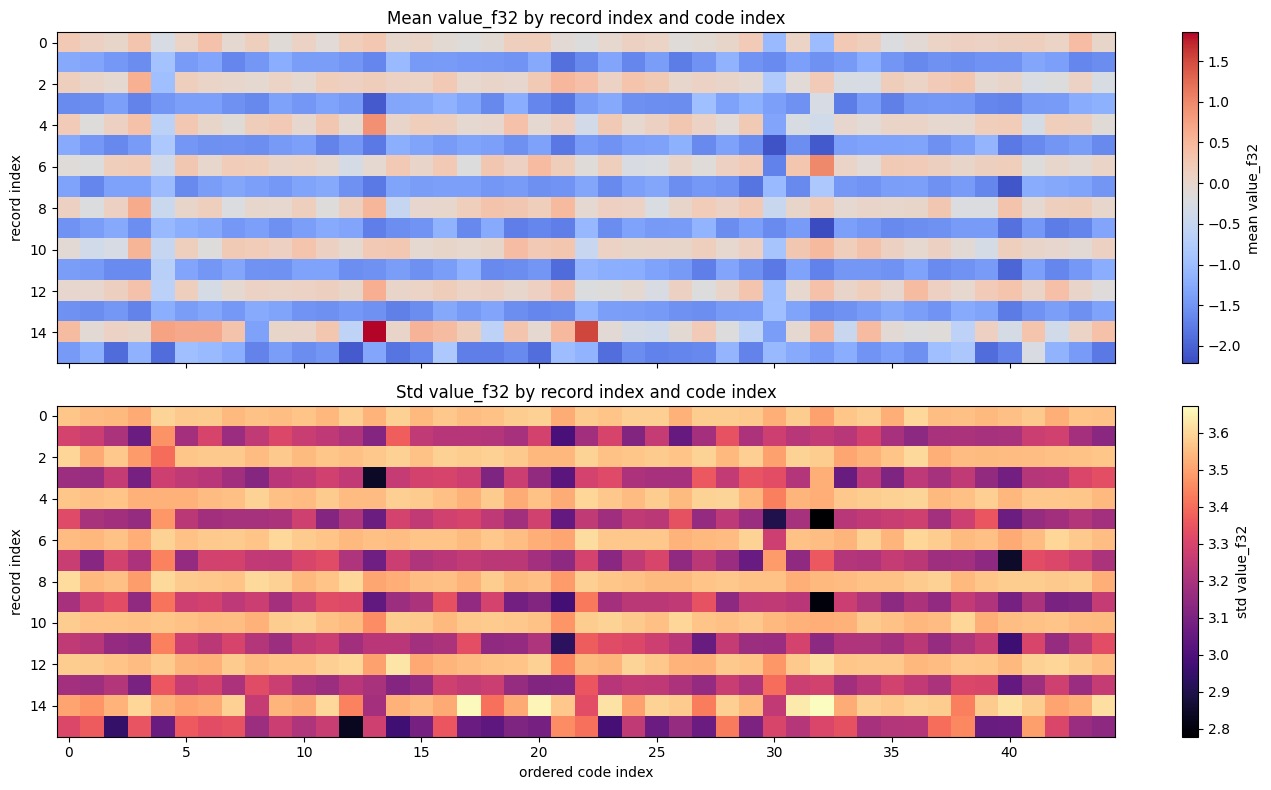

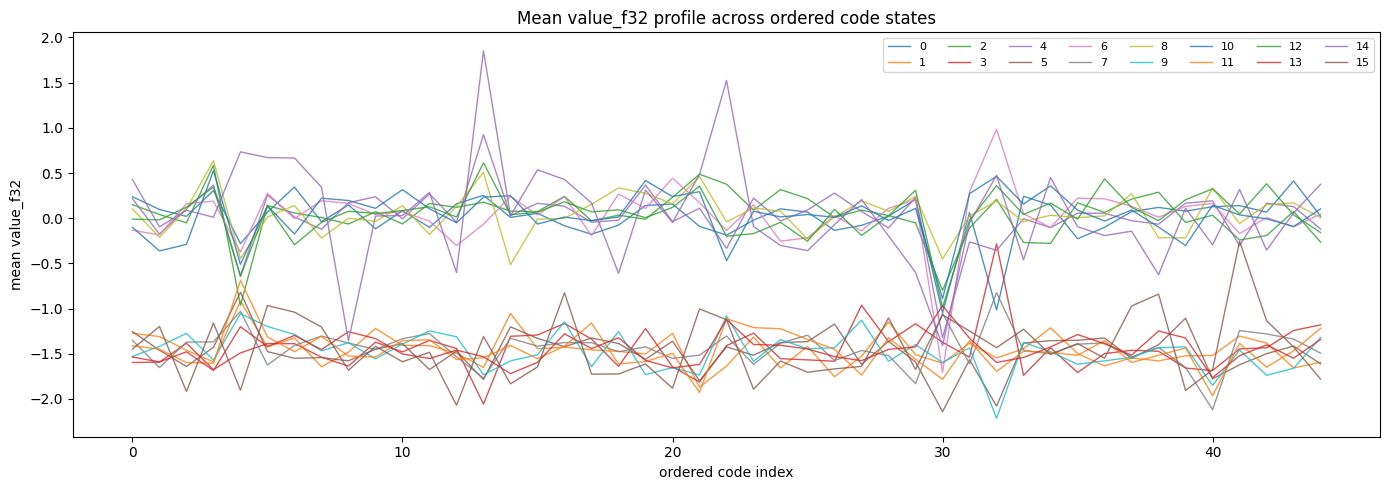

In [19]:
code_index_map = {
    int(code): index
    for index, code in enumerate(shared_code_counts["code_u32"].tolist())
}

value_rows = []

for record_index in range(16):
    record = records[:, record_index, :]

    code_u32 = (
        record[:, 0].astype(np.uint32)
        | (record[:, 1].astype(np.uint32) << 8)
        | (record[:, 2].astype(np.uint32) << 16)
        | (record[:, 3].astype(np.uint32) << 24)
    )

    value_f32 = record[:, 4:8].copy().view("<f4").reshape(-1)

    for code_value in np.unique(code_u32):
        mask = code_u32 == code_value
        value_rows.append({
            "record_index": record_index,
            "code_u32": int(code_value),
            "code_index": code_index_map[int(code_value)],
            "count": int(mask.sum()),
            "value_mean": float(value_f32[mask].mean()),
            "value_std": float(value_f32[mask].std()),
            "value_min": float(value_f32[mask].min()),
            "value_max": float(value_f32[mask].max()),
        })

value_by_code0 = pd.DataFrame(value_rows)

mean_matrix = (
    value_by_code0
    .pivot(index="record_index", columns="code_index", values="value_mean")
    .sort_index()
)

std_matrix = (
    value_by_code0
    .pivot(index="record_index", columns="code_index", values="value_std")
    .sort_index()
)

display(value_by_code0.head(80))

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

im0 = axes[0].imshow(
    mean_matrix,
    aspect="auto",
    interpolation="nearest",
    cmap="coolwarm",
)
axes[0].set_title("Mean value_f32 by record index and code index")
axes[0].set_ylabel("record index")
plt.colorbar(im0, ax=axes[0], label="mean value_f32")

im1 = axes[1].imshow(
    std_matrix,
    aspect="auto",
    interpolation="nearest",
    cmap="magma",
)
axes[1].set_title("Std value_f32 by record index and code index")
axes[1].set_ylabel("record index")
axes[1].set_xlabel("ordered code index")
plt.colorbar(im1, ax=axes[1], label="std value_f32")

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
for record_index in range(16):
    plt.plot(
        mean_matrix.columns,
        mean_matrix.loc[record_index],
        linewidth=1,
        alpha=0.8,
        label=str(record_index),
    )

plt.title("Mean value_f32 profile across ordered code states")
plt.xlabel("ordered code index")
plt.ylabel("mean value_f32")
plt.legend(ncol=8, fontsize=8)
plt.tight_layout()
plt.show()

## PW even-odd pair range matrix

This section tests the NB06 even/odd pair-range interpretation as a compact time-continuous matrix.

The previous sections showed that the 16 dynamic records contain a shared phase-codebook and finite `value_f32` fields. NB06 found that even/odd record pairs produced the strongest native PW dynamic signal candidate.

This section computes the range between each even/odd pair and plots the eight pair ranges over time as a small matrix.

This matters because if the dynamic records contain spectrogram-related state, the pair-range matrix may reveal time-continuous structure even though the raw values do not form a full raster payload.



,pair_index,min,max,mean,std,p01,p50,p99
0,0,-8.182680,8.911326,1.496203,3.970807,-7.575892,0.239821,7.933755
1,1,-9.321595,8.449200,1.494249,3.973487,-7.581899,0.238331,7.931504
2,2,-8.309754,8.450708,1.496350,3.971310,-7.580627,0.239442,7.932220
3,3,-8.442595,8.851039,1.498619,3.974901,-7.578671,0.240848,7.934008
4,4,-9.042452,8.453738,1.495480,3.974058,-7.578955,0.239652,7.933619
5,5,-8.883907,8.454620,1.493203,3.969362,-7.582135,0.241320,7.932032
6,6,-8.694918,8.976929,1.497284,3.968938,-7.582768,0.240889,7.933033
7,7,-8.134609,8.445644,1.475536,3.965020,-7.572359,0.244955,7.939422


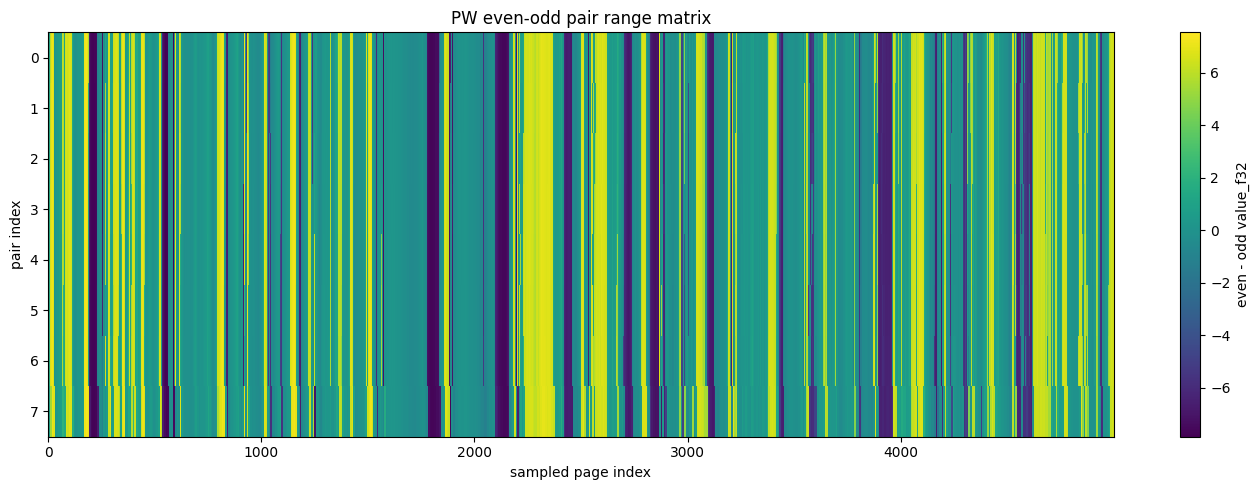

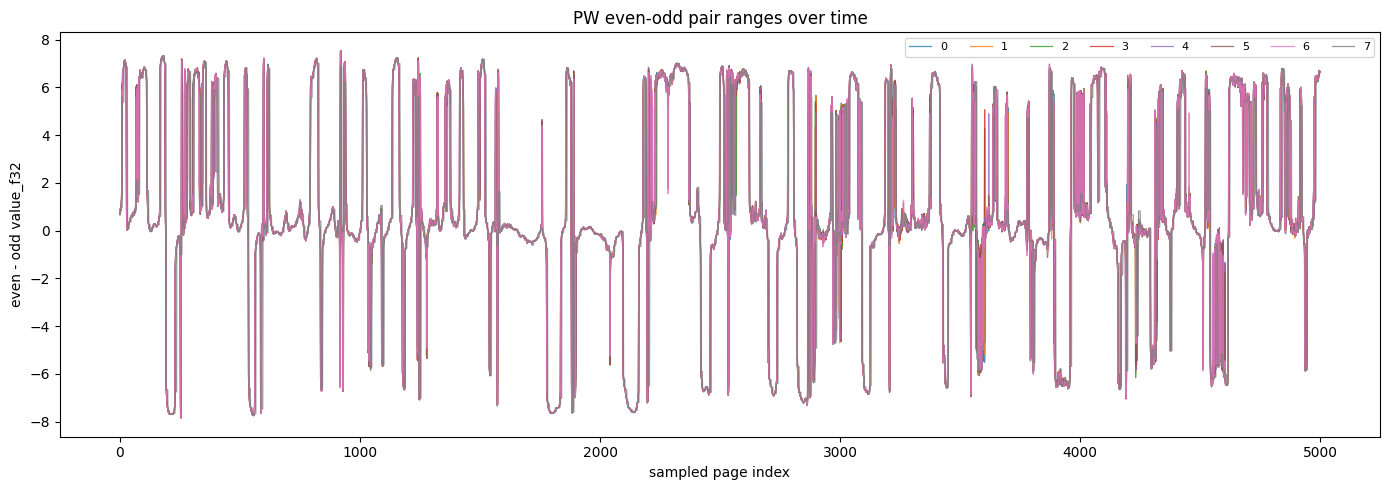

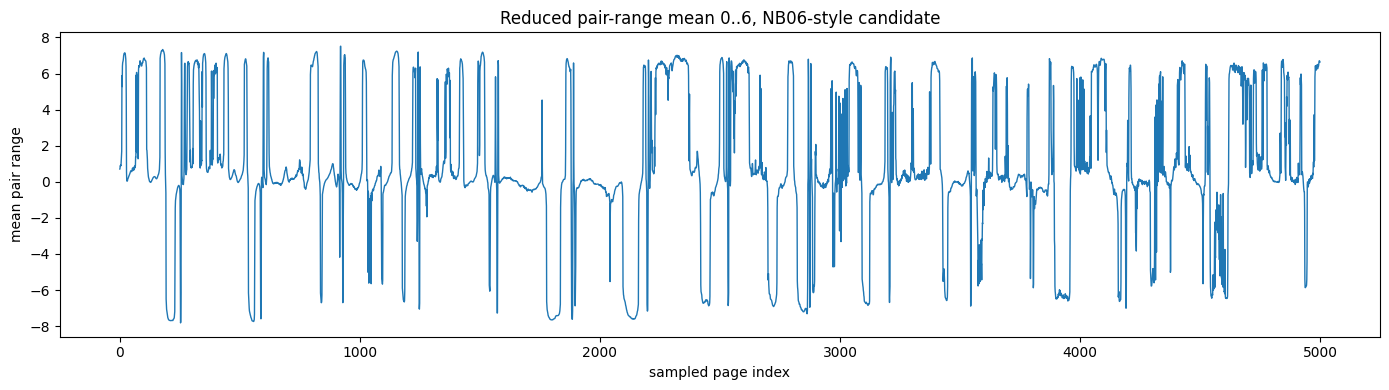

In [20]:
value_matrix = np.zeros((records.shape[0], 16), dtype=np.float32)

for record_index in range(16):
    value_matrix[:, record_index] = (
        records[:, record_index, 4:8]
        .copy()
        .view("<f4")
        .reshape(-1)
    )

pair_range_matrix = np.zeros((records.shape[0], 8), dtype=np.float32)

for pair_index in range(8):
    even_values = value_matrix[:, pair_index * 2]
    odd_values = value_matrix[:, pair_index * 2 + 1]
    pair_range_matrix[:, pair_index] = even_values - odd_values

pair_rows = []

for pair_index in range(8):
    values = pair_range_matrix[:, pair_index]
    pair_rows.append({
        "pair_index": pair_index,
        "min": float(values.min()),
        "max": float(values.max()),
        "mean": float(values.mean()),
        "std": float(values.std()),
        "p01": float(np.percentile(values, 1)),
        "p50": float(np.percentile(values, 50)),
        "p99": float(np.percentile(values, 99)),
    })

pair_range_summary0 = pd.DataFrame(pair_rows)
display(pair_range_summary0)

window_start = 0
window_end = min(5000, pair_range_matrix.shape[0])

plt.figure(figsize=(14, 5))
plt.imshow(
    pair_range_matrix[window_start:window_end].T,
    aspect="auto",
    interpolation="nearest",
    cmap="viridis",
)
plt.colorbar(label="even - odd value_f32")
plt.title("PW even-odd pair range matrix")
plt.xlabel("sampled page index")
plt.ylabel("pair index")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
for pair_index in range(8):
    plt.plot(
        pair_range_matrix[window_start:window_end, pair_index],
        linewidth=0.9,
        alpha=0.8,
        label=str(pair_index),
    )

plt.title("PW even-odd pair ranges over time")
plt.xlabel("sampled page index")
plt.ylabel("even - odd value_f32")
plt.legend(ncol=8, fontsize=8)
plt.tight_layout()
plt.show()

pair_range_mean_0_6 = pair_range_matrix[:, :7].mean(axis=1)

plt.figure(figsize=(14, 4))
plt.plot(pair_range_mean_0_6[window_start:window_end], linewidth=1.0)
plt.title("Reduced pair-range mean 0..6, NB06-style candidate")
plt.xlabel("sampled page index")
plt.ylabel("mean pair range")
plt.tight_layout()
plt.show()

## PW code-state occupancy image

This section tests whether the 45-state dynamic codebook can form a spectrogram-like image over time.

The previous section showed that the eight even/odd pair ranges are highly redundant and behave like a shared native PW state signal. This section switches perspective: instead of treating records as rows, it treats the 45 code states as candidate bins and accumulates `value_f32` by code state over time.

This matters because if the PW dynamic block contains compact spectrogram-related state, it may appear as a sparse code-state image rather than as raw raster bytes.



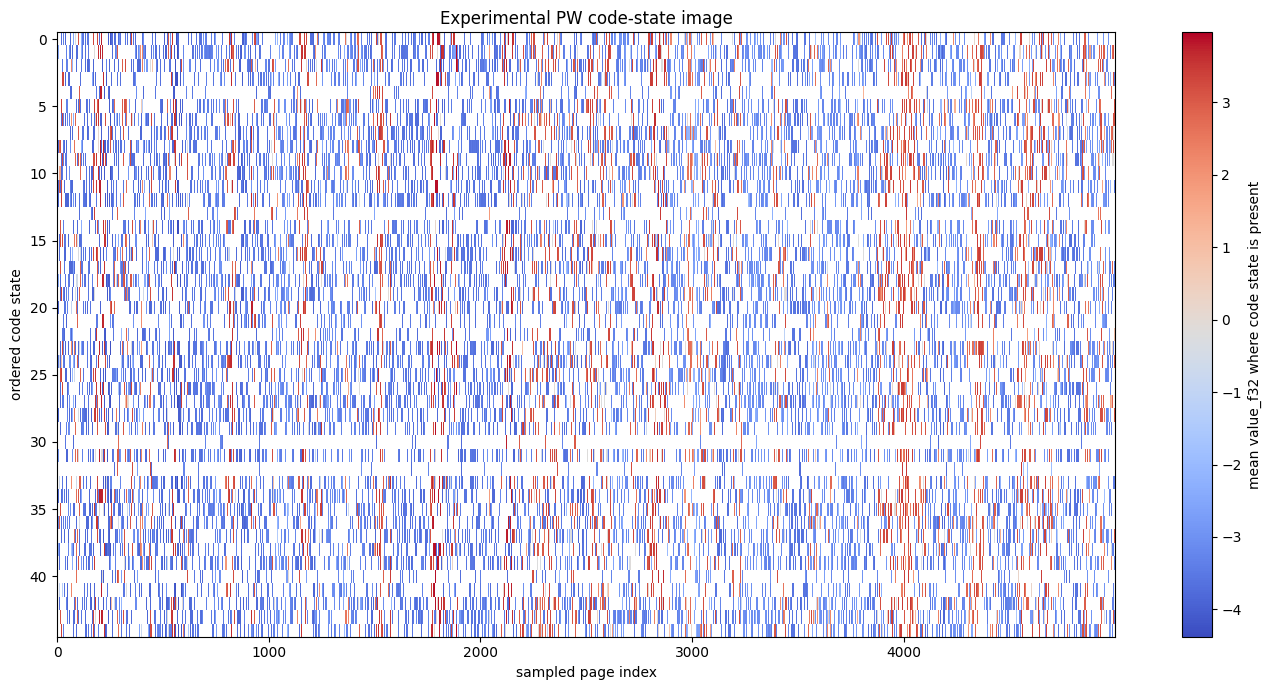

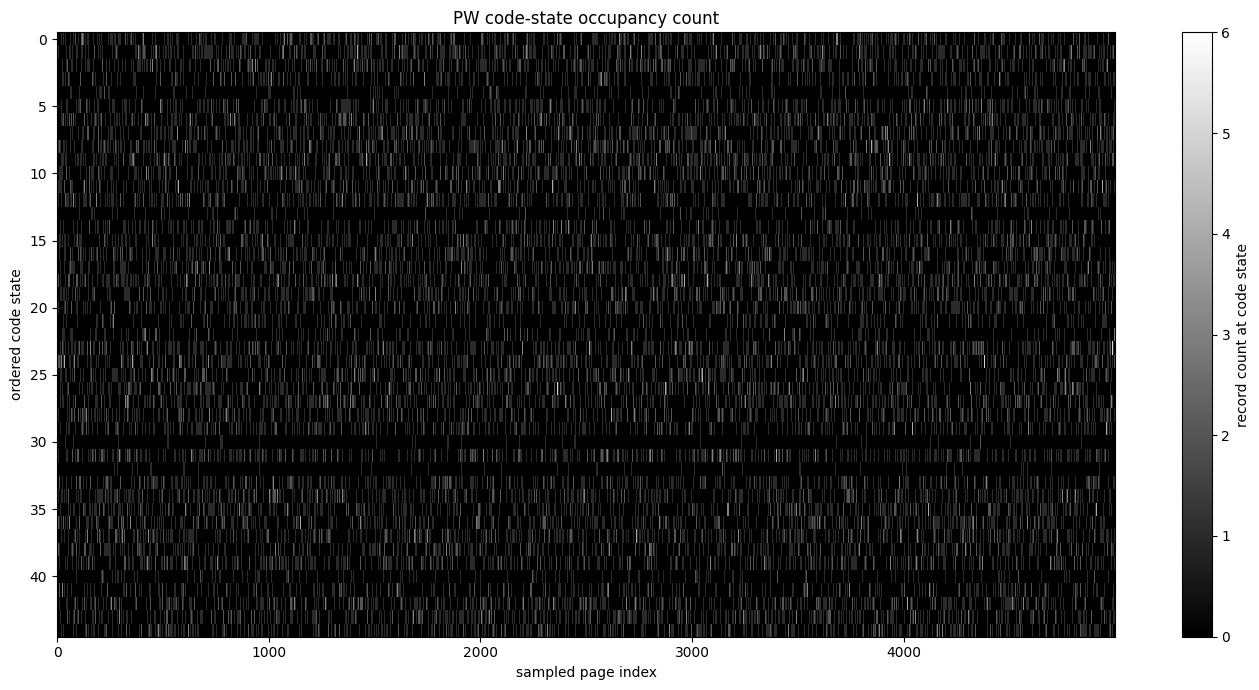

,code_index,pages_present,mean_records_present_when_active,max_records_present
0,0,6879,1.206571,4
1,1,6710,1.203279,5
2,2,6954,1.216566,4
3,3,4693,1.150437,4
4,4,2600,1.098462,3
5,5,6716,1.211882,5
6,6,6842,1.218211,6
7,7,6991,1.200114,5
8,8,6772,1.214265,5
9,9,6809,1.212660,5


In [21]:

code_index_map = {
    int(code): index
    for index, code in enumerate(shared_code_counts["code_u32"].tolist())
}

n_pages = records.shape[0]
n_code_states = len(code_index_map)

code_state_sum = np.zeros((n_code_states, n_pages), dtype=np.float32)
code_state_count = np.zeros((n_code_states, n_pages), dtype=np.float32)

for record_index in range(16):
    record = records[:, record_index, :]

    code_u32 = (
        record[:, 0].astype(np.uint32)
        | (record[:, 1].astype(np.uint32) << 8)
        | (record[:, 2].astype(np.uint32) << 16)
        | (record[:, 3].astype(np.uint32) << 24)
    )

    value_f32 = record[:, 4:8].copy().view("<f4").reshape(-1)

    code_indices = np.array([code_index_map[int(code)] for code in code_u32], dtype=np.int32)

    for page_index, code_index in enumerate(code_indices):
        code_state_sum[code_index, page_index] += value_f32[page_index]
        code_state_count[code_index, page_index] += 1

code_state_mean = np.full_like(code_state_sum, np.nan)
valid_mask = code_state_count > 0
code_state_mean[valid_mask] = code_state_sum[valid_mask] / code_state_count[valid_mask]

window_start = 0
window_end = min(5000, n_pages)

plt.figure(figsize=(14, 7))
plt.imshow(
    code_state_mean[:, window_start:window_end],
    aspect="auto",
    interpolation="nearest",
    cmap="coolwarm",
)
plt.colorbar(label="mean value_f32 where code state is present")
plt.title("Experimental PW code-state image")
plt.xlabel("sampled page index")
plt.ylabel("ordered code state")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 7))
plt.imshow(
    code_state_count[:, window_start:window_end],
    aspect="auto",
    interpolation="nearest",
    cmap="gray",
)
plt.colorbar(label="record count at code state")
plt.title("PW code-state occupancy count")
plt.xlabel("sampled page index")
plt.ylabel("ordered code state")
plt.tight_layout()
plt.show()

occupancy_rows = []

for code_index in range(n_code_states):
    counts = code_state_count[code_index]
    occupancy_rows.append({
        "code_index": code_index,
        "pages_present": int((counts > 0).sum()),
        "mean_records_present_when_active": float(counts[counts > 0].mean()) if np.any(counts > 0) else 0.0,
        "max_records_present": int(counts.max()),
    })

code_state_occupancy_summary0 = pd.DataFrame(occupancy_rows)
display(code_state_occupancy_summary0)

## Native PW state versus AVI Doppler ROI brightness

This section compares the native PW dynamic state stream against the linked AVI Doppler image region.

NB06 compared native PW dynamic signals against the linked AVI audio envelope. This section tests a different reference: the visible PW Doppler spectral ROI in the AVI frames.

The goal is to check whether native PW state features track image-level Doppler activity over time.

This matters because `PW_CinePartition0.bin` has not yielded a raw spectrogram raster, but it may still contain compact spectrogram-related state. If that is true, native features may correlate with changes in the displayed Doppler ROI brightness.



,frame_index,time_s,roi_mean,roi_std,roi_p95,roi_bright_fraction,native_pair_range_mean_0_6
0,0,0.000000,18.965111,45.315913,148.0,0.091084,0.706403
1,1,0.033333,18.939583,45.442352,148.0,0.091766,7.037864
2,2,0.066667,18.946958,45.447183,148.0,0.091864,0.152818
3,3,0.100000,18.946663,45.447818,148.0,0.091878,0.565733
4,4,0.133333,18.946729,45.447908,148.0,0.091878,1.375220


,roi_mean,roi_std,roi_p95,roi_bright_fraction,native_pair_range_mean_0_6
roi_mean,1.000000,0.979354,0.971067,0.994766,0.160142
roi_std,0.979354,1.000000,0.960914,0.964883,0.153515
roi_p95,0.971067,0.960914,1.000000,0.957857,0.165006
roi_bright_fraction,0.994766,0.964883,0.957857,1.000000,0.141662
native_pair_range_mean_0_6,0.160142,0.153515,0.165006,0.141662,1.000000


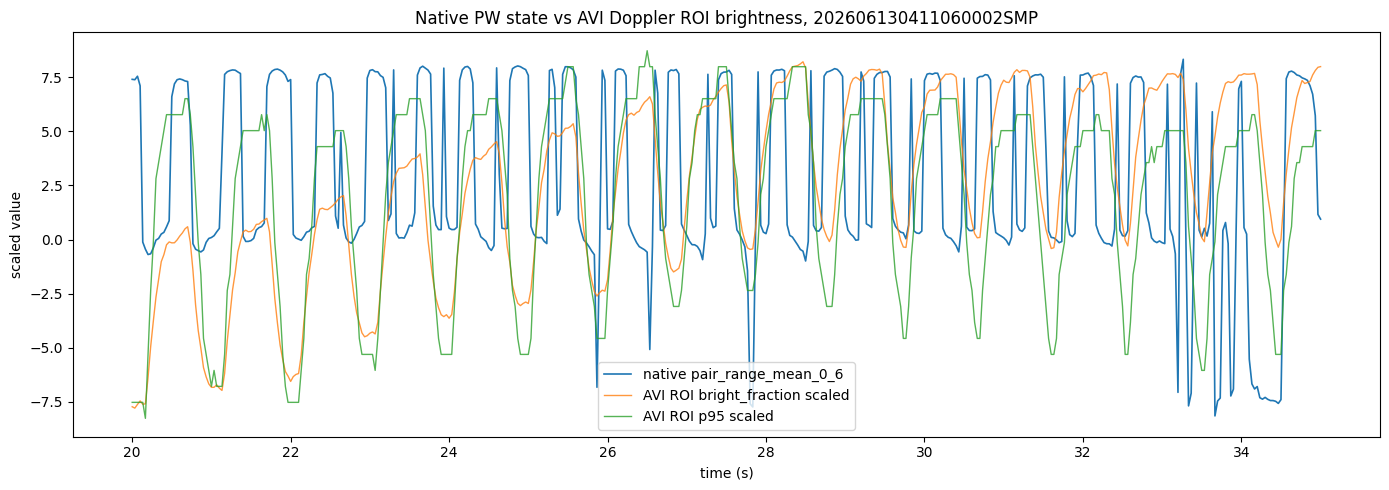

Recording: 202606130411060002SMP
AVI: ultrasound_recordings\batch_2026_06_13_native\202606130411060002SMP\linked_avi\202606130411060002SMP.avi
fps: 30.0
frames read: 1777
native samples: 20000


In [22]:
file_index = 0
pw_path = pw_files[file_index]
recording_dir = pw_path.parent.parent
recording_id = recording_dir.name

avi_files = sorted((recording_dir / "linked_avi").glob("*.avi"))
if not avi_files:
    raise FileNotFoundError(f"No linked AVI found for {recording_id}")

avi_path = avi_files[0]

# DcmRegionPara metadata from NB06/NB06 V2 for PW spectral ROI.
# These bounds are display-pixel coordinates for the PW Doppler spectral region.
pw_roi_x0 = 79
pw_roi_x1 = 659
pw_roi_y0 = 245
pw_roi_y1 = 508

cap = cv2.VideoCapture(str(avi_path))
if not cap.isOpened():
    raise RuntimeError(f"Could not open AVI: {avi_path}")

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

brightness_rows = []

for frame_index in range(frame_count):
    ok, frame_bgr = cap.read()
    if not ok:
        break

    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    roi = gray[pw_roi_y0:pw_roi_y1, pw_roi_x0:pw_roi_x1]

    brightness_rows.append({
        "frame_index": frame_index,
        "time_s": frame_index / fps if fps and fps > 0 else np.nan,
        "roi_mean": float(roi.mean()),
        "roi_std": float(roi.std()),
        "roi_p95": float(np.percentile(roi, 95)),
        "roi_bright_fraction": float((roi > 80).mean()),
    })

cap.release()

avi_roi_brightness0 = pd.DataFrame(brightness_rows)

native_time_s = np.arange(len(pair_range_mean_0_6)) / PAGE_RATE_HZ

# Interpolate native signal at AVI frame times for direct plotting/correlation.
native_at_frame = np.interp(
    avi_roi_brightness0["time_s"].to_numpy(),
    native_time_s,
    pair_range_mean_0_6,
)

comparison0 = avi_roi_brightness0.copy()
comparison0["native_pair_range_mean_0_6"] = native_at_frame

display(comparison0.head())
display(comparison0[["roi_mean", "roi_std", "roi_p95", "roi_bright_fraction", "native_pair_range_mean_0_6"]].corr())

window_start_s = 20
window_end_s = 35

mask = (
    (comparison0["time_s"] >= window_start_s)
    & (comparison0["time_s"] <= window_end_s)
)

plot_df = comparison0[mask].copy()

def scale_to_reference(values, reference):
    values = np.asarray(values, dtype=float)
    reference = np.asarray(reference, dtype=float)

    values_min = np.nanpercentile(values, 1)
    values_max = np.nanpercentile(values, 99)
    reference_min = np.nanpercentile(reference, 1)
    reference_max = np.nanpercentile(reference, 99)

    if values_max == values_min:
        return np.full_like(values, np.nanmean(reference))

    scaled = (values - values_min) / (values_max - values_min)
    return scaled * (reference_max - reference_min) + reference_min


scaled_roi_bright_fraction = scale_to_reference(
    plot_df["roi_bright_fraction"],
    plot_df["native_pair_range_mean_0_6"],
)

scaled_roi_p95 = scale_to_reference(
    plot_df["roi_p95"],
    plot_df["native_pair_range_mean_0_6"],
)

plt.figure(figsize=(14, 5))
plt.plot(
    plot_df["time_s"],
    plot_df["native_pair_range_mean_0_6"],
    linewidth=1.2,
    label="native pair_range_mean_0_6",
)
plt.plot(
    plot_df["time_s"],
    scaled_roi_bright_fraction,
    linewidth=1.0,
    alpha=0.8,
    label="AVI ROI bright_fraction scaled",
)
plt.plot(
    plot_df["time_s"],
    scaled_roi_p95,
    linewidth=1.0,
    alpha=0.8,
    label="AVI ROI p95 scaled",
)
plt.title(f"Native PW state vs AVI Doppler ROI brightness, {recording_id}")
plt.xlabel("time (s)")
plt.ylabel("scaled value")
plt.legend()
plt.tight_layout()
plt.show()

print("Recording:", recording_id)
print("AVI:", avi_path)
print("fps:", fps)
print("frames read:", len(comparison0))
print("native samples:", len(pair_range_mean_0_6))

## Native PW state versus AVI ROI brightness with corrected timebase

This section repeats the native-versus-AVI ROI comparison using the full native page stream.

The previous comparison used a sampled native page matrix, which compressed the native time axis. This section recomputes the pair-range signal from all native pages so that native time is correctly represented as:

```text
native_time_s = page_index / 500

,roi_mean,roi_std,roi_p95,roi_bright_fraction,native_pair_range_mean_0_6_full
roi_mean,1.000000,0.979354,0.971067,0.994766,0.257445
roi_std,0.979354,1.000000,0.960914,0.964883,0.229960
roi_p95,0.971067,0.960914,1.000000,0.957857,0.210355
roi_bright_fraction,0.994766,0.964883,0.957857,1.000000,0.274284
native_pair_range_mean_0_6_full,0.257445,0.229960,0.210355,0.274284,1.000000


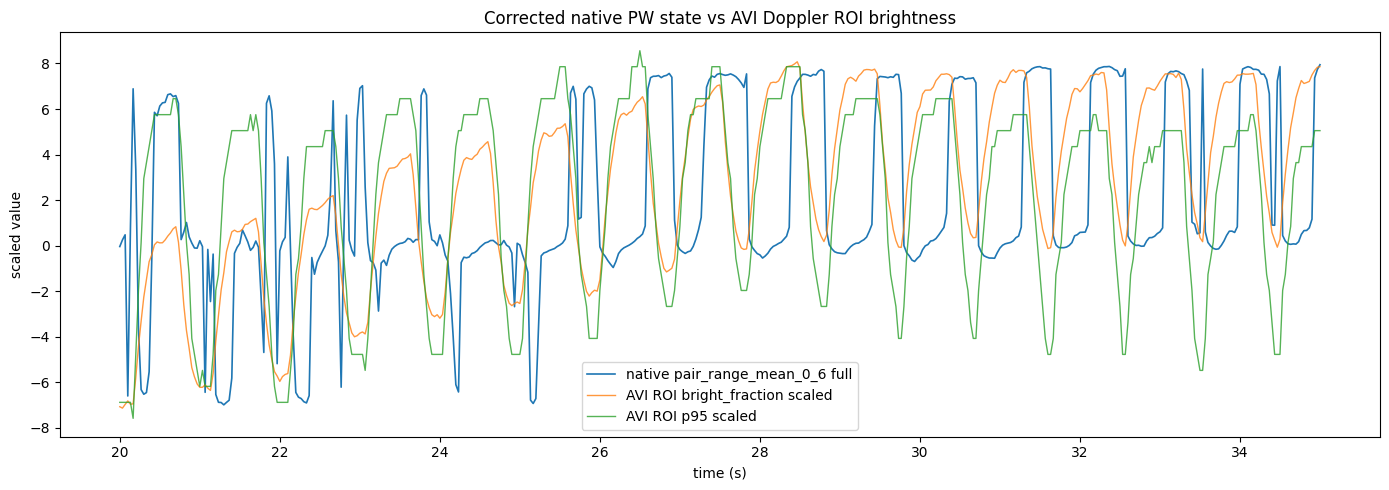

full native pages: 29615
full native duration_s: 59.23
AVI duration_s: 59.2


In [23]:
file_index = 0
pw_path = pw_files[file_index]

n_pages_full = pw_path.stat().st_size // PAGE_SIZE_BYTES
pages_full = np.memmap(
    pw_path,
    dtype=np.uint8,
    mode="r",
    shape=(n_pages_full, PAGE_SIZE_BYTES),
)

dynamic_block_full = pages_full[:, 16:144]
records_full = dynamic_block_full.reshape(n_pages_full, 16, 8)

value_matrix_full = np.zeros((n_pages_full, 16), dtype=np.float32)

for record_index in range(16):
    value_matrix_full[:, record_index] = (
        records_full[:, record_index, 4:8]
        .copy()
        .view("<f4")
        .reshape(-1)
    )

pair_range_matrix_full = np.zeros((n_pages_full, 8), dtype=np.float32)

for pair_index in range(8):
    even_values = value_matrix_full[:, pair_index * 2]
    odd_values = value_matrix_full[:, pair_index * 2 + 1]
    pair_range_matrix_full[:, pair_index] = even_values - odd_values

pair_range_mean_0_6_full = pair_range_matrix_full[:, :7].mean(axis=1)
native_time_s_full = np.arange(n_pages_full) / PAGE_RATE_HZ

native_at_frame_full = np.interp(
    avi_roi_brightness0["time_s"].to_numpy(),
    native_time_s_full,
    pair_range_mean_0_6_full,
)

comparison0_corrected = avi_roi_brightness0.copy()
comparison0_corrected["native_pair_range_mean_0_6_full"] = native_at_frame_full

display(
    comparison0_corrected[
        [
            "roi_mean",
            "roi_std",
            "roi_p95",
            "roi_bright_fraction",
            "native_pair_range_mean_0_6_full",
        ]
    ].corr()
)

window_start_s = 20
window_end_s = 35

mask = (
    (comparison0_corrected["time_s"] >= window_start_s)
    & (comparison0_corrected["time_s"] <= window_end_s)
)

plot_df = comparison0_corrected[mask].copy()

scaled_roi_bright_fraction = scale_to_reference(
    plot_df["roi_bright_fraction"],
    plot_df["native_pair_range_mean_0_6_full"],
)

scaled_roi_p95 = scale_to_reference(
    plot_df["roi_p95"],
    plot_df["native_pair_range_mean_0_6_full"],
)

plt.figure(figsize=(14, 5))
plt.plot(
    plot_df["time_s"],
    plot_df["native_pair_range_mean_0_6_full"],
    linewidth=1.2,
    label="native pair_range_mean_0_6 full",
)
plt.plot(
    plot_df["time_s"],
    scaled_roi_bright_fraction,
    linewidth=1.0,
    alpha=0.8,
    label="AVI ROI bright_fraction scaled",
)
plt.plot(
    plot_df["time_s"],
    scaled_roi_p95,
    linewidth=1.0,
    alpha=0.8,
    label="AVI ROI p95 scaled",
)
plt.title("Corrected native PW state vs AVI Doppler ROI brightness")
plt.xlabel("time (s)")
plt.ylabel("scaled value")
plt.legend()
plt.tight_layout()
plt.show()

print("full native pages:", n_pages_full)
print("full native duration_s:", n_pages_full / PAGE_RATE_HZ)
print("AVI duration_s:", avi_roi_brightness0["time_s"].max())

## Native PW state versus AVI ROI brightness lag scan

This section tests whether the native pair-range state signal has a lagged relationship with AVI Doppler ROI brightness.

The corrected overlay showed a possible temporal relationship, but the zero-lag correlation was modest. This section scans small time shifts between the native signal and AVI ROI brightness metrics.

This matters because native PW state changes may lead or lag the displayed AVI spectrogram due to buffering, rendering, export timing, or processing delay.



,lag_s,roi_metric,corr,abs_corr,n_samples
255,0.13,roi_bright_fraction,0.296838,0.296838,1773
275,0.18,roi_bright_fraction,0.295354,0.295354,1772
267,0.16,roi_bright_fraction,0.295085,0.295085,1773
263,0.15,roi_bright_fraction,0.294563,0.294563,1773
247,0.11,roi_bright_fraction,0.293419,0.293419,1774
271,0.17,roi_bright_fraction,0.291863,0.291863,1772
235,0.08,roi_bright_fraction,0.291518,0.291518,1775
259,0.14,roi_bright_fraction,0.291449,0.291449,1773
243,0.10,roi_bright_fraction,0.290796,0.290796,1774
283,0.20,roi_bright_fraction,0.289775,0.289775,1771


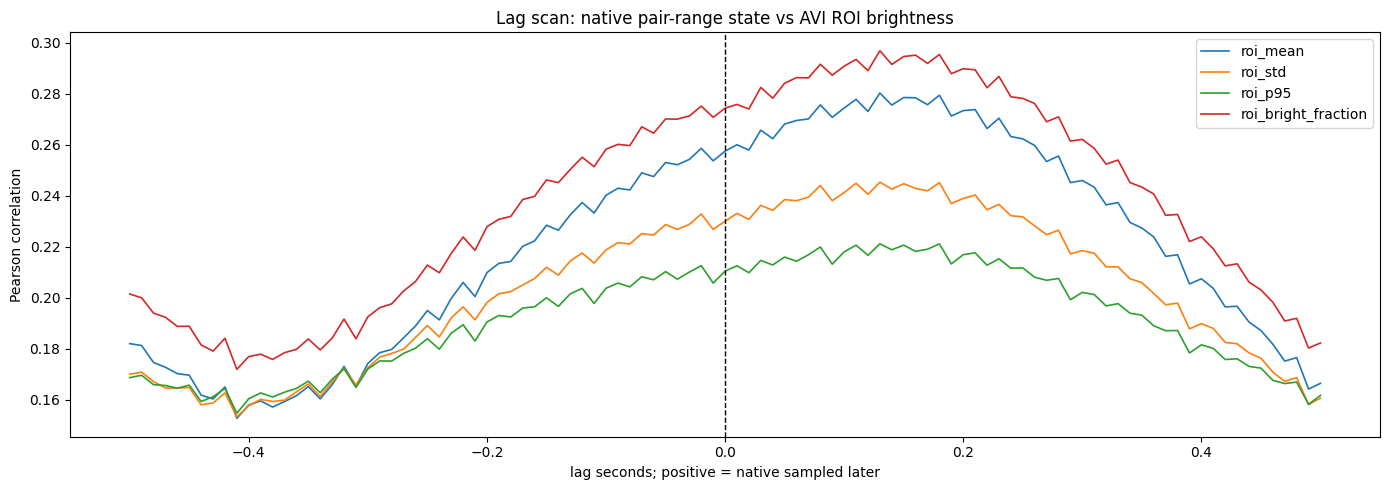

In [24]:
lag_rows = []

frame_times = comparison0_corrected["time_s"].to_numpy()

roi_metrics = [
    "roi_mean",
    "roi_std",
    "roi_p95",
    "roi_bright_fraction",
]

lags_s = np.arange(-0.50, 0.501, 0.01)

for lag_s in lags_s:
    # Positive lag means native signal is sampled later relative to AVI frame time.
    shifted_native = np.interp(
        frame_times + lag_s,
        native_time_s_full,
        pair_range_mean_0_6_full,
        left=np.nan,
        right=np.nan,
    )

    valid = np.isfinite(shifted_native)

    for metric in roi_metrics:
        metric_values = comparison0_corrected[metric].to_numpy()
        valid_metric = valid & np.isfinite(metric_values)

        if valid_metric.sum() > 10:
            corr = np.corrcoef(
                shifted_native[valid_metric],
                metric_values[valid_metric],
            )[0, 1]
        else:
            corr = np.nan

        lag_rows.append({
            "lag_s": float(lag_s),
            "roi_metric": metric,
            "corr": float(corr),
            "abs_corr": float(abs(corr)) if np.isfinite(corr) else np.nan,
            "n_samples": int(valid_metric.sum()),
        })

lag_scan0 = pd.DataFrame(lag_rows)

display(
    lag_scan0
    .sort_values("abs_corr", ascending=False)
    .head(20)
)

plt.figure(figsize=(14, 5))

for metric in roi_metrics:
    metric_df = lag_scan0[lag_scan0["roi_metric"] == metric]
    plt.plot(metric_df["lag_s"], metric_df["corr"], linewidth=1.2, label=metric)

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Lag scan: native pair-range state vs AVI ROI brightness")
plt.xlabel("lag seconds; positive = native sampled later")
plt.ylabel("Pearson correlation")
plt.legend()
plt.tight_layout()
plt.show()

## Native PW state and AVI ROI brightness at best lag

This section visualizes the native pair-range state signal against AVI Doppler ROI brightness using the best lag from the previous scan.

The lag scan found the strongest relationship around `+0.13 s` for AVI ROI bright-fraction. This section applies that lag and inspects whether the visual alignment improves.


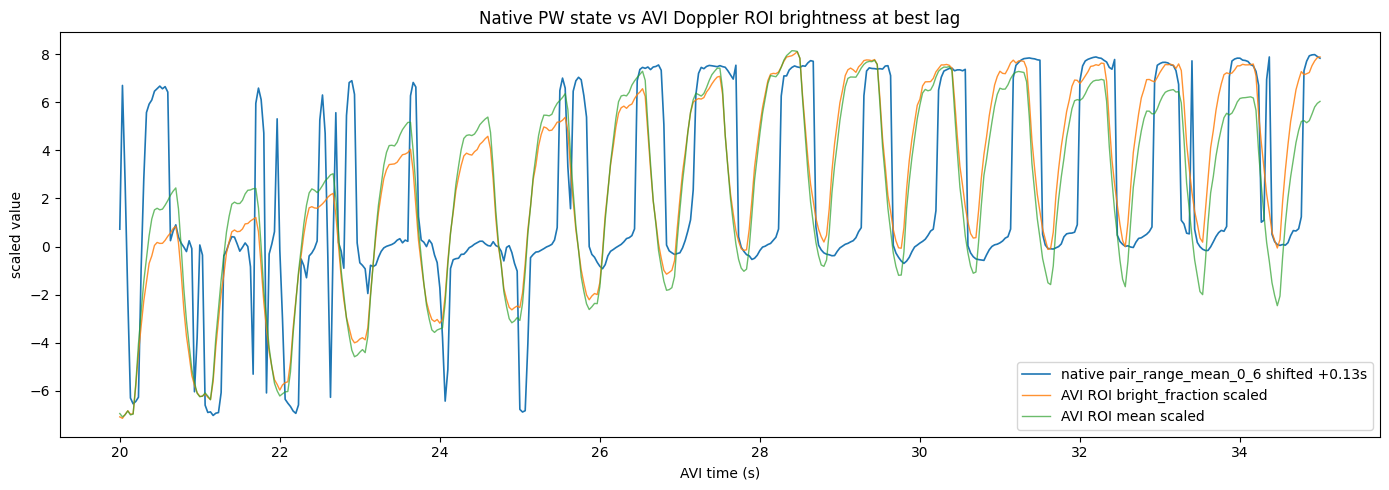

,roi_mean,roi_std,roi_p95,roi_bright_fraction,native_pair_range_best_lag
roi_mean,1.000000,0.979354,0.971067,0.994766,0.280236
roi_std,0.979354,1.000000,0.960914,0.964883,0.245267
roi_p95,0.971067,0.960914,1.000000,0.957857,0.221083
roi_bright_fraction,0.994766,0.964883,0.957857,1.000000,0.296838
native_pair_range_best_lag,0.280236,0.245267,0.221083,0.296838,1.000000


In [25]:
best_lag_s = 0.13

frame_times = comparison0_corrected["time_s"].to_numpy()

native_at_best_lag = np.interp(
    frame_times + best_lag_s,
    native_time_s_full,
    pair_range_mean_0_6_full,
    left=np.nan,
    right=np.nan,
)

comparison0_best_lag = comparison0_corrected.copy()
comparison0_best_lag["native_pair_range_best_lag"] = native_at_best_lag

window_start_s = 20
window_end_s = 35

mask = (
    (comparison0_best_lag["time_s"] >= window_start_s)
    & (comparison0_best_lag["time_s"] <= window_end_s)
)

plot_df = comparison0_best_lag[mask].copy()

scaled_bright_fraction = scale_to_reference(
    plot_df["roi_bright_fraction"],
    plot_df["native_pair_range_best_lag"],
)

scaled_roi_mean = scale_to_reference(
    plot_df["roi_mean"],
    plot_df["native_pair_range_best_lag"],
)

plt.figure(figsize=(14, 5))
plt.plot(
    plot_df["time_s"],
    plot_df["native_pair_range_best_lag"],
    linewidth=1.2,
    label=f"native pair_range_mean_0_6 shifted {best_lag_s:+.2f}s",
)
plt.plot(
    plot_df["time_s"],
    scaled_bright_fraction,
    linewidth=1.0,
    alpha=0.85,
    label="AVI ROI bright_fraction scaled",
)
plt.plot(
    plot_df["time_s"],
    scaled_roi_mean,
    linewidth=1.0,
    alpha=0.7,
    label="AVI ROI mean scaled",
)
plt.title("Native PW state vs AVI Doppler ROI brightness at best lag")
plt.xlabel("AVI time (s)")
plt.ylabel("scaled value")
plt.legend()
plt.tight_layout()
plt.show()

display(
    comparison0_best_lag[
        [
            "roi_mean",
            "roi_std",
            "roi_p95",
            "roi_bright_fraction",
            "native_pair_range_best_lag",
        ]
    ].corr()
)

## Native PW state versus AVI ROI brightness in stable window

This section repeats the lagged native-versus-AVI ROI comparison inside a visually stable window.

The previous overlay showed clearer alignment from approximately `26..35 s` than from `20..24 s`. This section computes the correlation only inside the stable window.

This matters because NB06 already showed that native PW state behavior can be segment-dependent. A full-recording correlation can hide useful relationships in stable segments.


,roi_mean,roi_std,roi_p95,roi_bright_fraction,native_pair_range_best_lag
roi_mean,1.000000,0.995206,0.970789,0.971961,0.421014
roi_std,0.995206,1.000000,0.972284,0.974023,0.451201
roi_p95,0.970789,0.972284,1.000000,0.908624,0.449166
roi_bright_fraction,0.971961,0.974023,0.908624,1.000000,0.406939
native_pair_range_best_lag,0.421014,0.451201,0.449166,0.406939,1.000000


stable_window_frames: 271
stable_window_duration_s: 9


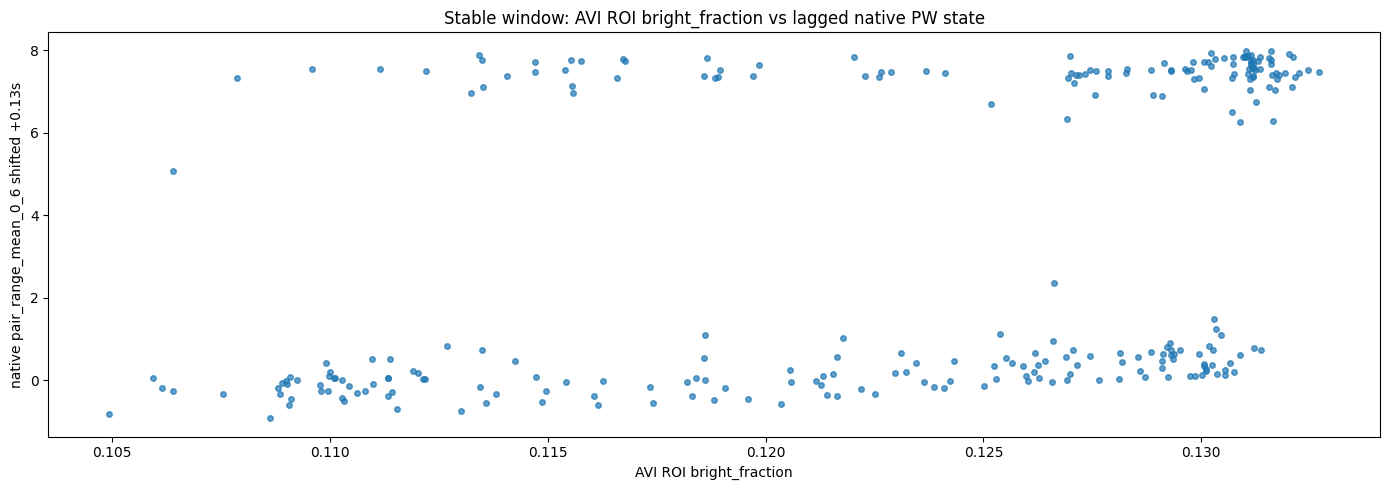

In [26]:
stable_start_s = 26
stable_end_s = 35

stable_mask = (
    (comparison0_best_lag["time_s"] >= stable_start_s)
    & (comparison0_best_lag["time_s"] <= stable_end_s)
)

stable_df = comparison0_best_lag[stable_mask].copy()

display(
    stable_df[
        [
            "roi_mean",
            "roi_std",
            "roi_p95",
            "roi_bright_fraction",
            "native_pair_range_best_lag",
        ]
    ].corr()
)

print("stable_window_frames:", len(stable_df))
print("stable_window_duration_s:", stable_end_s - stable_start_s)

plt.figure(figsize=(14, 5))
plt.scatter(
    stable_df["roi_bright_fraction"],
    stable_df["native_pair_range_best_lag"],
    s=16,
    alpha=0.7,
)
plt.title("Stable window: AVI ROI bright_fraction vs lagged native PW state")
plt.xlabel("AVI ROI bright_fraction")
plt.ylabel("native pair_range_mean_0_6 shifted +0.13s")
plt.tight_layout()
plt.show()

## Native PW high-state versus AVI ROI brightness

This section tests whether the two native pair-range states correspond to different AVI Doppler ROI brightness levels.

The previous section showed that the lagged native pair-range signal separates into low and high states in a stable window. This section splits the stable window by native state and compares AVI ROI brightness metrics between the two groups.

This matters because a state-dependent brightness difference would support a temporal relationship between native PW state and displayed Doppler activity, even if the native signal is not a continuous spectrogram or envelope.


,native_state,n_frames,roi_mean_mean,roi_mean_std,roi_std_mean,roi_p95_mean,roi_bright_fraction_mean,native_mean
0,high,119,25.611221,1.177554,53.666608,172.319328,0.126355,7.440944
1,low,152,24.477333,1.479343,52.410304,167.987500,0.120515,0.156977


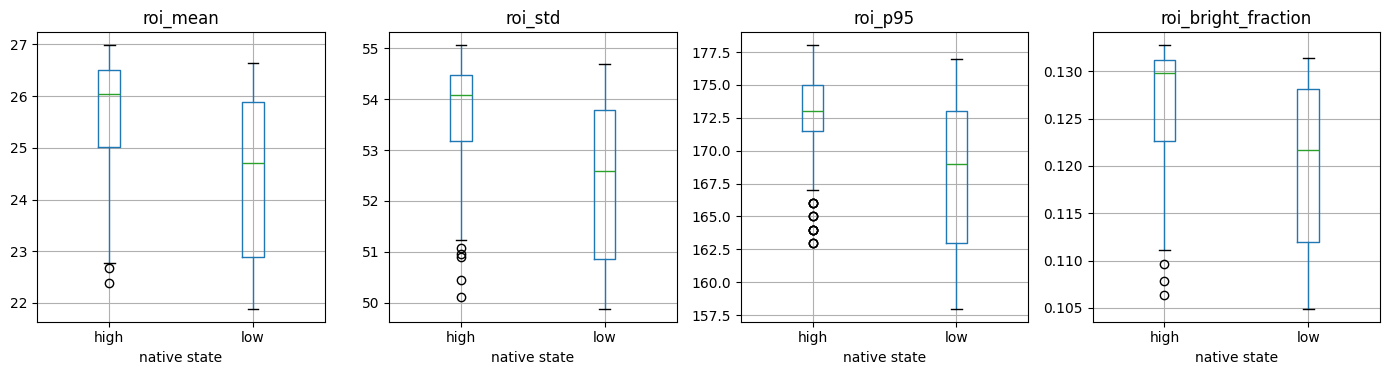

In [27]:
state_threshold = 4.0

state_df = stable_df.copy()
state_df["native_state"] = np.where(
    state_df["native_pair_range_best_lag"] >= state_threshold,
    "high",
    "low",
)

display(
    state_df
    .groupby("native_state")
    .agg(
        n_frames=("frame_index", "count"),
        roi_mean_mean=("roi_mean", "mean"),
        roi_mean_std=("roi_mean", "std"),
        roi_std_mean=("roi_std", "mean"),
        roi_p95_mean=("roi_p95", "mean"),
        roi_bright_fraction_mean=("roi_bright_fraction", "mean"),
        native_mean=("native_pair_range_best_lag", "mean"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

metrics = ["roi_mean", "roi_std", "roi_p95", "roi_bright_fraction"]

for ax, metric in zip(axes, metrics):
    state_df.boxplot(column=metric, by="native_state", ax=ax)
    ax.set_title(metric)
    ax.set_xlabel("native state")

plt.suptitle("")
plt.tight_layout()
plt.show()

## Native PW high-state association across windows

This section tests whether the native high-state association with AVI ROI brightness repeats across multiple time windows in the same recording.

The previous section showed that high native pair-range state corresponds to higher AVI Doppler ROI brightness in the `26..35 s` window. This section repeats the same state split in several windows.

This matters because a single stable window can be misleading. Repeated positive associations across windows would support a real native/AVI image relationship, while inconsistent results would suggest segment dependence.



In [28]:
windows = [
    (20, 23),
    (23, 26),
    (26, 29),
    (29, 32),
    (32, 35),
]

state_threshold = 4.0
window_rows = []

for start_s, end_s in windows:
    window_mask = (
        (comparison0_best_lag["time_s"] >= start_s)
        & (comparison0_best_lag["time_s"] < end_s)
    )

    window_df = comparison0_best_lag[window_mask].copy()

    if len(window_df) == 0:
        continue

    window_df["native_state"] = np.where(
        window_df["native_pair_range_best_lag"] >= state_threshold,
        "high",
        "low",
    )

    state_counts = window_df["native_state"].value_counts().to_dict()

    row = {
        "window_start_s": start_s,
        "window_end_s": end_s,
        "n_frames": len(window_df),
        "n_high": int(state_counts.get("high", 0)),
        "n_low": int(state_counts.get("low", 0)),
    }

    for metric in ["roi_mean", "roi_std", "roi_p95", "roi_bright_fraction"]:
        high_values = window_df.loc[window_df["native_state"] == "high", metric]
        low_values = window_df.loc[window_df["native_state"] == "low", metric]

        row[f"{metric}_high_mean"] = float(high_values.mean()) if len(high_values) else np.nan
        row[f"{metric}_low_mean"] = float(low_values.mean()) if len(low_values) else np.nan
        row[f"{metric}_high_minus_low"] = (
            float(high_values.mean() - low_values.mean())
            if len(high_values) and len(low_values)
            else np.nan
        )

    window_rows.append(row)

state_window_summary0 = pd.DataFrame(window_rows)
display(state_window_summary0)

,window_start_s,window_end_s,n_frames,n_high,n_low,roi_mean_high_mean,roi_mean_low_mean,roi_mean_high_minus_low,roi_std_high_mean,roi_std_low_mean,roi_std_high_minus_low,roi_p95_high_mean,roi_p95_low_mean,roi_p95_high_minus_low,roi_bright_fraction_high_mean,roi_bright_fraction_low_mean,roi_bright_fraction_high_minus_low
0,20,23,90,23,67,22.948418,22.131693,0.816725,51.431368,50.432509,0.998859,168.913043,165.418657,3.494387,0.106346,0.102191,0.004155
1,23,26,90,12,78,24.181736,23.688961,0.492776,52.401887,51.851880,0.550007,170.833333,168.358974,2.474359,0.114714,0.112325,0.002389
2,26,29,90,40,50,25.506107,24.429985,1.076122,53.538701,52.347570,1.191131,173.150000,169.100000,4.050000,0.123815,0.118378,0.005437
3,29,32,90,33,57,25.620161,24.858138,0.762023,53.681874,52.756177,0.925697,171.909091,168.720175,3.188915,0.125978,0.122455,0.003523
4,32,35,90,45,45,25.690202,24.047590,1.642612,53.753340,52.041903,1.711437,171.866667,165.823333,6.043333,0.128763,0.120431,0.008332


## Native PW high-state association in a second recording

This section repeats the native high-state versus AVI ROI brightness test in a second recording.

The first recording showed a consistent association between native high state and brighter AVI Doppler ROI frames. This section tests whether that association appears in another linked recording.

This matters because one recording can show a convincing relationship by chance or due to segment-specific behavior. A second recording provides the first generalization check.                   


In [29]:
file_index = 1
best_lag_s = 0.13
state_threshold = 4.0

pw_path = pw_files[file_index]
recording_dir = pw_path.parent.parent
recording_id = recording_dir.name

avi_files = sorted((recording_dir / "linked_avi").glob("*.avi"))
if not avi_files:
    raise FileNotFoundError(f"No linked AVI found for {recording_id}")

avi_path = avi_files[0]

pw_roi_x0 = 79
pw_roi_x1 = 659
pw_roi_y0 = 245
pw_roi_y1 = 508

cap = cv2.VideoCapture(str(avi_path))
if not cap.isOpened():
    raise RuntimeError(f"Could not open AVI: {avi_path}")

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

brightness_rows = []

for frame_index in range(frame_count):
    ok, frame_bgr = cap.read()
    if not ok:
        break

    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    roi = gray[pw_roi_y0:pw_roi_y1, pw_roi_x0:pw_roi_x1]

    brightness_rows.append({
        "frame_index": frame_index,
        "time_s": frame_index / fps if fps and fps > 0 else np.nan,
        "roi_mean": float(roi.mean()),
        "roi_std": float(roi.std()),
        "roi_p95": float(np.percentile(roi, 95)),
        "roi_bright_fraction": float((roi > 80).mean()),
    })

cap.release()

avi_roi_brightness1 = pd.DataFrame(brightness_rows)

n_pages_full = pw_path.stat().st_size // PAGE_SIZE_BYTES
pages_full = np.memmap(
    pw_path,
    dtype=np.uint8,
    mode="r",
    shape=(n_pages_full, PAGE_SIZE_BYTES),
)

dynamic_block_full = pages_full[:, 16:144]
records_full = dynamic_block_full.reshape(n_pages_full, 16, 8)

value_matrix_full = np.zeros((n_pages_full, 16), dtype=np.float32)

for record_index in range(16):
    value_matrix_full[:, record_index] = (
        records_full[:, record_index, 4:8]
        .copy()
        .view("<f4")
        .reshape(-1)
    )

pair_range_matrix_full = np.zeros((n_pages_full, 8), dtype=np.float32)

for pair_index in range(8):
    even_values = value_matrix_full[:, pair_index * 2]
    odd_values = value_matrix_full[:, pair_index * 2 + 1]
    pair_range_matrix_full[:, pair_index] = even_values - odd_values

pair_range_mean_0_6_full_1 = pair_range_matrix_full[:, :7].mean(axis=1)
native_time_s_full_1 = np.arange(n_pages_full) / PAGE_RATE_HZ

native_at_best_lag = np.interp(
    avi_roi_brightness1["time_s"].to_numpy() + best_lag_s,
    native_time_s_full_1,
    pair_range_mean_0_6_full_1,
    left=np.nan,
    right=np.nan,
)

comparison1_best_lag = avi_roi_brightness1.copy()
comparison1_best_lag["native_pair_range_best_lag"] = native_at_best_lag

duration_s = min(
    comparison1_best_lag["time_s"].max(),
    native_time_s_full_1.max(),
)

windows = []
start_s = 20
while start_s + 3 <= min(35, duration_s):
    windows.append((start_s, start_s + 3))
    start_s += 3

window_rows = []

for start_s, end_s in windows:
    window_mask = (
        (comparison1_best_lag["time_s"] >= start_s)
        & (comparison1_best_lag["time_s"] < end_s)
    )

    window_df = comparison1_best_lag[window_mask].copy()

    if len(window_df) == 0:
        continue

    window_df["native_state"] = np.where(
        window_df["native_pair_range_best_lag"] >= state_threshold,
        "high",
        "low",
    )

    state_counts = window_df["native_state"].value_counts().to_dict()

    row = {
        "recording": recording_id,
        "window_start_s": start_s,
        "window_end_s": end_s,
        "n_frames": len(window_df),
        "n_high": int(state_counts.get("high", 0)),
        "n_low": int(state_counts.get("low", 0)),
    }

    for metric in ["roi_mean", "roi_std", "roi_p95", "roi_bright_fraction"]:
        high_values = window_df.loc[window_df["native_state"] == "high", metric]
        low_values = window_df.loc[window_df["native_state"] == "low", metric]

        row[f"{metric}_high_mean"] = float(high_values.mean()) if len(high_values) else np.nan
        row[f"{metric}_low_mean"] = float(low_values.mean()) if len(low_values) else np.nan
        row[f"{metric}_high_minus_low"] = (
            float(high_values.mean() - low_values.mean())
            if len(high_values) and len(low_values)
            else np.nan
        )

    window_rows.append(row)

state_window_summary1 = pd.DataFrame(window_rows)
display(state_window_summary1)

display(
    comparison1_best_lag[
        [
            "roi_mean",
            "roi_std",
            "roi_p95",
            "roi_bright_fraction",
            "native_pair_range_best_lag",
        ]
    ].corr()
)

print("recording:", recording_id)
print("native_duration_s:", n_pages_full / PAGE_RATE_HZ)
print("avi_duration_s:", comparison1_best_lag["time_s"].max())

,recording,window_start_s,window_end_s,n_frames,n_high,n_low,roi_mean_high_mean,roi_mean_low_mean,roi_mean_high_minus_low,roi_std_high_mean,roi_std_low_mean,roi_std_high_minus_low,roi_p95_high_mean,roi_p95_low_mean,roi_p95_high_minus_low,roi_bright_fraction_high_mean,roi_bright_fraction_low_mean,roi_bright_fraction_high_minus_low
0,202606130413540003SMP,20,23,90,21,69,18.325300,18.469764,-0.144463,43.983495,44.138793,-0.155299,137.904762,138.347826,-0.443064,0.088732,0.089745,-0.001013
1,202606130413540003SMP,23,26,90,14,76,17.115302,17.174904,-0.059602,42.324907,42.316983,0.007924,129.142857,129.855921,-0.713064,0.081918,0.082841,-0.000924
2,202606130413540003SMP,26,29,90,17,73,16.704878,16.993587,-0.288709,41.731929,42.109021,-0.377092,127.294118,128.781507,-1.487389,0.079054,0.080578,-0.001524
3,202606130413540003SMP,29,32,90,12,78,16.458689,16.888145,-0.429456,41.741974,42.205793,-0.463819,124.250000,127.398077,-3.148077,0.076943,0.079433,-0.002490
4,202606130413540003SMP,32,35,90,25,65,17.327016,17.642659,-0.315643,42.711558,43.110092,-0.398534,130.402000,132.215385,-1.813385,0.082053,0.084087,-0.002034


,roi_mean,roi_std,roi_p95,roi_bright_fraction,native_pair_range_best_lag
roi_mean,1.000000,0.974836,0.970747,0.981103,0.006849
roi_std,0.974836,1.000000,0.991836,0.937628,-0.023597
roi_p95,0.970747,0.991836,1.000000,0.941114,-0.024855
roi_bright_fraction,0.981103,0.937628,0.941114,1.000000,-0.007236
native_pair_range_best_lag,0.006849,-0.023597,-0.024855,-0.007236,1.000000


recording: 202606130413540003SMP
native_duration_s: 46.982
avi_duration_s: 46.96666666666667


## Native PW versus AVI ROI lag scan in second recording

This section tests whether the second recording lacks native/AVI ROI association because the lag differs from the first recording.

The previous section used the same `+0.13 s` lag and native high-state threshold that worked in the first recording. In the second recording, the association did not replicate.

This section scans lags for the second recording before changing any other assumptions.


,lag_s,roi_metric,corr,abs_corr,n_samples
380,0.45,roi_mean,0.128676,0.128676,1396
372,0.43,roi_mean,0.128302,0.128302,1397
383,0.45,roi_bright_fraction,0.127295,0.127295,1396
368,0.42,roi_mean,0.127118,0.127118,1397
375,0.43,roi_bright_fraction,0.125822,0.125822,1397
371,0.42,roi_bright_fraction,0.125040,0.125040,1397
392,0.48,roi_mean,0.123826,0.123826,1395
360,0.40,roi_mean,0.122838,0.122838,1398
395,0.48,roi_bright_fraction,0.122653,0.122653,1395
400,0.50,roi_mean,0.120392,0.120392,1395


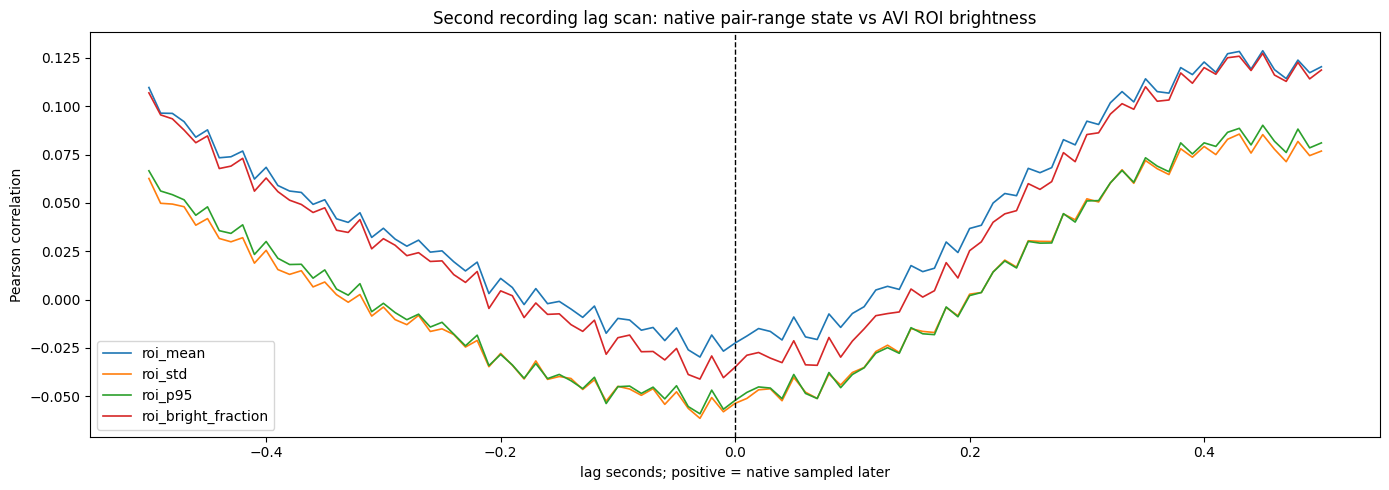

In [30]:
lag_rows = []

frame_times = avi_roi_brightness1["time_s"].to_numpy()

roi_metrics = [
    "roi_mean",
    "roi_std",
    "roi_p95",
    "roi_bright_fraction",
]

lags_s = np.arange(-0.50, 0.501, 0.01)

for lag_s in lags_s:
    shifted_native = np.interp(
        frame_times + lag_s,
        native_time_s_full_1,
        pair_range_mean_0_6_full_1,
        left=np.nan,
        right=np.nan,
    )

    valid = np.isfinite(shifted_native)

    for metric in roi_metrics:
        metric_values = avi_roi_brightness1[metric].to_numpy()
        valid_metric = valid & np.isfinite(metric_values)

        if valid_metric.sum() > 10:
            corr = np.corrcoef(
                shifted_native[valid_metric],
                metric_values[valid_metric],
            )[0, 1]
        else:
            corr = np.nan

        lag_rows.append({
            "lag_s": float(lag_s),
            "roi_metric": metric,
            "corr": float(corr),
            "abs_corr": float(abs(corr)) if np.isfinite(corr) else np.nan,
            "n_samples": int(valid_metric.sum()),
        })

lag_scan1 = pd.DataFrame(lag_rows)

display(
    lag_scan1
    .sort_values("abs_corr", ascending=False)
    .head(20)
)

plt.figure(figsize=(14, 5))

for metric in roi_metrics:
    metric_df = lag_scan1[lag_scan1["roi_metric"] == metric]
    plt.plot(metric_df["lag_s"], metric_df["corr"], linewidth=1.2, label=metric)

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Second recording lag scan: native pair-range state vs AVI ROI brightness")
plt.xlabel("lag seconds; positive = native sampled later")
plt.ylabel("Pearson correlation")
plt.legend()
plt.tight_layout()
plt.show()

### Native PW state versus AVI ROI brightness interpretation

Result classification: mixed evidence.

NB10 tested whether the native PW pair-range state signal is temporally related to displayed Doppler activity in the linked AVI spectral ROI.

This comparison is different from NB06, which mainly compared native PW state signals against linked AVI Doppler audio. Here the reference signal is image-level brightness inside the AVI PW Doppler ROI.

For `202606130411060002SMP`, the corrected native timebase matched the AVI duration:

```text
native duration ≈ 59.23 s
AVI duration ≈ 59.20 s

## Native PW state polarity check

This section tests whether native high-state and low-state polarity differs between recordings.

The previous comparison showed that the first recording had brighter AVI ROI frames during native high state, while the second recording did not. This section checks whether the second recording may have inverted polarity, where native low state corresponds to brighter ROI activity.

This matters because the native pair-range signal is state-like rather than a validated brightness or envelope signal. Its useful relationship to AVI Doppler activity may depend on polarity or segment behavior.



In [31]:
# Use the best lag found for recording 1, but keep this exploratory.
best_lag_s_recording1 = 0.45

native_at_lag_1 = np.interp(
    avi_roi_brightness1["time_s"].to_numpy() + best_lag_s_recording1,
    native_time_s_full_1,
    pair_range_mean_0_6_full_1,
    left=np.nan,
    right=np.nan,
)

polarity_df = avi_roi_brightness1.copy()
polarity_df["native_pair_range_at_lag"] = native_at_lag_1

# Use median split instead of fixed threshold, because absolute native state levels
# may differ between recordings.
median_threshold = np.nanmedian(polarity_df["native_pair_range_at_lag"])

polarity_df["native_state_high"] = np.where(
    polarity_df["native_pair_range_at_lag"] >= median_threshold,
    "high",
    "low",
)

polarity_df["native_state_low_as_active"] = np.where(
    polarity_df["native_pair_range_at_lag"] < median_threshold,
    "active_low",
    "inactive_high",
)

summary_rows = []

for state_column in ["native_state_high", "native_state_low_as_active"]:
    grouped = (
        polarity_df
        .dropna(subset=["native_pair_range_at_lag"])
        .groupby(state_column)
        .agg(
            n_frames=("frame_index", "count"),
            roi_mean_mean=("roi_mean", "mean"),
            roi_std_mean=("roi_std", "mean"),
            roi_p95_mean=("roi_p95", "mean"),
            roi_bright_fraction_mean=("roi_bright_fraction", "mean"),
            native_mean=("native_pair_range_at_lag", "mean"),
        )
        .reset_index()
    )

    grouped.insert(0, "state_definition", state_column)
    summary_rows.append(grouped)

polarity_summary1 = pd.concat(summary_rows, ignore_index=True)
display(polarity_summary1)

display(
    polarity_df[
        [
            "roi_mean",
            "roi_std",
            "roi_p95",
            "roi_bright_fraction",
            "native_pair_range_at_lag",
        ]
    ].corr()
)

,state_definition,native_state_high,n_frames,roi_mean_mean,roi_std_mean,roi_p95_mean,roi_bright_fraction_mean,native_mean,native_state_low_as_active
0,native_state_high,high,698,19.556046,45.493341,142.646562,0.093861,3.443957,NaN
1,native_state_high,low,698,18.833504,44.806576,139.708166,0.090212,-3.102003,NaN
2,native_state_low_as_active,NaN,698,18.833504,44.806576,139.708166,0.090212,-3.102003,active_low
3,native_state_low_as_active,NaN,698,19.556046,45.493341,142.646562,0.093861,3.443957,inactive_high


,roi_mean,roi_std,roi_p95,roi_bright_fraction,native_pair_range_at_lag
roi_mean,1.000000,0.974836,0.970747,0.981103,0.128676
roi_std,0.974836,1.000000,0.991836,0.937628,0.085303
roi_p95,0.970747,0.991836,1.000000,0.941114,0.090143
roi_bright_fraction,0.981103,0.937628,0.941114,1.000000,0.127295
native_pair_range_at_lag,0.128676,0.085303,0.090143,0.127295,1.000000


## AVI Doppler ROI refinement for native comparison

This section tests whether the native PW state relationship improves when the AVI brightness metric is measured from a narrower Doppler-only region.

The previous comparison used the full PW spectral display rectangle from metadata. That region includes background, axes, labels, baseline graphics, and non-spectral display elements. These static or weakly relevant pixels can dilute the relationship between native PW state and visible Doppler activity.

This section compares several candidate sub-ROIs inside the PW spectral region and measures which brightness trace has the strongest lagged relationship with the native pair-range state signal.



In [32]:
file_index_0 = 0
pw_path_0 = pw_files[file_index_0]
recording_dir_0 = pw_path_0.parent.parent
recording_id_0 = recording_dir_0.name

avi_files_0 = sorted((recording_dir_0 / "linked_avi").glob("*.avi"))
if not avi_files_0:
    raise FileNotFoundError(f"No linked AVI found for {recording_id_0}")

avi_path_0 = avi_files_0[0]

print("Testing recording:", recording_id_0)
print("AVI:", avi_path_0)
print("PW:", pw_path_0)

pw_roi_x0 = 79
pw_roi_x1 = 659
pw_roi_y0 = 245
pw_roi_y1 = 508

candidate_rois_0 = [
    {
        "roi_name": "full_pw_roi",
        "x0": pw_roi_x0,
        "x1": pw_roi_x1,
        "y0": pw_roi_y0,
        "y1": pw_roi_y1,
    },
    {
        "roi_name": "inner_margin_10",
        "x0": pw_roi_x0 + 10,
        "x1": pw_roi_x1 - 10,
        "y0": pw_roi_y0 + 10,
        "y1": pw_roi_y1 - 10,
    },
    {
        "roi_name": "center_spectrum_band",
        "x0": pw_roi_x0 + 20,
        "x1": pw_roi_x1 - 20,
        "y0": pw_roi_y0 + 35,
        "y1": pw_roi_y1 - 35,
    },
    {
        "roi_name": "upper_half_spectrum",
        "x0": pw_roi_x0 + 20,
        "x1": pw_roi_x1 - 20,
        "y0": pw_roi_y0 + 20,
        "y1": int((pw_roi_y0 + pw_roi_y1) / 2),
    },
    {
        "roi_name": "lower_half_spectrum",
        "x0": pw_roi_x0 + 20,
        "x1": pw_roi_x1 - 20,
        "y0": int((pw_roi_y0 + pw_roi_y1) / 2),
        "y1": pw_roi_y1 - 20,
    },
    {
        "roi_name": "right_sweep_area",
        "x0": pw_roi_x0 + 180,
        "x1": pw_roi_x1 - 20,
        "y0": pw_roi_y0 + 25,
        "y1": pw_roi_y1 - 25,
    },
]

cap = cv2.VideoCapture(str(avi_path_0))
if not cap.isOpened():
    raise RuntimeError(f"Could not open AVI: {avi_path_0}")

fps_0 = cap.get(cv2.CAP_PROP_FPS)
frame_count_0 = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

roi_rows_0 = []

for frame_index in range(frame_count_0):
    ok, frame_bgr = cap.read()
    if not ok:
        break

    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    time_s = frame_index / fps_0 if fps_0 and fps_0 > 0 else np.nan

    for roi_def in candidate_rois_0:
        roi = gray[
            roi_def["y0"]:roi_def["y1"],
            roi_def["x0"]:roi_def["x1"],
        ]

        roi_rows_0.append({
            "frame_index": frame_index,
            "time_s": time_s,
            "roi_name": roi_def["roi_name"],
            "roi_mean": float(roi.mean()),
            "roi_std": float(roi.std()),
            "roi_p95": float(np.percentile(roi, 95)),
            "roi_bright_fraction": float((roi > 80).mean()),
        })

cap.release()

subroi_brightness0_clean = pd.DataFrame(roi_rows_0)

lags_s = np.arange(-0.30, 0.401, 0.01)
roi_metrics = ["roi_mean", "roi_std", "roi_p95", "roi_bright_fraction"]

scan_rows_0 = []

for roi_name, roi_df in subroi_brightness0_clean.groupby("roi_name"):
    frame_times = roi_df["time_s"].to_numpy()

    for lag_s in lags_s:
        shifted_native = np.interp(
            frame_times + lag_s,
            native_time_s_full,
            pair_range_mean_0_6_full,
            left=np.nan,
            right=np.nan,
        )

        valid_native = np.isfinite(shifted_native)

        for metric in roi_metrics:
            metric_values = roi_df[metric].to_numpy()
            valid = valid_native & np.isfinite(metric_values)

            if valid.sum() > 10:
                corr = np.corrcoef(shifted_native[valid], metric_values[valid])[0, 1]
            else:
                corr = np.nan

            scan_rows_0.append({
                "roi_name": roi_name,
                "metric": metric,
                "lag_s": float(lag_s),
                "corr": float(corr),
                "abs_corr": float(abs(corr)) if np.isfinite(corr) else np.nan,
                "n_samples": int(valid.sum()),
            })

subroi_lag_scan0_clean = pd.DataFrame(scan_rows_0)

display(
    subroi_lag_scan0_clean
    .sort_values("abs_corr", ascending=False)
    .head(30)
)

best_by_roi_0 = (
    subroi_lag_scan0_clean
    .sort_values("abs_corr", ascending=False)
    .groupby("roi_name", as_index=False)
    .head(1)
    .sort_values("abs_corr", ascending=False)
)

display(best_by_roi_0)

Testing recording: 202606130411060002SMP
AVI: ultrasound_recordings\batch_2026_06_13_native\202606130411060002SMP\linked_avi\202606130411060002SMP.avi
PW: ultrasound_recordings\batch_2026_06_13_native\202606130411060002SMP\native\PW_CinePartition0.bin


,roi_name,metric,lag_s,corr,abs_corr,n_samples
1291,right_sweep_area,roi_bright_fraction,0.08,0.335818,0.335818,1775
1303,right_sweep_area,roi_bright_fraction,0.11,0.332796,0.332796,1774
1299,right_sweep_area,roi_bright_fraction,0.10,0.332599,0.332599,1774
1311,right_sweep_area,roi_bright_fraction,0.13,0.331880,0.331880,1773
1283,right_sweep_area,roi_bright_fraction,0.06,0.331302,0.331302,1776
1287,right_sweep_area,roi_bright_fraction,0.07,0.330680,0.330680,1775
1295,right_sweep_area,roi_bright_fraction,0.09,0.330478,0.330478,1775
1279,right_sweep_area,roi_bright_fraction,0.05,0.328806,0.328806,1776
1307,right_sweep_area,roi_bright_fraction,0.12,0.326118,0.326118,1774
1271,right_sweep_area,roi_bright_fraction,0.03,0.324843,0.324843,1776


,roi_name,metric,lag_s,corr,abs_corr,n_samples
1291,right_sweep_area,roi_bright_fraction,0.08,0.335818,0.335818,1775
155,center_spectrum_band,roi_bright_fraction,0.08,0.322061,0.322061,1775
1564,upper_half_spectrum,roi_mean,0.06,0.317627,0.317627,1776
743,inner_margin_10,roi_bright_fraction,0.13,0.311463,0.311463,1773
459,full_pw_roi,roi_bright_fraction,0.13,0.296838,0.296838,1773
1007,lower_half_spectrum,roi_bright_fraction,0.08,0.272310,0.272310,1775


## Refined AVI ROI check in second recording

This section tests whether the native/AVI relationship improves in the second recording when using narrower Doppler sub-ROIs.

The first recording showed a stronger relationship when the AVI brightness metric was measured from the right/central spectral display area rather than the full PW ROI. This section tests the same two sub-ROIs in the second recording.

This matters because the previous full-ROI comparison for the second recording was weak. A refined ROI may reduce static display/background pixels and better isolate Doppler activity.


In [33]:
file_index_1 = 1
pw_path_1 = pw_files[file_index_1]
recording_dir_1 = pw_path_1.parent.parent
recording_id_1 = recording_dir_1.name

avi_files_1 = sorted((recording_dir_1 / "linked_avi").glob("*.avi"))
if not avi_files_1:
    raise FileNotFoundError(f"No linked AVI found for {recording_id_1}")

avi_path_1 = avi_files_1[0]

print("Testing recording:", recording_id_1)
print("AVI:", avi_path_1)
print("PW:", pw_path_1)

pw_roi_x0 = 79
pw_roi_x1 = 659
pw_roi_y0 = 245
pw_roi_y1 = 508

candidate_rois_1 = [
    {
        "roi_name": "center_spectrum_band",
        "x0": pw_roi_x0 + 20,
        "x1": pw_roi_x1 - 20,
        "y0": pw_roi_y0 + 35,
        "y1": pw_roi_y1 - 35,
    },
    {
        "roi_name": "right_sweep_area",
        "x0": pw_roi_x0 + 180,
        "x1": pw_roi_x1 - 20,
        "y0": pw_roi_y0 + 25,
        "y1": pw_roi_y1 - 25,
    },
]

cap = cv2.VideoCapture(str(avi_path_1))
if not cap.isOpened():
    raise RuntimeError(f"Could not open AVI: {avi_path_1}")

fps_1 = cap.get(cv2.CAP_PROP_FPS)
frame_count_1 = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

roi_rows_1 = []

for frame_index in range(frame_count_1):
    ok, frame_bgr = cap.read()
    if not ok:
        break

    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    time_s = frame_index / fps_1 if fps_1 and fps_1 > 0 else np.nan

    for roi_def in candidate_rois_1:
        roi = gray[
            roi_def["y0"]:roi_def["y1"],
            roi_def["x0"]:roi_def["x1"],
        ]

        roi_rows_1.append({
            "frame_index": frame_index,
            "time_s": time_s,
            "roi_name": roi_def["roi_name"],
            "roi_mean": float(roi.mean()),
            "roi_std": float(roi.std()),
            "roi_p95": float(np.percentile(roi, 95)),
            "roi_bright_fraction": float((roi > 80).mean()),
        })

cap.release()

subroi_brightness1_clean = pd.DataFrame(roi_rows_1)

lags_s = np.arange(-0.30, 0.501, 0.01)
roi_metrics = ["roi_mean", "roi_std", "roi_p95", "roi_bright_fraction"]

scan_rows_1 = []

for roi_name, roi_df in subroi_brightness1_clean.groupby("roi_name"):
    frame_times = roi_df["time_s"].to_numpy()

    for lag_s in lags_s:
        shifted_native = np.interp(
            frame_times + lag_s,
            native_time_s_full_1,
            pair_range_mean_0_6_full_1,
            left=np.nan,
            right=np.nan,
        )

        valid_native = np.isfinite(shifted_native)

        for metric in roi_metrics:
            metric_values = roi_df[metric].to_numpy()
            valid = valid_native & np.isfinite(metric_values)

            if valid.sum() > 10:
                corr = np.corrcoef(shifted_native[valid], metric_values[valid])[0, 1]
            else:
                corr = np.nan

            scan_rows_1.append({
                "roi_name": roi_name,
                "metric": metric,
                "lag_s": float(lag_s),
                "corr": float(corr),
                "abs_corr": float(abs(corr)) if np.isfinite(corr) else np.nan,
                "n_samples": int(valid.sum()),
            })

subroi_lag_scan1_clean = pd.DataFrame(scan_rows_1)

display(
    subroi_lag_scan1_clean
    .sort_values("abs_corr", ascending=False)
    .head(30)
)

best_by_roi_1 = (
    subroi_lag_scan1_clean
    .sort_values("abs_corr", ascending=False)
    .groupby("roi_name", as_index=False)
    .head(1)
    .sort_values("abs_corr", ascending=False)
)

display(best_by_roi_1)

Testing recording: 202606130413540003SMP
AVI: ultrasound_recordings\batch_2026_06_13_native\202606130413540003SMP\linked_avi\202606130413540003SMP.avi
PW: ultrasound_recordings\batch_2026_06_13_native\202606130413540003SMP\native\PW_CinePartition0.bin


,roi_name,metric,lag_s,corr,abs_corr,n_samples
20,center_spectrum_band,roi_mean,-0.25,0.133654,0.133654,1402
23,center_spectrum_band,roi_bright_fraction,-0.25,0.132340,0.132340,1402
35,center_spectrum_band,roi_bright_fraction,-0.22,0.132045,0.132045,1403
32,center_spectrum_band,roi_mean,-0.22,0.131934,0.131934,1403
51,center_spectrum_band,roi_bright_fraction,-0.18,0.130036,0.130036,1404
48,center_spectrum_band,roi_mean,-0.18,0.129892,0.129892,1404
12,center_spectrum_band,roi_mean,-0.27,0.127807,0.127807,1401
40,center_spectrum_band,roi_mean,-0.20,0.127723,0.127723,1404
63,center_spectrum_band,roi_bright_fraction,-0.15,0.126468,0.126468,1405
0,center_spectrum_band,roi_mean,-0.30,0.125936,0.125936,1401


,roi_name,metric,lag_s,corr,abs_corr,n_samples
20,center_spectrum_band,roi_mean,-0.25,0.133654,0.133654,1402
627,right_sweep_area,roi_bright_fraction,0.45,0.121515,0.121515,1396


## Native feature search against refined AVI ROI

This section tests whether another native PW dynamic feature relates to AVI Doppler ROI brightness better than `pair_range_mean_0_6`.

The previous section showed that the second recording remains weak when using `pair_range_mean_0_6`, even with refined AVI sub-ROIs. This section compares multiple native features derived from the 16 dynamic records against a refined AVI ROI brightness trace.

This matters because the native PW binary may contain several state features, and the best feature may differ by recording or segment.


In [34]:
# Build native feature candidates from recording 1 full dynamic records.
n_pages_1 = records_full.shape[0]

value_matrix_1 = np.zeros((n_pages_1, 16), dtype=np.float32)

for record_index in range(16):
    value_matrix_1[:, record_index] = (
        records_full[:, record_index, 4:8]
        .copy()
        .view("<f4")
        .reshape(-1)
    )

feature_dict = {}

for record_index in range(16):
    feature_dict[f"value_record_{record_index:02d}"] = value_matrix_1[:, record_index]

pair_range_matrix_1 = np.zeros((n_pages_1, 8), dtype=np.float32)

for pair_index in range(8):
    even_values = value_matrix_1[:, pair_index * 2]
    odd_values = value_matrix_1[:, pair_index * 2 + 1]
    pair_range_matrix_1[:, pair_index] = even_values - odd_values
    feature_dict[f"pair_range_{pair_index}"] = pair_range_matrix_1[:, pair_index]

feature_dict["pair_range_mean_0_6"] = pair_range_matrix_1[:, :7].mean(axis=1)
feature_dict["pair_range_mean_0_7"] = pair_range_matrix_1.mean(axis=1)
feature_dict["value_even_mean"] = value_matrix_1[:, 0::2].mean(axis=1)
feature_dict["value_odd_mean"] = value_matrix_1[:, 1::2].mean(axis=1)
feature_dict["value_all_mean"] = value_matrix_1.mean(axis=1)
feature_dict["value_all_std"] = value_matrix_1.std(axis=1)
feature_dict["value_all_min"] = value_matrix_1.min(axis=1)
feature_dict["value_all_max"] = value_matrix_1.max(axis=1)

roi_df_1 = (
    subroi_brightness1_clean[
        subroi_brightness1_clean["roi_name"] == "center_spectrum_band"
    ]
    .sort_values("time_s")
    .copy()
)

target_metric = "roi_mean"
frame_times = roi_df_1["time_s"].to_numpy()
target_values = roi_df_1[target_metric].to_numpy()

lags_s = np.arange(-0.50, 0.501, 0.01)

feature_scan_rows = []

for feature_name, feature_values in feature_dict.items():
    for lag_s in lags_s:
        shifted_feature = np.interp(
            frame_times + lag_s,
            native_time_s_full_1,
            feature_values,
            left=np.nan,
            right=np.nan,
        )

        valid = np.isfinite(shifted_feature) & np.isfinite(target_values)

        if valid.sum() > 10:
            corr = np.corrcoef(shifted_feature[valid], target_values[valid])[0, 1]
        else:
            corr = np.nan

        feature_scan_rows.append({
            "feature_name": feature_name,
            "target_roi": "center_spectrum_band",
            "target_metric": target_metric,
            "lag_s": float(lag_s),
            "corr": float(corr),
            "abs_corr": float(abs(corr)) if np.isfinite(corr) else np.nan,
            "n_samples": int(valid.sum()),
        })

native_feature_scan1 = pd.DataFrame(feature_scan_rows)

display(
    native_feature_scan1
    .sort_values("abs_corr", ascending=False)
    .head(40)
)

best_by_feature1 = (
    native_feature_scan1
    .sort_values("abs_corr", ascending=False)
    .groupby("feature_name", as_index=False)
    .head(1)
    .sort_values("abs_corr", ascending=False)
)

display(best_by_feature1.head(30))

,feature_name,target_roi,target_metric,lag_s,corr,abs_corr,n_samples
2895,value_all_mean,center_spectrum_band,roi_mean,0.17,-0.181745,0.181745,1405
2898,value_all_mean,center_spectrum_band,roi_mean,0.20,-0.179800,0.179800,1404
2900,value_all_mean,center_spectrum_band,roi_mean,0.22,-0.177276,0.177276,1403
2901,value_all_mean,center_spectrum_band,roi_mean,0.23,-0.176836,0.176836,1403
2891,value_all_mean,center_spectrum_band,roi_mean,0.13,-0.175498,0.175498,1406
1552,value_record_15,center_spectrum_band,roi_mean,-0.13,-0.175179,0.175179,1406
2892,value_all_mean,center_spectrum_band,roi_mean,0.14,-0.174869,0.174869,1406
2893,value_all_mean,center_spectrum_band,roi_mean,0.15,-0.173297,0.173297,1405
2902,value_all_mean,center_spectrum_band,roi_mean,0.24,-0.172950,0.172950,1403
2894,value_all_mean,center_spectrum_band,roi_mean,0.16,-0.172869,0.172869,1405


,feature_name,target_roi,target_metric,lag_s,corr,abs_corr,n_samples
2895,value_all_mean,center_spectrum_band,roi_mean,0.17,-0.181745,0.181745,1405
1552,value_record_15,center_spectrum_band,roi_mean,-0.13,-0.175179,0.175179,1406
1346,value_record_13,center_spectrum_band,roi_mean,-0.17,-0.168099,0.168099,1404
131,value_record_01,center_spectrum_band,roi_mean,-0.20,-0.167280,0.167280,1404
2757,value_odd_mean,center_spectrum_band,roi_mean,-0.20,-0.165780,0.165780,1404
1144,value_record_11,center_spectrum_band,roi_mean,-0.17,-0.165659,0.165659,1404
335,value_record_03,center_spectrum_band,roi_mean,-0.18,-0.164873,0.164873,1404
539,value_record_05,center_spectrum_band,roi_mean,-0.16,-0.164477,0.164477,1405
972,value_record_09,center_spectrum_band,roi_mean,0.13,-0.163787,0.163787,1406
741,value_record_07,center_spectrum_band,roi_mean,-0.16,-0.163089,0.163089,1405


## Segment-level native feature check in second recording

This section tests whether the best weak native feature in the second recording has stronger association with AVI ROI brightness in shorter segments.

The previous feature search found that `value_all_mean` had the strongest full-recording association with the refined AVI ROI, but the relationship was weak. This section checks whether that weak full-recording result hides stronger segment-level relationships.

This matters because NB06 already showed that native PW state behavior can be segment-dependent.


,segment_start_s,segment_end_s,feature_name,target_roi,target_metric,lag_s,corr,abs_corr,n_frames
10,25.0,30.0,value_all_mean,center_spectrum_band,roi_mean,0.29,-0.713968,0.713968,150
9,22.5,27.5,value_all_mean,center_spectrum_band,roi_mean,0.26,-0.662199,0.662199,150
11,27.5,32.5,value_all_mean,center_spectrum_band,roi_mean,0.29,-0.610856,0.610856,150
7,17.5,22.5,value_all_mean,center_spectrum_band,roi_mean,0.22,-0.568587,0.568587,150
8,20.0,25.0,value_all_mean,center_spectrum_band,roi_mean,-0.47,0.565154,0.565154,150
16,40.0,45.0,value_all_mean,center_spectrum_band,roi_mean,0.25,-0.493058,0.493058,150
14,35.0,40.0,value_all_mean,center_spectrum_band,roi_mean,0.18,-0.474977,0.474977,150
5,12.5,17.5,value_all_mean,center_spectrum_band,roi_mean,0.50,0.464245,0.464245,150
6,15.0,20.0,value_all_mean,center_spectrum_band,roi_mean,-0.49,0.443560,0.443560,150
4,10.0,15.0,value_all_mean,center_spectrum_band,roi_mean,0.48,0.410571,0.410571,150


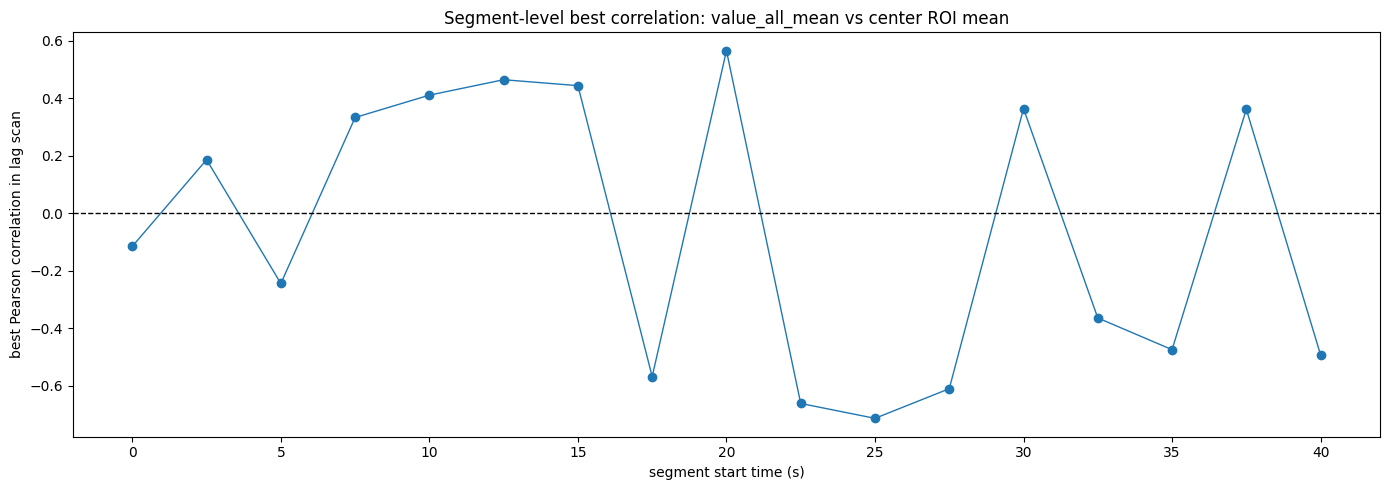

In [35]:
feature_name = "value_all_mean"
feature_values = feature_dict[feature_name]

target_metric = "roi_mean"
target_values_all = roi_df_1[target_metric].to_numpy()
frame_times_all = roi_df_1["time_s"].to_numpy()

segment_length_s = 5
segment_step_s = 2.5
lags_s = np.arange(-0.50, 0.501, 0.01)

segment_rows = []

start_s = 0.0
max_time_s = float(np.nanmax(frame_times_all))

while start_s + segment_length_s <= max_time_s:
    end_s = start_s + segment_length_s

    segment_mask = (
        (frame_times_all >= start_s)
        & (frame_times_all < end_s)
        & np.isfinite(target_values_all)
    )

    if segment_mask.sum() >= 30:
        segment_times = frame_times_all[segment_mask]
        segment_target = target_values_all[segment_mask]

        best_row = None

        for lag_s in lags_s:
            shifted_feature = np.interp(
                segment_times + lag_s,
                native_time_s_full_1,
                feature_values,
                left=np.nan,
                right=np.nan,
            )

            valid = np.isfinite(shifted_feature) & np.isfinite(segment_target)

            if valid.sum() > 10:
                corr = np.corrcoef(
                    shifted_feature[valid],
                    segment_target[valid],
                )[0, 1]
            else:
                corr = np.nan

            row = {
                "segment_start_s": float(start_s),
                "segment_end_s": float(end_s),
                "feature_name": feature_name,
                "target_roi": "center_spectrum_band",
                "target_metric": target_metric,
                "lag_s": float(lag_s),
                "corr": float(corr),
                "abs_corr": float(abs(corr)) if np.isfinite(corr) else np.nan,
                "n_frames": int(valid.sum()),
            }

            if best_row is None or row["abs_corr"] > best_row["abs_corr"]:
                best_row = row

        segment_rows.append(best_row)

    start_s += segment_step_s

segment_feature_scan1 = pd.DataFrame(segment_rows)

display(
    segment_feature_scan1
    .sort_values("abs_corr", ascending=False)
    .head(20)
)

plt.figure(figsize=(14, 5))
plt.plot(
    segment_feature_scan1["segment_start_s"],
    segment_feature_scan1["corr"],
    marker="o",
    linewidth=1,
)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Segment-level best correlation: value_all_mean vs center ROI mean")
plt.xlabel("segment start time (s)")
plt.ylabel("best Pearson correlation in lag scan")
plt.tight_layout()
plt.show()

## Strong segment visual check for native feature association

This section visually inspects the strongest segment-level native/AVI association found in the second recording.

The previous section found that `value_all_mean` has strong segment-level association with center Doppler ROI brightness in some windows, especially `25..30 s`. This section plots that segment using the best lag from the scan.



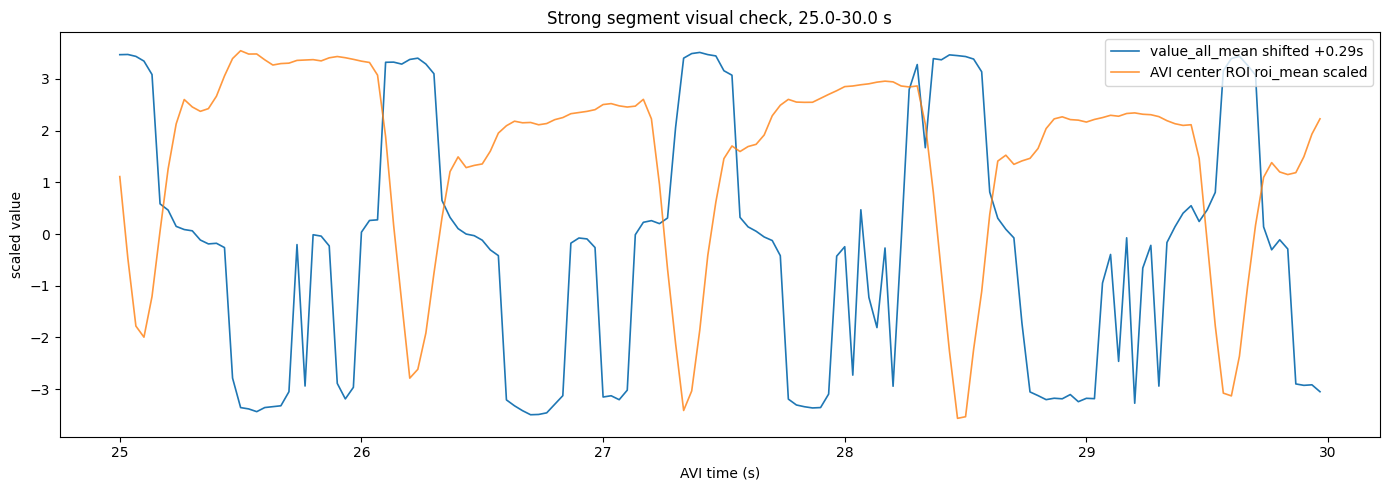

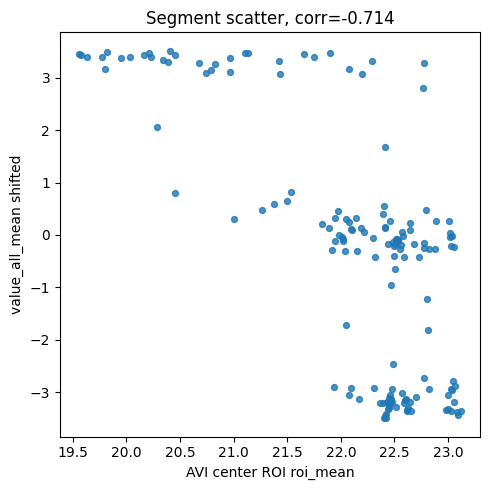

segment_corr: -0.7139681661910356
segment_start_s: 25.0
segment_end_s: 30.0
best_segment_lag_s: 0.29
n_frames: 150


In [36]:
feature_name = "value_all_mean"
target_metric = "roi_mean"

segment_start_s = 25.0
segment_end_s = 30.0
best_segment_lag_s = 0.29

feature_values = feature_dict[feature_name]

segment_df = roi_df_1[
    (roi_df_1["time_s"] >= segment_start_s)
    & (roi_df_1["time_s"] < segment_end_s)
].copy()

segment_times = segment_df["time_s"].to_numpy()
target_values = segment_df[target_metric].to_numpy()

native_shifted = np.interp(
    segment_times + best_segment_lag_s,
    native_time_s_full_1,
    feature_values,
    left=np.nan,
    right=np.nan,
)

segment_df["native_value_all_mean_shifted"] = native_shifted

valid = (
    np.isfinite(segment_df[target_metric].to_numpy())
    & np.isfinite(segment_df["native_value_all_mean_shifted"].to_numpy())
)

segment_corr = np.corrcoef(
    segment_df.loc[valid, target_metric],
    segment_df.loc[valid, "native_value_all_mean_shifted"],
)[0, 1]

scaled_roi_mean = scale_to_reference(
    segment_df[target_metric],
    segment_df["native_value_all_mean_shifted"],
)

plt.figure(figsize=(14, 5))
plt.plot(
    segment_df["time_s"],
    segment_df["native_value_all_mean_shifted"],
    linewidth=1.2,
    label=f"{feature_name} shifted {best_segment_lag_s:+.2f}s",
)
plt.plot(
    segment_df["time_s"],
    scaled_roi_mean,
    linewidth=1.2,
    alpha=0.8,
    label=f"AVI center ROI {target_metric} scaled",
)
plt.title(f"Strong segment visual check, {segment_start_s}-{segment_end_s} s")
plt.xlabel("AVI time (s)")
plt.ylabel("scaled value")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 5))
plt.scatter(
    segment_df[target_metric],
    segment_df["native_value_all_mean_shifted"],
    s=18,
    alpha=0.8,
)
plt.title(f"Segment scatter, corr={segment_corr:.3f}")
plt.xlabel(f"AVI center ROI {target_metric}")
plt.ylabel(f"{feature_name} shifted")
plt.tight_layout()
plt.show()

print("segment_corr:", segment_corr)
print("segment_start_s:", segment_start_s)
print("segment_end_s:", segment_end_s)
print("best_segment_lag_s:", best_segment_lag_s)
print("n_frames:", int(valid.sum()))

### Segment-level native feature interpretation

Result classification: useful positive result with state-like polarity.

The second recording did not show a strong full-recording relationship between `pair_range_mean_0_6` and AVI ROI brightness. However, segment-level screening found stronger relationships for another native feature, `value_all_mean`.

In the `25..30 s` segment, `value_all_mean` showed a strong inverse association with center Doppler ROI brightness:

```text
correlation ≈ -0.714
lag ≈ +0.29 s

## Native state transitions versus AVI ROI brightness changes

This section tests whether native PW state transitions align with changes in AVI Doppler ROI brightness.

The previous sections showed that native PW features behave like state variables rather than continuous brightness traces. Recording 0 and recording 1 both showed segment-level relationships, but with different features and polarity.

This section compares state transitions in a native feature against frame-to-frame changes in AVI ROI brightness.

This matters because a compact native PW state stream may mark display/acquisition state transitions rather than storing spectrogram intensity directly.


,segment_start_s,segment_end_s,feature_name,target_metric,lag_s,roi_transition_threshold,native_transition_threshold,n_roi_transitions,n_native_transitions,same_frame_overlap,roi_transitions_matched_within_1_frame,roi_transition_match_fraction_within_1_frame
0,25.0,30.0,value_all_mean,roi_mean,0.29,0.600042,2.593908,23,23,0,2,0.086957


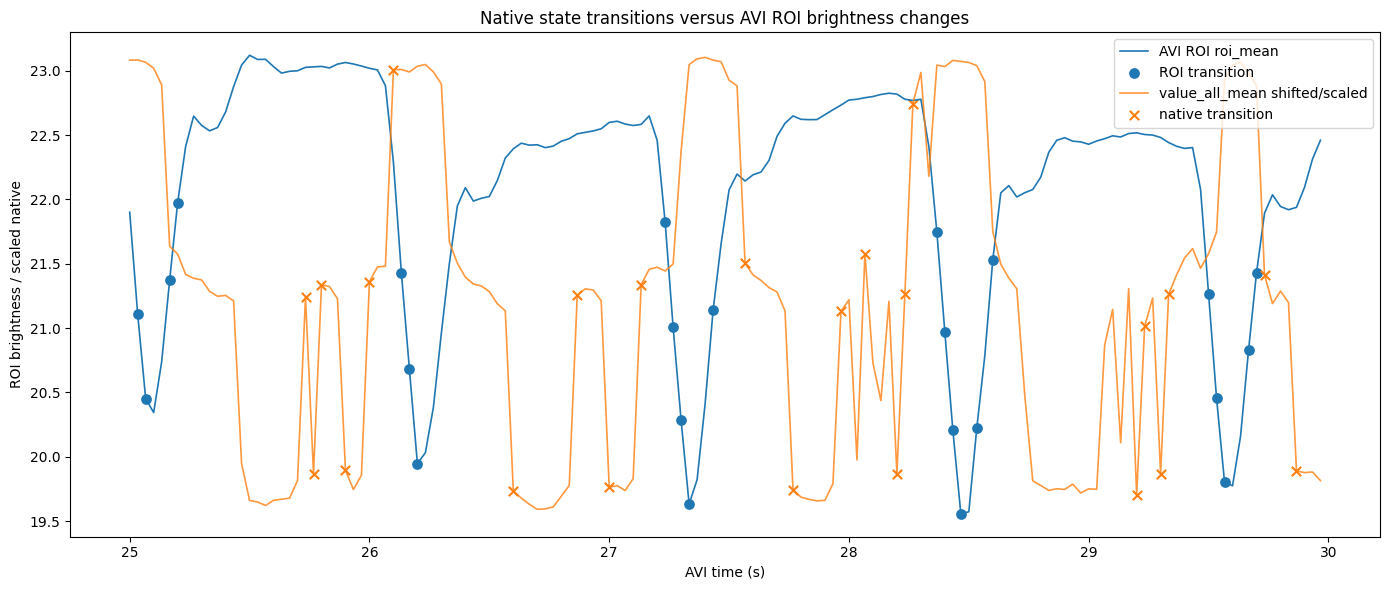

In [37]:
feature_name = "value_all_mean"
target_metric = "roi_mean"

segment_start_s = 25.0
segment_end_s = 30.0
best_segment_lag_s = 0.29

feature_values = feature_dict[feature_name]

segment_df = roi_df_1[
    (roi_df_1["time_s"] >= segment_start_s)
    & (roi_df_1["time_s"] < segment_end_s)
].copy()

segment_times = segment_df["time_s"].to_numpy()
roi_values = segment_df[target_metric].to_numpy()

native_shifted = np.interp(
    segment_times + best_segment_lag_s,
    native_time_s_full_1,
    feature_values,
    left=np.nan,
    right=np.nan,
)

segment_df["native_shifted"] = native_shifted

# Frame-to-frame changes.
segment_df["roi_delta_abs"] = segment_df[target_metric].diff().abs()
segment_df["native_delta_abs"] = segment_df["native_shifted"].diff().abs()

# Mark the strongest transition frames by percentile.
roi_transition_threshold = np.nanpercentile(segment_df["roi_delta_abs"], 85)
native_transition_threshold = np.nanpercentile(segment_df["native_delta_abs"], 85)

segment_df["roi_transition"] = segment_df["roi_delta_abs"] >= roi_transition_threshold
segment_df["native_transition"] = segment_df["native_delta_abs"] >= native_transition_threshold

transition_summary = {
    "segment_start_s": segment_start_s,
    "segment_end_s": segment_end_s,
    "feature_name": feature_name,
    "target_metric": target_metric,
    "lag_s": best_segment_lag_s,
    "roi_transition_threshold": roi_transition_threshold,
    "native_transition_threshold": native_transition_threshold,
    "n_roi_transitions": int(segment_df["roi_transition"].sum()),
    "n_native_transitions": int(segment_df["native_transition"].sum()),
    "same_frame_overlap": int((segment_df["roi_transition"] & segment_df["native_transition"]).sum()),
}

# Allow +/- 1 AVI frame tolerance.
native_transition_indices = np.flatnonzero(segment_df["native_transition"].to_numpy())
roi_transition_indices = np.flatnonzero(segment_df["roi_transition"].to_numpy())

matched_roi = 0
for roi_index in roi_transition_indices:
    if np.any(np.abs(native_transition_indices - roi_index) <= 1):
        matched_roi += 1

transition_summary["roi_transitions_matched_within_1_frame"] = int(matched_roi)
transition_summary["roi_transition_match_fraction_within_1_frame"] = (
    matched_roi / len(roi_transition_indices) if len(roi_transition_indices) else np.nan
)

display(pd.DataFrame([transition_summary]))

plt.figure(figsize=(14, 6))

plt.plot(
    segment_df["time_s"],
    segment_df[target_metric],
    linewidth=1.2,
    label=f"AVI ROI {target_metric}",
)

plt.scatter(
    segment_df.loc[segment_df["roi_transition"], "time_s"],
    segment_df.loc[segment_df["roi_transition"], target_metric],
    s=45,
    label="ROI transition",
)

scaled_native = scale_to_reference(
    segment_df["native_shifted"],
    segment_df[target_metric],
)

plt.plot(
    segment_df["time_s"],
    scaled_native,
    linewidth=1.2,
    alpha=0.8,
    label=f"{feature_name} shifted/scaled",
)

plt.scatter(
    segment_df.loc[segment_df["native_transition"], "time_s"],
    scaled_native[segment_df["native_transition"]],
    s=45,
    marker="x",
    label="native transition",
)

plt.title("Native state transitions versus AVI ROI brightness changes")
plt.xlabel("AVI time (s)")
plt.ylabel("ROI brightness / scaled native")
plt.legend()
plt.tight_layout()
plt.show()

## Native state bands versus AVI ROI brightness

This section tests whether native state bands correspond to different AVI ROI brightness levels.

The previous section showed that native state transitions do not align tightly with frame-to-frame AVI brightness changes. This section instead treats the native feature as a state variable and compares AVI ROI brightness distributions across native state bands.

This matters because the native PW binary may encode compact display/acquisition states rather than explicit brightness transitions or raster pixels.


,native_state_band,n_frames,native_mean,native_min,native_max,roi_mean_mean,roi_mean_std,roi_std_mean,roi_p95_mean,roi_bright_fraction_mean
0,high_native,50,2.405502,0.262977,3.514001,21.184127,1.005119,46.705734,146.601,0.102654
1,low_native,50,-3.103008,-3.495918,-1.725920,22.604843,0.304488,48.243653,151.580,0.110701
2,mid_native,50,-0.139025,-1.225822,0.259310,22.452819,0.334665,48.068743,151.101,0.110048


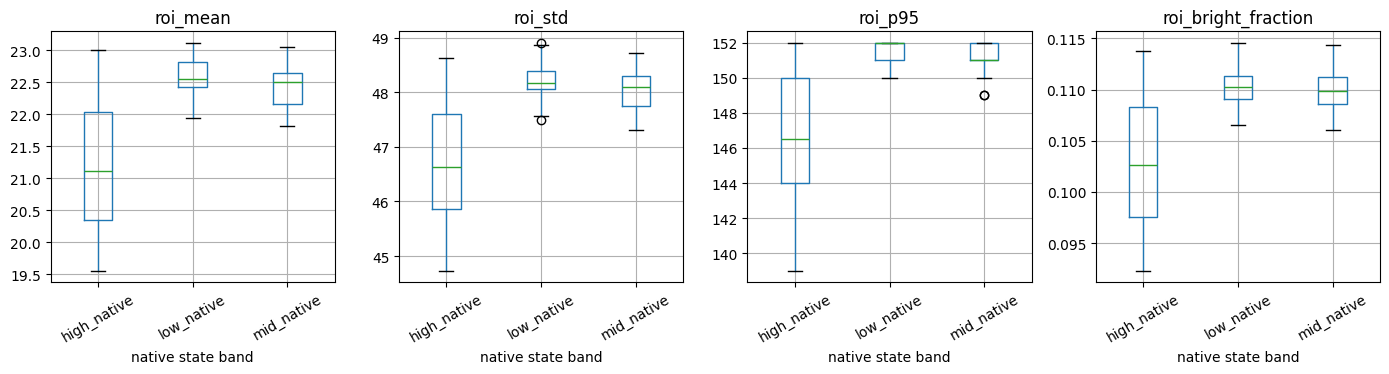

In [38]:
feature_name = "value_all_mean"
target_metric = "roi_mean"

segment_start_s = 25.0
segment_end_s = 30.0
best_segment_lag_s = 0.29

feature_values = feature_dict[feature_name]

state_band_df = roi_df_1[
    (roi_df_1["time_s"] >= segment_start_s)
    & (roi_df_1["time_s"] < segment_end_s)
].copy()

state_band_df["native_value_all_mean_shifted"] = np.interp(
    state_band_df["time_s"].to_numpy() + best_segment_lag_s,
    native_time_s_full_1,
    feature_values,
    left=np.nan,
    right=np.nan,
)

low_cut = np.nanpercentile(state_band_df["native_value_all_mean_shifted"], 33.3)
high_cut = np.nanpercentile(state_band_df["native_value_all_mean_shifted"], 66.7)

def assign_native_state_band(value):
    """This function assigns a shifted native value to a low, mid, or high state band."""
    if not np.isfinite(value):
        return "missing"
    if value <= low_cut:
        return "low_native"
    if value >= high_cut:
        return "high_native"
    return "mid_native"

state_band_df["native_state_band"] = state_band_df["native_value_all_mean_shifted"].apply(
    assign_native_state_band
)

state_band_summary = (
    state_band_df
    .groupby("native_state_band")
    .agg(
        n_frames=("frame_index", "count"),
        native_mean=("native_value_all_mean_shifted", "mean"),
        native_min=("native_value_all_mean_shifted", "min"),
        native_max=("native_value_all_mean_shifted", "max"),
        roi_mean_mean=("roi_mean", "mean"),
        roi_mean_std=("roi_mean", "std"),
        roi_std_mean=("roi_std", "mean"),
        roi_p95_mean=("roi_p95", "mean"),
        roi_bright_fraction_mean=("roi_bright_fraction", "mean"),
    )
    .reset_index()
)

display(state_band_summary)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

metrics = ["roi_mean", "roi_std", "roi_p95", "roi_bright_fraction"]

for ax, metric in zip(axes, metrics):
    state_band_df.boxplot(column=metric, by="native_state_band", ax=ax)
    ax.set_title(metric)
    ax.set_xlabel("native state band")
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("")
plt.tight_layout()
plt.show()

### Native PW state versus AVI ROI checkpoint

Result classification: mixed but useful evidence.

NB10 compared native PW dynamic features from `PW_CinePartition0.bin` against brightness metrics extracted from the linked AVI Doppler spectral ROI.

This comparison is different from NB06. NB06 mainly compared native PW state signals against linked AVI Doppler audio. NB10 tested whether native state features relate to the visible Doppler image region.

Evidence-supported findings:

- In `202606130411060002SMP`, `pair_range_mean_0_6` showed a lagged relationship with AVI ROI brightness.
- The relationship improved when brightness was measured in a refined right/central spectral ROI rather than the full PW display region.
- Best observed refined-ROI relationship in recording 0:

```text
right_sweep_area roi_bright_fraction
lag ≈ +0.08 s
correlation ≈ 0.336

## Native state bands across Doppler brightness phase

This section tests whether native PW state bands correspond to phase within the AVI Doppler brightness cycle.

The previous section showed that native state features can separate brighter and dimmer Doppler ROI states in selected segments, but native state transitions did not align tightly with frame-to-frame brightness transitions. This section treats the AVI ROI brightness pattern as a cycle and checks where native state bands occur within that cycle.

This matters because the native PW dynamic block may encode compact state related to cardiac/Doppler cycle phase rather than direct spectrogram intensity or transition timing.


cycle anchors found: 5
cycle anchor times: [25.1        26.2        27.33333333 28.46666667 29.6       ]


,native_state_band,n_frames,phase_mean,phase_std,phase_min,phase_max,roi_mean_mean,native_mean
0,high_native,43,0.438938,0.415208,0.000000,0.970588,21.245428,2.249238
1,low_native,46,0.511121,0.153843,0.235294,0.794118,22.640007,-3.116426
2,mid_native,46,0.502480,0.249341,0.121212,0.911765,22.496708,-0.138825


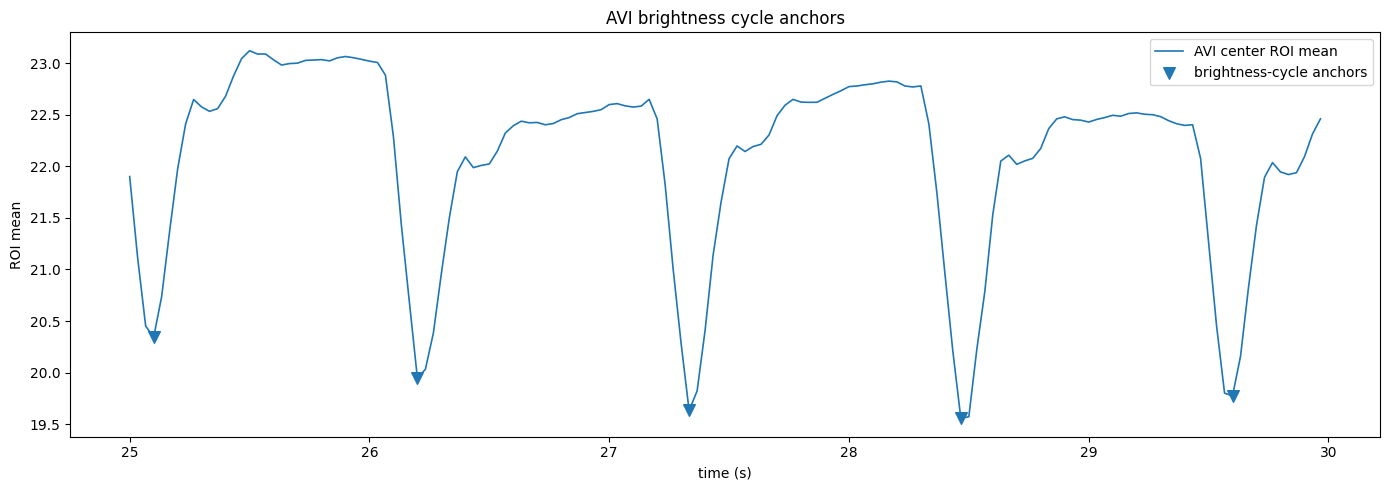

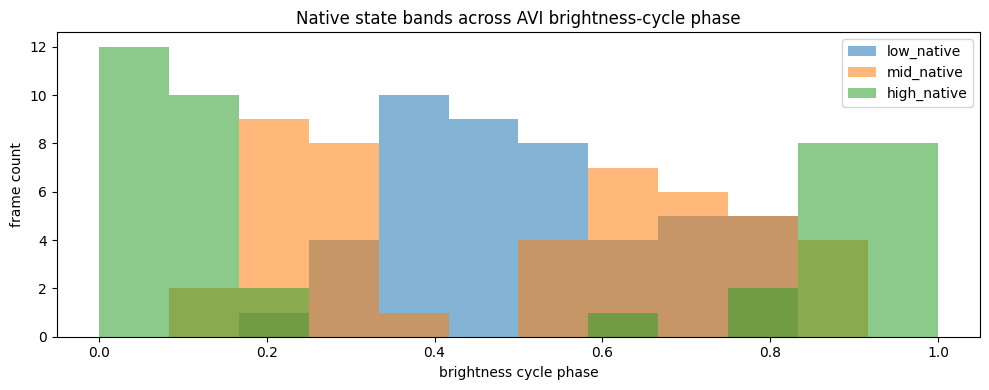

In [39]:
phase_df = state_band_df.copy().sort_values("time_s").reset_index(drop=True)

# Use inverted ROI mean minima as cycle anchors because the 25-30 s segment
# shows clear brightness dips.
roi_signal = phase_df["roi_mean"].to_numpy()
time_s = phase_df["time_s"].to_numpy()

inverted_roi = -roi_signal

peaks, properties = find_peaks(
    inverted_roi,
    distance=18,      # about 0.6 s at 30 fps
    prominence=0.6,
)

cycle_anchor_times = time_s[peaks]

print("cycle anchors found:", len(cycle_anchor_times))
print("cycle anchor times:", cycle_anchor_times)

phase_values = np.full(len(phase_df), np.nan)

if len(cycle_anchor_times) >= 2:
    for cycle_index in range(len(cycle_anchor_times) - 1):
        start_t = cycle_anchor_times[cycle_index]
        end_t = cycle_anchor_times[cycle_index + 1]
        mask = (time_s >= start_t) & (time_s < end_t)

        phase_values[mask] = (time_s[mask] - start_t) / (end_t - start_t)

phase_df["brightness_cycle_phase"] = phase_values

phase_valid_df = phase_df.dropna(subset=["brightness_cycle_phase"]).copy()

phase_band_summary = (
    phase_valid_df
    .groupby("native_state_band")
    .agg(
        n_frames=("frame_index", "count"),
        phase_mean=("brightness_cycle_phase", "mean"),
        phase_std=("brightness_cycle_phase", "std"),
        phase_min=("brightness_cycle_phase", "min"),
        phase_max=("brightness_cycle_phase", "max"),
        roi_mean_mean=("roi_mean", "mean"),
        native_mean=("native_value_all_mean_shifted", "mean"),
    )
    .reset_index()
)

display(phase_band_summary)

plt.figure(figsize=(14, 5))
plt.plot(
    phase_df["time_s"],
    phase_df["roi_mean"],
    linewidth=1.2,
    label="AVI center ROI mean",
)

plt.scatter(
    cycle_anchor_times,
    roi_signal[peaks],
    s=70,
    marker="v",
    label="brightness-cycle anchors",
)

plt.title("AVI brightness cycle anchors")
plt.xlabel("time (s)")
plt.ylabel("ROI mean")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))

for state_band in ["low_native", "mid_native", "high_native"]:
    values = phase_valid_df.loc[
        phase_valid_df["native_state_band"] == state_band,
        "brightness_cycle_phase",
    ]

    plt.hist(
        values,
        bins=np.linspace(0, 1, 13),
        alpha=0.55,
        label=state_band,
    )

plt.title("Native state bands across AVI brightness-cycle phase")
plt.xlabel("brightness cycle phase")
plt.ylabel("frame count")
plt.legend()
plt.tight_layout()
plt.show()

## Recording 0 native state bands across Doppler brightness phase

This section tests whether native PW state bands correspond to phase within the AVI Doppler brightness cycle in recording `202606130411060002SMP`.

### What this tests

This experiment tests whether the recording-0 native feature `pair_range_mean_0_6`, shifted by the best observed lag of `+0.08 s`, separates into low, mid, and high native state bands that occupy different phases of the AVI Doppler brightness cycle.

### Why this matters

The previous phase experiment found state-band structure in recording 1 using `value_all_mean`. This experiment tests whether a similar state/phase relationship appears in recording 0 using the strongest recording-0 candidate feature and refined AVI ROI.


recording: 202606130411060002SMP
roi: right_sweep_area
metric: roi_bright_fraction
feature: pair_range_mean_0_6
lag_s: 0.08
segment_start_s: 26.0
segment_end_s: 35.0
frames in segment: 270
cycle anchors found: 9
cycle anchor times: [26.367 27.333 28.3   29.267 30.2   31.167 32.1   33.033 33.967]
cycle spacing seconds: [0.967 0.967 0.967 0.933 0.967 0.933 0.933 0.933]


,native_state_band,n_frames,phase_mean,phase_std,phase_median,phase_min,phase_max,roi_metric_mean,native_mean
0,high_native,76,0.268603,0.187522,0.245690,0.000000,0.964286,0.149917,7.556832
1,low_native,74,0.666023,0.114754,0.655172,0.482759,0.896552,0.141774,-0.154662
2,mid_native,78,0.516673,0.347857,0.464286,0.000000,0.965517,0.157927,2.448705


native_state_band,high_native,low_native,mid_native
phase_bin,,,
"(-0.001, 0.167]",20,0,20
"(0.167, 0.333]",35,0,5
"(0.333, 0.5]",18,3,17
"(0.5, 0.667]",0,37,1
"(0.667, 0.833]",0,27,13
"(0.833, 1.0]",3,7,22


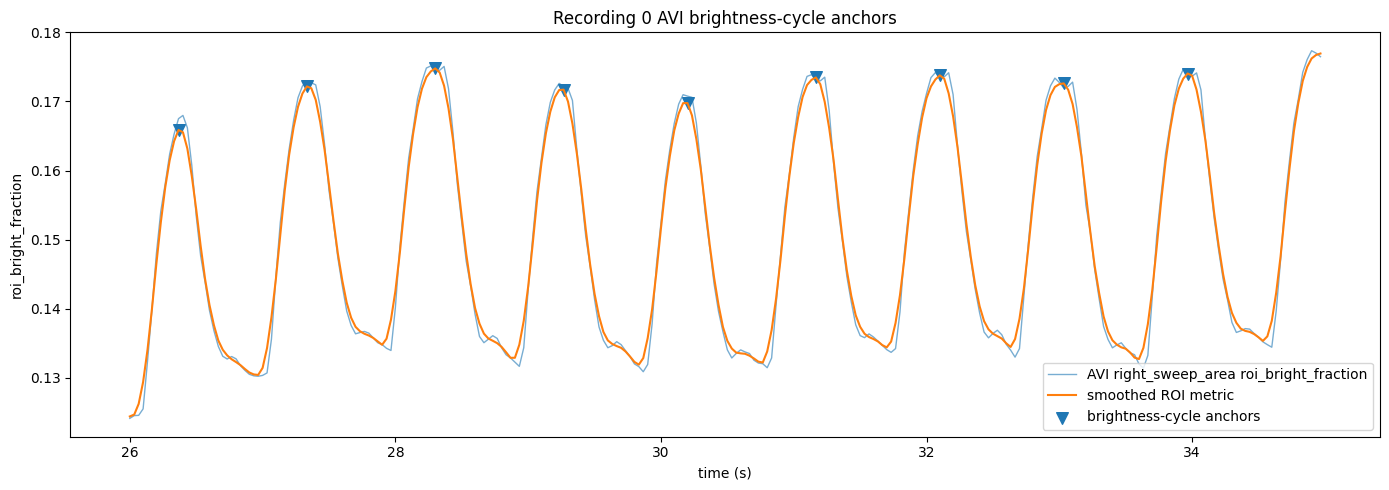

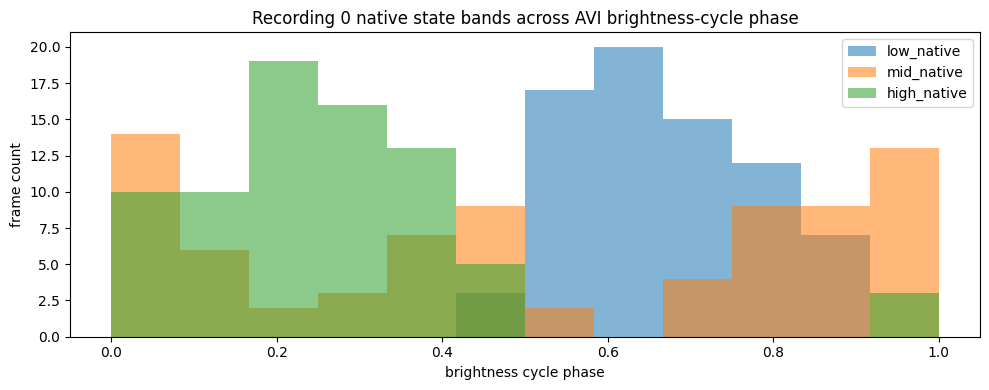

In [40]:
required_names = [
    "subroi_brightness0_clean",
    "native_time_s_full",
    "pair_range_mean_0_6_full",
    "find_peaks",
]

missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise NameError(f"Missing required notebook variables: {missing_names}")

recording0_phase_roi = "right_sweep_area"
recording0_phase_metric = "roi_bright_fraction"
recording0_feature_name = "pair_range_mean_0_6"
recording0_lag_s = 0.08

segment_start_s = 26.0
segment_end_s = 35.0

recording0_phase_df = (
    subroi_brightness0_clean[
        (subroi_brightness0_clean["roi_name"] == recording0_phase_roi)
        & (subroi_brightness0_clean["time_s"] >= segment_start_s)
        & (subroi_brightness0_clean["time_s"] < segment_end_s)
    ]
    .sort_values("time_s")
    .reset_index(drop=True)
    .copy()
)

if len(recording0_phase_df) < 60:
    raise ValueError(f"Too few frames in selected segment: {len(recording0_phase_df)}")

recording0_phase_df["native_shifted"] = np.interp(
    recording0_phase_df["time_s"].to_numpy() + recording0_lag_s,
    native_time_s_full,
    pair_range_mean_0_6_full,
    left=np.nan,
    right=np.nan,
)

low_cut = np.nanpercentile(recording0_phase_df["native_shifted"], 33.3)
high_cut = np.nanpercentile(recording0_phase_df["native_shifted"], 66.7)

recording0_phase_df["native_state_band"] = np.select(
    [
        recording0_phase_df["native_shifted"] <= low_cut,
        recording0_phase_df["native_shifted"] >= high_cut,
    ],
    [
        "low_native",
        "high_native",
    ],
    default="mid_native",
)

time_s = recording0_phase_df["time_s"].to_numpy()
roi_signal = recording0_phase_df[recording0_phase_metric].to_numpy()

smooth_roi_signal = (
    pd.Series(roi_signal)
    .rolling(window=5, center=True, min_periods=1)
    .mean()
    .to_numpy()
)

signal_range = np.nanpercentile(smooth_roi_signal, 95) - np.nanpercentile(smooth_roi_signal, 5)
peak_prominence = max(0.01, 0.15 * signal_range)

peaks, properties = find_peaks(
    smooth_roi_signal,
    distance=18,
    prominence=peak_prominence,
)

cycle_anchor_times = time_s[peaks]

phase_values = np.full(len(recording0_phase_df), np.nan)

if len(cycle_anchor_times) >= 2:
    for cycle_index in range(len(cycle_anchor_times) - 1):
        start_t = cycle_anchor_times[cycle_index]
        end_t = cycle_anchor_times[cycle_index + 1]
        mask = (time_s >= start_t) & (time_s < end_t)
        phase_values[mask] = (time_s[mask] - start_t) / (end_t - start_t)

recording0_phase_df["brightness_cycle_phase"] = phase_values
recording0_phase_valid_df = recording0_phase_df.dropna(subset=["brightness_cycle_phase"]).copy()

phase_band_summary0 = (
    recording0_phase_valid_df
    .groupby("native_state_band")
    .agg(
        n_frames=("frame_index", "count"),
        phase_mean=("brightness_cycle_phase", "mean"),
        phase_std=("brightness_cycle_phase", "std"),
        phase_median=("brightness_cycle_phase", "median"),
        phase_min=("brightness_cycle_phase", "min"),
        phase_max=("brightness_cycle_phase", "max"),
        roi_metric_mean=(recording0_phase_metric, "mean"),
        native_mean=("native_shifted", "mean"),
    )
    .reset_index()
)

phase_bin_edges = np.linspace(0, 1, 7)
recording0_phase_valid_df["phase_bin"] = pd.cut(
    recording0_phase_valid_df["brightness_cycle_phase"],
    bins=phase_bin_edges,
    include_lowest=True,
)

phase_band_counts0 = pd.crosstab(
    recording0_phase_valid_df["phase_bin"],
    recording0_phase_valid_df["native_state_band"],
)

print("recording:", recording_id_0 if "recording_id_0" in globals() else "recording 0")
print("roi:", recording0_phase_roi)
print("metric:", recording0_phase_metric)
print("feature:", recording0_feature_name)
print("lag_s:", recording0_lag_s)
print("segment_start_s:", segment_start_s)
print("segment_end_s:", segment_end_s)
print("frames in segment:", len(recording0_phase_df))
print("cycle anchors found:", len(cycle_anchor_times))
print("cycle anchor times:", np.round(cycle_anchor_times, 3))

if len(cycle_anchor_times) >= 2:
    print("cycle spacing seconds:", np.round(np.diff(cycle_anchor_times), 3))

display(phase_band_summary0)
display(phase_band_counts0)

plt.figure(figsize=(14, 5))
plt.plot(
    recording0_phase_df["time_s"],
    roi_signal,
    linewidth=1.0,
    alpha=0.6,
    label=f"AVI {recording0_phase_roi} {recording0_phase_metric}",
)
plt.plot(
    recording0_phase_df["time_s"],
    smooth_roi_signal,
    linewidth=1.5,
    label="smoothed ROI metric",
)
plt.scatter(
    cycle_anchor_times,
    smooth_roi_signal[peaks],
    s=70,
    marker="v",
    label="brightness-cycle anchors",
)
plt.title("Recording 0 AVI brightness-cycle anchors")
plt.xlabel("time (s)")
plt.ylabel(recording0_phase_metric)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))

for state_band in ["low_native", "mid_native", "high_native"]:
    values = recording0_phase_valid_df.loc[
        recording0_phase_valid_df["native_state_band"] == state_band,
        "brightness_cycle_phase",
    ]

    plt.hist(
        values,
        bins=np.linspace(0, 1, 13),
        alpha=0.55,
        label=state_band,
    )

plt.title("Recording 0 native state bands across AVI brightness-cycle phase")
plt.xlabel("brightness cycle phase")
plt.ylabel("frame count")
plt.legend()
plt.tight_layout()
plt.show()

### Recording 0 brightness-phase state-band interpretation

Result classification: useful positive result with a clear interpretation boundary.

The AVI `right_sweep_area` `roi_bright_fraction` trace produced regular brightness-cycle anchors in the `26..35 s` segment. Nine anchors were found, with cycle spacing mostly between about `0.93 s` and `0.97 s`. This supports using the detected anchors as an experimental brightness-cycle phase reference for this segment.

The native `pair_range_mean_0_6` state bands were not randomly distributed across brightness-cycle phase:

- `high_native` concentrated mostly in early-cycle phases, especially around phase `0.17..0.50`.
- `low_native` concentrated mostly in later mid-cycle phases, especially around phase `0.50..0.83`.
- `mid_native` was broader and appeared across both early and late phases.


## Segment-level native feature check in first recording

This section tests whether the recording-0 native feature `pair_range_mean_0_6` has stronger or weaker association with AVI Doppler ROI brightness in shorter time segments.

The previous section showed that native state bands in recording `202606130411060002SMP` occupied different phases of the AVI brightness cycle in the `26..35 s` segment. This section checks whether the native/AVI relationship is present across multiple shorter windows rather than only in one selected segment.

This matters because native PW state behavior has appeared segment-dependent. A segment-level scan can show whether the relationship is stable, localized, polarity-dependent, or inconsistent.

,segment_start_s,segment_end_s,feature_name,target_roi,target_metric,lag_s,corr,abs_corr,n_frames
11,27.5,32.5,pair_range_mean_0_6,right_sweep_area,roi_bright_fraction,3.400000e-01,0.902528,0.902528,150
12,30.0,35.0,pair_range_mean_0_6,right_sweep_area,roi_bright_fraction,2.600000e-01,0.832117,0.832117,150
10,25.0,30.0,pair_range_mean_0_6,right_sweep_area,roi_bright_fraction,3.400000e-01,0.824542,0.824542,150
17,42.5,47.5,pair_range_mean_0_6,right_sweep_area,roi_bright_fraction,5.000000e-02,0.745619,0.745619,150
16,40.0,45.0,pair_range_mean_0_6,right_sweep_area,roi_bright_fraction,3.000000e-02,0.713131,0.713131,150
15,37.5,42.5,pair_range_mean_0_6,right_sweep_area,roi_bright_fraction,2.775558e-16,0.680992,0.680992,150
9,22.5,27.5,pair_range_mean_0_6,right_sweep_area,roi_bright_fraction,3.600000e-01,0.661575,0.661575,150
14,35.0,40.0,pair_range_mean_0_6,right_sweep_area,roi_bright_fraction,2.775558e-16,0.661381,0.661381,150
6,15.0,20.0,pair_range_mean_0_6,right_sweep_area,roi_bright_fraction,8.000000e-02,0.620065,0.620065,150
18,45.0,50.0,pair_range_mean_0_6,right_sweep_area,roi_bright_fraction,3.000000e-02,0.563909,0.563909,150


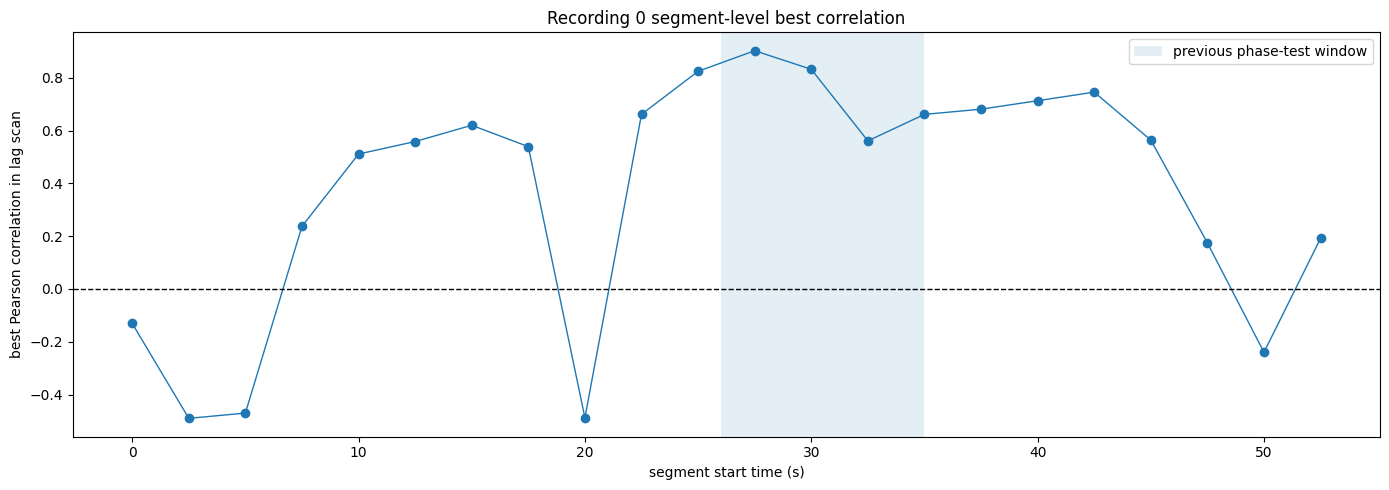

recording: 202606130411060002SMP
feature: pair_range_mean_0_6
target_roi: right_sweep_area
target_metric: roi_bright_fraction
segment_length_s: 5.0
segment_step_s: 2.5
n_segments: 22


In [41]:
required_names = [
    "subroi_brightness0_clean",
    "native_time_s_full",
    "pair_range_mean_0_6_full",
]

missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise NameError(f"Missing required notebook variables: {missing_names}")

feature_name = "pair_range_mean_0_6"
feature_values = pair_range_mean_0_6_full

target_roi = "right_sweep_area"
target_metric = "roi_bright_fraction"

roi_df_0 = (
    subroi_brightness0_clean[
        subroi_brightness0_clean["roi_name"] == target_roi
    ]
    .sort_values("time_s")
    .copy()
)

frame_times_all = roi_df_0["time_s"].to_numpy()
target_values_all = roi_df_0[target_metric].to_numpy()

segment_length_s = 5.0
segment_step_s = 2.5
lags_s = np.arange(-0.30, 0.401, 0.01)

segment_rows = []

start_s = 0.0
max_time_s = float(np.nanmax(frame_times_all))

while start_s + segment_length_s <= max_time_s:
    end_s = start_s + segment_length_s

    segment_mask = (
        (frame_times_all >= start_s)
        & (frame_times_all < end_s)
        & np.isfinite(target_values_all)
    )

    if segment_mask.sum() >= 30:
        segment_times = frame_times_all[segment_mask]
        segment_target = target_values_all[segment_mask]

        best_row = None

        for lag_s in lags_s:
            shifted_feature = np.interp(
                segment_times + lag_s,
                native_time_s_full,
                feature_values,
                left=np.nan,
                right=np.nan,
            )

            valid = np.isfinite(shifted_feature) & np.isfinite(segment_target)

            if valid.sum() > 10:
                corr = np.corrcoef(
                    shifted_feature[valid],
                    segment_target[valid],
                )[0, 1]
            else:
                corr = np.nan

            row = {
                "segment_start_s": float(start_s),
                "segment_end_s": float(end_s),
                "feature_name": feature_name,
                "target_roi": target_roi,
                "target_metric": target_metric,
                "lag_s": float(lag_s),
                "corr": float(corr),
                "abs_corr": float(abs(corr)) if np.isfinite(corr) else np.nan,
                "n_frames": int(valid.sum()),
            }

            if best_row is None or row["abs_corr"] > best_row["abs_corr"]:
                best_row = row

        segment_rows.append(best_row)

    start_s += segment_step_s

segment_feature_scan0 = pd.DataFrame(segment_rows)

display(
    segment_feature_scan0
    .sort_values("abs_corr", ascending=False)
    .head(20)
)

plt.figure(figsize=(14, 5))
plt.plot(
    segment_feature_scan0["segment_start_s"],
    segment_feature_scan0["corr"],
    marker="o",
    linewidth=1,
)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.axvspan(26, 35, alpha=0.12, label="previous phase-test window")
plt.title("Recording 0 segment-level best correlation")
plt.xlabel("segment start time (s)")
plt.ylabel("best Pearson correlation in lag scan")
plt.legend()
plt.tight_layout()
plt.show()

print("recording:", recording_id_0 if "recording_id_0" in globals() else "recording 0")
print("feature:", feature_name)
print("target_roi:", target_roi)
print("target_metric:", target_metric)
print("segment_length_s:", segment_length_s)
print("segment_step_s:", segment_step_s)
print("n_segments:", len(segment_feature_scan0))

### Segment-level native feature check in first recording interpretation

Result classification: useful positive result with lag-scan caution.

The recording-0 segment scan found that `pair_range_mean_0_6` can have strong segment-level association with AVI `right_sweep_area` `roi_bright_fraction`.

Evidence-supported observations:

- Several mid-recording segments showed strong positive association.
- The strongest segment was `27.5..32.5 s`, with correlation approximately `0.903` at lag approximately `+0.34 s`.
- Adjacent segments also showed strong positive association:
  - `25.0..30.0 s`, correlation approximately `0.825`
  - `30.0..35.0 s`, correlation approximately `0.832`
- Most segments from about `10..47.5 s` had positive association.
- Early segments and the `20.0..25.0 s` segment showed negative association or weaker behavior.
- The best lag was not stable across all segments.



## Strong segment visual check in first recording

This section visually inspects the strongest segment-level native/AVI association found in recording `202606130411060002SMP`.

The previous section found that `pair_range_mean_0_6` had the strongest segment-level association with AVI `right_sweep_area` `roi_bright_fraction` in the `27.5..32.5 s` segment, using a lag of approximately `+0.34 s`.

This matters because a high lag-scanned correlation can be misleading unless the time-series plot shows plausible cycle-level alignment.

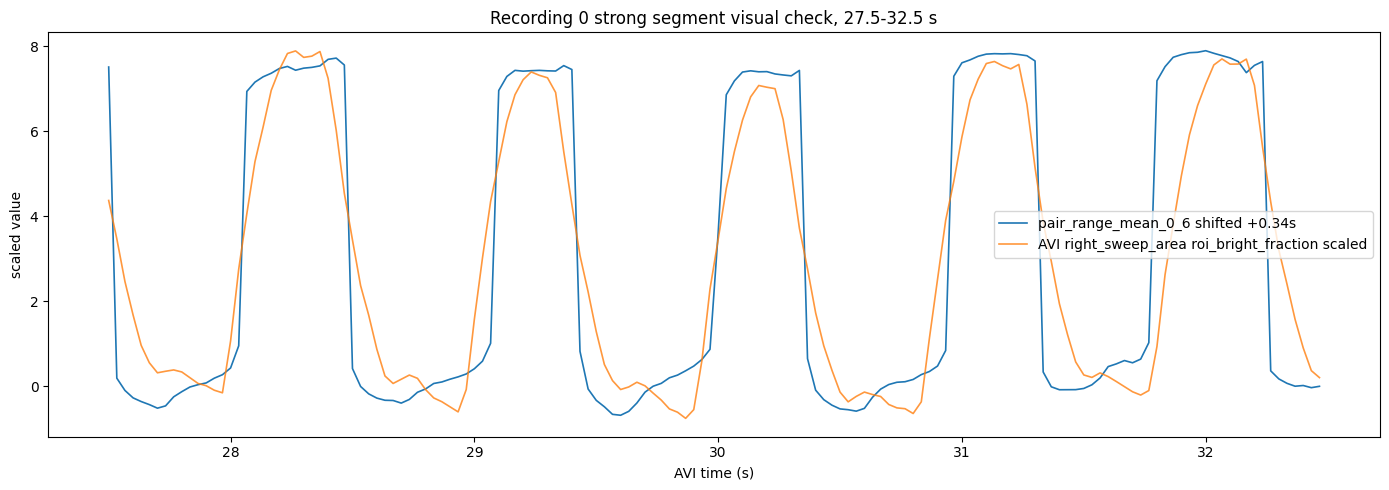

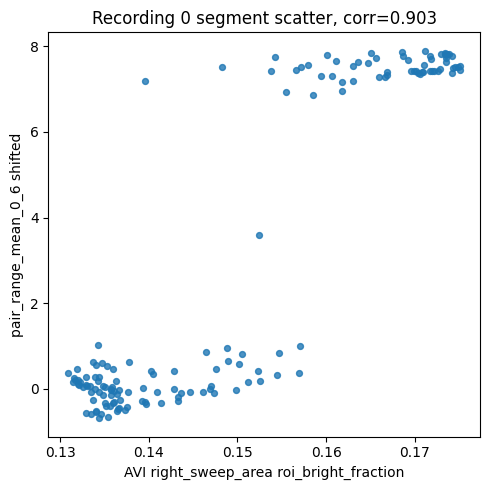

recording: 202606130411060002SMP
feature: pair_range_mean_0_6
target_roi: right_sweep_area
target_metric: roi_bright_fraction
segment_start_s: 27.5
segment_end_s: 32.5
best_segment_lag_s: 0.34
segment_corr: 0.9025282738135476
n_frames: 150


In [42]:
feature_name = "pair_range_mean_0_6"
feature_values = pair_range_mean_0_6_full

target_roi = "right_sweep_area"
target_metric = "roi_bright_fraction"

segment_start_s = 27.5
segment_end_s = 32.5
best_segment_lag_s = 0.34

roi_df_0 = (
    subroi_brightness0_clean[
        subroi_brightness0_clean["roi_name"] == target_roi
    ]
    .sort_values("time_s")
    .copy()
)

segment_df_0 = roi_df_0[
    (roi_df_0["time_s"] >= segment_start_s)
    & (roi_df_0["time_s"] < segment_end_s)
].copy()

segment_df_0["native_shifted"] = np.interp(
    segment_df_0["time_s"].to_numpy() + best_segment_lag_s,
    native_time_s_full,
    feature_values,
    left=np.nan,
    right=np.nan,
)

valid = (
    np.isfinite(segment_df_0[target_metric].to_numpy())
    & np.isfinite(segment_df_0["native_shifted"].to_numpy())
)

segment_corr_0 = np.corrcoef(
    segment_df_0.loc[valid, target_metric],
    segment_df_0.loc[valid, "native_shifted"],
)[0, 1]

scaled_roi_metric = scale_to_reference(
    segment_df_0[target_metric],
    segment_df_0["native_shifted"],
)

plt.figure(figsize=(14, 5))
plt.plot(
    segment_df_0["time_s"],
    segment_df_0["native_shifted"],
    linewidth=1.2,
    label=f"{feature_name} shifted {best_segment_lag_s:+.2f}s",
)
plt.plot(
    segment_df_0["time_s"],
    scaled_roi_metric,
    linewidth=1.2,
    alpha=0.8,
    label=f"AVI {target_roi} {target_metric} scaled",
)
plt.title(f"Recording 0 strong segment visual check, {segment_start_s}-{segment_end_s} s")
plt.xlabel("AVI time (s)")
plt.ylabel("scaled value")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 5))
plt.scatter(
    segment_df_0[target_metric],
    segment_df_0["native_shifted"],
    s=18,
    alpha=0.8,
)
plt.title(f"Recording 0 segment scatter, corr={segment_corr_0:.3f}")
plt.xlabel(f"AVI {target_roi} {target_metric}")
plt.ylabel(f"{feature_name} shifted")
plt.tight_layout()
plt.show()

print("recording:", recording_id_0 if "recording_id_0" in globals() else "recording 0")
print("feature:", feature_name)
print("target_roi:", target_roi)
print("target_metric:", target_metric)
print("segment_start_s:", segment_start_s)
print("segment_end_s:", segment_end_s)
print("best_segment_lag_s:", best_segment_lag_s)
print("segment_corr:", segment_corr_0)
print("n_frames:", int(valid.sum()))

### Strong segment visual check in first recording interpretation

Result classification: useful positive result with state-like behavior.

The strongest recording-0 segment, `27.5..32.5 s`, showed strong visual alignment between shifted native `pair_range_mean_0_6` and AVI `right_sweep_area` `roi_bright_fraction`.

Evidence-supported observations:

- The segment correlation was approximately `0.903` at lag approximately `+0.34 s`.
- The overlay shows repeated cycle-level alignment across several brightness cycles.
- The native feature behaves like a step-like state signal with low and high plateaus.
- The scatter plot shows two main native state clusters rather than a smooth continuous brightness relationship.
- High native state generally corresponds to brighter AVI ROI frames in this segment.

This supports the hypothesis that `pair_range_mean_0_6` contains compact PW state information synchronized with displayed Doppler brightness cycles in this recording segment.



,native_state_band,n_frames,native_mean,native_min,native_max,roi_bright_fraction_mean,roi_bright_fraction_std,roi_bright_fraction_min,roi_bright_fraction_max,roi_mean_mean,roi_p95_mean
0,high_native,50,7.582814,7.303154,7.894457,0.168429,0.006527,0.148209,0.175142,33.324510,187.562
1,low_native,50,-0.227886,-0.683050,0.067251,0.137615,0.004250,0.132555,0.149790,27.848273,177.460
2,mid_native,50,1.690918,0.068523,7.293522,0.143971,0.011242,0.130887,0.166617,28.864239,178.860


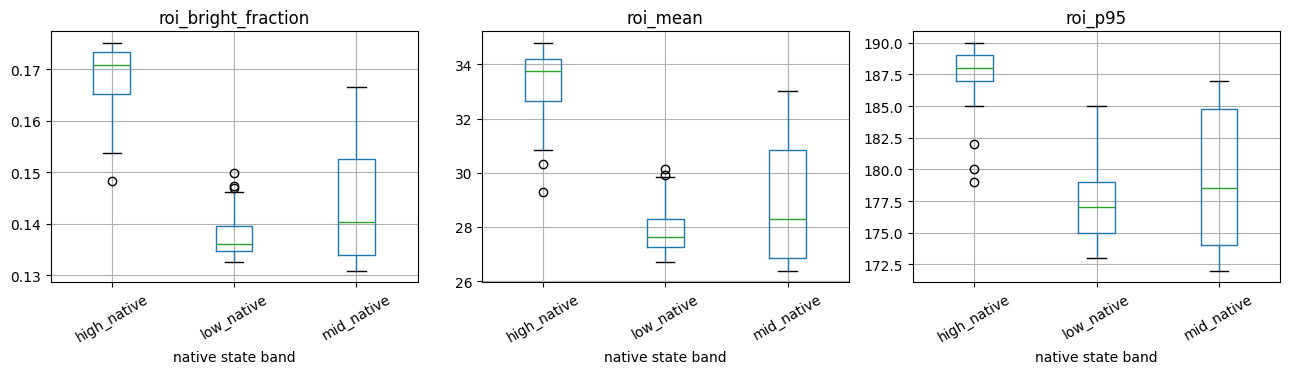

low_cut: 0.06803600620853384
high_cut: 7.297211260159785
segment_start_s: 27.5
segment_end_s: 32.5
lag_s: 0.34
n_frames: 150


In [43]:
required_names = [
    "segment_df_0",
]

missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise NameError(f"Missing required notebook variables: {missing_names}")

state_band_df_0 = segment_df_0.copy()

low_cut = np.nanpercentile(state_band_df_0["native_shifted"], 33.3)
high_cut = np.nanpercentile(state_band_df_0["native_shifted"], 66.7)

def assign_native_state_band_recording0(value):
    """This function assigns a shifted recording-0 native value to a low, mid, or high state band."""
    if not np.isfinite(value):
        return "missing"
    if value <= low_cut:
        return "low_native"
    if value >= high_cut:
        return "high_native"
    return "mid_native"

state_band_df_0["native_state_band"] = state_band_df_0["native_shifted"].apply(
    assign_native_state_band_recording0
)

state_band_summary0_strong = (
    state_band_df_0
    .groupby("native_state_band")
    .agg(
        n_frames=("frame_index", "count"),
        native_mean=("native_shifted", "mean"),
        native_min=("native_shifted", "min"),
        native_max=("native_shifted", "max"),
        roi_bright_fraction_mean=("roi_bright_fraction", "mean"),
        roi_bright_fraction_std=("roi_bright_fraction", "std"),
        roi_bright_fraction_min=("roi_bright_fraction", "min"),
        roi_bright_fraction_max=("roi_bright_fraction", "max"),
        roi_mean_mean=("roi_mean", "mean"),
        roi_p95_mean=("roi_p95", "mean"),
    )
    .reset_index()
)

display(state_band_summary0_strong)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, metric in zip(axes, ["roi_bright_fraction", "roi_mean", "roi_p95"]):
    state_band_df_0.boxplot(column=metric, by="native_state_band", ax=ax)
    ax.set_title(metric)
    ax.set_xlabel("native state band")
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("")
plt.tight_layout()
plt.show()

print("low_cut:", low_cut)
print("high_cut:", high_cut)
print("segment_start_s:", segment_start_s)
print("segment_end_s:", segment_end_s)
print("lag_s:", best_segment_lag_s)
print("n_frames:", len(state_band_df_0))

### Native state bands versus AVI brightness in strongest first-recording segment interpretation

Result classification: useful positive result with discrete-state interpretation.

The strongest recording-0 segment, `27.5..32.5 s`, showed clear separation of AVI brightness metrics across native `pair_range_mean_0_6` state bands.

Evidence-supported observations:

- Each native state band contained 50 frames because the bands were defined by tertiles.
- `high_native` had the highest AVI brightness:
  - mean `roi_bright_fraction` approximately `0.168`
  - mean `roi_mean` approximately `33.32`
  - mean `roi_p95` approximately `187.56`
- `low_native` had the lowest AVI brightness:
  - mean `roi_bright_fraction` approximately `0.138`
  - mean `roi_mean` approximately `27.85`
  - mean `roi_p95` approximately `177.46`
- `mid_native` was intermediate on average, but had a wider spread than `low_native`.
- The boxplots show the clearest separation between `high_native` and `low_native`.


## Fixed-lag state-band check across first-recording stable segments

This section tests whether the recording-0 native state-band relationship remains visible when the lag is fixed instead of selected separately for each segment.

The previous sections found strong segment-level association in the `27.5..32.5 s` segment using lag `+0.34 s`. This section applies the same fixed lag to several nearby stable segments and compares AVI brightness across low, mid, and high native state bands.

This matters because selecting the best lag separately for each segment can overstate the strength of the relationship. A fixed-lag check is a stricter exploratory test of whether the state-band relationship persists across nearby windows.

,segment_start_s,segment_end_s,fixed_lag_s,corr,n_frames,low_roi_mean,mid_roi_mean,high_roi_mean,high_minus_low_roi_mean
0,22.5,27.5,0.34,0.659765,150,0.126831,0.136990,0.153859,0.027028
1,25.0,30.0,0.34,0.824542,150,0.133168,0.140869,0.163069,0.029901
2,27.5,32.5,0.34,0.902528,150,0.137615,0.143971,0.168429,0.030814
3,30.0,35.0,0.34,0.702986,150,0.139592,0.152487,0.164236,0.024644
4,32.5,37.5,0.34,-0.025633,150,0.149593,0.148758,0.147326,-0.002267
5,35.0,40.0,0.34,-0.544923,150,0.156002,0.138795,0.130471,-0.025532


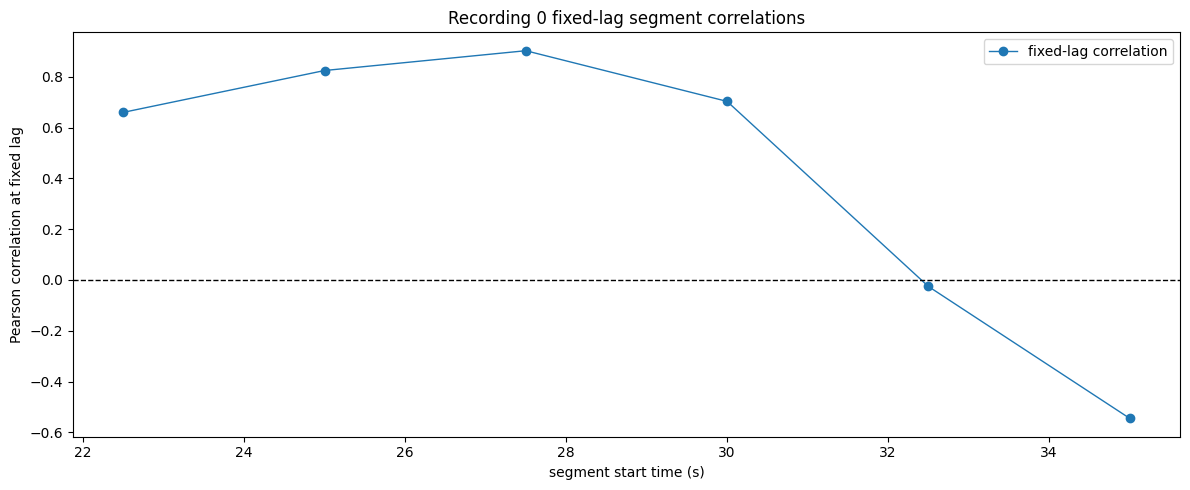

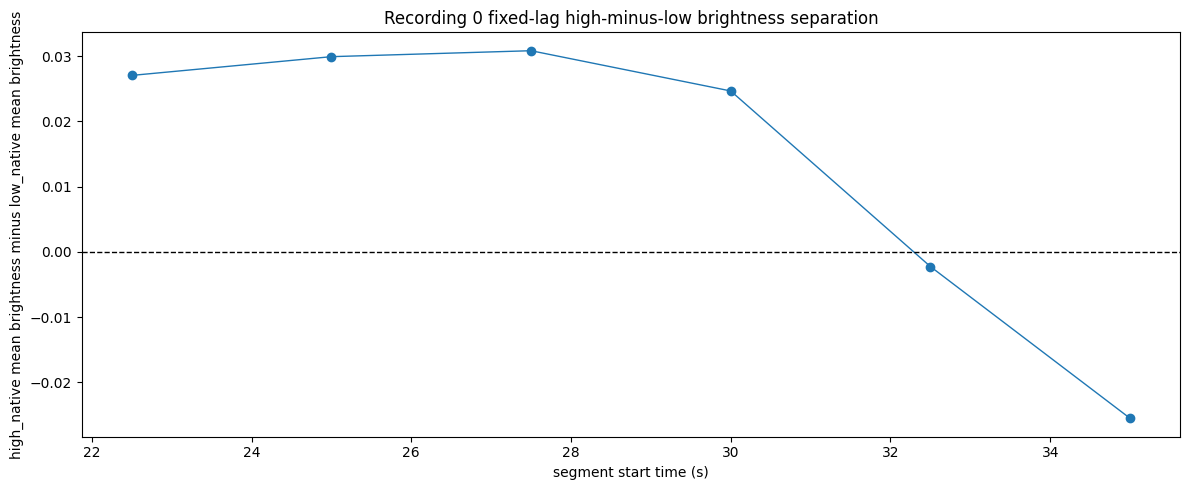

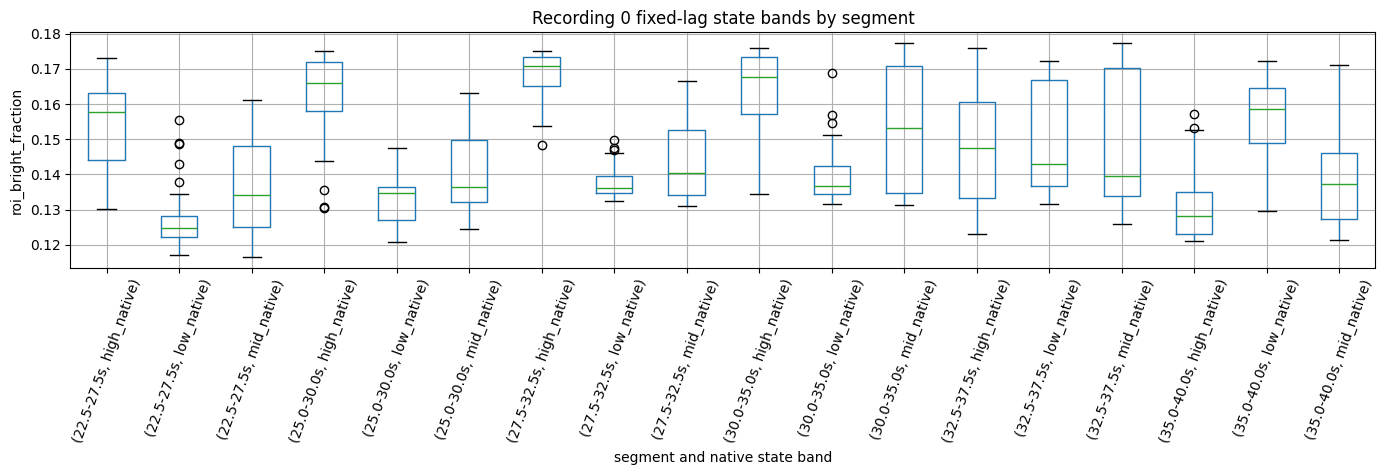

recording: 202606130411060002SMP
feature: pair_range_mean_0_6
target_roi: right_sweep_area
target_metric: roi_bright_fraction
fixed_lag_s: 0.34
segments_checked: 6


In [44]:
required_names = [
    "subroi_brightness0_clean",
    "native_time_s_full",
    "pair_range_mean_0_6_full",
]

missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise NameError(f"Missing required notebook variables: {missing_names}")

feature_name = "pair_range_mean_0_6"
feature_values = pair_range_mean_0_6_full

target_roi = "right_sweep_area"
target_metric = "roi_bright_fraction"
fixed_lag_s = 0.34

segments_to_check = [
    (22.5, 27.5),
    (25.0, 30.0),
    (27.5, 32.5),
    (30.0, 35.0),
    (32.5, 37.5),
    (35.0, 40.0),
]

roi_df_0 = (
    subroi_brightness0_clean[
        subroi_brightness0_clean["roi_name"] == target_roi
    ]
    .sort_values("time_s")
    .copy()
)

fixed_lag_rows = []
fixed_lag_frame_rows = []

for segment_start_s, segment_end_s in segments_to_check:
    segment_df = roi_df_0[
        (roi_df_0["time_s"] >= segment_start_s)
        & (roi_df_0["time_s"] < segment_end_s)
    ].copy()

    segment_df["native_shifted"] = np.interp(
        segment_df["time_s"].to_numpy() + fixed_lag_s,
        native_time_s_full,
        feature_values,
        left=np.nan,
        right=np.nan,
    )

    valid = (
        np.isfinite(segment_df[target_metric].to_numpy())
        & np.isfinite(segment_df["native_shifted"].to_numpy())
    )

    if valid.sum() < 30:
        continue

    low_cut = np.nanpercentile(segment_df.loc[valid, "native_shifted"], 33.3)
    high_cut = np.nanpercentile(segment_df.loc[valid, "native_shifted"], 66.7)

    segment_df["native_state_band"] = np.select(
        [
            segment_df["native_shifted"] <= low_cut,
            segment_df["native_shifted"] >= high_cut,
        ],
        [
            "low_native",
            "high_native",
        ],
        default="mid_native",
    )

    corr = np.corrcoef(
        segment_df.loc[valid, target_metric],
        segment_df.loc[valid, "native_shifted"],
    )[0, 1]

    band_summary = (
        segment_df
        .groupby("native_state_band")
        .agg(
            n_frames=("frame_index", "count"),
            roi_metric_mean=(target_metric, "mean"),
            roi_metric_std=(target_metric, "std"),
            native_mean=("native_shifted", "mean"),
        )
        .reset_index()
    )

    band_means = {
        row["native_state_band"]: row["roi_metric_mean"]
        for _, row in band_summary.iterrows()
    }

    fixed_lag_rows.append({
        "segment_start_s": segment_start_s,
        "segment_end_s": segment_end_s,
        "fixed_lag_s": fixed_lag_s,
        "corr": corr,
        "n_frames": int(valid.sum()),
        "low_roi_mean": band_means.get("low_native", np.nan),
        "mid_roi_mean": band_means.get("mid_native", np.nan),
        "high_roi_mean": band_means.get("high_native", np.nan),
        "high_minus_low_roi_mean": (
            band_means.get("high_native", np.nan)
            - band_means.get("low_native", np.nan)
        ),
    })

    fixed_lag_frame_rows.append(
        segment_df.assign(
            segment_label=f"{segment_start_s:.1f}-{segment_end_s:.1f}s"
        )
    )

fixed_lag_state_summary0 = pd.DataFrame(fixed_lag_rows)
fixed_lag_state_frames0 = pd.concat(fixed_lag_frame_rows, ignore_index=True)

display(fixed_lag_state_summary0)

plt.figure(figsize=(12, 5))
plt.plot(
    fixed_lag_state_summary0["segment_start_s"],
    fixed_lag_state_summary0["corr"],
    marker="o",
    linewidth=1,
    label="fixed-lag correlation",
)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Recording 0 fixed-lag segment correlations")
plt.xlabel("segment start time (s)")
plt.ylabel("Pearson correlation at fixed lag")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(
    fixed_lag_state_summary0["segment_start_s"],
    fixed_lag_state_summary0["high_minus_low_roi_mean"],
    marker="o",
    linewidth=1,
)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Recording 0 fixed-lag high-minus-low brightness separation")
plt.xlabel("segment start time (s)")
plt.ylabel("high_native mean brightness minus low_native mean brightness")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 5))
fixed_lag_state_frames0.boxplot(
    column=target_metric,
    by=["segment_label", "native_state_band"],
    ax=ax,
)
plt.suptitle("")
plt.title("Recording 0 fixed-lag state bands by segment")
plt.xlabel("segment and native state band")
plt.ylabel(target_metric)
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

print("recording:", recording_id_0 if "recording_id_0" in globals() else "recording 0")
print("feature:", feature_name)
print("target_roi:", target_roi)
print("target_metric:", target_metric)
print("fixed_lag_s:", fixed_lag_s)
print("segments_checked:", len(fixed_lag_state_summary0))

### Fixed-lag state-band check across first-recording stable segments interpretation

Result classification: mixed but useful evidence.

The fixed-lag check showed that the recording-0 native state-band relationship is strong across several nearby segments, but not stable across the full tested interval.

Evidence-supported observations:

- Using a fixed lag of `+0.34 s`, segments from `22.5..35.0 s` showed positive native/AVI association.
- The strongest fixed-lag segment remained `27.5..32.5 s`, with correlation approximately `0.903`.
- In the first four tested segments, `high_native` had higher mean AVI `roi_bright_fraction` than `low_native`.
- The high-minus-low brightness separation was consistently positive from `22.5..35.0 s`, ranging from about `0.025` to `0.031`.
- The relationship weakened around `32.5..37.5 s` and reversed in `35.0..40.0 s`.
- The fixed-lag result therefore does not support one stable lag and polarity across all nearby segments.

This supports a localized native state relationship in recording 0, especially from about `22.5..35.0 s`.


## Best-lag state-band check across first-recording stable segments

This section tests whether recording-0 state-band separation persists when each segment uses its own best lag from the segment-level scan.

The previous fixed-lag check showed strong state-band separation from about `22.5..35.0 s`, but the relationship weakened or reversed after `32.5 s` when lag was fixed at `+0.34 s`. This section checks whether later segments recover positive brightness separation when their segment-specific best lags are used.

This matters because the fixed-lag collapse could reflect lag drift rather than loss of native/AVI association.

,segment_start_s,segment_end_s,best_lag_s,scan_corr,recomputed_corr,n_frames,low_roi_mean,mid_roi_mean,high_roi_mean,high_minus_low_roi_mean
0,22.5,27.5,3.600000e-01,0.661575,0.661575,150,0.127269,0.136504,0.153907,0.026638
1,25.0,30.0,3.400000e-01,0.824542,0.824542,150,0.133168,0.140869,0.163069,0.029901
2,27.5,32.5,3.400000e-01,0.902528,0.902528,150,0.137615,0.143971,0.168429,0.030814
3,30.0,35.0,2.600000e-01,0.832117,0.832117,150,0.136964,0.152101,0.167250,0.030286
4,32.5,37.5,1.300000e-01,0.561045,0.561045,150,0.137740,0.147000,0.160937,0.023198
5,35.0,40.0,2.775558e-16,0.661381,0.661381,150,0.128586,0.140931,0.155752,0.027165


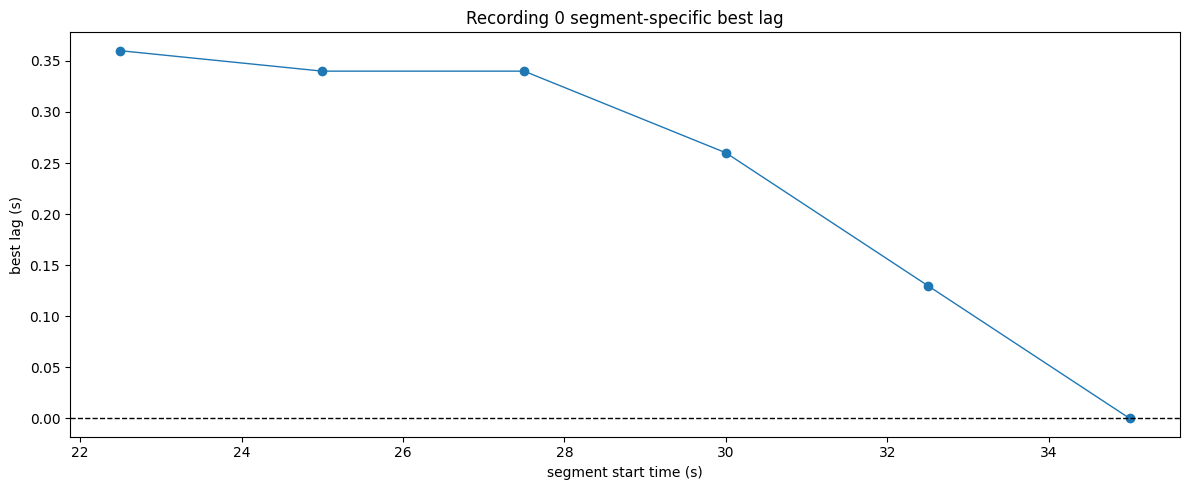

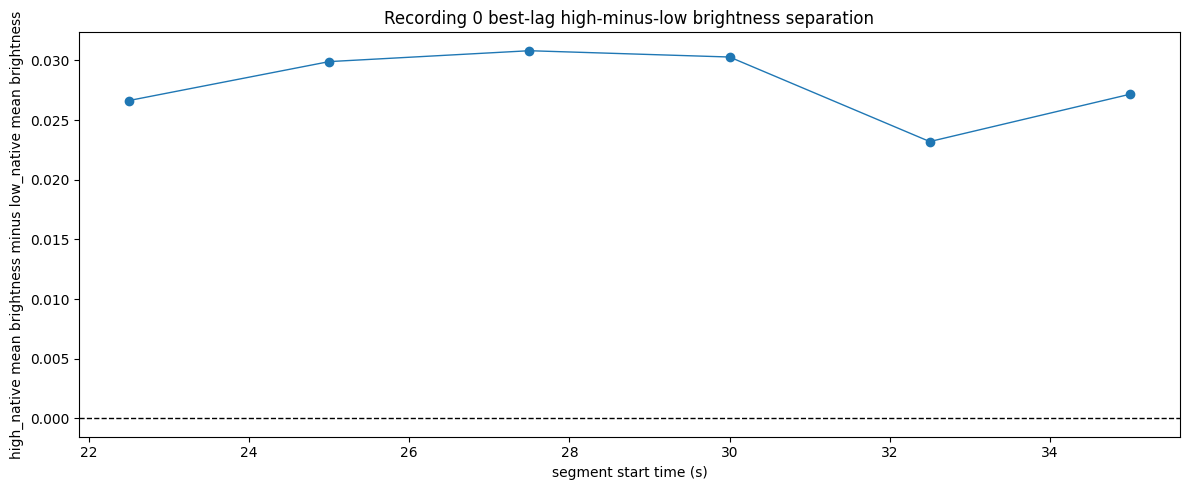

recording: 202606130411060002SMP
feature: pair_range_mean_0_6
target_roi: right_sweep_area
target_metric: roi_bright_fraction
segments_checked: 6


In [45]:
required_names = [
    "segment_feature_scan0",
    "subroi_brightness0_clean",
    "native_time_s_full",
    "pair_range_mean_0_6_full",
]

missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise NameError(f"Missing required notebook variables: {missing_names}")

feature_name = "pair_range_mean_0_6"
feature_values = pair_range_mean_0_6_full

target_roi = "right_sweep_area"
target_metric = "roi_bright_fraction"

segments_to_check = [
    (22.5, 27.5),
    (25.0, 30.0),
    (27.5, 32.5),
    (30.0, 35.0),
    (32.5, 37.5),
    (35.0, 40.0),
]

roi_df_0 = (
    subroi_brightness0_clean[
        subroi_brightness0_clean["roi_name"] == target_roi
    ]
    .sort_values("time_s")
    .copy()
)

best_lag_rows = []
best_lag_frame_rows = []

for segment_start_s, segment_end_s in segments_to_check:
    match = segment_feature_scan0[
        (np.isclose(segment_feature_scan0["segment_start_s"], segment_start_s))
        & (np.isclose(segment_feature_scan0["segment_end_s"], segment_end_s))
    ]

    if len(match) != 1:
        print("Skipping segment without exact scan match:", segment_start_s, segment_end_s)
        continue

    best_lag_s = float(match.iloc[0]["lag_s"])
    scan_corr = float(match.iloc[0]["corr"])

    segment_df = roi_df_0[
        (roi_df_0["time_s"] >= segment_start_s)
        & (roi_df_0["time_s"] < segment_end_s)
    ].copy()

    segment_df["native_shifted"] = np.interp(
        segment_df["time_s"].to_numpy() + best_lag_s,
        native_time_s_full,
        feature_values,
        left=np.nan,
        right=np.nan,
    )

    valid = (
        np.isfinite(segment_df[target_metric].to_numpy())
        & np.isfinite(segment_df["native_shifted"].to_numpy())
    )

    if valid.sum() < 30:
        continue

    low_cut = np.nanpercentile(segment_df.loc[valid, "native_shifted"], 33.3)
    high_cut = np.nanpercentile(segment_df.loc[valid, "native_shifted"], 66.7)

    segment_df["native_state_band"] = np.select(
        [
            segment_df["native_shifted"] <= low_cut,
            segment_df["native_shifted"] >= high_cut,
        ],
        [
            "low_native",
            "high_native",
        ],
        default="mid_native",
    )

    corr = np.corrcoef(
        segment_df.loc[valid, target_metric],
        segment_df.loc[valid, "native_shifted"],
    )[0, 1]

    band_summary = (
        segment_df
        .groupby("native_state_band")
        .agg(
            n_frames=("frame_index", "count"),
            roi_metric_mean=(target_metric, "mean"),
            roi_metric_std=(target_metric, "std"),
            native_mean=("native_shifted", "mean"),
        )
        .reset_index()
    )

    band_means = {
        row["native_state_band"]: row["roi_metric_mean"]
        for _, row in band_summary.iterrows()
    }

    best_lag_rows.append({
        "segment_start_s": segment_start_s,
        "segment_end_s": segment_end_s,
        "best_lag_s": best_lag_s,
        "scan_corr": scan_corr,
        "recomputed_corr": corr,
        "n_frames": int(valid.sum()),
        "low_roi_mean": band_means.get("low_native", np.nan),
        "mid_roi_mean": band_means.get("mid_native", np.nan),
        "high_roi_mean": band_means.get("high_native", np.nan),
        "high_minus_low_roi_mean": (
            band_means.get("high_native", np.nan)
            - band_means.get("low_native", np.nan)
        ),
    })

    best_lag_frame_rows.append(
        segment_df.assign(
            segment_label=f"{segment_start_s:.1f}-{segment_end_s:.1f}s",
            best_lag_s=best_lag_s,
        )
    )

best_lag_state_summary0 = pd.DataFrame(best_lag_rows)
best_lag_state_frames0 = pd.concat(best_lag_frame_rows, ignore_index=True)

display(best_lag_state_summary0)

plt.figure(figsize=(12, 5))
plt.plot(
    best_lag_state_summary0["segment_start_s"],
    best_lag_state_summary0["best_lag_s"],
    marker="o",
    linewidth=1,
)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Recording 0 segment-specific best lag")
plt.xlabel("segment start time (s)")
plt.ylabel("best lag (s)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(
    best_lag_state_summary0["segment_start_s"],
    best_lag_state_summary0["high_minus_low_roi_mean"],
    marker="o",
    linewidth=1,
)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Recording 0 best-lag high-minus-low brightness separation")
plt.xlabel("segment start time (s)")
plt.ylabel("high_native mean brightness minus low_native mean brightness")
plt.tight_layout()
plt.show()

print("recording:", recording_id_0 if "recording_id_0" in globals() else "recording 0")
print("feature:", feature_name)
print("target_roi:", target_roi)
print("target_metric:", target_metric)
print("segments_checked:", len(best_lag_state_summary0))

### Best-lag state-band check across first-recording stable segments interpretation

Result classification: useful positive result with lag-drift caution.

The best-lag state-band check showed that recording-0 native state-band separation persists across the tested `22.5..40.0 s` interval when each segment uses its own best lag from the segment-level scan.

Evidence-supported observations:

- All six tested segments showed positive correlation when using segment-specific best lag.
- All six tested segments showed positive high-minus-low AVI brightness separation.
- The high-minus-low `roi_bright_fraction` separation stayed in a narrow positive range, approximately `0.023..0.031`.
- The strongest segment remained `27.5..32.5 s`, with correlation approximately `0.903`.
- The useful lag drifted downward across time:
  - about `+0.36 s` at `22.5..27.5 s`
  - about `+0.34 s` through `27.5..32.5 s`
  - about `+0.26 s` at `30.0..35.0 s`
  - about `+0.13 s` at `32.5..37.5 s`
  - about `0.00 s` at `35.0..40.0 s`

This supports the hypothesis that `pair_range_mean_0_6` remains associated with displayed Doppler brightness state across this recording-0 interval, but the useful lag is not stable.


## Segment-specific lag drift in first recording

This section tests whether the segment-specific best lag in recording `202606130411060002SMP` changes smoothly over time.

The previous section showed that state-band separation stayed positive when each segment used its own best lag, but the best lag drifted from about `+0.36 s` to about `0.00 s` across the tested interval. This section fits a simple linear trend to the segment-specific best lags.

This matters because smooth lag drift would support a timing or synchronization explanation, while irregular lag changes would suggest more caution about segment-specific lag selection.

,segment_start_s,segment_end_s,segment_mid_s,best_lag_s,linear_lag_fit_s,lag_residual_s,scan_corr,high_minus_low_roi_mean
0,22.5,27.5,25.0,3.600000e-01,0.417619,-0.057619,0.661575,0.026638
1,25.0,30.0,27.5,3.400000e-01,0.345905,-0.005905,0.824542,0.029901
2,27.5,32.5,30.0,3.400000e-01,0.274190,0.065810,0.902528,0.030814
3,30.0,35.0,32.5,2.600000e-01,0.202476,0.057524,0.832117,0.030286
4,32.5,37.5,35.0,1.300000e-01,0.130762,-0.000762,0.561045,0.023198
5,35.0,40.0,37.5,2.775558e-16,0.059048,-0.059048,0.661381,0.027165


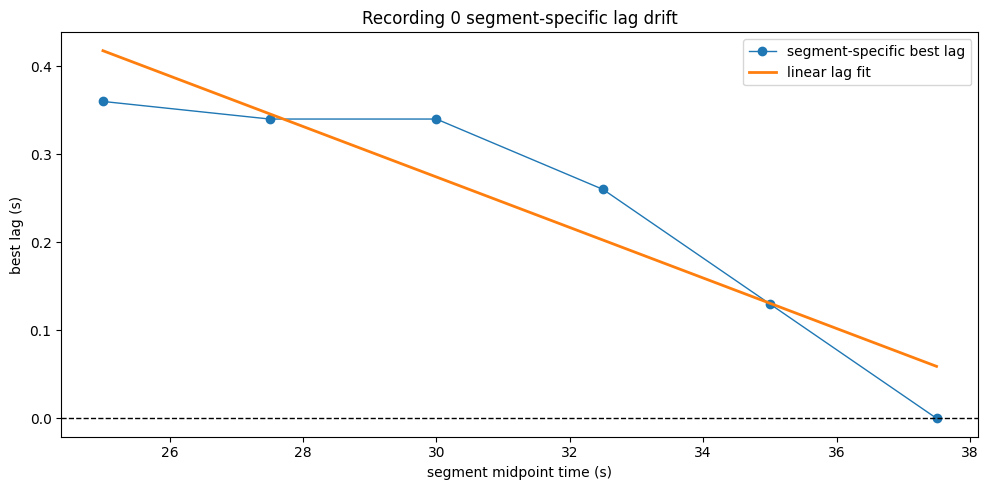

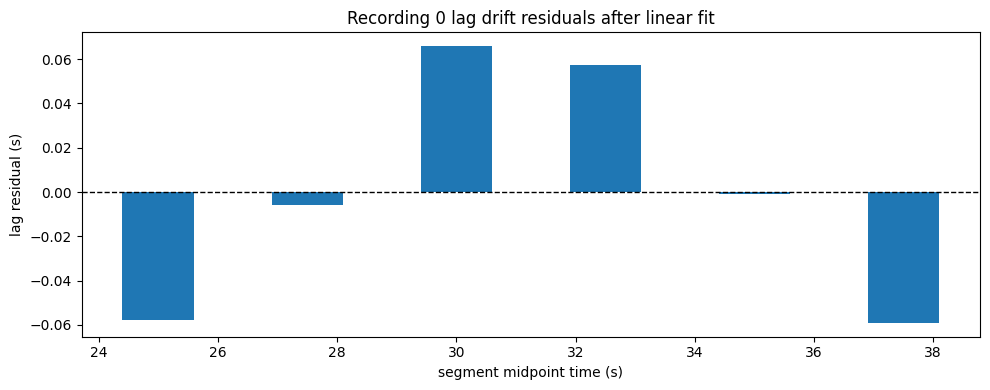

lag_slope_per_s: -0.028685714285714304
lag_slope_ms_per_s: -28.685714285714305
lag_intercept_s: 1.1347619047619057
linear_fit_r2: 0.8613950732629948
max_abs_residual_s: 0.06580952380952393
n_segments: 6


In [46]:
required_names = [
    "best_lag_state_summary0",
]

missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise NameError(f"Missing required notebook variables: {missing_names}")

lag_drift_df0 = best_lag_state_summary0.copy()
lag_drift_df0["segment_mid_s"] = (
    lag_drift_df0["segment_start_s"] + lag_drift_df0["segment_end_s"]
) / 2

x = lag_drift_df0["segment_mid_s"].to_numpy()
y = lag_drift_df0["best_lag_s"].to_numpy()

linear_coeff = np.polyfit(x, y, deg=1)
linear_lag_fit = np.polyval(linear_coeff, x)

lag_drift_df0["linear_lag_fit_s"] = linear_lag_fit
lag_drift_df0["lag_residual_s"] = lag_drift_df0["best_lag_s"] - lag_drift_df0["linear_lag_fit_s"]

ss_res = np.sum(lag_drift_df0["lag_residual_s"].to_numpy() ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else np.nan

lag_slope_per_s = linear_coeff[0]
lag_intercept_s = linear_coeff[1]

display(
    lag_drift_df0[
        [
            "segment_start_s",
            "segment_end_s",
            "segment_mid_s",
            "best_lag_s",
            "linear_lag_fit_s",
            "lag_residual_s",
            "scan_corr",
            "high_minus_low_roi_mean",
        ]
    ]
)

plt.figure(figsize=(10, 5))
plt.plot(
    lag_drift_df0["segment_mid_s"],
    lag_drift_df0["best_lag_s"],
    marker="o",
    linewidth=1,
    label="segment-specific best lag",
)
plt.plot(
    lag_drift_df0["segment_mid_s"],
    lag_drift_df0["linear_lag_fit_s"],
    linewidth=2,
    label="linear lag fit",
)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Recording 0 segment-specific lag drift")
plt.xlabel("segment midpoint time (s)")
plt.ylabel("best lag (s)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(
    lag_drift_df0["segment_mid_s"],
    lag_drift_df0["lag_residual_s"],
    width=1.2,
)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Recording 0 lag drift residuals after linear fit")
plt.xlabel("segment midpoint time (s)")
plt.ylabel("lag residual (s)")
plt.tight_layout()
plt.show()

print("lag_slope_per_s:", lag_slope_per_s)
print("lag_slope_ms_per_s:", lag_slope_per_s * 1000)
print("lag_intercept_s:", lag_intercept_s)
print("linear_fit_r2:", r2)
print("max_abs_residual_s:", np.nanmax(np.abs(lag_drift_df0["lag_residual_s"])))
print("n_segments:", len(lag_drift_df0))

### Segment-specific lag drift in first recording interpretation

Result classification: useful positive result with limited-sample caution.

The segment-specific best lag in recording `202606130411060002SMP` changed smoothly across the tested `22.5..40.0 s` interval.

Evidence-supported observations:

- The best lag decreased from about `+0.36 s` near the beginning of the tested interval to about `0.00 s` by `35.0..40.0 s`.
- A simple linear fit explained most of the lag trend:
  - linear fit `R²` approximately `0.861`
  - slope approximately `-28.7 ms/s`
  - maximum absolute residual approximately `0.066 s`
- The residuals were not zero, so the lag drift is not fully explained by a simple line.
- The lag trend supports the idea that the fixed-lag failure after `32.5 s` was at least partly caused by changing alignment rather than complete loss of native/AVI association.

This supports the hypothesis that the apparent native-to-AVI lag can drift smoothly over time in recording 0.


## Linear-lag state-band check across first-recording stable segments

This section tests whether a smooth lag model preserves the recording-0 native state-band relationship across nearby stable segments.

The previous section showed that segment-specific best lag decreased approximately linearly over time. This section uses the fitted linear lag for each segment instead of selecting the best lag separately.

This matters because a linear lag model is a stricter exploratory correction than per-segment lag tuning, while still allowing smooth alignment drift.

,segment_start_s,segment_end_s,segment_mid_s,predicted_lag_s,best_lag_s,lag_error_vs_best_s,corr,best_lag_scan_corr,n_frames,low_roi_mean,mid_roi_mean,high_roi_mean,high_minus_low_roi_mean
0,22.5,27.5,25.0,0.417619,3.600000e-01,0.057619,0.591886,0.661575,150,0.130602,0.134705,0.152373,0.021770
1,25.0,30.0,27.5,0.345905,3.400000e-01,0.005905,0.812279,0.824542,150,0.133103,0.141585,0.162419,0.029317
2,27.5,32.5,30.0,0.274190,3.400000e-01,-0.065810,0.845555,0.902528,150,0.135205,0.149306,0.165504,0.030298
3,30.0,35.0,32.5,0.202476,2.600000e-01,-0.057524,0.726320,0.832117,150,0.137744,0.151959,0.166611,0.028867
4,32.5,37.5,35.0,0.130762,1.300000e-01,0.000762,0.560354,0.561045,150,0.137740,0.147000,0.160937,0.023198
5,35.0,40.0,37.5,0.059048,2.775558e-16,0.059048,0.598706,0.661381,150,0.131109,0.139068,0.155091,0.023982


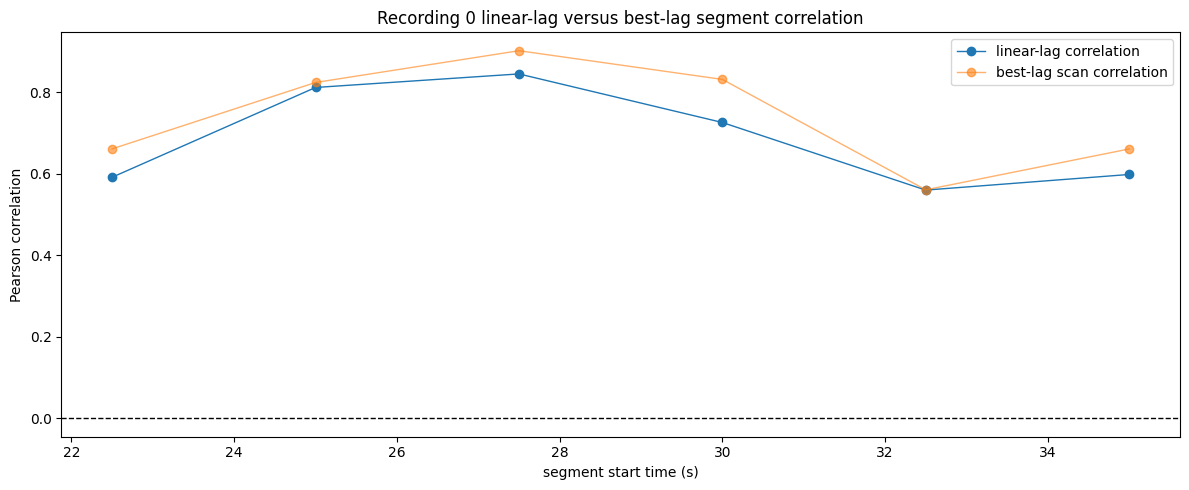

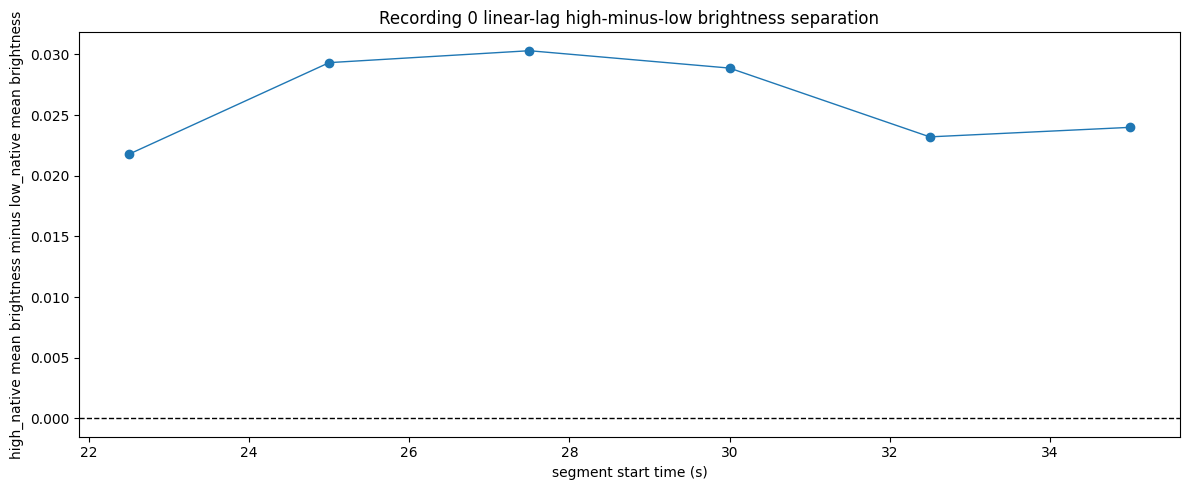

recording: 202606130411060002SMP
feature: pair_range_mean_0_6
target_roi: right_sweep_area
target_metric: roi_bright_fraction
segments_checked: 6
segments_with_positive_high_minus_low: 6


In [47]:
required_names = [
    "lag_drift_df0",
    "linear_coeff",
    "subroi_brightness0_clean",
    "native_time_s_full",
    "pair_range_mean_0_6_full",
]

missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise NameError(f"Missing required notebook variables: {missing_names}")

feature_name = "pair_range_mean_0_6"
feature_values = pair_range_mean_0_6_full

target_roi = "right_sweep_area"
target_metric = "roi_bright_fraction"

roi_df_0 = (
    subroi_brightness0_clean[
        subroi_brightness0_clean["roi_name"] == target_roi
    ]
    .sort_values("time_s")
    .copy()
)

linear_lag_rows = []
linear_lag_frame_rows = []

for _, lag_row in lag_drift_df0.iterrows():
    segment_start_s = float(lag_row["segment_start_s"])
    segment_end_s = float(lag_row["segment_end_s"])
    segment_mid_s = float(lag_row["segment_mid_s"])

    predicted_lag_s = float(np.polyval(linear_coeff, segment_mid_s))

    segment_df = roi_df_0[
        (roi_df_0["time_s"] >= segment_start_s)
        & (roi_df_0["time_s"] < segment_end_s)
    ].copy()

    segment_df["native_shifted"] = np.interp(
        segment_df["time_s"].to_numpy() + predicted_lag_s,
        native_time_s_full,
        feature_values,
        left=np.nan,
        right=np.nan,
    )

    valid = (
        np.isfinite(segment_df[target_metric].to_numpy())
        & np.isfinite(segment_df["native_shifted"].to_numpy())
    )

    if valid.sum() < 30:
        continue

    low_cut = np.nanpercentile(segment_df.loc[valid, "native_shifted"], 33.3)
    high_cut = np.nanpercentile(segment_df.loc[valid, "native_shifted"], 66.7)

    segment_df["native_state_band"] = np.select(
        [
            segment_df["native_shifted"] <= low_cut,
            segment_df["native_shifted"] >= high_cut,
        ],
        [
            "low_native",
            "high_native",
        ],
        default="mid_native",
    )

    corr = np.corrcoef(
        segment_df.loc[valid, target_metric],
        segment_df.loc[valid, "native_shifted"],
    )[0, 1]

    band_summary = (
        segment_df
        .groupby("native_state_band")
        .agg(
            n_frames=("frame_index", "count"),
            roi_metric_mean=(target_metric, "mean"),
            roi_metric_std=(target_metric, "std"),
            native_mean=("native_shifted", "mean"),
        )
        .reset_index()
    )

    band_means = {
        row["native_state_band"]: row["roi_metric_mean"]
        for _, row in band_summary.iterrows()
    }

    linear_lag_rows.append({
        "segment_start_s": segment_start_s,
        "segment_end_s": segment_end_s,
        "segment_mid_s": segment_mid_s,
        "predicted_lag_s": predicted_lag_s,
        "best_lag_s": float(lag_row["best_lag_s"]),
        "lag_error_vs_best_s": predicted_lag_s - float(lag_row["best_lag_s"]),
        "corr": corr,
        "best_lag_scan_corr": float(lag_row["scan_corr"]),
        "n_frames": int(valid.sum()),
        "low_roi_mean": band_means.get("low_native", np.nan),
        "mid_roi_mean": band_means.get("mid_native", np.nan),
        "high_roi_mean": band_means.get("high_native", np.nan),
        "high_minus_low_roi_mean": (
            band_means.get("high_native", np.nan)
            - band_means.get("low_native", np.nan)
        ),
    })

    linear_lag_frame_rows.append(
        segment_df.assign(
            segment_label=f"{segment_start_s:.1f}-{segment_end_s:.1f}s",
            predicted_lag_s=predicted_lag_s,
        )
    )

linear_lag_state_summary0 = pd.DataFrame(linear_lag_rows)
linear_lag_state_frames0 = pd.concat(linear_lag_frame_rows, ignore_index=True)

display(linear_lag_state_summary0)

plt.figure(figsize=(12, 5))
plt.plot(
    linear_lag_state_summary0["segment_start_s"],
    linear_lag_state_summary0["corr"],
    marker="o",
    linewidth=1,
    label="linear-lag correlation",
)
plt.plot(
    linear_lag_state_summary0["segment_start_s"],
    linear_lag_state_summary0["best_lag_scan_corr"],
    marker="o",
    linewidth=1,
    alpha=0.6,
    label="best-lag scan correlation",
)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Recording 0 linear-lag versus best-lag segment correlation")
plt.xlabel("segment start time (s)")
plt.ylabel("Pearson correlation")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(
    linear_lag_state_summary0["segment_start_s"],
    linear_lag_state_summary0["high_minus_low_roi_mean"],
    marker="o",
    linewidth=1,
)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Recording 0 linear-lag high-minus-low brightness separation")
plt.xlabel("segment start time (s)")
plt.ylabel("high_native mean brightness minus low_native mean brightness")
plt.tight_layout()
plt.show()

print("recording:", recording_id_0 if "recording_id_0" in globals() else "recording 0")
print("feature:", feature_name)
print("target_roi:", target_roi)
print("target_metric:", target_metric)
print("segments_checked:", len(linear_lag_state_summary0))
print("segments_with_positive_high_minus_low:", int((linear_lag_state_summary0["high_minus_low_roi_mean"] > 0).sum()))

### Linear-lag state-band check across first-recording stable segments interpretation

Result classification: useful positive result with fitted-model caution.

The linear-lag check showed that a smooth lag model preserved the recording-0 native state-band relationship across the tested `22.5..40.0 s` interval.

Evidence-supported observations:

- All six tested segments had positive correlation using the predicted linear lag.
- All six tested segments had positive high-minus-low AVI brightness separation.
- The high-minus-low `roi_bright_fraction` separation stayed positive, approximately `0.022..0.030`.
- Linear-lag correlations were slightly lower than the per-segment best-lag correlations, as expected.
- The strongest linear-lag segment remained near the middle of the tested interval:
  - `27.5..32.5 s`, correlation approximately `0.846`
- The linear lag model recovered the later segments that failed under fixed `+0.34 s` lag.


## Global linear-lag state bands in first-recording stable interval

This section tests whether recording-0 native state bands retain a consistent meaning across the full `22.5..40.0 s` stable interval.

The previous section showed that a fitted linear lag preserved state-band brightness separation when bands were assigned separately within each segment. This section applies the linear lag correction frame-by-frame and then assigns low, mid, and high native bands using one global set of thresholds across the full interval.

This matters because global state bands are a stricter test. If high native state remains brighter than low native state across the whole interval, the result supports a more consistent native state interpretation.

,native_state_band,n_frames,native_mean,native_min,native_max,lag_mean,roi_bright_fraction_mean,roi_bright_fraction_std,roi_mean_mean,roi_p95_mean
0,high_native,175,7.601761,6.899810,8.061134,0.196564,0.160463,0.013609,31.702539,184.686286
1,low_native,175,-0.607877,-6.931473,0.107178,0.292801,0.132392,0.008843,27.072823,176.400571
2,mid_native,175,1.199453,0.107370,6.893134,0.227069,0.141768,0.012952,28.415275,178.343429


,segment_label,native_state_band,n_frames,roi_metric_mean,native_mean
0,"(22.499, 25.0]",high_native,1,0.156437,6.905938
1,"(22.499, 25.0]",low_native,52,0.132646,-1.216964
2,"(22.499, 25.0]",mid_native,23,0.138761,1.367020
3,"(25.0, 27.5]",high_native,28,0.157987,7.375073
4,"(25.0, 27.5]",low_native,23,0.129267,-0.268752
5,"(25.0, 27.5]",mid_native,24,0.141617,2.741001
6,"(27.5, 30.0]",high_native,23,0.166843,7.417781
7,"(27.5, 30.0]",low_native,32,0.136130,-0.244376
8,"(27.5, 30.0]",mid_native,20,0.144880,0.827601
9,"(30.0, 32.5]",high_native,35,0.163413,7.609326


<Figure size 700x400 with 0 Axes>

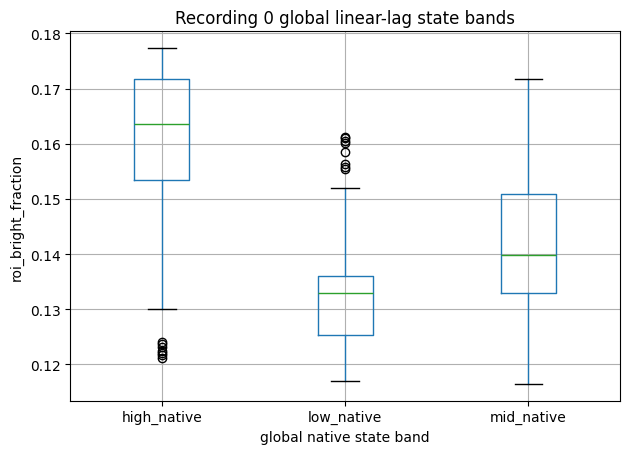

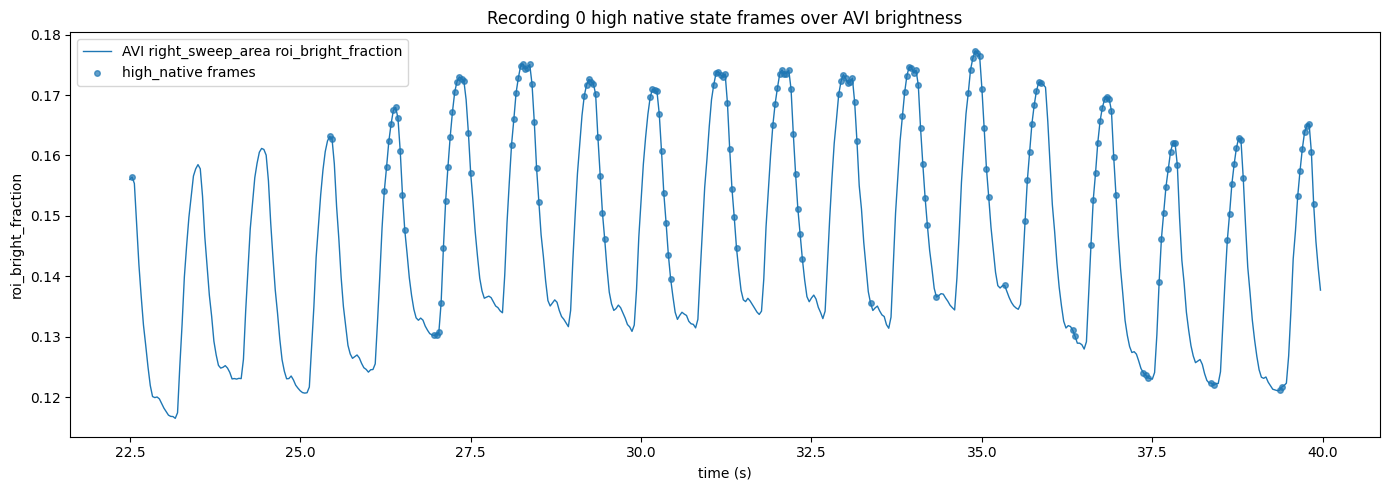

recording: 202606130411060002SMP
feature: pair_range_mean_0_6
target_roi: right_sweep_area
target_metric: roi_bright_fraction
stable_start_s: 22.5
stable_end_s: 40.0
global_corr: 0.697778419156617
low_cut: 0.1072724736463405
high_cut: 6.896525622053592
n_frames: 525


In [48]:
required_names = [
    "linear_coeff",
    "subroi_brightness0_clean",
    "native_time_s_full",
    "pair_range_mean_0_6_full",
]

missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise NameError(f"Missing required notebook variables: {missing_names}")

feature_name = "pair_range_mean_0_6"
feature_values = pair_range_mean_0_6_full

target_roi = "right_sweep_area"
target_metric = "roi_bright_fraction"

stable_start_s = 22.5
stable_end_s = 40.0

global_state_df0 = (
    subroi_brightness0_clean[
        (subroi_brightness0_clean["roi_name"] == target_roi)
        & (subroi_brightness0_clean["time_s"] >= stable_start_s)
        & (subroi_brightness0_clean["time_s"] < stable_end_s)
    ]
    .sort_values("time_s")
    .copy()
)

global_state_df0["predicted_lag_s"] = np.polyval(
    linear_coeff,
    global_state_df0["time_s"].to_numpy(),
)

global_state_df0["native_linear_lag"] = np.interp(
    global_state_df0["time_s"].to_numpy() + global_state_df0["predicted_lag_s"].to_numpy(),
    native_time_s_full,
    feature_values,
    left=np.nan,
    right=np.nan,
)

valid_native = np.isfinite(global_state_df0["native_linear_lag"].to_numpy())

low_cut = np.nanpercentile(global_state_df0.loc[valid_native, "native_linear_lag"], 33.3)
high_cut = np.nanpercentile(global_state_df0.loc[valid_native, "native_linear_lag"], 66.7)

global_state_df0["native_state_band"] = np.select(
    [
        global_state_df0["native_linear_lag"] <= low_cut,
        global_state_df0["native_linear_lag"] >= high_cut,
    ],
    [
        "low_native",
        "high_native",
    ],
    default="mid_native",
)

global_state_summary0 = (
    global_state_df0
    .groupby("native_state_band")
    .agg(
        n_frames=("frame_index", "count"),
        native_mean=("native_linear_lag", "mean"),
        native_min=("native_linear_lag", "min"),
        native_max=("native_linear_lag", "max"),
        lag_mean=("predicted_lag_s", "mean"),
        roi_bright_fraction_mean=("roi_bright_fraction", "mean"),
        roi_bright_fraction_std=("roi_bright_fraction", "std"),
        roi_mean_mean=("roi_mean", "mean"),
        roi_p95_mean=("roi_p95", "mean"),
    )
    .reset_index()
)

global_valid = (
    np.isfinite(global_state_df0[target_metric].to_numpy())
    & np.isfinite(global_state_df0["native_linear_lag"].to_numpy())
)

global_corr = np.corrcoef(
    global_state_df0.loc[global_valid, target_metric],
    global_state_df0.loc[global_valid, "native_linear_lag"],
)[0, 1]

global_state_df0["segment_label"] = pd.cut(
    global_state_df0["time_s"],
    bins=np.arange(stable_start_s, stable_end_s + 0.01, 2.5),
    include_lowest=True,
)

global_segment_band_summary0 = (
    global_state_df0
    .groupby(["segment_label", "native_state_band"], observed=True)
    .agg(
        n_frames=("frame_index", "count"),
        roi_metric_mean=(target_metric, "mean"),
        native_mean=("native_linear_lag", "mean"),
    )
    .reset_index()
)

display(global_state_summary0)
display(global_segment_band_summary0)

plt.figure(figsize=(7, 4))
global_state_df0.boxplot(column=target_metric, by="native_state_band")
plt.suptitle("")
plt.title("Recording 0 global linear-lag state bands")
plt.xlabel("global native state band")
plt.ylabel(target_metric)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(
    global_state_df0["time_s"],
    global_state_df0[target_metric],
    linewidth=1.0,
    label=f"AVI {target_roi} {target_metric}",
)
plt.scatter(
    global_state_df0.loc[
        global_state_df0["native_state_band"] == "high_native",
        "time_s",
    ],
    global_state_df0.loc[
        global_state_df0["native_state_band"] == "high_native",
        target_metric,
    ],
    s=16,
    alpha=0.7,
    label="high_native frames",
)
plt.title("Recording 0 high native state frames over AVI brightness")
plt.xlabel("time (s)")
plt.ylabel(target_metric)
plt.legend()
plt.tight_layout()
plt.show()

print("recording:", recording_id_0 if "recording_id_0" in globals() else "recording 0")
print("feature:", feature_name)
print("target_roi:", target_roi)
print("target_metric:", target_metric)
print("stable_start_s:", stable_start_s)
print("stable_end_s:", stable_end_s)
print("global_corr:", global_corr)
print("low_cut:", low_cut)
print("high_cut:", high_cut)
print("n_frames:", int(global_valid.sum()))

### Global linear-lag state bands in first-recording stable interval interpretation

Result classification: useful positive result with fitted-model caution.

The global linear-lag state-band check showed that recording-0 `pair_range_mean_0_6` retained a consistent relationship with AVI Doppler ROI brightness across the full `22.5..40.0 s` interval.

Evidence-supported observations:

- The global correlation between linear-lag-corrected native state and AVI `right_sweep_area` `roi_bright_fraction` was approximately `0.698`.
- Global `high_native` frames had the highest AVI brightness:
  - mean `roi_bright_fraction` approximately `0.160`
  - mean `roi_mean` approximately `31.70`
  - mean `roi_p95` approximately `184.69`
- Global `low_native` frames had the lowest AVI brightness:
  - mean `roi_bright_fraction` approximately `0.132`
  - mean `roi_mean` approximately `27.07`
  - mean `roi_p95` approximately `176.40`
- `mid_native` was intermediate on average.
- The boxplot shows clear separation between `high_native` and `low_native`.
- In the time-series plot, high-native frames mostly occur on the brighter portions of the AVI brightness cycles.



## Timing-control check for global linear-lag native state

This section tests whether the recording-0 global linear-lag native/AVI relationship is stronger than intentionally wrong timing alignments.

The previous section showed that linear-lag-corrected `pair_range_mean_0_6` separated AVI brightness states across the `22.5..40.0 s` interval. This section shifts the corrected native trace forward and backward relative to the AVI brightness trace and recomputes the correlation and high-minus-low brightness separation.

This matters because the AVI Doppler brightness trace is cyclic. If many wrong timing shifts perform similarly to the observed alignment, the result should be interpreted as phase-like but not uniquely timed. If the observed alignment is near the best timing, that supports a stronger synchronization interpretation.

,control_shift_s,corr,abs_corr,n_frames,low_roi_mean,high_roi_mean,high_minus_low_roi_mean,is_observed_alignment
59,9.500000e-01,0.729118,0.729118,496,0.132200,0.161373,0.029173,False
79,1.950000e+00,0.710262,0.710262,466,0.133484,0.161483,0.027998,False
40,1.776357e-15,0.697778,0.697778,525,0.132392,0.160463,0.028071,True
78,1.900000e+00,0.693179,0.693179,467,0.131831,0.160906,0.029075,False
60,1.000000e+00,0.686193,0.686193,495,0.133966,0.160529,0.026563,False
21,-9.500000e-01,0.682569,0.682569,496,0.134759,0.161044,0.026285,False
39,-5.000000e-02,0.682186,0.682186,523,0.131158,0.159738,0.028579,False
41,5.000000e-02,0.676739,0.676739,523,0.134865,0.160216,0.025351,False
77,1.850000e+00,0.649924,0.649924,469,0.131286,0.159166,0.027880,False
58,9.000000e-01,0.645090,0.645090,497,0.130951,0.158867,0.027915,False


,control_shift_s,corr,abs_corr,n_frames,low_roi_mean,high_roi_mean,high_minus_low_roi_mean,is_observed_alignment
30,-5.000000e-01,-0.417246,0.417246,510,0.155298,0.136513,-0.018785,False
31,-4.500000e-01,-0.385294,0.385294,511,0.152329,0.136175,-0.016154,False
32,-4.000000e-01,-0.289815,0.289815,513,0.148494,0.137706,-0.010788,False
33,-3.500000e-01,-0.191408,0.191408,514,0.143706,0.139466,-0.004240,False
34,-3.000000e-01,-0.059537,0.059537,516,0.139604,0.141696,0.002092,False
35,-2.500000e-01,0.100194,0.100194,517,0.135511,0.145294,0.009782,False
36,-2.000000e-01,0.261597,0.261597,519,0.132777,0.148575,0.015797,False
37,-1.500000e-01,0.435564,0.435564,520,0.131112,0.153307,0.022195,False
38,-1.000000e-01,0.554467,0.554467,522,0.130351,0.156001,0.025650,False
39,-5.000000e-02,0.682186,0.682186,523,0.131158,0.159738,0.028579,False


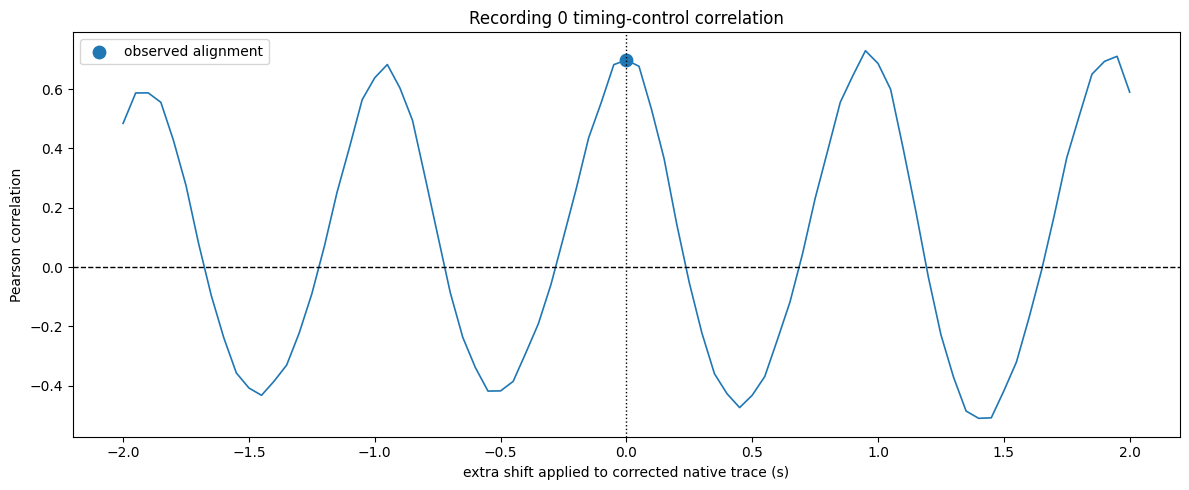

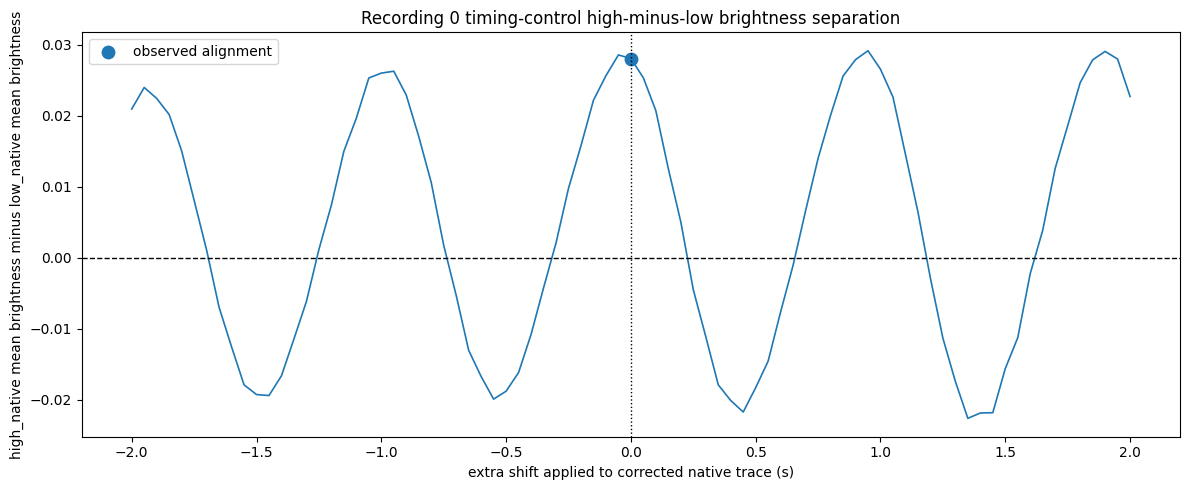

observed_control_shift_s: 1.7763568394002505e-15
observed_corr: 0.6977784191566193
observed_high_minus_low_roi_mean: 0.02807102262698999
n_control_shifts: 81
n_corr_ge_observed: 3
n_sep_ge_observed: 4
best_corr: 0.7291182217736835
best_corr_shift_s: 0.9500000000000028
best_separation: 0.029173049995881717
best_separation_shift_s: 0.9500000000000028


In [49]:
required_names = [
    "global_state_df0",
    "target_metric",
]

missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise NameError(f"Missing required notebook variables: {missing_names}")

control_df = global_state_df0.sort_values("time_s").reset_index(drop=True).copy()

time_s = control_df["time_s"].to_numpy()
roi_values = control_df[target_metric].to_numpy()
native_values = control_df["native_linear_lag"].to_numpy()

control_shift_s_values = np.arange(-2.0, 2.001, 0.05)

control_rows = []

for control_shift_s in control_shift_s_values:
    shifted_native = np.interp(
        time_s + control_shift_s,
        time_s,
        native_values,
        left=np.nan,
        right=np.nan,
    )

    valid = np.isfinite(roi_values) & np.isfinite(shifted_native)

    if valid.sum() < 60:
        continue

    corr = np.corrcoef(roi_values[valid], shifted_native[valid])[0, 1]

    low_cut = np.nanpercentile(shifted_native[valid], 33.3)
    high_cut = np.nanpercentile(shifted_native[valid], 66.7)

    low_mask = valid & (shifted_native <= low_cut)
    high_mask = valid & (shifted_native >= high_cut)

    low_roi_mean = float(np.nanmean(roi_values[low_mask]))
    high_roi_mean = float(np.nanmean(roi_values[high_mask]))

    control_rows.append({
        "control_shift_s": float(control_shift_s),
        "corr": float(corr),
        "abs_corr": float(abs(corr)),
        "n_frames": int(valid.sum()),
        "low_roi_mean": low_roi_mean,
        "high_roi_mean": high_roi_mean,
        "high_minus_low_roi_mean": high_roi_mean - low_roi_mean,
    })

timing_control0 = pd.DataFrame(control_rows)

observed_row = timing_control0.iloc[
    (timing_control0["control_shift_s"] - 0.0).abs().argmin()
].copy()

timing_control0["is_observed_alignment"] = (
    np.isclose(timing_control0["control_shift_s"], observed_row["control_shift_s"])
)

display(
    timing_control0
    .sort_values("corr", ascending=False)
    .head(20)
)

display(
    timing_control0[
        timing_control0["control_shift_s"].between(-0.5, 0.5)
    ]
    .sort_values("control_shift_s")
)

plt.figure(figsize=(12, 5))
plt.plot(
    timing_control0["control_shift_s"],
    timing_control0["corr"],
    linewidth=1.2,
)
plt.scatter(
    [observed_row["control_shift_s"]],
    [observed_row["corr"]],
    s=80,
    label="observed alignment",
)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.axvline(0, color="black", linestyle=":", linewidth=1)
plt.title("Recording 0 timing-control correlation")
plt.xlabel("extra shift applied to corrected native trace (s)")
plt.ylabel("Pearson correlation")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(
    timing_control0["control_shift_s"],
    timing_control0["high_minus_low_roi_mean"],
    linewidth=1.2,
)
plt.scatter(
    [observed_row["control_shift_s"]],
    [observed_row["high_minus_low_roi_mean"]],
    s=80,
    label="observed alignment",
)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.axvline(0, color="black", linestyle=":", linewidth=1)
plt.title("Recording 0 timing-control high-minus-low brightness separation")
plt.xlabel("extra shift applied to corrected native trace (s)")
plt.ylabel("high_native mean brightness minus low_native mean brightness")
plt.legend()
plt.tight_layout()
plt.show()

n_controls = len(timing_control0)
n_corr_ge_observed = int((timing_control0["corr"] >= observed_row["corr"]).sum())
n_sep_ge_observed = int(
    (timing_control0["high_minus_low_roi_mean"] >= observed_row["high_minus_low_roi_mean"]).sum()
)

print("observed_control_shift_s:", observed_row["control_shift_s"])
print("observed_corr:", observed_row["corr"])
print("observed_high_minus_low_roi_mean:", observed_row["high_minus_low_roi_mean"])
print("n_control_shifts:", n_controls)
print("n_corr_ge_observed:", n_corr_ge_observed)
print("n_sep_ge_observed:", n_sep_ge_observed)
print("best_corr:", timing_control0["corr"].max())
print("best_corr_shift_s:", timing_control0.loc[timing_control0["corr"].idxmax(), "control_shift_s"])
print("best_separation:", timing_control0["high_minus_low_roi_mean"].max())
print("best_separation_shift_s:", timing_control0.loc[timing_control0["high_minus_low_roi_mean"].idxmax(), "control_shift_s"])

### Timing-control check for global linear-lag native state interpretation

Result classification: useful positive result with cycle-period ambiguity.

The timing-control check showed that the observed linear-lag alignment performs near a correlation and state-separation peak, but similar peaks also appear at offsets close to one or two brightness-cycle periods.

Evidence-supported observations:

- The observed alignment had correlation approximately `0.698`.
- Only 3 of 81 tested shifts had correlation greater than or equal to the observed alignment.
- Only 4 of 81 tested shifts had high-minus-low brightness separation greater than or equal to the observed alignment.
- The best correlation was approximately `0.729` at extra shift about `+0.95 s`.
- The best high-minus-low separation was also at extra shift about `+0.95 s`.
- Similar positive peaks appeared around offsets near `-0.95 s`, `+0.95 s`, and `+1.95 s`.
- These offsets are consistent with the approximate brightness-cycle spacing seen earlier.



## Global native state bands across brightness-cycle phase in first recording

This section tests whether global linear-lag native state bands occupy different phases of the AVI Doppler brightness cycle in recording `202606130411060002SMP`.

The previous timing-control check showed that the observed native/AVI alignment has strong cycle-period ambiguity. This section therefore folds the stable interval by AVI brightness-cycle phase and compares where low, mid, and high native states occur within the cycle.

This matters because a phase-linked native state should occupy consistent parts of the brightness cycle even when absolute cycle timing is ambiguous.


cycle anchors found: 18
cycle anchor times: [23.5   24.433 25.433 26.367 27.333 28.3   29.267 30.2   31.167 32.1
 33.033 33.967 34.9   35.867 36.833 37.8   38.767 39.767]
cycle spacing seconds: [0.933 1.    0.933 0.967 0.967 0.967 0.933 0.967 0.933 0.933 0.933 0.933
 0.967 0.967 0.967 0.967 1.   ]


,native_state_band,n_frames,phase_mean,phase_std,phase_median,phase_min,phase_max,roi_bright_fraction_mean,native_mean
0,high_native,170,0.469828,0.385387,0.375000,0.000000,0.966667,0.160482,7.606022
1,low_native,161,0.411252,0.157733,0.413793,0.000000,0.964286,0.132878,-0.582474
2,mid_native,157,0.569540,0.246803,0.655172,0.034483,0.966667,0.142262,1.137046


native_state_band,high_native,low_native,mid_native
phase_bin,,,
"(-0.001, 0.0833]",42,4,5
"(0.0833, 0.167]",21,4,10
"(0.167, 0.25]",18,14,13
"(0.25, 0.333]",3,28,9
"(0.333, 0.417]",2,34,7
"(0.417, 0.5]",2,33,6
"(0.5, 0.583]",2,24,10
"(0.583, 0.667]",8,15,20
"(0.667, 0.75]",2,2,38


native_state_band,high_native,low_native,mid_native
phase_bin,,,
"(-0.001, 0.0833]",0.247059,0.024845,0.031847
"(0.0833, 0.167]",0.123529,0.024845,0.063694
"(0.167, 0.25]",0.105882,0.086957,0.082803
"(0.25, 0.333]",0.017647,0.173913,0.057325
"(0.333, 0.417]",0.011765,0.211180,0.044586
"(0.417, 0.5]",0.011765,0.204969,0.038217
"(0.5, 0.583]",0.011765,0.149068,0.063694
"(0.583, 0.667]",0.047059,0.093168,0.127389
"(0.667, 0.75]",0.011765,0.012422,0.242038


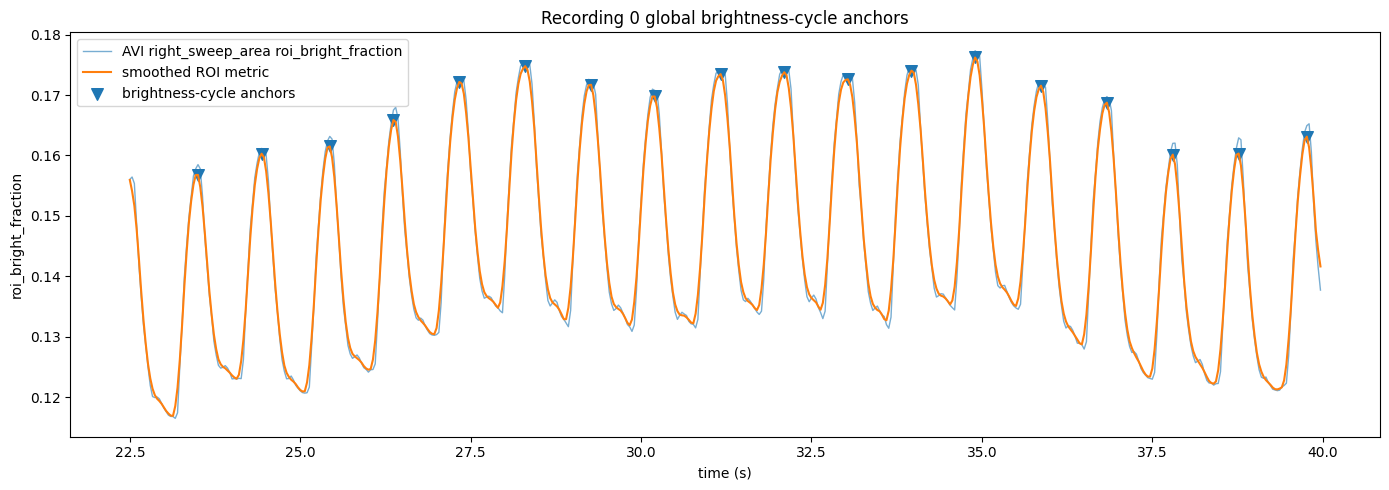

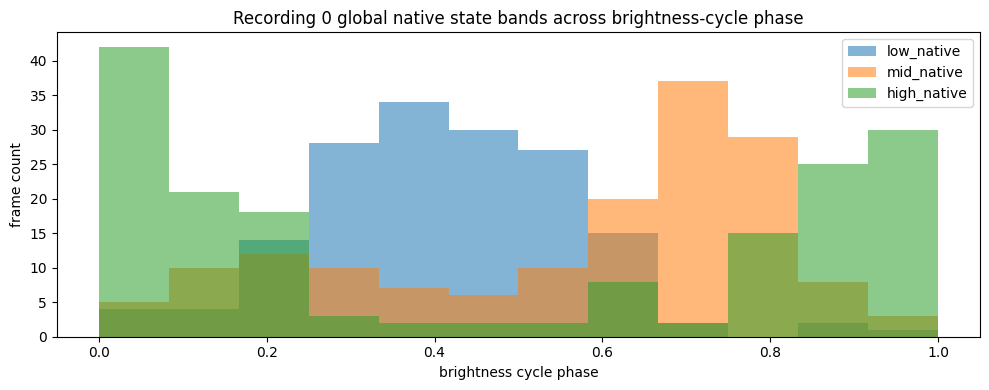

In [50]:
required_names = [
    "global_state_df0",
    "find_peaks",
]

missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise NameError(f"Missing required notebook variables: {missing_names}")

phase_fold_df0 = global_state_df0.sort_values("time_s").reset_index(drop=True).copy()

time_s = phase_fold_df0["time_s"].to_numpy()
roi_signal = phase_fold_df0["roi_bright_fraction"].to_numpy()

smooth_roi_signal = (
    pd.Series(roi_signal)
    .rolling(window=5, center=True, min_periods=1)
    .mean()
    .to_numpy()
)

signal_range = np.nanpercentile(smooth_roi_signal, 95) - np.nanpercentile(smooth_roi_signal, 5)
peak_prominence = max(0.005, 0.15 * signal_range)

peaks, properties = find_peaks(
    smooth_roi_signal,
    distance=18,
    prominence=peak_prominence,
)

cycle_anchor_times = time_s[peaks]

phase_values = np.full(len(phase_fold_df0), np.nan)

if len(cycle_anchor_times) >= 2:
    for cycle_index in range(len(cycle_anchor_times) - 1):
        start_t = cycle_anchor_times[cycle_index]
        end_t = cycle_anchor_times[cycle_index + 1]
        mask = (time_s >= start_t) & (time_s < end_t)
        phase_values[mask] = (time_s[mask] - start_t) / (end_t - start_t)

phase_fold_df0["brightness_cycle_phase"] = phase_values
phase_fold_valid0 = phase_fold_df0.dropna(subset=["brightness_cycle_phase"]).copy()

phase_band_summary_global0 = (
    phase_fold_valid0
    .groupby("native_state_band")
    .agg(
        n_frames=("frame_index", "count"),
        phase_mean=("brightness_cycle_phase", "mean"),
        phase_std=("brightness_cycle_phase", "std"),
        phase_median=("brightness_cycle_phase", "median"),
        phase_min=("brightness_cycle_phase", "min"),
        phase_max=("brightness_cycle_phase", "max"),
        roi_bright_fraction_mean=("roi_bright_fraction", "mean"),
        native_mean=("native_linear_lag", "mean"),
    )
    .reset_index()
)

phase_bins = np.linspace(0, 1, 13)
phase_fold_valid0["phase_bin"] = pd.cut(
    phase_fold_valid0["brightness_cycle_phase"],
    bins=phase_bins,
    include_lowest=True,
)

phase_band_counts_global0 = pd.crosstab(
    phase_fold_valid0["phase_bin"],
    phase_fold_valid0["native_state_band"],
)

phase_band_fraction_global0 = phase_band_counts_global0.div(
    phase_band_counts_global0.sum(axis=0),
    axis=1,
)

print("cycle anchors found:", len(cycle_anchor_times))
print("cycle anchor times:", np.round(cycle_anchor_times, 3))

if len(cycle_anchor_times) >= 2:
    print("cycle spacing seconds:", np.round(np.diff(cycle_anchor_times), 3))

display(phase_band_summary_global0)
display(phase_band_counts_global0)
display(phase_band_fraction_global0)

plt.figure(figsize=(14, 5))
plt.plot(
    phase_fold_df0["time_s"],
    roi_signal,
    linewidth=1.0,
    alpha=0.6,
    label="AVI right_sweep_area roi_bright_fraction",
)
plt.plot(
    phase_fold_df0["time_s"],
    smooth_roi_signal,
    linewidth=1.5,
    label="smoothed ROI metric",
)
plt.scatter(
    cycle_anchor_times,
    smooth_roi_signal[peaks],
    s=70,
    marker="v",
    label="brightness-cycle anchors",
)
plt.title("Recording 0 global brightness-cycle anchors")
plt.xlabel("time (s)")
plt.ylabel("roi_bright_fraction")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))

for state_band in ["low_native", "mid_native", "high_native"]:
    values = phase_fold_valid0.loc[
        phase_fold_valid0["native_state_band"] == state_band,
        "brightness_cycle_phase",
    ]

    plt.hist(
        values,
        bins=np.linspace(0, 1, 13),
        alpha=0.55,
        label=state_band,
    )

plt.title("Recording 0 global native state bands across brightness-cycle phase")
plt.xlabel("brightness cycle phase")
plt.ylabel("frame count")
plt.legend()
plt.tight_layout()
plt.show()

### Global native state bands across brightness-cycle phase in first recording interpretation

Result classification: useful positive result with circular-phase interpretation.

The global brightness-cycle phase fold showed that recording-0 native state bands occupy different parts of the AVI Doppler brightness cycle.

Evidence-supported observations:

- Eighteen brightness-cycle anchors were detected across the `22.5..40.0 s` interval.
- Cycle spacing was regular, mostly about `0.93..1.00 s`.
- `high_native` frames concentrated near the beginning and end of the phase axis.
- Because phase is circular, phase near `0.0` and phase near `1.0` represent the same brightness-cycle neighborhood.
- This means `high_native` is concentrated near the brightness-cycle anchor/peak region.
- `low_native` frames concentrated mainly around phase `0.25..0.58`.
- `mid_native` frames concentrated more strongly around phase `0.67..0.83`.
- The histogram shows state-band structure that is not well summarized by ordinary linear phase mean because the high-native distribution wraps around the phase boundary.



## Circular phase summary for global native state bands

This section summarizes brightness-cycle phase using circular statistics for each global native state band.

The previous section showed that `high_native` frames cluster near both phase `0.0` and phase `1.0`, which are the same location in a circular cycle. This section computes circular mean phase and phase concentration for each native state band.

This matters because circular phase summaries avoid misleading linear means when phase wraps around the `0..1` boundary.

,native_state_band,n_frames,circular_mean_phase,resultant_length,circular_std_like,linear_phase_median,roi_bright_fraction_mean,native_mean
0,high_native,170,0.994563,0.590205,1.026924,0.375000,0.160482,7.606022
1,low_native,161,0.409660,0.635446,0.952290,0.413793,0.132878,-0.582474
2,mid_native,157,0.707777,0.340422,1.468038,0.655172,0.142262,1.137046


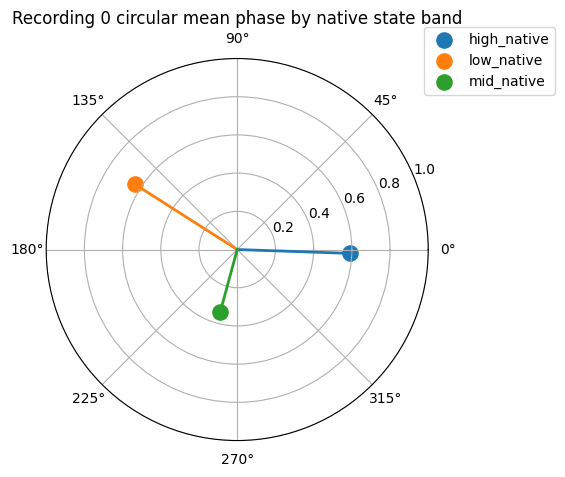

Interpretation helper:
phase 0.00 or 1.00 = brightness-cycle anchor/peak region
phase 0.25 = post-peak falling region
phase 0.50 = opposite side of cycle
phase 0.75 = late/rising region


In [51]:
required_names = [
    "phase_fold_valid0",
]

missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise NameError(f"Missing required notebook variables: {missing_names}")

def circular_phase_summary(phase_values):
    """This function summarizes 0..1 phase values using circular statistics."""
    phase_values = np.asarray(phase_values, dtype=np.float64)
    phase_values = phase_values[np.isfinite(phase_values)]

    if len(phase_values) == 0:
        return {
            "n_frames": 0,
            "circular_mean_phase": np.nan,
            "resultant_length": np.nan,
            "circular_std_like": np.nan,
        }

    angles = 2 * np.pi * phase_values
    mean_cos = np.mean(np.cos(angles))
    mean_sin = np.mean(np.sin(angles))

    mean_angle = np.arctan2(mean_sin, mean_cos)
    if mean_angle < 0:
        mean_angle += 2 * np.pi

    circular_mean_phase = mean_angle / (2 * np.pi)
    resultant_length = np.sqrt(mean_cos ** 2 + mean_sin ** 2)

    circular_std_like = np.sqrt(-2 * np.log(resultant_length)) if resultant_length > 0 else np.nan

    return {
        "n_frames": int(len(phase_values)),
        "circular_mean_phase": float(circular_mean_phase),
        "resultant_length": float(resultant_length),
        "circular_std_like": float(circular_std_like),
    }

circular_rows = []

for state_band, group_df in phase_fold_valid0.groupby("native_state_band"):
    summary = circular_phase_summary(group_df["brightness_cycle_phase"].to_numpy())
    summary["native_state_band"] = state_band
    summary["linear_phase_median"] = float(np.nanmedian(group_df["brightness_cycle_phase"]))
    summary["roi_bright_fraction_mean"] = float(np.nanmean(group_df["roi_bright_fraction"]))
    summary["native_mean"] = float(np.nanmean(group_df["native_linear_lag"]))
    circular_rows.append(summary)

circular_phase_summary0 = (
    pd.DataFrame(circular_rows)
    [
        [
            "native_state_band",
            "n_frames",
            "circular_mean_phase",
            "resultant_length",
            "circular_std_like",
            "linear_phase_median",
            "roi_bright_fraction_mean",
            "native_mean",
        ]
    ]
    .sort_values("native_state_band")
    .reset_index(drop=True)
)

display(circular_phase_summary0)

plt.figure(figsize=(6, 6))
ax = plt.subplot(111, projection="polar")

for _, row in circular_phase_summary0.iterrows():
    angle = 2 * np.pi * row["circular_mean_phase"]
    radius = row["resultant_length"]

    ax.scatter(
        [angle],
        [radius],
        s=120,
        label=row["native_state_band"],
    )
    ax.plot(
        [angle, angle],
        [0, radius],
        linewidth=2,
    )

ax.set_title("Recording 0 circular mean phase by native state band")
ax.set_ylim(0, 1)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.show()

print("Interpretation helper:")
print("phase 0.00 or 1.00 = brightness-cycle anchor/peak region")
print("phase 0.25 = post-peak falling region")
print("phase 0.50 = opposite side of cycle")
print("phase 0.75 = late/rising region")

### Circular phase summary for global native state bands interpretation

Result classification: useful positive result with circular-phase support.

The circular phase summary showed that global native state bands have different brightness-cycle phase centers in recording `202606130411060002SMP`.

Evidence-supported observations:

- `high_native` had circular mean phase approximately `0.995`, which is effectively phase `0.0`.
- This places `high_native` near the brightness-cycle anchor/peak region.
- `low_native` had circular mean phase approximately `0.410`, placing it after the peak and closer to the middle of the cycle.
- `mid_native` had circular mean phase approximately `0.708`, placing it later in the cycle.
- `high_native` and `low_native` had moderate phase concentration, with resultant lengths approximately `0.59` and `0.64`.
- `mid_native` had weaker concentration, with resultant length approximately `0.34`, consistent with a broader or more transitional state.
- The circular mean corrects the misleading linear median for `high_native`, which was affected by phase wrapping across `0.0/1.0`.


## Cycle-level consistency of global native state bands

This section tests whether the global native state-band phase pattern repeats across individual brightness cycles in recording `202606130411060002SMP`.

The previous section showed that pooled circular phase separates `high_native`, `low_native`, and `mid_native`. This section checks each detected brightness cycle separately and summarizes which native state dominates early, middle, and late cycle phases.

This matters because a pooled phase result can be driven by a subset of cycles. Cycle-level consistency would support a more stable phase-linked state interpretation.

,cycle_index,phase_region,native_state_band,n_frames,fraction
0,0,anchor_or_peak_region,low_native,5,0.714286
1,0,post_peak_mid_cycle,low_native,10,1.000000
2,0,late_cycle_region,mid_native,5,0.714286
3,0,return_to_anchor_region,low_native,3,0.750000
4,1,anchor_or_peak_region,low_native,8,1.000000
...,...,...,...,...,...
63,15,return_to_anchor_region,high_native,4,1.000000
64,16,anchor_or_peak_region,mid_native,4,0.500000
65,16,post_peak_mid_cycle,low_native,10,1.000000
66,16,late_cycle_region,mid_native,6,0.750000


,phase_region,native_state_band,n_cycles,mean_fraction,min_fraction,max_fraction
0,anchor_or_peak_region,high_native,12,0.812500,0.375000,1.000
2,anchor_or_peak_region,mid_native,3,0.517857,0.428571,0.625
1,anchor_or_peak_region,low_native,2,0.857143,0.714286,1.000
3,post_peak_mid_cycle,low_native,15,0.808148,0.500000,1.000
4,post_peak_mid_cycle,mid_native,2,0.750000,0.600000,0.900
6,late_cycle_region,mid_native,16,0.737723,0.571429,1.000
5,late_cycle_region,high_native,1,1.000000,1.000000,1.000
7,return_to_anchor_region,high_native,15,0.916667,0.500000,1.000
8,return_to_anchor_region,low_native,1,0.750000,0.750000,0.750
9,return_to_anchor_region,mid_native,1,1.000000,1.000000,1.000


,phase_region,expected_dominant_state,n_cycles,n_matching_cycles,match_fraction
0,anchor_or_peak_region,high_native,17,12,0.705882
1,post_peak_mid_cycle,low_native,17,15,0.882353
2,late_cycle_region,mid_native,17,16,0.941176
3,return_to_anchor_region,high_native,17,15,0.882353


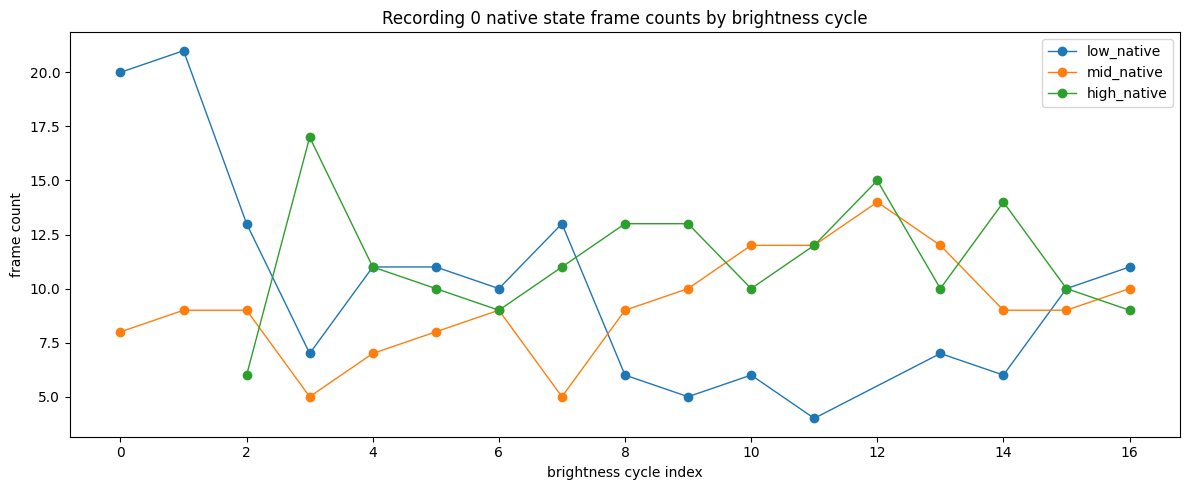

n_cycles_tested: 17
cycle_index_min: 0
cycle_index_max: 16


In [54]:
required_names = [
    "phase_fold_valid0",
    "cycle_anchor_times",
]

missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise NameError(f"Missing required notebook variables: {missing_names}")

cycle_consistency_df0 = phase_fold_valid0.copy().sort_values("time_s").reset_index(drop=True)

cycle_consistency_df0["cycle_index"] = np.nan

for cycle_index in range(len(cycle_anchor_times) - 1):
    start_t = cycle_anchor_times[cycle_index]
    end_t = cycle_anchor_times[cycle_index + 1]
    mask = (
        (cycle_consistency_df0["time_s"] >= start_t)
        & (cycle_consistency_df0["time_s"] < end_t)
    )
    cycle_consistency_df0.loc[mask, "cycle_index"] = cycle_index

cycle_consistency_df0 = cycle_consistency_df0.dropna(subset=["cycle_index"]).copy()
cycle_consistency_df0["cycle_index"] = cycle_consistency_df0["cycle_index"].astype(int)

cycle_consistency_df0["phase_region"] = pd.cut(
    cycle_consistency_df0["brightness_cycle_phase"],
    bins=[0.0, 0.25, 0.60, 0.85, 1.0],
    labels=[
        "anchor_or_peak_region",
        "post_peak_mid_cycle",
        "late_cycle_region",
        "return_to_anchor_region",
    ],
    include_lowest=True,
)

cycle_region_counts0 = (
    cycle_consistency_df0
    .groupby(["cycle_index", "phase_region", "native_state_band"], observed=True)
    .size()
    .reset_index(name="n_frames")
)

cycle_region_totals0 = (
    cycle_region_counts0
    .groupby(["cycle_index", "phase_region"], observed=True)["n_frames"]
    .transform("sum")
)

cycle_region_counts0["fraction"] = cycle_region_counts0["n_frames"] / cycle_region_totals0

dominant_state_by_cycle_region0 = (
    cycle_region_counts0
    .sort_values(["cycle_index", "phase_region", "fraction"], ascending=[True, True, False])
    .groupby(["cycle_index", "phase_region"], observed=True)
    .head(1)
    .reset_index(drop=True)
)

cycle_pattern_summary0 = (
    dominant_state_by_cycle_region0
    .groupby(["phase_region", "native_state_band"], observed=True)
    .agg(
        n_cycles=("cycle_index", "count"),
        mean_fraction=("fraction", "mean"),
        min_fraction=("fraction", "min"),
        max_fraction=("fraction", "max"),
    )
    .reset_index()
    .sort_values(["phase_region", "n_cycles"], ascending=[True, False])
)

display(dominant_state_by_cycle_region0)
display(cycle_pattern_summary0)

expected_regions = {
    "anchor_or_peak_region": "high_native",
    "post_peak_mid_cycle": "low_native",
    "late_cycle_region": "mid_native",
    "return_to_anchor_region": "high_native",
}

expected_rows = []

for region_name, expected_state in expected_regions.items():
    region_df = dominant_state_by_cycle_region0[
        dominant_state_by_cycle_region0["phase_region"].astype(str) == region_name
    ]

    expected_rows.append({
        "phase_region": region_name,
        "expected_dominant_state": expected_state,
        "n_cycles": len(region_df),
        "n_matching_cycles": int((region_df["native_state_band"] == expected_state).sum()),
        "match_fraction": (
            float((region_df["native_state_band"] == expected_state).mean())
            if len(region_df) else np.nan
        ),
    })

expected_pattern_summary0 = pd.DataFrame(expected_rows)

display(expected_pattern_summary0)

plt.figure(figsize=(12, 5))

for state_band in ["low_native", "mid_native", "high_native"]:
    state_counts = (
        cycle_consistency_df0[cycle_consistency_df0["native_state_band"] == state_band]
        .groupby("cycle_index")
        .size()
    )

    plt.plot(
        state_counts.index,
        state_counts.values,
        marker="o",
        linewidth=1,
        label=state_band,
    )

plt.title("Recording 0 native state frame counts by brightness cycle")
plt.xlabel("brightness cycle index")
plt.ylabel("frame count")
plt.legend()
plt.tight_layout()
plt.show()

print("n_cycles_tested:", cycle_consistency_df0["cycle_index"].nunique())
print("cycle_index_min:", cycle_consistency_df0["cycle_index"].min())
print("cycle_index_max:", cycle_consistency_df0["cycle_index"].max())

### Cycle-level consistency of global native state bands interpretation

Result classification: useful positive result with early-cycle and anchor-region caution.

The cycle-level check showed that the global native state-band phase pattern repeated across most individual brightness cycles in recording `202606130411060002SMP`.

Evidence-supported observations:

- Seventeen brightness cycles were tested.
- The expected dominant state pattern was:
  - `high_native` in the anchor or peak region
  - `low_native` in the post-peak mid-cycle region
  - `mid_native` in the late-cycle region
  - `high_native` in the return-to-anchor region
- The expected pattern matched most cycles:
  - anchor or peak region: `12 / 17` cycles, approximately `70.6%`
  - post-peak mid-cycle: `15 / 17` cycles, approximately `88.2%`
  - late-cycle region: `16 / 17` cycles, approximately `94.1%`
  - return-to-anchor region: `15 / 17` cycles, approximately `88.2%`
- The anchor or peak region was the least consistent region.
- The first cycles showed more `low_native` dominance, while later cycles more often followed the expected high/low/mid/high phase pattern.
- The cycle-level result supports a repeated phase-linked state pattern, not only a pooled histogram effect.



## Shuffle-control check for cycle-level native state pattern

This section tests whether the cycle-level native state pattern is stronger than expected after randomizing native state timing within each brightness cycle.

The previous section found that most individual cycles followed an expected phase-region pattern: `high_native` near the anchor or peak region, `low_native` after the peak, `mid_native` later in the cycle, and `high_native` again near return to anchor. This section shuffles native state labels within each cycle and recomputes the same expected-pattern match score.

This matters because a cycle can contain many high, mid, or low frames by chance. A within-cycle shuffle control preserves each cycle's state counts while testing whether the phase placement of those states is meaningful.

,phase_region,expected_dominant_state,n_cycles,n_matching_cycles,match_fraction
0,anchor_or_peak_region,high_native,17,12,0.705882
1,post_peak_mid_cycle,low_native,17,15,0.882353
2,late_cycle_region,mid_native,17,16,0.941176
3,return_to_anchor_region,high_native,17,15,0.882353


,metric,observed,shuffle_mean,shuffle_p95,shuffle_max,p_shuffle_ge_observed
0,overall_match_fraction,0.852941,0.372926,0.455882,0.529412,0.000
1,anchor_or_peak_region_match_fraction,0.705882,0.482235,0.647059,0.823529,0.025
2,post_peak_mid_cycle_match_fraction,0.882353,0.338059,0.470588,0.647059,0.000
3,late_cycle_region_match_fraction,0.941176,0.214588,0.352941,0.529412,0.000
4,return_to_anchor_region_match_fraction,0.882353,0.456824,0.647059,0.705882,0.000


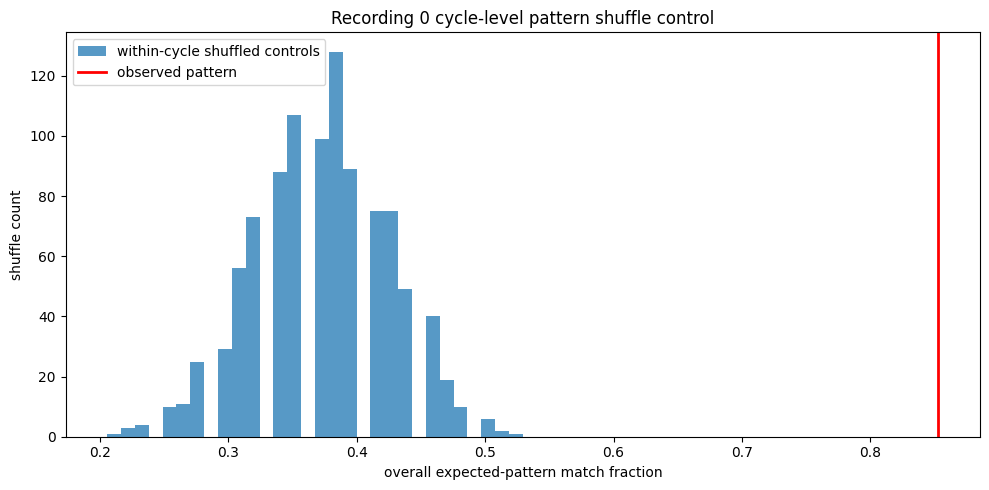

observed_overall_match_fraction: 0.8529411764705882
n_shuffles: 1000
p_overall_shuffle_ge_observed: 0.0


In [55]:
required_names = [
    "cycle_consistency_df0",
    "expected_pattern_summary0",
]

missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise NameError(f"Missing required notebook variables: {missing_names}")

expected_regions = {
    "anchor_or_peak_region": "high_native",
    "post_peak_mid_cycle": "low_native",
    "late_cycle_region": "mid_native",
    "return_to_anchor_region": "high_native",
}

def compute_expected_pattern_score(input_df, expected_regions):
    """This function computes phase-region expected-state match fractions."""
    region_counts = (
        input_df
        .groupby(["cycle_index", "phase_region", "native_state_band"], observed=True)
        .size()
        .reset_index(name="n_frames")
    )

    region_totals = (
        region_counts
        .groupby(["cycle_index", "phase_region"], observed=True)["n_frames"]
        .transform("sum")
    )

    region_counts["fraction"] = region_counts["n_frames"] / region_totals

    dominant = (
        region_counts
        .sort_values(["cycle_index", "phase_region", "fraction"], ascending=[True, True, False])
        .groupby(["cycle_index", "phase_region"], observed=True)
        .head(1)
        .reset_index(drop=True)
    )

    rows = []

    for region_name, expected_state in expected_regions.items():
        region_df = dominant[dominant["phase_region"].astype(str) == region_name]

        rows.append({
            "phase_region": region_name,
            "expected_dominant_state": expected_state,
            "n_cycles": len(region_df),
            "n_matching_cycles": int((region_df["native_state_band"] == expected_state).sum()),
            "match_fraction": (
                float((region_df["native_state_band"] == expected_state).mean())
                if len(region_df) else np.nan
            ),
        })

    summary = pd.DataFrame(rows)
    overall_match_fraction = summary["n_matching_cycles"].sum() / summary["n_cycles"].sum()

    return summary, overall_match_fraction

observed_shuffle_summary0, observed_overall_match0 = compute_expected_pattern_score(
    cycle_consistency_df0,
    expected_regions,
)

rng = np.random.default_rng(20260705)
n_shuffles = 1000

shuffle_rows = []

for shuffle_index in range(n_shuffles):
    shuffled_df = cycle_consistency_df0.copy()

    for cycle_index, cycle_df in shuffled_df.groupby("cycle_index"):
        shuffled_states = cycle_df["native_state_band"].to_numpy().copy()
        rng.shuffle(shuffled_states)
        shuffled_df.loc[cycle_df.index, "native_state_band"] = shuffled_states

    shuffle_summary, shuffle_overall_match = compute_expected_pattern_score(
        shuffled_df,
        expected_regions,
    )

    row = {
        "shuffle_index": shuffle_index,
        "overall_match_fraction": shuffle_overall_match,
    }

    for _, summary_row in shuffle_summary.iterrows():
        row[f"{summary_row['phase_region']}_match_fraction"] = summary_row["match_fraction"]

    shuffle_rows.append(row)

shuffle_control0 = pd.DataFrame(shuffle_rows)

p_overall_ge_observed = float(
    (shuffle_control0["overall_match_fraction"] >= observed_overall_match0).mean()
)

control_summary_rows = []

for column in shuffle_control0.columns:
    if not column.endswith("match_fraction"):
        continue

    observed_value = (
        observed_overall_match0
        if column == "overall_match_fraction"
        else observed_shuffle_summary0.loc[
            observed_shuffle_summary0["phase_region"].astype(str)
            == column.replace("_match_fraction", ""),
            "match_fraction",
        ].iloc[0]
    )

    control_summary_rows.append({
        "metric": column,
        "observed": observed_value,
        "shuffle_mean": float(shuffle_control0[column].mean()),
        "shuffle_p95": float(np.percentile(shuffle_control0[column], 95)),
        "shuffle_max": float(shuffle_control0[column].max()),
        "p_shuffle_ge_observed": float((shuffle_control0[column] >= observed_value).mean()),
    })

shuffle_control_summary0 = pd.DataFrame(control_summary_rows)

display(observed_shuffle_summary0)
display(shuffle_control_summary0)

plt.figure(figsize=(10, 5))
plt.hist(
    shuffle_control0["overall_match_fraction"],
    bins=30,
    alpha=0.75,
    label="within-cycle shuffled controls",
)
plt.axvline(
    observed_overall_match0,
    color="red",
    linewidth=2,
    label="observed pattern",
)
plt.title("Recording 0 cycle-level pattern shuffle control")
plt.xlabel("overall expected-pattern match fraction")
plt.ylabel("shuffle count")
plt.legend()
plt.tight_layout()
plt.show()

print("observed_overall_match_fraction:", observed_overall_match0)
print("n_shuffles:", n_shuffles)
print("p_overall_shuffle_ge_observed:", p_overall_ge_observed)

### Shuffle-control check for cycle-level native state pattern interpretation

Result classification: useful positive result with control support.

The within-cycle shuffle control showed that the observed cycle-level native state pattern in recording `202606130411060002SMP` was much stronger than expected after randomizing native state timing within each brightness cycle.

Evidence-supported observations:

- The observed overall expected-pattern match fraction was approximately `0.853`.
- The shuffled controls had mean overall match fraction approximately `0.373`.
- The shuffled-control 95th percentile was approximately `0.456`.
- The maximum shuffled overall match fraction was approximately `0.529`.
- None of the 1000 shuffled controls matched or exceeded the observed overall pattern.
- Region-level controls also supported non-random phase placement:
  - post-peak mid-cycle: observed `0.882`, shuffle `p ≈ 0.000`
  - late-cycle region: observed `0.941`, shuffle `p ≈ 0.000`
  - return-to-anchor region: observed `0.882`, shuffle `p ≈ 0.000`
  - anchor or peak region: observed `0.706`, shuffle `p ≈ 0.025`



## Shuffle-control check for recording-1 phase-state pattern

This section tests whether the recording-1 native state-band phase pattern is stronger than expected after randomizing native state timing within each brightness cycle.

Earlier sections found that recording `202606130413540003SMP` had a strong segment-level inverse association between native `value_all_mean` and AVI center ROI brightness in the `25..30 s` segment. This section applies a cycle-level shuffle control to that selected segment.

This matters because recording 0 showed a controlled phase-linked native state pattern. Recording 1 provides a cautious generalization check, but it may use different native features, polarity, and ROI behavior.

,phase_region,native_state_band,n_frames
0,anchor_or_trough_region,high_native,24
1,anchor_or_trough_region,low_native,1
2,anchor_or_trough_region,mid_native,11
3,post_anchor_mid_cycle,low_native,32
4,post_anchor_mid_cycle,mid_native,15
5,late_cycle_region,high_native,4
6,late_cycle_region,low_native,13
7,late_cycle_region,mid_native,16
8,return_to_anchor_region,high_native,15
9,return_to_anchor_region,mid_native,4


recording-1 expected regions from observed dominant states:
{'anchor_or_trough_region': 'high_native', 'post_anchor_mid_cycle': 'low_native', 'late_cycle_region': 'mid_native', 'return_to_anchor_region': 'high_native'}


,phase_region,expected_dominant_state,n_cycles,n_matching_cycles,match_fraction
0,anchor_or_trough_region,high_native,4,3,0.75
1,post_anchor_mid_cycle,low_native,4,4,1.00
2,late_cycle_region,mid_native,4,1,0.25
3,return_to_anchor_region,high_native,4,3,0.75


,metric,observed,shuffle_mean,shuffle_p95,shuffle_max,p_shuffle_ge_observed
0,overall_match_fraction,0.6875,0.361063,0.5625,0.75,0.013
1,anchor_or_trough_region_match_fraction,0.7500,0.402250,0.7500,1.00,0.163
2,post_anchor_mid_cycle_match_fraction,1.0000,0.344500,0.7500,1.00,0.005
3,late_cycle_region_match_fraction,0.2500,0.270250,0.7500,1.00,0.735
4,return_to_anchor_region_match_fraction,0.7500,0.427250,0.7500,1.00,0.202


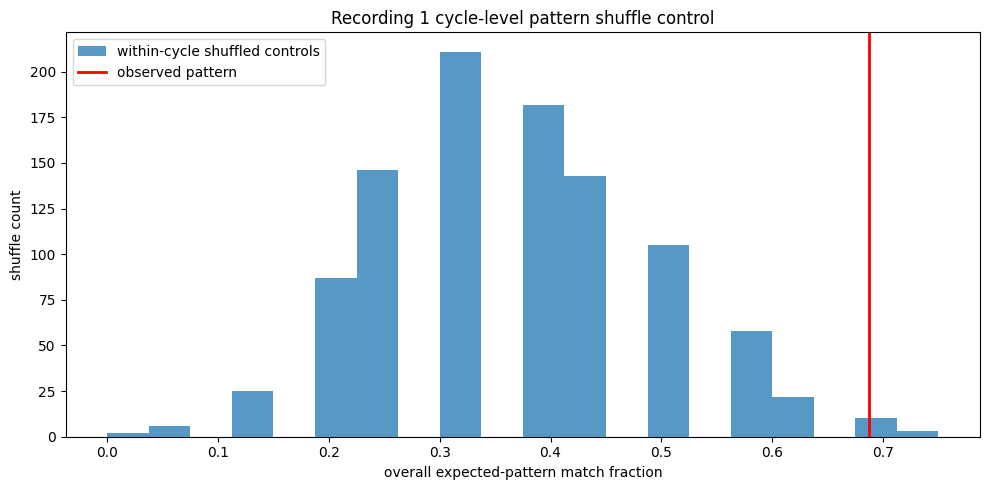

recording: 202606130413540003SMP
feature: value_all_mean
target_metric: roi_mean
segment_start_s: 25.0
segment_end_s: 30.0
lag_s: 0.29
cycle anchors found: 5
cycle anchor times: [25.1   26.2   27.333 28.467 29.6  ]
n_cycles_tested: 4
observed_overall_match_fraction: 0.6875
n_shuffles: 1000
p_overall_shuffle_ge_observed: 0.013


In [56]:
required_names = [
    "roi_df_1",
    "feature_dict",
    "native_time_s_full_1",
    "find_peaks",
]

missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise NameError(f"Missing required notebook variables: {missing_names}")

recording1_feature_name = "value_all_mean"
recording1_feature_values = feature_dict[recording1_feature_name]

recording1_target_metric = "roi_mean"
recording1_segment_start_s = 25.0
recording1_segment_end_s = 30.0
recording1_lag_s = 0.29

recording1_df = (
    roi_df_1[
        (roi_df_1["time_s"] >= recording1_segment_start_s)
        & (roi_df_1["time_s"] < recording1_segment_end_s)
    ]
    .sort_values("time_s")
    .reset_index(drop=True)
    .copy()
)

recording1_df["native_shifted"] = np.interp(
    recording1_df["time_s"].to_numpy() + recording1_lag_s,
    native_time_s_full_1,
    recording1_feature_values,
    left=np.nan,
    right=np.nan,
)

low_cut = np.nanpercentile(recording1_df["native_shifted"], 33.3)
high_cut = np.nanpercentile(recording1_df["native_shifted"], 66.7)

recording1_df["native_state_band"] = np.select(
    [
        recording1_df["native_shifted"] <= low_cut,
        recording1_df["native_shifted"] >= high_cut,
    ],
    [
        "low_native",
        "high_native",
    ],
    default="mid_native",
)

# Earlier recording-1 results used inverted ROI mean minima as cycle anchors.
roi_signal = recording1_df[recording1_target_metric].to_numpy()
time_s = recording1_df["time_s"].to_numpy()
inverted_roi = -roi_signal

peaks, properties = find_peaks(
    inverted_roi,
    distance=18,
    prominence=0.6,
)

recording1_anchor_times = time_s[peaks]

phase_values = np.full(len(recording1_df), np.nan)
cycle_index_values = np.full(len(recording1_df), np.nan)

if len(recording1_anchor_times) >= 2:
    for cycle_index in range(len(recording1_anchor_times) - 1):
        start_t = recording1_anchor_times[cycle_index]
        end_t = recording1_anchor_times[cycle_index + 1]
        mask = (time_s >= start_t) & (time_s < end_t)
        phase_values[mask] = (time_s[mask] - start_t) / (end_t - start_t)
        cycle_index_values[mask] = cycle_index

recording1_df["brightness_cycle_phase"] = phase_values
recording1_df["cycle_index"] = cycle_index_values

recording1_cycle_df = recording1_df.dropna(
    subset=["brightness_cycle_phase", "cycle_index", "native_state_band"]
).copy()

recording1_cycle_df["cycle_index"] = recording1_cycle_df["cycle_index"].astype(int)

recording1_cycle_df["phase_region"] = pd.cut(
    recording1_cycle_df["brightness_cycle_phase"],
    bins=[0.0, 0.25, 0.60, 0.85, 1.0],
    labels=[
        "anchor_or_trough_region",
        "post_anchor_mid_cycle",
        "late_cycle_region",
        "return_to_anchor_region",
    ],
    include_lowest=True,
)

region_state_counts1 = (
    recording1_cycle_df
    .groupby(["phase_region", "native_state_band"], observed=True)
    .size()
    .reset_index(name="n_frames")
)

display(region_state_counts1)

# Define the expected pattern from the observed dominant state in each phase region.
dominant_observed1 = (
    region_state_counts1
    .sort_values(["phase_region", "n_frames"], ascending=[True, False])
    .groupby("phase_region", observed=True)
    .head(1)
    .reset_index(drop=True)
)

expected_regions1 = {
    str(row["phase_region"]): row["native_state_band"]
    for _, row in dominant_observed1.iterrows()
}

print("recording-1 expected regions from observed dominant states:")
print(expected_regions1)

def compute_expected_pattern_score(input_df, expected_regions):
    """This function computes cycle-region expected-state match fractions."""
    region_counts = (
        input_df
        .groupby(["cycle_index", "phase_region", "native_state_band"], observed=True)
        .size()
        .reset_index(name="n_frames")
    )

    region_totals = (
        region_counts
        .groupby(["cycle_index", "phase_region"], observed=True)["n_frames"]
        .transform("sum")
    )

    region_counts["fraction"] = region_counts["n_frames"] / region_totals

    dominant = (
        region_counts
        .sort_values(["cycle_index", "phase_region", "fraction"], ascending=[True, True, False])
        .groupby(["cycle_index", "phase_region"], observed=True)
        .head(1)
        .reset_index(drop=True)
    )

    rows = []

    for region_name, expected_state in expected_regions.items():
        region_df = dominant[dominant["phase_region"].astype(str) == region_name]

        rows.append({
            "phase_region": region_name,
            "expected_dominant_state": expected_state,
            "n_cycles": len(region_df),
            "n_matching_cycles": int((region_df["native_state_band"] == expected_state).sum()),
            "match_fraction": (
                float((region_df["native_state_band"] == expected_state).mean())
                if len(region_df) else np.nan
            ),
        })

    summary = pd.DataFrame(rows)
    overall_match_fraction = summary["n_matching_cycles"].sum() / summary["n_cycles"].sum()

    return summary, overall_match_fraction

observed_shuffle_summary1, observed_overall_match1 = compute_expected_pattern_score(
    recording1_cycle_df,
    expected_regions1,
)

rng = np.random.default_rng(20260705)
n_shuffles = 1000
shuffle_rows = []

for shuffle_index in range(n_shuffles):
    shuffled_df = recording1_cycle_df.copy()

    for cycle_index, cycle_df in shuffled_df.groupby("cycle_index"):
        shuffled_states = cycle_df["native_state_band"].to_numpy().copy()
        rng.shuffle(shuffled_states)
        shuffled_df.loc[cycle_df.index, "native_state_band"] = shuffled_states

    shuffle_summary, shuffle_overall_match = compute_expected_pattern_score(
        shuffled_df,
        expected_regions1,
    )

    row = {
        "shuffle_index": shuffle_index,
        "overall_match_fraction": shuffle_overall_match,
    }

    for _, summary_row in shuffle_summary.iterrows():
        row[f"{summary_row['phase_region']}_match_fraction"] = summary_row["match_fraction"]

    shuffle_rows.append(row)

shuffle_control1 = pd.DataFrame(shuffle_rows)

control_summary_rows = []

for column in shuffle_control1.columns:
    if not column.endswith("match_fraction"):
        continue

    observed_value = (
        observed_overall_match1
        if column == "overall_match_fraction"
        else observed_shuffle_summary1.loc[
            observed_shuffle_summary1["phase_region"].astype(str)
            == column.replace("_match_fraction", ""),
            "match_fraction",
        ].iloc[0]
    )

    control_summary_rows.append({
        "metric": column,
        "observed": observed_value,
        "shuffle_mean": float(shuffle_control1[column].mean()),
        "shuffle_p95": float(np.percentile(shuffle_control1[column], 95)),
        "shuffle_max": float(shuffle_control1[column].max()),
        "p_shuffle_ge_observed": float((shuffle_control1[column] >= observed_value).mean()),
    })

shuffle_control_summary1 = pd.DataFrame(control_summary_rows)

display(observed_shuffle_summary1)
display(shuffle_control_summary1)

plt.figure(figsize=(10, 5))
plt.hist(
    shuffle_control1["overall_match_fraction"],
    bins=20,
    alpha=0.75,
    label="within-cycle shuffled controls",
)
plt.axvline(
    observed_overall_match1,
    color="red",
    linewidth=2,
    label="observed pattern",
)
plt.title("Recording 1 cycle-level pattern shuffle control")
plt.xlabel("overall expected-pattern match fraction")
plt.ylabel("shuffle count")
plt.legend()
plt.tight_layout()
plt.show()

print("recording:", recording_id_1 if "recording_id_1" in globals() else "recording 1")
print("feature:", recording1_feature_name)
print("target_metric:", recording1_target_metric)
print("segment_start_s:", recording1_segment_start_s)
print("segment_end_s:", recording1_segment_end_s)
print("lag_s:", recording1_lag_s)
print("cycle anchors found:", len(recording1_anchor_times))
print("cycle anchor times:", np.round(recording1_anchor_times, 3))
print("n_cycles_tested:", recording1_cycle_df["cycle_index"].nunique())
print("observed_overall_match_fraction:", observed_overall_match1)
print("n_shuffles:", n_shuffles)
print(
    "p_overall_shuffle_ge_observed:",
    float((shuffle_control1["overall_match_fraction"] >= observed_overall_match1).mean()),
)

### Shuffle-control check for recording-1 phase-state pattern interpretation

Result classification: mixed but useful evidence.

The recording-1 shuffle-control check found that the selected `25..30 s` segment had a stronger overall phase-state pattern than most within-cycle shuffled controls, but the support was not uniform across phase regions.

Evidence-supported observations:

- Recording 1 tested only 4 complete brightness cycles in the selected segment.
- The observed overall expected-pattern match fraction was `0.6875`.
- The shuffled controls had mean overall match fraction approximately `0.361`.
- The observed overall pattern exceeded most shuffled controls, with `p ≈ 0.013`.
- The strongest region-level support was in the post-anchor mid-cycle region:
  - observed match fraction `1.00`
  - shuffle `p ≈ 0.005`
- Other regions were weaker:
  - anchor or trough region: `p ≈ 0.163`
  - late-cycle region: `p ≈ 0.735`
  - return-to-anchor region: `p ≈ 0.202`
- The late-cycle region did not support the observed expected pattern.
- The expected region pattern was derived from the same selected segment, so this remains exploratory.


## Adjacent-segment phase-state check in second recording

This section tests whether the recording-1 `value_all_mean` phase-state pattern appears in segments adjacent to the selected `25..30 s` window.

The previous section found a mixed but useful shuffle-control result in the `25..30 s` segment. This section repeats the same phase-region summary for nearby `5 s` windows using the segment-specific best lag from the earlier segment-level scan.

This matters because the recording-1 result is based on few cycles. Adjacent-segment behavior can show whether the phase/state relationship is localized, repeated, or unstable.

In [57]:
required_names = [
    "roi_df_1",
    "feature_dict",
    "native_time_s_full_1",
    "segment_feature_scan1",
    "find_peaks",
]

missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise NameError(f"Missing required notebook variables: {missing_names}")

feature_name = "value_all_mean"
feature_values = feature_dict[feature_name]
target_metric = "roi_mean"

segments_to_check = [
    (20.0, 25.0),
    (22.5, 27.5),
    (25.0, 30.0),
    (27.5, 32.5),
    (30.0, 35.0),
]

adjacent_rows = []

for segment_start_s, segment_end_s in segments_to_check:
    match = segment_feature_scan1[
        (np.isclose(segment_feature_scan1["segment_start_s"], segment_start_s))
        & (np.isclose(segment_feature_scan1["segment_end_s"], segment_end_s))
    ]

    if len(match) != 1:
        print("Skipping segment without exact scan match:", segment_start_s, segment_end_s)
        continue

    best_lag_s = float(match.iloc[0]["lag_s"])
    scan_corr = float(match.iloc[0]["corr"])

    segment_df = (
        roi_df_1[
            (roi_df_1["time_s"] >= segment_start_s)
            & (roi_df_1["time_s"] < segment_end_s)
        ]
        .sort_values("time_s")
        .reset_index(drop=True)
        .copy()
    )

    segment_df["native_shifted"] = np.interp(
        segment_df["time_s"].to_numpy() + best_lag_s,
        native_time_s_full_1,
        feature_values,
        left=np.nan,
        right=np.nan,
    )

    low_cut = np.nanpercentile(segment_df["native_shifted"], 33.3)
    high_cut = np.nanpercentile(segment_df["native_shifted"], 66.7)

    segment_df["native_state_band"] = np.select(
        [
            segment_df["native_shifted"] <= low_cut,
            segment_df["native_shifted"] >= high_cut,
        ],
        [
            "low_native",
            "high_native",
        ],
        default="mid_native",
    )

    roi_signal = segment_df[target_metric].to_numpy()
    time_s = segment_df["time_s"].to_numpy()

    inverted_roi = -roi_signal

    peaks, properties = find_peaks(
        inverted_roi,
        distance=18,
        prominence=0.6,
    )

    anchor_times = time_s[peaks]

    phase_values = np.full(len(segment_df), np.nan)

    if len(anchor_times) >= 2:
        for cycle_index in range(len(anchor_times) - 1):
            start_t = anchor_times[cycle_index]
            end_t = anchor_times[cycle_index + 1]
            mask = (time_s >= start_t) & (time_s < end_t)
            phase_values[mask] = (time_s[mask] - start_t) / (end_t - start_t)

    segment_df["brightness_cycle_phase"] = phase_values

    valid_phase_df = segment_df.dropna(subset=["brightness_cycle_phase"]).copy()

    valid_phase_df["phase_region"] = pd.cut(
        valid_phase_df["brightness_cycle_phase"],
        bins=[0.0, 0.25, 0.60, 0.85, 1.0],
        labels=[
            "anchor_or_trough_region",
            "post_anchor_mid_cycle",
            "late_cycle_region",
            "return_to_anchor_region",
        ],
        include_lowest=True,
    )

    region_counts = (
        valid_phase_df
        .groupby(["phase_region", "native_state_band"], observed=True)
        .size()
        .reset_index(name="n_frames")
    )

    dominant_regions = (
        region_counts
        .sort_values(["phase_region", "n_frames"], ascending=[True, False])
        .groupby("phase_region", observed=True)
        .head(1)
        .reset_index(drop=True)
    )

    for _, row in dominant_regions.iterrows():
        adjacent_rows.append({
            "segment_start_s": segment_start_s,
            "segment_end_s": segment_end_s,
            "best_lag_s": best_lag_s,
            "scan_corr": scan_corr,
            "n_anchors": len(anchor_times),
            "n_cycles": max(0, len(anchor_times) - 1),
            "phase_region": row["phase_region"],
            "dominant_native_state": row["native_state_band"],
            "dominant_n_frames": int(row["n_frames"]),
        })

adjacent_phase_state1 = pd.DataFrame(adjacent_rows)

display(adjacent_phase_state1)

dominant_pattern_pivot1 = adjacent_phase_state1.pivot_table(
    index=["segment_start_s", "segment_end_s", "best_lag_s", "scan_corr", "n_cycles"],
    columns="phase_region",
    values="dominant_native_state",
    aggfunc="first",
).reset_index()

display(dominant_pattern_pivot1)

print("recording:", recording_id_1 if "recording_id_1" in globals() else "recording 1")
print("feature:", feature_name)
print("target_metric:", target_metric)
print("segments_checked:", dominant_pattern_pivot1.shape[0])

,segment_start_s,segment_end_s,best_lag_s,scan_corr,n_anchors,n_cycles,phase_region,dominant_native_state,dominant_n_frames
0,20.0,25.0,-0.47,0.565154,4,3,anchor_or_trough_region,low_native,17
1,20.0,25.0,-0.47,0.565154,4,3,post_anchor_mid_cycle,mid_native,15
2,20.0,25.0,-0.47,0.565154,4,3,late_cycle_region,high_native,18
3,20.0,25.0,-0.47,0.565154,4,3,return_to_anchor_region,low_native,9
4,22.5,27.5,0.26,-0.662199,5,4,anchor_or_trough_region,high_native,21
5,22.5,27.5,0.26,-0.662199,5,4,post_anchor_mid_cycle,low_native,32
6,22.5,27.5,0.26,-0.662199,5,4,late_cycle_region,mid_native,23
7,22.5,27.5,0.26,-0.662199,5,4,return_to_anchor_region,high_native,18
8,25.0,30.0,0.29,-0.713968,5,4,anchor_or_trough_region,high_native,24
9,25.0,30.0,0.29,-0.713968,5,4,post_anchor_mid_cycle,low_native,32


phase_region,segment_start_s,segment_end_s,best_lag_s,scan_corr,n_cycles,anchor_or_trough_region,late_cycle_region,post_anchor_mid_cycle,return_to_anchor_region
0,20.0,25.0,-0.47,0.565154,3,low_native,high_native,mid_native,low_native
1,22.5,27.5,0.26,-0.662199,4,high_native,mid_native,low_native,high_native
2,25.0,30.0,0.29,-0.713968,4,high_native,mid_native,low_native,high_native
3,27.5,32.5,0.29,-0.610856,2,high_native,mid_native,low_native,high_native
4,30.0,35.0,-0.41,0.363666,1,low_native,low_native,mid_native,high_native


recording: 202606130413540003SMP
feature: value_all_mean
target_metric: roi_mean
segments_checked: 5


### Adjacent-segment phase-state check in second recording interpretation

Result classification: mixed but useful evidence.

The adjacent-segment check showed that recording `202606130413540003SMP` has a repeated phase-state pattern in the central `22.5..32.5 s` interval, but not across all tested windows.

Evidence-supported observations:

- Five nearby `5 s` segments were tested.
- The strongest and most consistent pattern appeared from `22.5..32.5 s`.
- In the three overlapping segments `22.5..27.5 s`, `25.0..30.0 s`, and `27.5..32.5 s`, the same dominant state sequence appeared:
  - `high_native` near the anchor or trough region
  - `low_native` in the post-anchor mid-cycle region
  - `mid_native` in the late-cycle region
  - `high_native` in the return-to-anchor region
- These same segments had negative scan correlations, consistent with the earlier inverse relationship between `value_all_mean` and AVI center ROI brightness.
- The `20.0..25.0 s` segment showed a different pattern.
- The `30.0..35.0 s` segment had only one complete detected cycle, so it is not strong evidence.
- Recording 1 therefore shows a localized repeated phase-state pattern, strongest around `22.5..32.5 s`.


## Combined stable-interval phase-state check in second recording

This section tests whether the recording-1 phase-state pattern remains visible across the combined `22.5..32.5 s` interval using one fixed lag.

The previous section found the same dominant phase-state sequence in overlapping segments from `22.5..32.5 s`. This section combines that interval and applies a single lag of `+0.29 s`, matching the strongest selected segment.

This matters because overlapping segment checks can overstate consistency. A combined-window check is a cleaner test of whether the localized recording-1 phase-state pattern persists across the full interval.

,native_state_band,n_frames,native_mean,roi_mean_mean,roi_bright_fraction_mean,roi_p95_mean
0,high_native,100,2.075556,21.572673,0.104969,148.0915
1,low_native,100,-3.161381,22.565628,0.110489,151.4605
2,mid_native,100,-0.334101,22.514213,0.110451,151.2605


,phase_region,native_state_band,n_frames
0,anchor_or_trough_region,high_native,36
1,anchor_or_trough_region,low_native,7
2,anchor_or_trough_region,mid_native,20
3,post_anchor_mid_cycle,low_native,55
4,post_anchor_mid_cycle,mid_native,27
5,late_cycle_region,high_native,10
6,late_cycle_region,low_native,16
7,late_cycle_region,mid_native,32
8,return_to_anchor_region,high_native,33


,phase_region,native_state_band,n_frames
0,anchor_or_trough_region,high_native,36
1,post_anchor_mid_cycle,low_native,55
2,late_cycle_region,mid_native,32
3,return_to_anchor_region,high_native,33


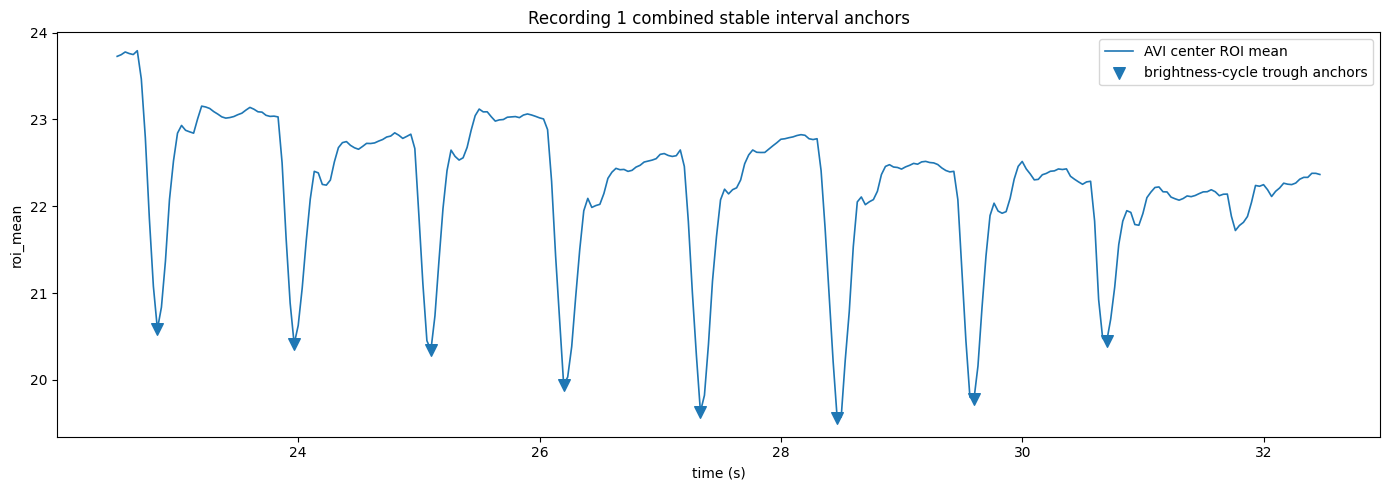

recording: 202606130413540003SMP
feature: value_all_mean
target_metric: roi_mean
stable_start_s: 22.5
stable_end_s: 32.5
fixed_lag_s: 0.29
combined_corr: -0.6014785173864947
cycle anchors found: 8
cycle anchor times: [22.833 23.967 25.1   26.2   27.333 28.467 29.6   30.7  ]
n_complete_cycles: 7
n_frames: 300


In [58]:
required_names = [
    "roi_df_1",
    "feature_dict",
    "native_time_s_full_1",
    "find_peaks",
]

missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise NameError(f"Missing required notebook variables: {missing_names}")

feature_name = "value_all_mean"
feature_values = feature_dict[feature_name]

target_metric = "roi_mean"
stable_start_s = 22.5
stable_end_s = 32.5
fixed_lag_s = 0.29

combined_df1 = (
    roi_df_1[
        (roi_df_1["time_s"] >= stable_start_s)
        & (roi_df_1["time_s"] < stable_end_s)
    ]
    .sort_values("time_s")
    .reset_index(drop=True)
    .copy()
)

combined_df1["native_shifted"] = np.interp(
    combined_df1["time_s"].to_numpy() + fixed_lag_s,
    native_time_s_full_1,
    feature_values,
    left=np.nan,
    right=np.nan,
)

low_cut = np.nanpercentile(combined_df1["native_shifted"], 33.3)
high_cut = np.nanpercentile(combined_df1["native_shifted"], 66.7)

combined_df1["native_state_band"] = np.select(
    [
        combined_df1["native_shifted"] <= low_cut,
        combined_df1["native_shifted"] >= high_cut,
    ],
    [
        "low_native",
        "high_native",
    ],
    default="mid_native",
)

valid = (
    np.isfinite(combined_df1[target_metric].to_numpy())
    & np.isfinite(combined_df1["native_shifted"].to_numpy())
)

combined_corr1 = np.corrcoef(
    combined_df1.loc[valid, target_metric],
    combined_df1.loc[valid, "native_shifted"],
)[0, 1]

state_summary1 = (
    combined_df1
    .groupby("native_state_band")
    .agg(
        n_frames=("frame_index", "count"),
        native_mean=("native_shifted", "mean"),
        roi_mean_mean=("roi_mean", "mean"),
        roi_bright_fraction_mean=("roi_bright_fraction", "mean"),
        roi_p95_mean=("roi_p95", "mean"),
    )
    .reset_index()
)

roi_signal = combined_df1[target_metric].to_numpy()
time_s = combined_df1["time_s"].to_numpy()

peaks, properties = find_peaks(
    -roi_signal,
    distance=18,
    prominence=0.6,
)

anchor_times = time_s[peaks]

phase_values = np.full(len(combined_df1), np.nan)

if len(anchor_times) >= 2:
    for cycle_index in range(len(anchor_times) - 1):
        start_t = anchor_times[cycle_index]
        end_t = anchor_times[cycle_index + 1]
        mask = (time_s >= start_t) & (time_s < end_t)
        phase_values[mask] = (time_s[mask] - start_t) / (end_t - start_t)

combined_df1["brightness_cycle_phase"] = phase_values
combined_valid_phase1 = combined_df1.dropna(subset=["brightness_cycle_phase"]).copy()

combined_valid_phase1["phase_region"] = pd.cut(
    combined_valid_phase1["brightness_cycle_phase"],
    bins=[0.0, 0.25, 0.60, 0.85, 1.0],
    labels=[
        "anchor_or_trough_region",
        "post_anchor_mid_cycle",
        "late_cycle_region",
        "return_to_anchor_region",
    ],
    include_lowest=True,
)

combined_region_counts1 = (
    combined_valid_phase1
    .groupby(["phase_region", "native_state_band"], observed=True)
    .size()
    .reset_index(name="n_frames")
)

combined_dominant_regions1 = (
    combined_region_counts1
    .sort_values(["phase_region", "n_frames"], ascending=[True, False])
    .groupby("phase_region", observed=True)
    .head(1)
    .reset_index(drop=True)
)

display(state_summary1)
display(combined_region_counts1)
display(combined_dominant_regions1)

plt.figure(figsize=(14, 5))
plt.plot(
    combined_df1["time_s"],
    combined_df1[target_metric],
    linewidth=1.2,
    label="AVI center ROI mean",
)
plt.scatter(
    anchor_times,
    roi_signal[peaks],
    s=70,
    marker="v",
    label="brightness-cycle trough anchors",
)
plt.title("Recording 1 combined stable interval anchors")
plt.xlabel("time (s)")
plt.ylabel(target_metric)
plt.legend()
plt.tight_layout()
plt.show()

print("recording:", recording_id_1 if "recording_id_1" in globals() else "recording 1")
print("feature:", feature_name)
print("target_metric:", target_metric)
print("stable_start_s:", stable_start_s)
print("stable_end_s:", stable_end_s)
print("fixed_lag_s:", fixed_lag_s)
print("combined_corr:", combined_corr1)
print("cycle anchors found:", len(anchor_times))
print("cycle anchor times:", np.round(anchor_times, 3))
print("n_complete_cycles:", max(0, len(anchor_times) - 1))
print("n_frames:", int(valid.sum()))

### Combined stable-interval phase-state check in second recording interpretation

Result classification: mixed but useful evidence.

The combined `22.5..32.5 s` recording-1 interval preserved the dominant phase-state sequence, but did not preserve a strong continuous native/AVI brightness relationship.

Evidence-supported observations:

- The fixed-lag combined interval used `value_all_mean` shifted by `+0.29 s`.
- Seven complete brightness cycles were detected.
- The combined correlation between native `value_all_mean` and AVI center ROI mean was weak, approximately `-0.061`.
- Native state-band brightness separation was small:
  - `high_native` had mean `roi_mean` approximately `21.57`
  - `low_native` had mean `roi_mean` approximately `22.57`
  - `mid_native` had mean `roi_mean` approximately `22.51`
- The dominant phase-region sequence remained:
  - `high_native` near the anchor or trough region
  - `low_native` in the post-anchor mid-cycle region
  - `mid_native` in the late-cycle region
  - `high_native` in the return-to-anchor region


## Shuffle-control check for combined second-recording stable interval

This section tests whether the combined recording-1 phase-state pattern is stronger than expected after randomizing native state timing within each brightness cycle.

The previous section showed that the `22.5..32.5 s` combined interval preserved the dominant phase-region sequence, but did not preserve a strong continuous brightness correlation. This section tests whether the phase placement of native state bands beats a within-cycle shuffle control.

This matters because the recording-1 evidence appears phase-like rather than brightness-trace-like. A shuffle control can test whether that phase-like pattern is stronger than expected from each cycle's state counts alone.

,phase_region,expected_dominant_state,n_cycles,n_matching_cycles,match_fraction
0,anchor_or_trough_region,high_native,7,6,0.857143
1,post_anchor_mid_cycle,low_native,7,6,0.857143
2,late_cycle_region,mid_native,7,5,0.714286
3,return_to_anchor_region,high_native,7,7,1.000000


,metric,observed,shuffle_mean,shuffle_p95,shuffle_max,p_shuffle_ge_observed
0,overall_match_fraction,0.857143,0.364679,0.500000,0.607143,0.000
1,anchor_or_trough_region_match_fraction,0.857143,0.436857,0.714286,1.000000,0.026
2,post_anchor_mid_cycle_match_fraction,0.857143,0.339000,0.571429,0.857143,0.001
3,late_cycle_region_match_fraction,0.714286,0.232286,0.428571,0.714286,0.009
4,return_to_anchor_region_match_fraction,1.000000,0.450571,0.714286,1.000000,0.004


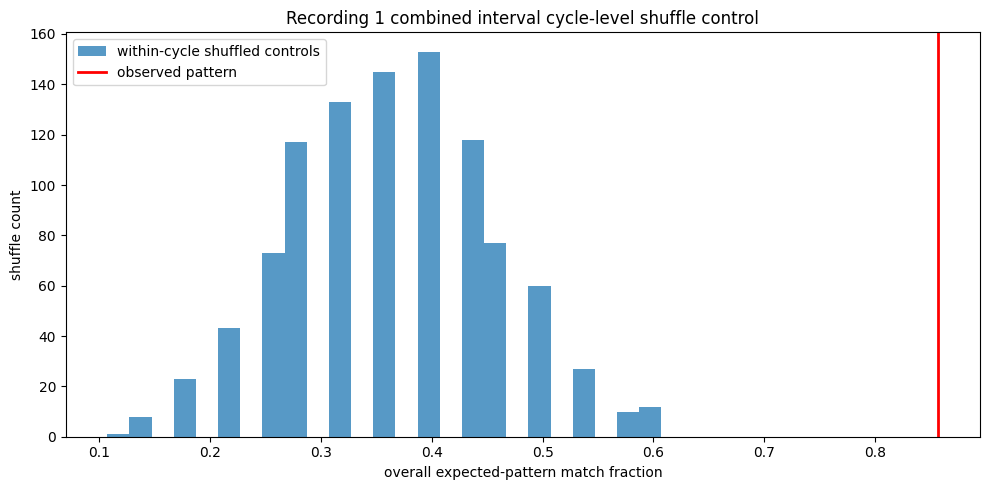

recording: 202606130413540003SMP
feature: value_all_mean
stable_start_s: 22.5
stable_end_s: 32.5
fixed_lag_s: 0.29
n_cycles_tested: 7
observed_overall_match_fraction: 0.8571428571428571
n_shuffles: 1000
p_overall_shuffle_ge_observed: 0.0


In [59]:
required_names = [
    "combined_df1",
    "anchor_times",
]

missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise NameError(f"Missing required notebook variables: {missing_names}")

combined_cycle_df1 = combined_df1.copy().sort_values("time_s").reset_index(drop=True)

time_s = combined_cycle_df1["time_s"].to_numpy()

phase_values = np.full(len(combined_cycle_df1), np.nan)
cycle_index_values = np.full(len(combined_cycle_df1), np.nan)

if len(anchor_times) >= 2:
    for cycle_index in range(len(anchor_times) - 1):
        start_t = anchor_times[cycle_index]
        end_t = anchor_times[cycle_index + 1]
        mask = (time_s >= start_t) & (time_s < end_t)
        phase_values[mask] = (time_s[mask] - start_t) / (end_t - start_t)
        cycle_index_values[mask] = cycle_index

combined_cycle_df1["brightness_cycle_phase"] = phase_values
combined_cycle_df1["cycle_index"] = cycle_index_values

combined_cycle_df1 = combined_cycle_df1.dropna(
    subset=["brightness_cycle_phase", "cycle_index", "native_state_band"]
).copy()

combined_cycle_df1["cycle_index"] = combined_cycle_df1["cycle_index"].astype(int)

combined_cycle_df1["phase_region"] = pd.cut(
    combined_cycle_df1["brightness_cycle_phase"],
    bins=[0.0, 0.25, 0.60, 0.85, 1.0],
    labels=[
        "anchor_or_trough_region",
        "post_anchor_mid_cycle",
        "late_cycle_region",
        "return_to_anchor_region",
    ],
    include_lowest=True,
)

expected_regions_combined1 = {
    "anchor_or_trough_region": "high_native",
    "post_anchor_mid_cycle": "low_native",
    "late_cycle_region": "mid_native",
    "return_to_anchor_region": "high_native",
}

def compute_expected_pattern_score_combined1(input_df, expected_regions):
    """This function computes cycle-region expected-state match fractions."""
    region_counts = (
        input_df
        .groupby(["cycle_index", "phase_region", "native_state_band"], observed=True)
        .size()
        .reset_index(name="n_frames")
    )

    region_totals = (
        region_counts
        .groupby(["cycle_index", "phase_region"], observed=True)["n_frames"]
        .transform("sum")
    )

    region_counts["fraction"] = region_counts["n_frames"] / region_totals

    dominant = (
        region_counts
        .sort_values(["cycle_index", "phase_region", "fraction"], ascending=[True, True, False])
        .groupby(["cycle_index", "phase_region"], observed=True)
        .head(1)
        .reset_index(drop=True)
    )

    rows = []

    for region_name, expected_state in expected_regions.items():
        region_df = dominant[dominant["phase_region"].astype(str) == region_name]

        rows.append({
            "phase_region": region_name,
            "expected_dominant_state": expected_state,
            "n_cycles": len(region_df),
            "n_matching_cycles": int((region_df["native_state_band"] == expected_state).sum()),
            "match_fraction": (
                float((region_df["native_state_band"] == expected_state).mean())
                if len(region_df) else np.nan
            ),
        })

    summary = pd.DataFrame(rows)
    overall_match_fraction = summary["n_matching_cycles"].sum() / summary["n_cycles"].sum()

    return summary, overall_match_fraction

observed_combined_summary1, observed_combined_overall1 = compute_expected_pattern_score_combined1(
    combined_cycle_df1,
    expected_regions_combined1,
)

rng = np.random.default_rng(20260705)
n_shuffles = 1000

shuffle_rows = []

for shuffle_index in range(n_shuffles):
    shuffled_df = combined_cycle_df1.copy()

    for cycle_index, cycle_df in shuffled_df.groupby("cycle_index"):
        shuffled_states = cycle_df["native_state_band"].to_numpy().copy()
        rng.shuffle(shuffled_states)
        shuffled_df.loc[cycle_df.index, "native_state_band"] = shuffled_states

    shuffle_summary, shuffle_overall = compute_expected_pattern_score_combined1(
        shuffled_df,
        expected_regions_combined1,
    )

    row = {
        "shuffle_index": shuffle_index,
        "overall_match_fraction": shuffle_overall,
    }

    for _, summary_row in shuffle_summary.iterrows():
        row[f"{summary_row['phase_region']}_match_fraction"] = summary_row["match_fraction"]

    shuffle_rows.append(row)

combined_shuffle_control1 = pd.DataFrame(shuffle_rows)

control_summary_rows = []

for column in combined_shuffle_control1.columns:
    if not column.endswith("match_fraction"):
        continue

    observed_value = (
        observed_combined_overall1
        if column == "overall_match_fraction"
        else observed_combined_summary1.loc[
            observed_combined_summary1["phase_region"].astype(str)
            == column.replace("_match_fraction", ""),
            "match_fraction",
        ].iloc[0]
    )

    control_summary_rows.append({
        "metric": column,
        "observed": observed_value,
        "shuffle_mean": float(combined_shuffle_control1[column].mean()),
        "shuffle_p95": float(np.percentile(combined_shuffle_control1[column], 95)),
        "shuffle_max": float(combined_shuffle_control1[column].max()),
        "p_shuffle_ge_observed": float(
            (combined_shuffle_control1[column] >= observed_value).mean()
        ),
    })

combined_shuffle_control_summary1 = pd.DataFrame(control_summary_rows)

display(observed_combined_summary1)
display(combined_shuffle_control_summary1)

plt.figure(figsize=(10, 5))
plt.hist(
    combined_shuffle_control1["overall_match_fraction"],
    bins=25,
    alpha=0.75,
    label="within-cycle shuffled controls",
)
plt.axvline(
    observed_combined_overall1,
    color="red",
    linewidth=2,
    label="observed pattern",
)
plt.title("Recording 1 combined interval cycle-level shuffle control")
plt.xlabel("overall expected-pattern match fraction")
plt.ylabel("shuffle count")
plt.legend()
plt.tight_layout()
plt.show()

print("recording:", recording_id_1 if "recording_id_1" in globals() else "recording 1")
print("feature: value_all_mean")
print("stable_start_s:", 22.5)
print("stable_end_s:", 32.5)
print("fixed_lag_s:", 0.29)
print("n_cycles_tested:", combined_cycle_df1["cycle_index"].nunique())
print("observed_overall_match_fraction:", observed_combined_overall1)
print("n_shuffles:", n_shuffles)
print(
    "p_overall_shuffle_ge_observed:",
    float(
        (
            combined_shuffle_control1["overall_match_fraction"]
            >= observed_combined_overall1
        ).mean()
    ),
)

### Shuffle-control check for combined second-recording stable interval interpretation

Result classification: useful positive result with limited generalization.

The combined recording-1 shuffle-control check showed that the `22.5..32.5 s` phase-state pattern was stronger than expected after randomizing native state timing within each brightness cycle.

Evidence-supported observations:

- Seven complete brightness cycles were tested.
- The observed overall expected-pattern match fraction was approximately `0.857`.
- The shuffled controls had mean overall match fraction approximately `0.365`.
- The shuffled-control 95th percentile was approximately `0.500`.
- The maximum shuffled overall match fraction was approximately `0.607`.
- None of the 1000 shuffled controls matched or exceeded the observed overall pattern.
- Region-level support was strongest for the return-to-anchor region and post-anchor mid-cycle region.
- The late-cycle region also exceeded shuffled controls, but with weaker margin than the strongest regions.



## NB10 final checkpoint

Result classification: useful negative result for native spectrogram recovery, useful positive result for compact native PW state/phase structure.

NB10 explored whether `PW_CinePartition0.bin` contains image-like, video-like, spectrogram-like, or pulse-wave-related native data.

Evidence-supported findings:

- `PW_CinePartition0.bin` behaves as a fixed-page native PW stream.
- The current evidence-supported page assumptions are:
  - page size: `1296 bytes`
  - page rate: approximately `500 Hz`
- Offsets `0..15` behave like a header/control-like region.
- Offsets `16..143` contain 16 repeated 8-byte dynamic records.
- Offsets `144..1295` are mostly stable, with limited counter-like or rare status/config-like exceptions.
- The 16 dynamic records contain structured code/value fields.
- No raw or display-ready spectrogram raster was recovered.
- No image-like or video-like native PW buffer was validated.

NB10 did find controlled evidence that compact native PW state features relate to AVI Doppler brightness-cycle phase in selected recordings.

Recording `202606130411060002SMP`:

- `pair_range_mean_0_6` showed strong state-like association with AVI `right_sweep_area` `roi_bright_fraction` in stable intervals.
- A fitted linear lag model preserved state-band separation across `22.5..40.0 s`.
- Global state bands separated AVI brightness:
  - `high_native` corresponded to brighter Doppler ROI frames.
  - `low_native` corresponded to dimmer Doppler ROI frames.
  - `mid_native` was intermediate or transitional.
- Phase-folding showed repeated state-cycle structure.
- A within-cycle shuffle control supported non-random phase placement:
  - observed overall expected-pattern match fraction approximately `0.853`
  - shuffled-control maximum approximately `0.529`
  - no shuffled controls matched or exceeded the observed overall pattern.

Recording `202606130413540003SMP`:

- `value_all_mean` showed a weaker and more localized phase-state relationship.
- The combined `22.5..32.5 s` interval preserved a dominant phase-region pattern using fixed lag `+0.29 s`.
- A within-cycle shuffle control supported non-random phase placement:
  - observed overall expected-pattern match fraction approximately `0.857`
  - shuffled-control maximum approximately `0.607`
  - no shuffled controls matched or exceeded the observed overall pattern.
- The continuous brightness relationship was weak when pooled across the combined interval, so recording 1 supports phase-state behavior more than brightness-proxy behavior.

Interpretation boundary:

NB10 supports interpreting `PW_CinePartition0.bin` as a structured native PW dynamic state stream. It contains compact state features that can be synchronized with displayed Doppler brightness-cycle phase in selected recordings and intervals.

NB10 does not support claiming:

- decoded native spectrogram raster
- native image/video recovery from PW data
- raw native audio
- native velocity envelope
- native PSV, EDV, RI, PI, or VTI
- clinical measurement
- production-ready native Doppler decoding

The strongest current interpretation is that `PW_CinePartition0.bin` contains compact native PW acquisition/rendering/activity state related to Doppler cycle phase, not a directly decoded spectrogram image.